In [3]:
import os

ZIP_PATH = "Camylon17WildDataset.zip"

print("ZIP path:", ZIP_PATH)
print("Exists:", os.path.exists(ZIP_PATH))

if os.path.exists(ZIP_PATH):
    print("Size:", f"{os.path.getsize(ZIP_PATH) / (1024**3):.2f} GB")

ZIP path: Camylon17WildDataset.zip
Exists: True
Size: 10.02 GB


In [4]:
import zipfile

ZIP_PATH = "Camylon17WildDataset.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("ZIP is valid:", z.testzip() is None)
    print("Total files:", len(z.namelist()))
    
    print("\nFirst 20 entries:")
    for name in z.namelist()[:20]:
        print(name)

ZIP is valid: True
Total files: 455954

First 20 entries:
node0/test/anomaly/patch_patient_012_node_0_x_2400_y_25376.png
node0/test/anomaly/patch_patient_012_node_0_x_2400_y_25408.png
node0/test/anomaly/patch_patient_012_node_0_x_2400_y_25440.png
node0/test/anomaly/patch_patient_012_node_0_x_2400_y_25472.png
node0/test/anomaly/patch_patient_012_node_0_x_2400_y_25504.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25312.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25344.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25376.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25408.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25440.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25472.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25504.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25536.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25568.png
node0/test/anomaly/patch_patient_012_node_0_x_2432_y_25600.p

In [5]:
import zipfile
from collections import Counter

ZIP_PATH = "Camylon17WildDataset.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    top_level = Counter()
    second_level = Counter()
    
    for name in z.namelist():
        parts = name.split("/")
        
        if len(parts) >= 1:
            top_level[parts[0]] += 1
        
        if len(parts) >= 2:
            second_level[f"{parts[0]}/{parts[1]}"] += 1

print("Top-level directories:")
for name, count in sorted(top_level.items()):
    print(f"{name}: {count:,}")

print("\nSecond-level directories:")
for name, count in sorted(second_level.items()):
    print(f"{name}: {count:,}")

Top-level directories:
node0: 103,624
node1: 142,504
node2: 71,503
node3: 36,416
node4: 101,907

Second-level directories:
node0/test: 79,694
node0/train: 23,930
node1/test: 89,629
node1/train: 52,875
node2/test: 49,187
node2/train: 22,316
node3/test: 18,075
node3/train: 18,341
node4/test: 59,787
node4/train: 42,120


In [6]:
import zipfile
from collections import Counter

ZIP_PATH = "Camylon17WildDataset.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    label_dirs = Counter()

    for name in z.namelist():
        parts = name.split("/")

        if len(parts) >= 3:
            # node0/train/anomaly
            label_dirs[f"{parts[0]}/{parts[1]}/{parts[2]}"] += 1

print("Label directories:")
for name, count in sorted(label_dirs.items()):
    print(f"{name}: {count:,}")

Label directories:
node0/test/anomaly: 69,437
node0/test/normal: 10,257
node0/train/normal: 23,930
node1/test/anomaly: 66,968
node1/test/normal: 22,661
node1/train/normal: 52,875
node2/test/anomaly: 39,623
node2/test/normal: 9,564
node2/train/normal: 22,316
node3/test/anomaly: 10,214
node3/test/normal: 7,861
node3/train/normal: 18,341
node4/test/anomaly: 41,735
node4/test/normal: 18,052
node4/train/normal: 42,120


In [7]:
import zipfile
import re
from collections import defaultdict

ZIP_PATH = "Camylon17WildDataset.zip"

patient_info = defaultdict(lambda: {
    "nodes": set(),
    "splits": set(),
    "labels": set(),
    "count": 0
})

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for name in z.namelist():
        if not name.endswith(".png"):
            continue

        parts = name.split("/")

        # Expected:
        # node0/train/normal/patch_patient_012_node_0_x_2400_y_25376.png
        node = parts[0]
        split = parts[1]
        label = parts[2]
        filename = parts[3]

        match = re.search(r"patient_(\d+)", filename)

        if match:
            patient = int(match.group(1))

            patient_info[patient]["nodes"].add(node)
            patient_info[patient]["splits"].add(split)
            patient_info[patient]["labels"].add(label)
            patient_info[patient]["count"] += 1

print("Total patients found:", len(patient_info))

print("\nFirst 20 patients:")
for patient in sorted(patient_info)[:20]:
    info = patient_info[patient]
    print(
        f"Patient {patient:03d}: "
        f"nodes={sorted(info['nodes'])}, "
        f"splits={sorted(info['splits'])}, "
        f"labels={sorted(info['labels'])}, "
        f"samples={info['count']:,}"
    )

Total patients found: 43

First 20 patients:
Patient 004: nodes=['node4'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=4,316
Patient 009: nodes=['node1'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=4,597
Patient 010: nodes=['node4'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=4,046
Patient 012: nodes=['node0'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=13,637
Patient 015: nodes=['node1', 'node2'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=10,554
Patient 016: nodes=['node1'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=3,427
Patient 017: nodes=['node1', 'node2', 'node4'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=18,859
Patient 020: nodes=['node2', 'node4'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=7,449
Patient 021: nodes=['node3'], splits=['test', 'train'], labels=['anomaly', 'normal'], samples=1,705
Patient 022: nod

In [8]:
import zipfile
import re
from collections import defaultdict, Counter

ZIP_PATH = "Camylon17WildDataset.zip"

node_patients = defaultdict(set)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for name in z.namelist():
        if not name.endswith(".png"):
            continue

        parts = name.split("/")
        node = parts[0]
        filename = parts[-1]

        match = re.search(r"patient_(\d+)", filename)

        if match:
            patient = int(match.group(1))
            node_patients[node].add(patient)

print("Patients per node:")
for node in sorted(node_patients):
    patients = sorted(node_patients[node])
    print(f"{node}: {len(patients)} patients")
    print("   ", patients)

Patients per node:
node0: 7 patients
    [12, 41, 64, 72, 86, 87, 96]
node1: 14 patients
    [9, 15, 16, 17, 24, 39, 45, 48, 52, 68, 73, 80, 88, 92]
node2: 9 patients
    [15, 17, 20, 24, 38, 40, 51, 62, 66]
node3: 7 patients
    [21, 34, 36, 42, 46, 60, 89]
node4: 13 patients
    [4, 10, 17, 20, 22, 44, 46, 61, 67, 75, 81, 86, 99]


In [9]:
import os
import zipfile

ZIP_PATH = "Camylon17WildDataset.zip"
EXTRACT_DIR = "Camelyon17"

if os.path.exists(EXTRACT_DIR):
    print(f"Extraction directory already exists: {EXTRACT_DIR}")
else:
    print("Starting extraction...")
    
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    
    print("Extraction completed.")

print("\nDataset location:")
print(os.path.abspath(EXTRACT_DIR))

Starting extraction...
Extraction completed.

Dataset location:
/workspace/FederalLearning/Camelyon17


In [10]:
import os
from collections import Counter

DATASET_DIR = "/workspace/FederalLearning/Camelyon17"

node_counts = Counter()

for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file.endswith(".png"):
            node = os.path.relpath(root, DATASET_DIR).split(os.sep)[0]
            node_counts[node] += 1

print("PNG samples per node:")

for node, count in sorted(node_counts.items()):
    print(f"{node}: {count:,}")

print("\nTotal PNG samples:", sum(node_counts.values()))

PNG samples per node:
node0: 103,624
node1: 142,504
node2: 71,503
node3: 36,416
node4: 101,907

Total PNG samples: 455954


In [11]:
import os

DATASET_DIR = "/workspace/FederalLearning/Camelyon17"

print("Files/directories at dataset root:")
for item in sorted(os.listdir(DATASET_DIR)):
    path = os.path.join(DATASET_DIR, item)
    kind = "DIR " if os.path.isdir(path) else "FILE"
    print(f"{kind}  {item}")

Files/directories at dataset root:
DIR   node0
DIR   node1
DIR   node2
DIR   node3
DIR   node4


In [12]:
import os

DATASET_DIR = "/workspace/FederalLearning/Camelyon17"

node_path = os.path.join(DATASET_DIR, "node0")

print("Contents of node0:")

for item in sorted(os.listdir(node_path)):
    path = os.path.join(node_path, item)
    kind = "DIR " if os.path.isdir(path) else "FILE"
    print(f"{kind}  {item}")

Contents of node0:
DIR   test
DIR   train


In [13]:
import os

TRAIN_PATH = "/workspace/FederalLearning/Camelyon17/node0/train"

print("Contents of node0/train:")

for item in sorted(os.listdir(TRAIN_PATH)):
    path = os.path.join(TRAIN_PATH, item)
    kind = "DIR " if os.path.isdir(path) else "FILE"
    print(f"{kind}  {item}")

Contents of node0/train:
DIR   normal


In [14]:
import os

TEST_PATH = "/workspace/FederalLearning/Camelyon17/node0/test"

print("Contents of node0/test:")

for item in sorted(os.listdir(TEST_PATH)):
    path = os.path.join(TEST_PATH, item)
    kind = "DIR " if os.path.isdir(path) else "FILE"
    print(f"{kind}  {item}")

Contents of node0/test:
DIR   anomaly
DIR   normal


In [15]:
import os
import re

DATASET_DIR = "/workspace/FederalLearning/Camelyon17"

for node in [f"node{i}" for i in range(5)]:
    test_normal = os.path.join(DATASET_DIR, node, "test", "normal")

    files = [
        f for f in os.listdir(test_normal)
        if f.endswith(".png")
    ]

    print(f"\n{node}")
    print("Number of normal test images:", len(files))

    for filename in files[:3]:
        match = re.search(
            r"patient_(\d+)_node_(\d+)_x_(\d+)_y_(\d+)",
            filename
        )

        if match:
            print(
                " patient =", match.group(1),
                " filename_node =", match.group(2),
                "x =", match.group(3),
                "y =", match.group(4)
            )
        else:
            print("Could not parse:", filename)


node0
Number of normal test images: 10257
 patient = 064  filename_node = 0 x = 6784 y = 43008
 patient = 064  filename_node = 0 x = 17280 y = 39072
 patient = 086  filename_node = 0 x = 8672 y = 8768

node1
Number of normal test images: 22661
 patient = 017  filename_node = 1 x = 19136 y = 19424
 patient = 068  filename_node = 1 x = 4320 y = 15424
 patient = 080  filename_node = 1 x = 34592 y = 9056

node2
Number of normal test images: 9564
 patient = 062  filename_node = 2 x = 896 y = 25472
 patient = 024  filename_node = 2 x = 6496 y = 19040
 patient = 040  filename_node = 2 x = 29280 y = 13504

node3
Number of normal test images: 7861
 patient = 036  filename_node = 3 x = 8544 y = 21984
 patient = 089  filename_node = 3 x = 25408 y = 9792
 patient = 021  filename_node = 3 x = 3424 y = 11808

node4
Number of normal test images: 18052
 patient = 086  filename_node = 4 x = 33280 y = 15584
 patient = 081  filename_node = 4 x = 22336 y = 5888
 patient = 081  filename_node = 4 x = 23968

In [16]:
import os
from collections import Counter

DATASET_DIR = "/workspace/FederalLearning/Camelyon17"

for node in [f"node{i}" for i in range(5)]:
    counts = Counter()

    for split in ["train", "test"]:
        split_path = os.path.join(DATASET_DIR, node, split)

        for label in ["normal", "anomaly"]:
            label_path = os.path.join(split_path, label)

            if os.path.exists(label_path):
                counts[f"{split}/{label}"] = sum(
                    1 for f in os.listdir(label_path)
                    if f.endswith(".png")
                )

    print(f"\n{node}")
    for key, value in sorted(counts.items()):
        print(f"  {key}: {value:,}")
    print(f"  Total: {sum(counts.values()):,}")


node0
  test/anomaly: 69,437
  test/normal: 10,257
  train/normal: 23,930
  Total: 103,624

node1
  test/anomaly: 66,968
  test/normal: 22,661
  train/normal: 52,875
  Total: 142,504

node2
  test/anomaly: 39,623
  test/normal: 9,564
  train/normal: 22,316
  Total: 71,503

node3
  test/anomaly: 10,214
  test/normal: 7,861
  train/normal: 18,341
  Total: 36,416

node4
  test/anomaly: 41,735
  test/normal: 18,052
  train/normal: 42,120
  Total: 101,907


In [17]:
import os
import re
import pandas as pd

DATASET_DIR = "/workspace/FederalLearning/Camelyon17"

metadata_rows = []

print("Building metadata index...")

for node_id in range(5):

    node_name = f"node{node_id}"

    for split in ["train", "test"]:

        split_path = os.path.join(
            DATASET_DIR,
            node_name,
            split
        )

        for label_name, label_id in [
            ("normal", 0),
            ("anomaly", 1)
        ]:

            label_path = os.path.join(
                split_path,
                label_name
            )

            if not os.path.exists(label_path):
                continue

            for filename in os.listdir(label_path):

                if not filename.endswith(".png"):
                    continue

                # Example:
                # patch_patient_012_node_0_x_2400_y_25376.png

                match = re.search(
                    r"patient_(\d+)_node_(\d+)_x_(\d+)_y_(\d+)",
                    filename
                )

                if match is None:
                    continue

                patient = int(match.group(1))
                filename_node = int(match.group(2))
                x_coord = int(match.group(3))
                y_coord = int(match.group(4))

                metadata_rows.append({
                    "path": os.path.join(
                        label_path,
                        filename
                    ),
                    "node": node_id,
                    "split": split,
                    "label": label_id,
                    "patient": patient,
                    "x_coord": x_coord,
                    "y_coord": y_coord
                })

    print(f"{node_name} processed")

metadata_df = pd.DataFrame(metadata_rows)

print("\nMetadata index complete.")
print("Total samples:", len(metadata_df))

print("\nColumns:")
print(metadata_df.columns.tolist())

print("\nFirst 5 rows:")
display(metadata_df.head())

Building metadata index...
node0 processed
node1 processed
node2 processed
node3 processed
node4 processed

Metadata index complete.
Total samples: 455954

Columns:
['path', 'node', 'split', 'label', 'patient', 'x_coord', 'y_coord']

First 5 rows:


,path,node,split,label,patient,x_coord,y_coord
0,/workspace/FederalLearning/Camelyon17/node0/tr...,0,train,0,64,7424,35968
1,/workspace/FederalLearning/Camelyon17/node0/tr...,0,train,0,86,30688,7328
2,/workspace/FederalLearning/Camelyon17/node0/tr...,0,train,0,87,41056,14272
3,/workspace/FederalLearning/Camelyon17/node0/tr...,0,train,0,96,37472,2496
4,/workspace/FederalLearning/Camelyon17/node0/tr...,0,train,0,86,9632,13280


In [18]:
print("Samples by node and split:\n")

node_split_counts = (
    metadata_df
    .groupby(["node", "split"])
    .size()
    .unstack(fill_value=0)
)

display(node_split_counts)

print("\nSamples by node and label:\n")

node_label_counts = (
    metadata_df
    .groupby(["node", "label"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "normal", 1: "anomaly"})
)

display(node_label_counts)

Samples by node and split:



split,test,train
node,,
0,79694,23930
1,89629,52875
2,49187,22316
3,18075,18341
4,59787,42120



Samples by node and label:



label,normal,anomaly
node,,
0,34187,69437
1,75536,66968
2,31880,39623
3,26202,10214
4,60172,41735


In [19]:
node_patients = (
    metadata_df
    .groupby("node")["patient"]
    .apply(lambda x: set(x))
    .to_dict()
)

print("Patient overlap between nodes:\n")

for i in range(5):
    for j in range(i + 1, 5):
        overlap = node_patients[i] & node_patients[j]

        print(
            f"Node {i} ∩ Node {j}: "
            f"{len(overlap)} patients",
            sorted(overlap)
        )

Patient overlap between nodes:

Node 0 ∩ Node 1: 0 patients []
Node 0 ∩ Node 2: 0 patients []
Node 0 ∩ Node 3: 0 patients []
Node 0 ∩ Node 4: 1 patients [86]
Node 1 ∩ Node 2: 3 patients [15, 17, 24]
Node 1 ∩ Node 3: 0 patients []
Node 1 ∩ Node 4: 1 patients [17]
Node 2 ∩ Node 3: 0 patients []
Node 2 ∩ Node 4: 2 patients [17, 20]
Node 3 ∩ Node 4: 1 patients [46]


In [20]:
# Check patient overlap specifically between:
# Training nodes (0,1,2) and unseen test node (4)

train_nodes = {0, 1, 2}
test_node = 4

train_patients = set(
    metadata_df[
        (metadata_df["node"].isin(train_nodes))
    ]["patient"]
)

test_patients = set(
    metadata_df[
        metadata_df["node"] == test_node
    ]["patient"]
)

overlap_patients = train_patients & test_patients

print("Training patients:", len(train_patients))
print("Test-domain patients:", len(test_patients))

print("\nOverlapping patients:")
print(sorted(overlap_patients))

print("\nNumber of overlapping patients:", len(overlap_patients))

print("\nDetails of overlapping patients:")
display(
    metadata_df[
        metadata_df["patient"].isin(overlap_patients)
    ]
    .groupby(["patient", "node", "split", "label"])
    .size()
    .reset_index(name="samples")
)

Training patients: 27
Test-domain patients: 13

Overlapping patients:
[17, 20, 86]

Number of overlapping patients: 3

Details of overlapping patients:


,patient,node,split,label,samples
0,17,1,test,0,467
1,17,1,test,1,7
2,17,1,train,0,1122
3,17,2,test,0,1452
4,17,2,test,1,8704
5,17,2,train,0,3299
6,17,4,test,0,924
7,17,4,test,1,755
8,17,4,train,0,2129
9,20,2,test,0,553


In [21]:
# Remove training-overlapping patients from the unseen test domain

overlap_patients = {17, 20, 86}

node4_full = metadata_df[
    metadata_df["node"] == 4
].copy()

node4_clean = node4_full[
    ~node4_full["patient"].isin(overlap_patients)
].copy()

print("Node 4 samples before removing overlap:", len(node4_full))
print("Node 4 samples after removing overlap:", len(node4_clean))
print("Removed samples:", len(node4_full) - len(node4_clean))

print("\nPatient count:")
print("Before:", node4_full["patient"].nunique())
print("After :", node4_clean["patient"].nunique())

print("\nLabel distribution after removing overlap:")
print(
    node4_clean["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "normal", 1: "anomaly"})
)

Node 4 samples before removing overlap: 101907
Node 4 samples after removing overlap: 84789
Removed samples: 17118

Patient count:
Before: 13
After : 10

Label distribution after removing overlap:
normal     47045
anomaly    37744
Name: label, dtype: int64


In [22]:
# Verify label availability in the intended training domains

train_nodes = [0, 1, 2]
val_node = 3
test_node = 4

for node in train_nodes + [val_node, test_node]:
    subset = metadata_df[metadata_df["node"] == node]

    print(f"\n{'='*50}")
    print(f"NODE {node}")
    print(f"{'='*50}")

    print("\nSamples by split:")
    print(subset["split"].value_counts().sort_index())

    print("\nLabels by split:")
    print(
        pd.crosstab(
            subset["split"],
            subset["label"]
        ).rename(columns={
            0: "normal",
            1: "anomaly"
        })
    )


NODE 0

Samples by split:
test     79694
train    23930
Name: split, dtype: int64

Labels by split:
label  normal  anomaly
split                 
test    10257    69437
train   23930        0

NODE 1

Samples by split:
test     89629
train    52875
Name: split, dtype: int64

Labels by split:
label  normal  anomaly
split                 
test    22661    66968
train   52875        0

NODE 2

Samples by split:
test     49187
train    22316
Name: split, dtype: int64

Labels by split:
label  normal  anomaly
split                 
test     9564    39623
train   22316        0

NODE 3

Samples by split:
test     18075
train    18341
Name: split, dtype: int64

Labels by split:
label  normal  anomaly
split                 
test     7861    10214
train   18341        0

NODE 4

Samples by split:
test     59787
train    42120
Name: split, dtype: int64

Labels by split:
label  normal  anomaly
split                 
test    18052    41735
train   42120        0


In [23]:
# Check whether each patient contains both classes or only one class

for node in [0, 1, 2, 3, 4]:
    subset = metadata_df[metadata_df["node"] == node]

    patient_labels = (
        subset.groupby("patient")["label"]
        .agg(
            samples="count",
            classes="nunique",
            normal=lambda x: (x == 0).sum(),
            anomaly=lambda x: (x == 1).sum()
        )
        .reset_index()
    )

    print(f"\n{'='*60}")
    print(f"NODE {node}")
    print(f"{'='*60}")

    print("Patients:", len(patient_labels))
    print(
        "Patients containing both classes:",
        (patient_labels["classes"] == 2).sum()
    )
    print(
        "Patients containing only normal:",
        (patient_labels["classes"] == 1).sum()
    )

    display(patient_labels)


NODE 0
Patients: 7
Patients containing both classes: 7
Patients containing only normal: 0


,patient,samples,classes,normal,anomaly
0,12,13637,2,988,12649
1,41,3694,2,3684,10
2,64,4019,2,4000,19
3,72,5339,2,5278,61
4,86,7867,2,7859,8
5,87,7958,2,7934,24
6,96,61110,2,4444,56666



NODE 1
Patients: 14
Patients containing both classes: 14
Patients containing only normal: 0


,patient,samples,classes,normal,anomaly
0,9,4597,2,4290,307
1,15,7294,2,2409,4885
2,16,3427,2,3422,5
3,17,1596,2,1589,7
4,24,888,2,856,32
5,39,2587,2,2418,169
6,45,7727,2,7543,184
7,48,4556,2,4446,110
8,52,12742,2,6058,6684
9,68,10661,2,10645,16



NODE 2
Patients: 9
Patients containing both classes: 9
Patients containing only normal: 0


,patient,samples,classes,normal,anomaly
0,15,3260,2,2082,1178
1,17,13455,2,4751,8704
2,20,2078,2,1904,174
3,24,2966,2,2949,17
4,38,1275,2,1097,178
5,40,3810,2,3783,27
6,51,31878,2,4880,26998
7,62,8831,2,6653,2178
8,66,3950,2,3781,169



NODE 3
Patients: 7
Patients containing both classes: 7
Patients containing only normal: 0


,patient,samples,classes,normal,anomaly
0,21,1705,2,1548,157
1,34,4971,2,877,4094
2,36,2659,2,2030,629
3,42,7210,2,2981,4229
4,46,4334,2,3305,1029
5,60,10623,2,10608,15
6,89,4914,2,4853,61



NODE 4
Patients: 13
Patients containing both classes: 13
Patients containing only normal: 0


,patient,samples,classes,normal,anomaly
0,4,4316,2,4280,36
1,10,4046,2,2854,1192
2,17,3808,2,3053,755
3,20,5371,2,2145,3226
4,22,10404,2,1628,8776
5,44,5288,2,2527,2761
6,46,3815,2,3320,495
7,61,3466,2,3343,123
8,67,6089,2,5912,177
9,75,19485,2,5454,14031


In [24]:
# ============================================================
# PHASE 3: Construct patient-level experimental domains
# ============================================================

TRAIN_NODES = [0, 1, 2]
VAL_NODE = 3
TEST_NODE = 4

# Patients that overlap between training and node 4
TEST_EXCLUDE_PATIENTS = {17, 20, 86}

# ------------------------------------------------------------
# Training domains
# ------------------------------------------------------------
train_df = metadata_df[
    metadata_df["node"].isin(TRAIN_NODES)
].copy()

# ------------------------------------------------------------
# Validation domain
# ------------------------------------------------------------
val_df = metadata_df[
    metadata_df["node"] == VAL_NODE
].copy()

# ------------------------------------------------------------
# Clean unseen test domain
# ------------------------------------------------------------
test_df = metadata_df[
    (metadata_df["node"] == TEST_NODE) &
    (~metadata_df["patient"].isin(TEST_EXCLUDE_PATIENTS))
].copy()

print("TRAINING DATA")
print("Samples:", len(train_df))
print("Patients:", train_df["patient"].nunique())
print("Nodes:", sorted(train_df["node"].unique()))

print("\nVALIDATION DATA")
print("Samples:", len(val_df))
print("Patients:", val_df["patient"].nunique())
print("Nodes:", sorted(val_df["node"].unique()))

print("\nUNSEEN TEST DATA")
print("Samples:", len(test_df))
print("Patients:", test_df["patient"].nunique())
print("Excluded patients:", sorted(TEST_EXCLUDE_PATIENTS))

# ------------------------------------------------------------
# Label distributions
# ------------------------------------------------------------
print("\nTraining label distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "normal", 1: "anomaly"})
)

print("\nValidation label distribution:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "normal", 1: "anomaly"})
)

print("\nClean test label distribution:")
print(
    test_df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "normal", 1: "anomaly"})
)

TRAINING DATA
Samples: 317631
Patients: 27
Nodes: [0, 1, 2]

VALIDATION DATA
Samples: 36416
Patients: 7
Nodes: [3]

UNSEEN TEST DATA
Samples: 84789
Patients: 10
Excluded patients: [17, 20, 86]

Training label distribution:
normal     141603
anomaly    176028
Name: label, dtype: int64

Validation label distribution:
normal     26202
anomaly    10214
Name: label, dtype: int64

Clean test label distribution:
normal     47045
anomaly    37744
Name: label, dtype: int64


In [25]:
# ============================================================
# PHASE 3A: Inspect training clients
# ============================================================

import numpy as np

TRAIN_NODES = [0, 1, 2]

for node in TRAIN_NODES:
    client_df = metadata_df[
        metadata_df["node"] == node
    ].copy()

    print(f"\n{'='*60}")
    print(f"CLIENT / NODE {node}")
    print(f"{'='*60}")

    print("Total samples:", len(client_df))
    print("Patients:", client_df["patient"].nunique())

    print("\nLabel distribution:")
    print(
        client_df["label"]
        .value_counts()
        .sort_index()
        .rename(index={
            0: "normal",
            1: "anomaly"
        })
    )

    print("\nPatient-level sample counts:")
    patient_summary = (
        client_df
        .groupby(["patient", "label"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={
            0: "normal",
            1: "anomaly"
        })
    )

    display(patient_summary)


CLIENT / NODE 0
Total samples: 103624
Patients: 7

Label distribution:
normal     34187
anomaly    69437
Name: label, dtype: int64

Patient-level sample counts:


label,normal,anomaly
patient,,
12,988,12649
41,3684,10
64,4000,19
72,5278,61
86,7859,8
87,7934,24
96,4444,56666



CLIENT / NODE 1
Total samples: 142504
Patients: 14

Label distribution:
normal     75536
anomaly    66968
Name: label, dtype: int64

Patient-level sample counts:


label,normal,anomaly
patient,,
9,4290,307
15,2409,4885
16,3422,5
17,1589,7
24,856,32
39,2418,169
45,7543,184
48,4446,110
52,6058,6684



CLIENT / NODE 2
Total samples: 71503
Patients: 9

Label distribution:
normal     31880
anomaly    39623
Name: label, dtype: int64

Patient-level sample counts:


label,normal,anomaly
patient,,
15,2082,1178
17,4751,8704
20,1904,174
24,2949,17
38,1097,178
40,3783,27
51,4880,26998
62,6653,2178
66,3781,169


In [26]:
# ============================================================
# PHASE 3B: Patient-disjoint local train/holdout split
# ============================================================

import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)

client_splits = {}

for node in [0, 1, 2]:
    client_df = metadata_df[
        metadata_df["node"] == node
    ].copy()

    patients = np.array(
        sorted(client_df["patient"].unique())
    )

    # Shuffle patients reproducibly
    rng.shuffle(patients)

    # Approximately 80% patients for local training
    # and 20% for local holdout.
    n_train_patients = max(
        1,
        int(len(patients) * 0.8)
    )

    # Make sure at least one patient remains for holdout
    if n_train_patients >= len(patients):
        n_train_patients = len(patients) - 1

    train_patients = set(
        patients[:n_train_patients]
    )

    holdout_patients = set(
        patients[n_train_patients:]
    )

    local_train = client_df[
        client_df["patient"].isin(train_patients)
    ].copy()

    local_holdout = client_df[
        client_df["patient"].isin(holdout_patients)
    ].copy()

    client_splits[node] = {
        "train": local_train,
        "holdout": local_holdout
    }

    print(f"\n{'='*60}")
    print(f"NODE {node}")
    print(f"{'='*60}")

    print("Training patients:", sorted(train_patients))
    print("Holdout patients:", sorted(holdout_patients))

    print("\nTraining samples:", len(local_train))
    print("Holdout samples:", len(local_holdout))

    print("\nTraining labels:")
    print(
        local_train["label"]
        .value_counts()
        .sort_index()
        .rename(index={
            0: "normal",
            1: "anomaly"
        })
    )

    print("\nHoldout labels:")
    print(
        local_holdout["label"]
        .value_counts()
        .sort_index()
        .rename(index={
            0: "normal",
            1: "anomaly"
        })
    )

    # Verify no patient leakage
    leakage = (
        set(local_train["patient"])
        &
        set(local_holdout["patient"])
    )

    print("\nPatient leakage:", leakage)


NODE 0
Training patients: [41, 64, 72, 86, 96]
Holdout patients: [12, 87]

Training samples: 82029
Holdout samples: 21595

Training labels:
normal     25265
anomaly    56764
Name: label, dtype: int64

Holdout labels:
normal      8922
anomaly    12673
Name: label, dtype: int64

Patient leakage: set()

NODE 1
Training patients: [9, 15, 16, 17, 24, 45, 48, 52, 68, 73, 88]
Holdout patients: [39, 80, 92]

Training samples: 117819
Holdout samples: 24685

Training labels:
normal     57095
anomaly    60724
Name: label, dtype: int64

Holdout labels:
normal     18441
anomaly     6244
Name: label, dtype: int64

Patient leakage: set()

NODE 2
Training patients: [15, 20, 24, 38, 40, 62, 66]
Holdout patients: [17, 51]

Training samples: 26170
Holdout samples: 45333

Training labels:
normal     22249
anomaly     3921
Name: label, dtype: int64

Holdout labels:
normal      9631
anomaly    35702
Name: label, dtype: int64

Patient leakage: set()


In [27]:
# ============================================================
# PHASE 3C: Save reproducible experimental indices
# ============================================================

import os

INDEX_DIR = "/workspace/FederalLearning/experiment_indices"
os.makedirs(INDEX_DIR, exist_ok=True)

# Save federated client training indices
for node in [0, 1, 2]:
    client_train = client_splits[node]["train"]

    output_path = os.path.join(
        INDEX_DIR,
        f"client{node}_train.csv"
    )

    client_train.to_csv(output_path, index=False)

    print(
        f"Client {node}: "
        f"{len(client_train):,} samples → {output_path}"
    )

# Save validation set
val_path = os.path.join(
    INDEX_DIR,
    "validation_node3.csv"
)

val_df.to_csv(val_path, index=False)

print(
    f"Validation: "
    f"{len(val_df):,} samples → {val_path}"
)

# Save clean unseen test set
test_path = os.path.join(
    INDEX_DIR,
    "test_node4_clean.csv"
)

test_df.to_csv(test_path, index=False)

print(
    f"Test: "
    f"{len(test_df):,} samples → {test_path}"
)

print("\nExperimental indices saved successfully.")
print("\nFiles:")
for filename in sorted(os.listdir(INDEX_DIR)):
    print(" -", filename)

Client 0: 82,029 samples → /workspace/FederalLearning/experiment_indices/client0_train.csv
Client 1: 117,819 samples → /workspace/FederalLearning/experiment_indices/client1_train.csv
Client 2: 26,170 samples → /workspace/FederalLearning/experiment_indices/client2_train.csv
Validation: 36,416 samples → /workspace/FederalLearning/experiment_indices/validation_node3.csv
Test: 84,789 samples → /workspace/FederalLearning/experiment_indices/test_node4_clean.csv

Experimental indices saved successfully.

Files:
 - client0_train.csv
 - client1_train.csv
 - client2_train.csv
 - test_node4_clean.csv
 - validation_node3.csv


In [28]:
# ============================================================
# PHASE 4A: Verify image loading
# ============================================================

from PIL import Image
import os

# Take a few samples from each experimental partition
sample_paths = []

for node in [0, 1, 2]:
    sample_paths.append(
        client_splits[node]["train"]["path"].iloc[0]
    )

sample_paths.append(val_df["path"].iloc[0])
sample_paths.append(test_df["path"].iloc[0])

print("Checking image files...\n")

for path in sample_paths:
    image = Image.open(path)

    print("File:", path)
    print("  Size:", image.size)
    print("  Mode:", image.mode)
    print("  Format:", image.format)
    print()

Checking image files...

File: /workspace/FederalLearning/Camelyon17/node0/train/normal/patch_patient_064_node_0_x_7424_y_35968.png
  Size: (96, 96)
  Mode: RGBA
  Format: PNG

File: /workspace/FederalLearning/Camelyon17/node1/train/normal/patch_patient_088_node_1_x_15424_y_9280.png
  Size: (96, 96)
  Mode: RGBA
  Format: PNG

File: /workspace/FederalLearning/Camelyon17/node2/train/normal/patch_patient_066_node_2_x_2976_y_30240.png
  Size: (96, 96)
  Mode: RGBA
  Format: PNG

File: /workspace/FederalLearning/Camelyon17/node3/train/normal/patch_patient_042_node_3_x_12416_y_20096.png
  Size: (96, 96)
  Mode: RGBA
  Format: PNG

File: /workspace/FederalLearning/Camelyon17/node4/train/normal/patch_patient_081_node_4_x_17248_y_6720.png
  Size: (96, 96)
  Mode: RGBA
  Format: PNG



In [30]:
# ============================================================
# PHASE 4B: PyTorch Dataset + Tensor conversion check
# ============================================================

import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class Camelyon17Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        # RGBA -> RGB
        image = Image.open(row["path"]).convert("RGB")

        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# Simple transform for verification
tensor_transform = transforms.ToTensor()

dataset_check = Camelyon17Dataset(
    train_df.sample(n=10, random_state=42),
    transform=tensor_transform
)

print("Dataset length:", len(dataset_check))

image, label = dataset_check[0]

print("Image tensor shape:", image.shape)
print("Image tensor dtype:", image.dtype)
print("Image min:", image.min().item())
print("Image max:", image.max().item())
print("Label:", label)
print("Label type:", type(label))

Dataset length: 10
Image tensor shape: torch.Size([3, 96, 96])
Image tensor dtype: torch.float32
Image min: 0.20000000298023224
Image max: 1.0
Label: 1
Label type: <class 'int'>


In [31]:
# ============================================================
# PHASE 4C: Training / Validation / Test transforms
# ============================================================

from torchvision import transforms

# ImageNet normalization because we will use an ImageNet-
# pretrained CNN backbone later.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(
        degrees=90
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# Validation / test: no random augmentation
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Training transform:")
print(train_transform)

print("\nEvaluation transform:")
print(eval_transform)

Training transform:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-90.0, 90.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transform:
Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [32]:
# ============================================================
# PHASE 4D: Verify transformed images
# ============================================================

# One training sample
train_check = Camelyon17Dataset(
    train_df.sample(n=1, random_state=42),
    transform=train_transform
)

# One validation sample
val_check = Camelyon17Dataset(
    val_df.sample(n=1, random_state=42),
    transform=eval_transform
)

# One test sample
test_check = Camelyon17Dataset(
    test_df.sample(n=1, random_state=42),
    transform=eval_transform
)

train_image, train_label = train_check[0]
val_image, val_label = val_check[0]
test_image, test_label = test_check[0]

print("Training:")
print("  Shape:", train_image.shape)
print("  Dtype:", train_image.dtype)
print("  Finite:", torch.isfinite(train_image).all().item())
print("  Label:", train_label)

print("\nValidation:")
print("  Shape:", val_image.shape)
print("  Dtype:", val_image.dtype)
print("  Finite:", torch.isfinite(val_image).all().item())
print("  Label:", val_label)

print("\nTest:")
print("  Shape:", test_image.shape)
print("  Dtype:", test_image.dtype)
print("  Finite:", torch.isfinite(test_image).all().item())
print("  Label:", test_label)

Training:
  Shape: torch.Size([3, 96, 96])
  Dtype: torch.float32
  Finite: True
  Label: 1

Validation:
  Shape: torch.Size([3, 96, 96])
  Dtype: torch.float32
  Finite: True
  Label: 0

Test:
  Shape: torch.Size([3, 96, 96])
  Dtype: torch.float32
  Finite: True
  Label: 0


In [33]:
# ============================================================
# PHASE 4E: Build DataLoaders and test one batch
# ============================================================

from torch.utils.data import DataLoader

# Small batch for pipeline verification
BATCH_SIZE_CHECK = 8

# ------------------------------------------------------------
# Client datasets
# ------------------------------------------------------------
client_datasets = {}

for node in [0, 1, 2]:
    client_datasets[node] = Camelyon17Dataset(
        client_splits[node]["train"],
        transform=train_transform
    )

# ------------------------------------------------------------
# Validation and test datasets
# ------------------------------------------------------------
val_dataset = Camelyon17Dataset(
    val_df,
    transform=eval_transform
)

test_dataset = Camelyon17Dataset(
    test_df,
    transform=eval_transform
)

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------
client_loaders = {}

for node in [0, 1, 2]:
    client_loaders[node] = DataLoader(
        client_datasets[node],
        batch_size=BATCH_SIZE_CHECK,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=False
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_CHECK,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_CHECK,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    drop_last=False
)

print("DataLoaders created successfully.\n")

# ------------------------------------------------------------
# Test one batch from each client
# ------------------------------------------------------------
for node in [0, 1, 2]:
    images, labels = next(iter(client_loaders[node]))

    print(f"Client {node}:")
    print("  Images:", images.shape)
    print("  Labels:", labels.shape)
    print("  Device:", images.device)
    print("  Labels:", labels.tolist())
    print()

# Validation batch
images, labels = next(iter(val_loader))

print("Validation:")
print("  Images:", images.shape)
print("  Labels:", labels.shape)
print()

# Test batch
images, labels = next(iter(test_loader))

print("Test:")
print("  Images:", images.shape)
print("  Labels:", labels.shape)

DataLoaders created successfully.

Client 0:
  Images: torch.Size([8, 3, 96, 96])
  Labels: torch.Size([8])
  Device: cpu
  Labels: [1, 1, 1, 1, 1, 1, 1, 1]

Client 1:
  Images: torch.Size([8, 3, 96, 96])
  Labels: torch.Size([8])
  Device: cpu
  Labels: [1, 1, 1, 0, 0, 0, 0, 1]

Client 2:
  Images: torch.Size([8, 3, 96, 96])
  Labels: torch.Size([8])
  Device: cpu
  Labels: [0, 0, 0, 0, 0, 1, 0, 0]

Validation:
  Images: torch.Size([8, 3, 96, 96])
  Labels: torch.Size([8])

Test:
  Images: torch.Size([8, 3, 96, 96])
  Labels: torch.Size([8])


In [34]:
# ============================================================
# PHASE 5A: Model definition + A100 forward-pass test
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

# Replace ImageNet's 1000-class classifier
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(DEVICE)

print("\nModel created.")
print("Final layer:", model.fc)

# ------------------------------------------------------------
# Forward-pass test
# ------------------------------------------------------------
images, labels = next(iter(client_loaders[0]))

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

model.eval()

with torch.no_grad():
    logits = model(images)

print("\nForward pass successful.")
print("Input shape :", images.shape)
print("Output shape:", logits.shape)
print("Labels shape:", labels.shape)
print("Output device:", logits.device)
print("Output dtype:", logits.dtype)

# ------------------------------------------------------------
# Basic sanity checks
# ------------------------------------------------------------
assert logits.shape == (8, 2)
assert torch.isfinite(logits).all()

print("\nModel sanity check: PASSED")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 39.59 GB


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 86.8MB/s]



Model created.
Final layer: Linear(in_features=512, out_features=2, bias=True)

Forward pass successful.
Input shape : torch.Size([8, 3, 96, 96])
Output shape: torch.Size([8, 2])
Labels shape: torch.Size([8])
Output device: cuda:0
Output dtype: torch.float32

Model sanity check: PASSED


In [35]:
# ============================================================
# PHASE 5B: Focal Loss + Optimizer sanity check
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Focal Loss
# ------------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()

        self.gamma = gamma

        if alpha is not None:
            self.register_buffer(
                "alpha",
                torch.tensor(alpha, dtype=torch.float32)
            )
        else:
            self.alpha = None

    def forward(self, logits, targets):
        log_probs = torch.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        targets = targets.long()

        log_pt = log_probs[
            torch.arange(logits.size(0), device=logits.device),
            targets
        ]

        pt = probs[
            torch.arange(logits.size(0), device=logits.device),
            targets
        ]

        focal_weight = (1.0 - pt) ** self.gamma

        loss = -focal_weight * log_pt

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = alpha_t * loss

        return loss.mean()


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------
criterion = FocalLoss(
    gamma=2.0,
    alpha=[0.5, 0.5]
).to(DEVICE)

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0001
)

# ------------------------------------------------------------
# Test loss + backward pass
# ------------------------------------------------------------
model.train()

images, labels = next(iter(client_loaders[0]))

images = images.to(DEVICE, non_blocking=True)
labels = labels.to(DEVICE, non_blocking=True)

optimizer.zero_grad(set_to_none=True)

logits = model(images)

loss = criterion(logits, labels)

loss.backward()

optimizer.step()

print("Loss:", loss.item())
print("Loss finite:", torch.isfinite(loss).item())

# Check that gradients were produced
gradient_exists = any(
    parameter.grad is not None
    for parameter in model.parameters()
)

print("Gradients generated:", gradient_exists)

print("\nPhase 5B sanity check: PASSED")

Loss: 0.0860903188586235
Loss finite: True
Gradients generated: True

Phase 5B sanity check: PASSED


In [38]:
# ============================================================
# PHASE 5C: DP per-sample gradient clipping sanity check
# v2 - vmap-compatible target loss
# ============================================================

import torch
from torch.func import functional_call, grad, vmap
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

# ------------------------------------------------------------
# Re-create pretrained model
# ------------------------------------------------------------
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(
    model.fc.in_features,
    2
)
model = model.to(DEVICE)

# BatchNorm uses fixed statistics during per-sample gradients
model.eval()

# ------------------------------------------------------------
# Small batch
# ------------------------------------------------------------
images, labels = next(iter(client_loaders[0]))

images = images.to(DEVICE, non_blocking=True)
labels = labels.to(DEVICE, non_blocking=True)

# ------------------------------------------------------------
# Functional model
# ------------------------------------------------------------
params = {
    name: parameter
    for name, parameter in model.named_parameters()
}

buffers = {
    name: buffer
    for name, buffer in model.named_buffers()
}


def single_sample_loss(params, buffers, image, label):

    output = functional_call(
        model,
        (params, buffers),
        (image.unsqueeze(0),)
    )

    log_probs = torch.log_softmax(output, dim=1)

    # Avoid tensor-based indexing such as log_probs[0, label].
    # Gather is compatible with vmap.
    target = label.reshape(1, 1)

    target_log_prob = torch.gather(
        log_probs,
        dim=1,
        index=target
    )

    return -target_log_prob.squeeze()


# ------------------------------------------------------------
# Per-sample gradients
# ------------------------------------------------------------
per_sample_grad_fn = vmap(
    grad(single_sample_loss),
    in_dims=(None, None, 0, 0)
)

per_sample_grads = per_sample_grad_fn(
    params,
    buffers,
    images,
    labels
)

# ------------------------------------------------------------
# Compute per-sample gradient norms
# ------------------------------------------------------------
sample_norms_squared = None

for gradient in per_sample_grads.values():

    flattened = gradient.reshape(
        gradient.shape[0],
        -1
    )

    squared_norm = flattened.pow(2).sum(dim=1)

    if sample_norms_squared is None:
        sample_norms_squared = squared_norm
    else:
        sample_norms_squared += squared_norm

sample_norms = torch.sqrt(
    sample_norms_squared + 1e-12
)

# ------------------------------------------------------------
# Clip each sample's gradient to max norm = 1.0
# ------------------------------------------------------------
MAX_GRAD_NORM = 1.0

clip_factors = torch.clamp(
    MAX_GRAD_NORM / sample_norms,
    max=1.0
)

clipped_grads = {}

for name, gradient in per_sample_grads.items():

    view_shape = [
        gradient.shape[0]
    ] + [1] * (gradient.ndim - 1)

    clipped_grads[name] = (
        gradient *
        clip_factors.view(*view_shape)
    )

# ------------------------------------------------------------
# Verify clipping
# ------------------------------------------------------------
clipped_norms_squared = None

for gradient in clipped_grads.values():

    flattened = gradient.reshape(
        gradient.shape[0],
        -1
    )

    squared_norm = flattened.pow(2).sum(dim=1)

    if clipped_norms_squared is None:
        clipped_norms_squared = squared_norm
    else:
        clipped_norms_squared += squared_norm

clipped_norms = torch.sqrt(
    clipped_norms_squared + 1e-12
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("Batch size:", images.shape[0])

print(
    "Maximum norm BEFORE clipping:",
    sample_norms.max().item()
)

print(
    "Maximum norm AFTER clipping:",
    clipped_norms.max().item()
)

print(
    "All clipped norms <= 1.0:",
    bool(
        (clipped_norms <= MAX_GRAD_NORM + 1e-6).all()
    )
)

print(
    "Per-sample gradients finite:",
    all(
        torch.isfinite(g).all().item()
        for g in per_sample_grads.values()
    )
)

print(
    "Clipped gradients finite:",
    all(
        torch.isfinite(g).all().item()
        for g in clipped_grads.values()
    )
)

Batch size: 8
Maximum norm BEFORE clipping: 168.4963836669922
Maximum norm AFTER clipping: 1.0
All clipped norms <= 1.0: True
Per-sample gradients finite: True
Clipped gradients finite: True


In [39]:
# ============================================================
# PHASE 5D: Gaussian noise on clipped gradients
# ============================================================

NOISE_MULTIPLIER = 0.8
MAX_GRAD_NORM = 1.0

batch_size = images.shape[0]

# ------------------------------------------------------------
# Average clipped gradients
# ------------------------------------------------------------
dp_gradients = {}

for name, gradient in clipped_grads.items():

    # Average over the batch
    mean_gradient = gradient.mean(dim=0)

    # Gaussian noise:
    # sigma = noise_multiplier * max_grad_norm / batch_size
    noise_std = (
        NOISE_MULTIPLIER *
        MAX_GRAD_NORM /
        batch_size
    )

    noise = torch.randn_like(mean_gradient) * noise_std

    dp_gradients[name] = mean_gradient + noise


# ------------------------------------------------------------
# Verify DP gradients
# ------------------------------------------------------------
print("Batch size:", batch_size)
print("Max gradient norm:", MAX_GRAD_NORM)
print("Noise multiplier:", NOISE_MULTIPLIER)
print("Noise standard deviation:", noise_std)

print(
    "\nDP gradients finite:",
    all(
        torch.isfinite(g).all().item()
        for g in dp_gradients.values()
    )
)

# Compare one representative parameter
first_name = next(iter(clipped_grads))

clean_mean = clipped_grads[first_name].mean(dim=0)
dp_mean = dp_gradients[first_name]

noise_difference = dp_mean - clean_mean

print("\nRepresentative parameter:", first_name)
print(
    "Clean gradient mean:",
    clean_mean.abs().mean().item()
)
print(
    "Added noise mean magnitude:",
    noise_difference.abs().mean().item()
)
print(
    "DP gradient mean magnitude:",
    dp_mean.abs().mean().item()
)

print("\nPhase 5D sanity check: PASSED")

Batch size: 8
Max gradient norm: 1.0
Noise multiplier: 0.8
Noise standard deviation: 0.1

DP gradients finite: True

Representative parameter: conv1.weight
Clean gradient mean: 0.0005506659508682787
Added noise mean magnitude: 0.08060693740844727
DP gradient mean magnitude: 0.08061124384403229

Phase 5D sanity check: PASSED


In [40]:
# ============================================================
# PHASE 5E: Complete DP local training update
# ============================================================

import torch
from torch.func import functional_call, grad, vmap
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
MAX_GRAD_NORM = 1.0
NOISE_MULTIPLIER = 0.8
LEARNING_RATE = 0.001
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0001

# ------------------------------------------------------------
# Fresh pretrained model
# ------------------------------------------------------------
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(
    model.fc.in_features,
    2
)
model = model.to(DEVICE)

# Fixed BatchNorm statistics for vmap per-sample gradients
model.eval()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

criterion = FocalLoss(
    gamma=2.0,
    alpha=[0.5, 0.5]
).to(DEVICE)

# ------------------------------------------------------------
# One batch from Client 0
# ------------------------------------------------------------
images, labels = next(iter(client_loaders[0]))

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

batch_size = images.shape[0]

# ------------------------------------------------------------
# Functional model
# ------------------------------------------------------------
params = {
    name: parameter
    for name, parameter in model.named_parameters()
}

buffers = {
    name: buffer
    for name, buffer in model.named_buffers()
}


# ------------------------------------------------------------
# Per-sample Focal Loss
# ------------------------------------------------------------
def single_sample_focal_loss(
    params,
    buffers,
    image,
    label
):

    output = functional_call(
        model,
        (params, buffers),
        (image.unsqueeze(0),)
    )

    log_probs = torch.log_softmax(
        output,
        dim=1
    )

    probs = torch.exp(log_probs)

    target = label.reshape(1, 1)

    log_pt = torch.gather(
        log_probs,
        dim=1,
        index=target
    ).squeeze()

    pt = torch.gather(
        probs,
        dim=1,
        index=target
    ).squeeze()

    gamma = 2.0

    focal_loss = (
        -(1.0 - pt) ** gamma
        * log_pt
    )

    # alpha = 0.5 for both classes
    focal_loss = 0.5 * focal_loss

    return focal_loss


# ------------------------------------------------------------
# Compute per-sample gradients
# ------------------------------------------------------------
per_sample_grad_fn = vmap(
    grad(single_sample_focal_loss),
    in_dims=(None, None, 0, 0)
)

per_sample_grads = per_sample_grad_fn(
    params,
    buffers,
    images,
    labels
)

# ------------------------------------------------------------
# Calculate per-sample gradient norms
# ------------------------------------------------------------
norm_squared = None

for gradient in per_sample_grads.values():

    flattened = gradient.reshape(
        batch_size,
        -1
    )

    squared = flattened.pow(2).sum(dim=1)

    if norm_squared is None:
        norm_squared = squared
    else:
        norm_squared += squared

gradient_norms = torch.sqrt(
    norm_squared + 1e-12
)

# ------------------------------------------------------------
# Clip each sample
# ------------------------------------------------------------
clip_factors = torch.clamp(
    MAX_GRAD_NORM / gradient_norms,
    max=1.0
)

clipped_grads = {}

for name, gradient in per_sample_grads.items():

    view_shape = (
        [batch_size] +
        [1] * (gradient.ndim - 1)
    )

    clipped_grads[name] = (
        gradient *
        clip_factors.view(*view_shape)
    )

# ------------------------------------------------------------
# Average + Gaussian noise
# ------------------------------------------------------------
dp_gradients = {}

noise_std = (
    NOISE_MULTIPLIER *
    MAX_GRAD_NORM /
    batch_size
)

for name, gradient in clipped_grads.items():

    mean_gradient = gradient.mean(dim=0)

    noise = (
        torch.randn_like(mean_gradient)
        * noise_std
    )

    dp_gradients[name] = (
        mean_gradient + noise
    )

# ------------------------------------------------------------
# Apply DP gradients to model
# ------------------------------------------------------------
optimizer.zero_grad(set_to_none=True)

for name, parameter in model.named_parameters():

    parameter.grad = dp_gradients[name].clone()

optimizer.step()

# ------------------------------------------------------------
# Verify update
# ------------------------------------------------------------
print("Batch size:", batch_size)
print("Noise multiplier:", NOISE_MULTIPLIER)
print("Noise std:", noise_std)

print(
    "\nMaximum gradient norm BEFORE clipping:",
    gradient_norms.max().item()
)

print(
    "Maximum gradient norm AFTER clipping:",
    max(
        torch.sqrt(
            sum(
                g.reshape(batch_size, -1)
                 .pow(2)
                 .sum(dim=1)
                for g in clipped_grads.values()
            )
        )
    ).item()
)

print(
    "DP gradients finite:",
    all(
        torch.isfinite(g).all().item()
        for g in dp_gradients.values()
    )
)

print(
    "Model parameters finite:",
    all(
        torch.isfinite(p).all().item()
        for p in model.parameters()
    )
)

print("\nPhase 5E sanity check: PASSED")

Batch size: 8
Noise multiplier: 0.8
Noise std: 0.1

Maximum gradient norm BEFORE clipping: 75.8979721069336
Maximum gradient norm AFTER clipping: 1.0000001192092896
DP gradients finite: True
Model parameters finite: True

Phase 5E sanity check: PASSED


In [41]:
# ============================================================
# PHASE 6A: Reusable DP Local Training Function
# ============================================================

def dp_local_train(
    model,
    dataloader,
    num_batches=1,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0001,
    max_grad_norm=1.0,
    noise_multiplier=0.8,
):
    """
    Perform differentially private local training.

    Steps:
        1. Forward pass
        2. Per-sample Focal Loss
        3. Per-sample gradients
        4. Gradient clipping
        5. Average clipped gradients
        6. Add Gaussian noise
        7. Optimizer update
    """

    model = model.to(DEVICE)

    # BatchNorm statistics are kept fixed during
    # per-sample gradient computation.
    model.eval()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    total_loss = 0.0
    batches_processed = 0

    # --------------------------------------------------------
    # Process local batches
    # --------------------------------------------------------
    for images, labels in dataloader:

        if batches_processed >= num_batches:
            break

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        batch_size = images.shape[0]

        # ----------------------------------------------------
        # Save parameters and buffers
        # ----------------------------------------------------
        params = {
            name: parameter
            for name, parameter in model.named_parameters()
        }

        buffers = {
            name: buffer
            for name, buffer in model.named_buffers()
        }

        # ----------------------------------------------------
        # Per-sample Focal Loss
        # ----------------------------------------------------
        def single_sample_focal_loss(
            params,
            buffers,
            image,
            label
        ):

            output = functional_call(
                model,
                (params, buffers),
                (image.unsqueeze(0),)
            )

            log_probs = torch.log_softmax(
                output,
                dim=1
            )

            probs = torch.exp(log_probs)

            target = label.reshape(1, 1)

            log_pt = torch.gather(
                log_probs,
                dim=1,
                index=target
            ).squeeze()

            pt = torch.gather(
                probs,
                dim=1,
                index=target
            ).squeeze()

            gamma = 2.0

            loss = (
                -(1.0 - pt) ** gamma
                * log_pt
            )

            # alpha = 0.5 for both classes
            loss = 0.5 * loss

            return loss

        # ----------------------------------------------------
        # Per-sample gradients
        # ----------------------------------------------------
        per_sample_grad_fn = vmap(
            grad(single_sample_focal_loss),
            in_dims=(None, None, 0, 0)
        )

        per_sample_grads = per_sample_grad_fn(
            params,
            buffers,
            images,
            labels
        )

        # ----------------------------------------------------
        # Compute gradient norm for each sample
        # ----------------------------------------------------
        norm_squared = None

        for gradient in per_sample_grads.values():

            flattened = gradient.reshape(
                batch_size,
                -1
            )

            squared = flattened.pow(2).sum(dim=1)

            if norm_squared is None:
                norm_squared = squared
            else:
                norm_squared += squared

        gradient_norms = torch.sqrt(
            norm_squared + 1e-12
        )

        # ----------------------------------------------------
        # Clip per-sample gradients
        # ----------------------------------------------------
        clip_factors = torch.clamp(
            max_grad_norm / gradient_norms,
            max=1.0
        )

        clipped_grads = {}

        for name, gradient in per_sample_grads.items():

            view_shape = (
                [batch_size] +
                [1] * (gradient.ndim - 1)
            )

            clipped_grads[name] = (
                gradient *
                clip_factors.view(*view_shape)
            )

        # ----------------------------------------------------
        # Average + Gaussian noise
        # ----------------------------------------------------
        dp_gradients = {}

        noise_std = (
            noise_multiplier *
            max_grad_norm /
            batch_size
        )

        for name, gradient in clipped_grads.items():

            mean_gradient = gradient.mean(dim=0)

            noise = (
                torch.randn_like(mean_gradient)
                * noise_std
            )

            dp_gradients[name] = (
                mean_gradient + noise
            )

        # ----------------------------------------------------
        # Apply DP gradients
        # ----------------------------------------------------
        optimizer.zero_grad(
            set_to_none=True
        )

        for name, parameter in model.named_parameters():

            parameter.grad = dp_gradients[name].clone()

        optimizer.step()

        # ----------------------------------------------------
        # Calculate ordinary batch loss for monitoring
        # ----------------------------------------------------
        with torch.no_grad():

            outputs = model(images)

            log_probs = torch.log_softmax(
                outputs,
                dim=1
            )

            probs = torch.exp(log_probs)

            target = labels.reshape(-1, 1)

            log_pt = torch.gather(
                log_probs,
                dim=1,
                index=target
            ).squeeze(1)

            pt = torch.gather(
                probs,
                dim=1,
                index=target
            ).squeeze(1)

            batch_loss = (
                -0.5 *
                ((1.0 - pt) ** 2) *
                log_pt
            ).mean()

        total_loss += batch_loss.item()
        batches_processed += 1

    # --------------------------------------------------------
    # Return average local loss
    # --------------------------------------------------------
    average_loss = (
        total_loss / batches_processed
        if batches_processed > 0
        else 0.0
    )

    return model, average_loss


# ============================================================
# TEST PHASE 6A
# ============================================================

# Fresh model
test_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

test_model.fc = nn.Linear(
    test_model.fc.in_features,
    2
)

test_model = test_model.to(DEVICE)

# Run exactly ONE local batch
test_model, local_loss = dp_local_train(
    model=test_model,
    dataloader=client_loaders[0],
    num_batches=1
)

print("Batches processed: 1")
print("Local loss:", local_loss)

print(
    "Parameters finite:",
    all(
        torch.isfinite(parameter).all().item()
        for parameter in test_model.parameters()
    )
)

print("\nPhase 6A sanity check: PASSED")

Batches processed: 1
Local loss: 0.25295892357826233
Parameters finite: True

Phase 6A sanity check: PASSED


In [42]:
# ============================================================
# PHASE 6B: Multi-batch DP local training test
# ============================================================

# Fresh model
test_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

test_model.fc = nn.Linear(
    test_model.fc.in_features,
    2
)

test_model = test_model.to(DEVICE)

# Record initial parameter for update verification
initial_parameter = (
    next(test_model.parameters())
    .detach()
    .clone()
)

# ------------------------------------------------------------
# Run 3 DP local batches
# ------------------------------------------------------------
test_model, local_loss = dp_local_train(
    model=test_model,
    dataloader=client_loaders[0],
    num_batches=3
)

# ------------------------------------------------------------
# Verify model actually changed
# ------------------------------------------------------------
final_parameter = (
    next(test_model.parameters())
    .detach()
)

parameter_change = (
    initial_parameter - final_parameter
).abs().mean().item()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------
print("Batches processed: 3")
print("Average local loss:", local_loss)

print(
    "Average parameter change:",
    parameter_change
)

print(
    "Parameters finite:",
    all(
        torch.isfinite(parameter).all().item()
        for parameter in test_model.parameters()
    )
)

print(
    "Model parameters changed:",
    parameter_change > 0
)

print("\nPhase 6B sanity check: PASSED")

Batches processed: 3
Average local loss: 0.33197813481092453
Average parameter change: 0.0002740724303293973
Parameters finite: True
Model parameters changed: True

Phase 6B sanity check: PASSED


In [43]:
# ============================================================
# PHASE 6C: Test DP local training on all 3 clients
# ============================================================

client_test_results = {}

for client_id in [0, 1, 2]:

    print(f"\nTesting Client {client_id}...")

    # Fresh model for each client
    client_model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    client_model.fc = nn.Linear(
        client_model.fc.in_features,
        2
    )

    client_model = client_model.to(DEVICE)

    # Run only 2 DP batches
    client_model, client_loss = dp_local_train(
        model=client_model,
        dataloader=client_loaders[client_id],
        num_batches=2
    )

    # Verify parameters
    parameters_finite = all(
        torch.isfinite(parameter).all().item()
        for parameter in client_model.parameters()
    )

    client_test_results[client_id] = {
        "loss": client_loss,
        "parameters_finite": parameters_finite
    }

    print("  Average loss:", client_loss)
    print("  Parameters finite:", parameters_finite)


# ============================================================
# Final verification
# ============================================================

all_clients_passed = all(
    result["parameters_finite"]
    for result in client_test_results.values()
)

print("\n----------------------------------------")
print("All clients tested:", [0, 1, 2])
print("All clients passed:", all_clients_passed)

print("\nPhase 6C sanity check: PASSED")


Testing Client 0...
  Average loss: 0.2712774947285652
  Parameters finite: True

Testing Client 1...
  Average loss: 0.4317764341831207
  Parameters finite: True

Testing Client 2...
  Average loss: 0.16233928129076958
  Parameters finite: True

----------------------------------------
All clients tested: [0, 1, 2]
All clients passed: True

Phase 6C sanity check: PASSED


In [44]:
# ============================================================
# PHASE 7A: FedAvg Server Aggregation Test
# ============================================================

import copy

# ------------------------------------------------------------
# Create fresh global model
# ------------------------------------------------------------
global_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

global_model.fc = nn.Linear(
    global_model.fc.in_features,
    2
)

global_model = global_model.to(DEVICE)


# ------------------------------------------------------------
# Save initial global parameters
# ------------------------------------------------------------
initial_global_state = {
    name: parameter.detach().clone()
    for name, parameter in global_model.named_parameters()
}


# ------------------------------------------------------------
# Client training
# ------------------------------------------------------------
client_models = {}
client_losses = {}
client_sample_counts = {}

for client_id in [0, 1, 2]:

    print(f"\nTraining Client {client_id}...")

    # Copy global model to client
    client_model = copy.deepcopy(
        global_model
    )

    # DP local training
    client_model, client_loss = dp_local_train(
        model=client_model,
        dataloader=client_loaders[client_id],
        num_batches=2
    )

    client_models[client_id] = client_model
    client_losses[client_id] = client_loss

    # Number of samples used by this client
    client_sample_counts[client_id] = (
        min(
            2 * BATCH_SIZE_CHECK,
            len(client_loaders[client_id].dataset)
        )
    )

    print(
        "  Local loss:",
        client_loss
    )


# ------------------------------------------------------------
# Calculate FedAvg weights
# ------------------------------------------------------------
total_samples = sum(
    client_sample_counts.values()
)

fedavg_weights = {
    client_id:
    client_sample_counts[client_id] / total_samples
    for client_id in [0, 1, 2]
}

print("\nFedAvg weights:")

for client_id, weight in fedavg_weights.items():
    print(
        f"  Client {client_id}: "
        f"{weight:.4f}"
    )


# ------------------------------------------------------------
# Aggregate parameters
# ------------------------------------------------------------
with torch.no_grad():

    for global_parameter in global_model.parameters():

        global_parameter.zero_()

    for client_id in [0, 1, 2]:

        weight = fedavg_weights[client_id]

        for global_parameter, client_parameter in zip(
            global_model.parameters(),
            client_models[client_id].parameters()
        ):

            global_parameter.add_(
                client_parameter,
                alpha=weight
            )


# ------------------------------------------------------------
# Verify global model changed
# ------------------------------------------------------------
global_parameter_change = 0.0

for name, parameter in global_model.named_parameters():

    change = (
        initial_global_state[name]
        - parameter.detach()
    ).abs().mean().item()

    global_parameter_change += change


# ------------------------------------------------------------
# Verify finite parameters
# ------------------------------------------------------------
global_parameters_finite = all(
    torch.isfinite(parameter).all().item()
    for parameter in global_model.parameters()
)


# ============================================================
# Final verification
# ============================================================

print("\n----------------------------------------")
print("Total samples used:", total_samples)

print(
    "Global parameter change:",
    global_parameter_change
)

print(
    "Global parameters finite:",
    global_parameters_finite
)

print(
    "FedAvg aggregation successful:",
    global_parameter_change > 0
    and global_parameters_finite
)

print("\nPhase 7A sanity check: PASSED")


Training Client 0...
  Local loss: 0.5550458431243896

Training Client 1...
  Local loss: 0.6737951040267944

Training Client 2...
  Local loss: 0.35168109834194183

FedAvg weights:
  Client 0: 0.3333
  Client 1: 0.3333
  Client 2: 0.3333

----------------------------------------
Total samples used: 48
Global parameter change: 0.006119889214460272
Global parameters finite: True
FedAvg aggregation successful: True

Phase 7A sanity check: PASSED


In [45]:
# ============================================================
# PHASE 7B: Reusable FedAvg Aggregation Function
# ============================================================

def fedavg_aggregate(
    global_model,
    client_models,
    client_sample_counts
):
    """
    Sample-weighted Federated Averaging.

    global_model:
        Current global model.

    client_models:
        Dictionary:
            {client_id: trained_client_model}

    client_sample_counts:
        Dictionary:
            {client_id: number_of_training_samples}
    """

    total_samples = sum(
        client_sample_counts.values()
    )

    # --------------------------------------------------------
    # Calculate sample-based aggregation weights
    # --------------------------------------------------------
    client_weights = {
        client_id:
        count / total_samples
        for client_id, count
        in client_sample_counts.items()
    }

    # --------------------------------------------------------
    # Aggregate model parameters
    # --------------------------------------------------------
    with torch.no_grad():

        for global_parameter in global_model.parameters():

            global_parameter.zero_()

        for client_id, client_model in client_models.items():

            weight = client_weights[client_id]

            for global_parameter, client_parameter in zip(
                global_model.parameters(),
                client_model.parameters()
            ):

                global_parameter.add_(
                    client_parameter,
                    alpha=weight
                )

    return global_model, client_weights


# ============================================================
# FUNCTION TEST
# ============================================================

# Use the models from the previous Phase 7A test
sample_counts = {
    0: 16,
    1: 16,
    2: 16
}

global_model, aggregation_weights = fedavg_aggregate(
    global_model=global_model,
    client_models=client_models,
    client_sample_counts=sample_counts
)

print("FedAvg function executed successfully.")

print("\nAggregation weights:")

for client_id, weight in aggregation_weights.items():
    print(
        f"Client {client_id}: {weight:.4f}"
    )

print(
    "\nGlobal parameters finite:",
    all(
        torch.isfinite(parameter).all().item()
        for parameter in global_model.parameters()
    )
)

print("\nPhase 7B sanity check: PASSED")

FedAvg function executed successfully.

Aggregation weights:
Client 0: 0.3333
Client 1: 0.3333
Client 2: 0.3333

Global parameters finite: True

Phase 7B sanity check: PASSED


In [46]:
# ============================================================
# PHASE 8A: Validation Evaluation Function
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def evaluate_model(
    model,
    dataloader
):
    """
    Evaluate a model on a labeled dataset.

    Returns:
        Accuracy
        Balanced Accuracy
        Precision
        Recall
        F1
        AUROC
    """

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            # Forward pass
            logits = model(images)

            # Class probabilities
            probabilities = torch.softmax(
                logits,
                dim=1
            )

            # Predicted class
            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            # Probability of anomaly/class 1
            all_probabilities.extend(
                probabilities[:, 1]
                .cpu()
                .numpy()
            )

    # Convert to NumPy arrays
    all_labels = np.asarray(
        all_labels
    )

    all_predictions = np.asarray(
        all_predictions
    )

    all_probabilities = np.asarray(
        all_probabilities
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    # AUROC requires both classes
    if len(np.unique(all_labels)) == 2:

        auroc = roc_auc_score(
            all_labels,
            all_probabilities
        )

    else:

        auroc = float("nan")

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auroc": auroc
    }


# ============================================================
# TEST ON NODE 3
# ============================================================

validation_metrics = evaluate_model(
    global_model,
    val_loader
)

print("Node 3 Validation Results")
print("----------------------------------------")

for metric, value in validation_metrics.items():

    print(
        f"{metric:20s}: {value:.4f}"
    )

print("\nPhase 8A sanity check: PASSED")

Node 3 Validation Results
----------------------------------------
accuracy            : 0.7177
balanced_accuracy   : 0.5003
precision           : 0.3086
recall              : 0.0053
f1                  : 0.0104
auroc               : 0.5525

Phase 8A sanity check: PASSED


In [48]:
# ============================================================
# PHASE 8B: Validation Diagnostics
# ============================================================

model = global_model
model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )


# ------------------------------------------------------------
# Convert to NumPy
# ------------------------------------------------------------

all_labels = np.asarray(all_labels)
all_predictions = np.asarray(all_predictions)
all_probabilities = np.asarray(all_probabilities)


# ------------------------------------------------------------
# Actual label distribution
# ------------------------------------------------------------

unique_labels, label_counts = np.unique(
    all_labels,
    return_counts=True
)

print("Node 3 actual label distribution")
print("----------------------------------------")

for label, count in zip(
    unique_labels,
    label_counts
):
    print(
        f"Class {label}: {count}"
    )


# ------------------------------------------------------------
# Predicted label distribution
# ------------------------------------------------------------

unique_predictions, prediction_counts = np.unique(
    all_predictions,
    return_counts=True
)

print("\nNode 3 predicted label distribution")
print("----------------------------------------")

for label, count in zip(
    unique_predictions,
    prediction_counts
):
    print(
        f"Class {label}: {count}"
    )


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print("\nTotal validation samples:", len(all_labels))
print(
    "Total predictions:",
    len(all_predictions)
)

print(
    "Both classes present in labels:",
    len(np.unique(all_labels)) == 2
)

print(
    "Probability range:",
    float(all_probabilities.min()),
    "to",
    float(all_probabilities.max())
)

print("\nPhase 8B sanity check: PASSED")

Node 3 actual label distribution
----------------------------------------
Class 0: 26202
Class 1: 10214

Node 3 predicted label distribution
----------------------------------------
Class 0: 36241
Class 1: 175

Total validation samples: 36416
Total predictions: 36416
Both classes present in labels: True
Probability range: 0.0004526822885964066 to 0.7225841283798218

Phase 8B sanity check: PASSED


In [49]:
# ============================================================
# PHASE 9A: Production Federated Training Configuration
# ============================================================

# ------------------------------------------------------------
# Federated setup
# ------------------------------------------------------------

TRAIN_CLIENTS = [0, 1, 2]

VALIDATION_NODE = 3

TEST_NODE = 4

TEST_EXCLUDE_PATIENTS = {
    17, 20, 86
}


# ------------------------------------------------------------
# Federated training
# ------------------------------------------------------------

NUM_ROUNDS = 20

LOCAL_EPOCHS = 1

BATCH_SIZE = 64


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

LEARNING_RATE = 0.001

MOMENTUM = 0.9

WEIGHT_DECAY = 0.0001


# ------------------------------------------------------------
# Focal Loss
# ------------------------------------------------------------

FOCAL_GAMMA = 2.0

FOCAL_ALPHA = [0.5, 0.5]


# ------------------------------------------------------------
# Differential Privacy
# ------------------------------------------------------------

MAX_GRAD_NORM = 1.0

NOISE_MULTIPLIER = 0.8


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_SEED = 42


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

print("Federated Training Configuration")
print("----------------------------------------")

print("Training clients:", TRAIN_CLIENTS)
print("Validation node:", VALIDATION_NODE)
print("Test node:", TEST_NODE)

print("\nFederated rounds:", NUM_ROUNDS)
print("Local epochs:", LOCAL_EPOCHS)
print("Batch size:", BATCH_SIZE)

print("\nLearning rate:", LEARNING_RATE)
print("Momentum:", MOMENTUM)
print("Weight decay:", WEIGHT_DECAY)

print("\nFocal gamma:", FOCAL_GAMMA)
print("Focal alpha:", FOCAL_ALPHA)

print("\nDP max gradient norm:", MAX_GRAD_NORM)
print("DP noise multiplier:", NOISE_MULTIPLIER)

print("\nRandom seed:", RANDOM_SEED)
print("Device:", DEVICE)

print("\nPhase 9A configuration: READY")

Federated Training Configuration
----------------------------------------
Training clients: [0, 1, 2]
Validation node: 3
Test node: 4

Federated rounds: 20
Local epochs: 1
Batch size: 64

Learning rate: 0.001
Momentum: 0.9
Weight decay: 0.0001

Focal gamma: 2.0
Focal alpha: [0.5, 0.5]

DP max gradient norm: 1.0
DP noise multiplier: 0.8

Random seed: 42
Device: cuda

Phase 9A configuration: READY


In [50]:
# ============================================================
# PHASE 9B: DP Batch-64 GPU Benchmark
# ============================================================

import time
import torch

# ------------------------------------------------------------
# Create a fresh model
# ------------------------------------------------------------

benchmark_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

benchmark_model.fc = nn.Linear(
    benchmark_model.fc.in_features,
    2
)

benchmark_model = benchmark_model.to(DEVICE)


# ------------------------------------------------------------
# Create Batch-64 loader
# ------------------------------------------------------------

benchmark_loader = DataLoader(
    client_datasets[0],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=False
)


# ------------------------------------------------------------
# Reset GPU memory statistics
# ------------------------------------------------------------

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start_time = time.time()


# ------------------------------------------------------------
# Run ONE DP batch
# ------------------------------------------------------------

benchmark_model, benchmark_loss = dp_local_train(
    model=benchmark_model,
    dataloader=benchmark_loader,
    num_batches=1,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    noise_multiplier=NOISE_MULTIPLIER
)


elapsed_time = time.time() - start_time


# ------------------------------------------------------------
# GPU memory
# ------------------------------------------------------------

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

current_memory_gb = (
    torch.cuda.memory_allocated()
    / (1024 ** 3)
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

parameters_finite = all(
    torch.isfinite(parameter).all().item()
    for parameter in benchmark_model.parameters()
)


print("Batch size:", BATCH_SIZE)
print("DP loss:", benchmark_loss)

print("\nTime for 1 DP batch:")
print(f"{elapsed_time:.2f} seconds")

print("\nGPU memory:")
print(f"Peak allocated:    {peak_memory_gb:.2f} GB")
print(f"Current allocated: {current_memory_gb:.2f} GB")

print("\nParameters finite:", parameters_finite)

print("\nPhase 9B benchmark: PASSED")

Batch size: 64
DP loss: 0.1335865557193756

Time for 1 DP batch:
1.04 seconds

GPU memory:
Peak allocated:    12.61 GB
Current allocated: 9.79 GB

Parameters finite: True

Phase 9B benchmark: PASSED


In [51]:
# ============================================================
# PHASE 9C: Production DataLoaders
# ============================================================

# ------------------------------------------------------------
# Production batch size
# ------------------------------------------------------------

BATCH_SIZE = 64

NUM_WORKERS = 8

PIN_MEMORY = True


# ------------------------------------------------------------
# Create production DataLoaders
# ------------------------------------------------------------

client_train_loaders = {}

for client_id in TRAIN_CLIENTS:

    client_train_loaders[client_id] = DataLoader(
        client_datasets[client_id],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False
    )


# Validation loader
production_val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)


# Test loader
production_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)


# ------------------------------------------------------------
# Verify loaders
# ------------------------------------------------------------

print("Production DataLoaders")
print("----------------------------------------")

for client_id in TRAIN_CLIENTS:

    loader = client_train_loaders[client_id]

    print(
        f"Client {client_id}: "
        f"{len(loader.dataset):,} samples | "
        f"{len(loader):,} batches"
    )

print(
    f"Validation: "
    f"{len(production_val_loader.dataset):,} samples | "
    f"{len(production_val_loader):,} batches"
)

print(
    f"Test: "
    f"{len(production_test_loader.dataset):,} samples | "
    f"{len(production_test_loader):,} batches"
)


# ------------------------------------------------------------
# Batch shape check
# ------------------------------------------------------------

images, labels = next(
    iter(client_train_loaders[0])
)

print("\nClient 0 first batch:")
print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("\nPhase 9C sanity check: PASSED")

Production DataLoaders
----------------------------------------
Client 0: 82,029 samples | 1,282 batches
Client 1: 117,819 samples | 1,841 batches
Client 2: 26,170 samples | 409 batches
Validation: 36,416 samples | 569 batches
Test: 84,789 samples | 1,325 batches

Client 0 first batch:
Images: torch.Size([64, 3, 96, 96])
Labels: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64

Phase 9C sanity check: PASSED


In [52]:
# ============================================================
# PHASE 9D: Production FedAvg Weights
# ============================================================

production_client_counts = {
    client_id: len(
        client_train_loaders[client_id].dataset
    )
    for client_id in TRAIN_CLIENTS
}

total_training_samples = sum(
    production_client_counts.values()
)

production_fedavg_weights = {
    client_id:
    production_client_counts[client_id]
    / total_training_samples
    for client_id in TRAIN_CLIENTS
}

print("Production FedAvg weights")
print("----------------------------------------")

for client_id in TRAIN_CLIENTS:

    print(
        f"Client {client_id}: "
        f"{production_client_counts[client_id]:,} samples | "
        f"weight = "
        f"{production_fedavg_weights[client_id]:.4f}"
    )

print(
    "\nTotal training samples:",
    f"{total_training_samples:,}"
)

print(
    "Weights sum:",
    f"{sum(production_fedavg_weights.values()):.6f}"
)

print(
    "\nWeights sum to 1:",
    abs(
        sum(production_fedavg_weights.values()) - 1.0
    ) < 1e-6
)

print("\nPhase 9D sanity check: PASSED")

Production FedAvg weights
----------------------------------------
Client 0: 82,029 samples | weight = 0.3629
Client 1: 117,819 samples | weight = 0.5213
Client 2: 26,170 samples | weight = 0.1158

Total training samples: 226,018
Weights sum: 1.000000

Weights sum to 1: True

Phase 9D sanity check: PASSED


In [54]:
# ============================================================
# FIX: DP Local Training Function
# Supports:
#   num_batches = integer -> limited batches
#   num_batches = None    -> entire DataLoader
# ============================================================

def dp_local_train(
    model,
    dataloader,
    num_batches=None,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0001,
    max_grad_norm=1.0,
    noise_multiplier=0.8,
):
    """
    Differentially private local training.

    If num_batches is None:
        process the complete DataLoader.

    Otherwise:
        process only num_batches batches.
    """

    model = model.to(DEVICE)

    # Keep BatchNorm statistics fixed for
    # per-sample gradient computation.
    model.eval()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    total_loss = 0.0
    batches_processed = 0

    # --------------------------------------------------------
    # Process local batches
    # --------------------------------------------------------

    for images, labels in dataloader:

        # Only stop when a batch limit was explicitly provided
        if (
            num_batches is not None
            and batches_processed >= num_batches
        ):
            break

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        batch_size = images.shape[0]

        # ----------------------------------------------------
        # Parameters and buffers
        # ----------------------------------------------------

        params = {
            name: parameter
            for name, parameter in model.named_parameters()
        }

        buffers = {
            name: buffer
            for name, buffer in model.named_buffers()
        }

        # ----------------------------------------------------
        # Per-sample Focal Loss
        # ----------------------------------------------------

        def single_sample_focal_loss(
            params,
            buffers,
            image,
            label
        ):

            output = functional_call(
                model,
                (params, buffers),
                (image.unsqueeze(0),)
            )

            log_probs = torch.log_softmax(
                output,
                dim=1
            )

            probs = torch.exp(log_probs)

            target = label.reshape(1, 1)

            log_pt = torch.gather(
                log_probs,
                dim=1,
                index=target
            ).squeeze()

            pt = torch.gather(
                probs,
                dim=1,
                index=target
            ).squeeze()

            loss = (
                -(1.0 - pt) ** FOCAL_GAMMA
                * log_pt
            )

            loss = FOCAL_ALPHA[0] * loss

            return loss

        # ----------------------------------------------------
        # Per-sample gradients
        # ----------------------------------------------------

        per_sample_grad_fn = vmap(
            grad(single_sample_focal_loss),
            in_dims=(None, None, 0, 0)
        )

        per_sample_grads = per_sample_grad_fn(
            params,
            buffers,
            images,
            labels
        )

        # ----------------------------------------------------
        # Gradient norms
        # ----------------------------------------------------

        norm_squared = None

        for gradient in per_sample_grads.values():

            flattened = gradient.reshape(
                batch_size,
                -1
            )

            squared = flattened.pow(2).sum(
                dim=1
            )

            if norm_squared is None:
                norm_squared = squared
            else:
                norm_squared += squared

        gradient_norms = torch.sqrt(
            norm_squared + 1e-12
        )

        # ----------------------------------------------------
        # Clip gradients
        # ----------------------------------------------------

        clip_factors = torch.clamp(
            max_grad_norm / gradient_norms,
            max=1.0
        )

        clipped_grads = {}

        for name, gradient in per_sample_grads.items():

            view_shape = (
                [batch_size]
                + [1] * (gradient.ndim - 1)
            )

            clipped_grads[name] = (
                gradient
                * clip_factors.view(*view_shape)
            )

        # ----------------------------------------------------
        # Average + Gaussian noise
        # ----------------------------------------------------

        noise_std = (
            noise_multiplier
            * max_grad_norm
            / batch_size
        )

        dp_gradients = {}

        for name, gradient in clipped_grads.items():

            mean_gradient = gradient.mean(
                dim=0
            )

            noise = (
                torch.randn_like(mean_gradient)
                * noise_std
            )

            dp_gradients[name] = (
                mean_gradient + noise
            )

        # ----------------------------------------------------
        # Optimizer update
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )

        for name, parameter in model.named_parameters():

            parameter.grad = dp_gradients[
                name
            ].clone()

        optimizer.step()

        # ----------------------------------------------------
        # Monitoring loss
        # ----------------------------------------------------

        with torch.no_grad():

            outputs = model(images)

            log_probs = torch.log_softmax(
                outputs,
                dim=1
            )

            probs = torch.exp(log_probs)

            target = labels.reshape(-1, 1)

            log_pt = torch.gather(
                log_probs,
                dim=1,
                index=target
            ).squeeze(1)

            pt = torch.gather(
                probs,
                dim=1,
                index=target
            ).squeeze(1)

            batch_loss = (
                -FOCAL_ALPHA[0]
                * ((1.0 - pt) ** FOCAL_GAMMA)
                * log_pt
            ).mean()

        total_loss += batch_loss.item()
        batches_processed += 1

    # --------------------------------------------------------
    # Average local loss
    # --------------------------------------------------------

    if batches_processed == 0:

        raise ValueError(
            "No batches were processed."
        )

    average_loss = (
        total_loss
        / batches_processed
    )

    return model, average_loss


# ============================================================
# QUICK FUNCTION CHECK
# ============================================================

print("Updated dp_local_train() successfully.")
print("num_batches=None -> full DataLoader")
print("num_batches=N    -> N batches")
print("\nPhase 10 fix: READY")

Updated dp_local_train() successfully.
num_batches=None -> full DataLoader
num_batches=N    -> N batches

Phase 10 fix: READY


In [55]:
# ============================================================
# PHASE 10B: Correct Production Federated Round
# ============================================================

import copy
import time


def run_federated_round(
    global_model,
    client_loaders,
    client_ids,
    local_epochs=1
):
    """
    Run one complete federated round.

    Each client:
        - starts from the same global model
        - performs local_epochs of DP training
        - returns its locally trained model

    Server:
        - performs sample-weighted FedAvg
    """

    round_start = time.time()

    client_models = {}
    client_losses = {}
    client_sample_counts = {}

    # ========================================================
    # CLIENT-SIDE TRAINING
    # ========================================================

    for client_id in client_ids:

        client_start = time.time()

        print(
            f"\n{'=' * 50}"
        )

        print(
            f"Client {client_id} local training"
        )

        print(
            f"{'=' * 50}"
        )

        # ----------------------------------------------------
        # Every client starts from current global model
        # ----------------------------------------------------

        client_model = copy.deepcopy(
            global_model
        )

        # ----------------------------------------------------
        # Number of samples used for FedAvg
        # ----------------------------------------------------

        sample_count = len(
            client_loaders[client_id].dataset
        )

        epoch_losses = []

        # ----------------------------------------------------
        # Local epochs
        # ----------------------------------------------------

        for epoch in range(local_epochs):

            print(
                f"  Epoch {epoch + 1}/{local_epochs}"
            )

            client_model, epoch_loss = dp_local_train(
                model=client_model,
                dataloader=client_loaders[client_id],
                num_batches=None,
                lr=LEARNING_RATE,
                momentum=MOMENTUM,
                weight_decay=WEIGHT_DECAY,
                max_grad_norm=MAX_GRAD_NORM,
                noise_multiplier=NOISE_MULTIPLIER
            )

            epoch_losses.append(
                epoch_loss
            )

            print(
                f"    Loss: {epoch_loss:.6f}"
            )

        # ----------------------------------------------------
        # Store client results
        # ----------------------------------------------------

        client_models[client_id] = client_model

        client_losses[client_id] = (
            sum(epoch_losses)
            / len(epoch_losses)
        )

        client_sample_counts[client_id] = (
            sample_count
        )

        client_time = (
            time.time()
            - client_start
        )

        print(
            f"  Client time: "
            f"{client_time:.2f} sec"
        )

    # ========================================================
    # SERVER-SIDE FEDAVG
    # ========================================================

    print(
        f"\n{'=' * 50}"
    )

    print("Server: FedAvg aggregation")

    print(
        f"{'=' * 50}"
    )

    global_model, aggregation_weights = (
        fedavg_aggregate(
            global_model=global_model,
            client_models=client_models,
            client_sample_counts=client_sample_counts
        )
    )

    # ========================================================
    # ROUND INFORMATION
    # ========================================================

    round_time = (
        time.time()
        - round_start
    )

    return (
        global_model,
        client_losses,
        aggregation_weights,
        round_time
    )


# ============================================================
# PHASE 10B TEST
# ============================================================

print("Starting ONE complete federated round.")
print("Each client will train for 1 full local epoch.")
print("Batch size:", BATCH_SIZE)
print("DP noise multiplier:", NOISE_MULTIPLIER)
print("\nThis is the first full training test.\n")


# ------------------------------------------------------------
# Fresh global model
# ------------------------------------------------------------

global_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

global_model.fc = nn.Linear(
    global_model.fc.in_features,
    2
)

global_model = global_model.to(DEVICE)


# ------------------------------------------------------------
# Save initial global parameters
# ------------------------------------------------------------

initial_global_parameters = {
    name: parameter.detach().clone()
    for name, parameter in global_model.named_parameters()
}


# ------------------------------------------------------------
# Run one complete federated round
# ------------------------------------------------------------

(
    global_model,
    round_losses,
    round_weights,
    round_time
) = run_federated_round(
    global_model=global_model,
    client_loaders=client_train_loaders,
    client_ids=TRAIN_CLIENTS,
    local_epochs=LOCAL_EPOCHS
)


# ============================================================
# VERIFY GLOBAL MODEL
# ============================================================

global_change = 0.0

for name, parameter in global_model.named_parameters():

    global_change += (
        initial_global_parameters[name]
        - parameter.detach()
    ).abs().mean().item()


global_finite = all(
    torch.isfinite(parameter).all().item()
    for parameter in global_model.parameters()
)


# ============================================================
# RESULTS
# ============================================================

print(
    f"\n{'=' * 50}"
)

print("PHASE 10B RESULTS")

print(
    f"{'=' * 50}"
)

print("\nClient losses:")

for client_id, loss in round_losses.items():

    print(
        f"  Client {client_id}: "
        f"{loss:.6f}"
    )

print("\nFedAvg weights:")

for client_id, weight in round_weights.items():

    print(
        f"  Client {client_id}: "
        f"{weight:.4f}"
    )

print(
    "\nTotal round time:",
    f"{round_time:.2f} seconds"
)

print(
    "Global parameter change:",
    global_change
)

print(
    "Global parameters finite:",
    global_finite
)

print(
    "\nPhase 10B:",
    "PASSED"
    if global_change > 0 and global_finite
    else "FAILED"
)

Starting ONE complete federated round.
Each client will train for 1 full local epoch.
Batch size: 64
DP noise multiplier: 0.8

This is the first full training test.


Client 0 local training
  Epoch 1/1
    Loss: 0.056547
  Client time: 67.91 sec

Client 1 local training
  Epoch 1/1
    Loss: 0.079797
  Client time: 94.27 sec

Client 2 local training
  Epoch 1/1
    Loss: 0.128440
  Client time: 21.40 sec

Server: FedAvg aggregation

PHASE 10B RESULTS

Client losses:
  Client 0: 0.056547
  Client 1: 0.079797
  Client 2: 0.128440

FedAvg weights:
  Client 0: 0.3629
  Client 1: 0.5213
  Client 2: 0.1158

Total round time: 183.58 seconds
Global parameter change: 0.16162691009230912
Global parameters finite: True

Phase 10B: PASSED


In [56]:
# ============================================================
# PHASE 11A: Round 1 Node 3 Validation
# ============================================================

print("Evaluating global model on Node 3...")
print("----------------------------------------")

round1_metrics = evaluate_model(
    global_model,
    production_val_loader
)

print("\nRound 1 Validation Results")
print("----------------------------------------")

for metric, value in round1_metrics.items():

    print(
        f"{metric:20s}: {value:.4f}"
    )

print("\nPhase 11A validation: PASSED")

Evaluating global model on Node 3...
----------------------------------------

Round 1 Validation Results
----------------------------------------
accuracy            : 0.8127
balanced_accuracy   : 0.6783
precision           : 0.9033
recall              : 0.3720
f1                  : 0.5270
auroc               : 0.7796

Phase 11A validation: PASSED


In [58]:
# ============================================================
# PHASE 11B — MULTI-ROUND FEDERATED TRAINING + NODE 3 VALIDATION
# ============================================================

import time
import pandas as pd

history = []

# Round 1 result already obtained in Phase 11A
history.append({
    "round": 1,
    "accuracy": 0.8127,
    "balanced_accuracy": 0.6783,
    "precision": 0.9033,
    "recall": 0.3720,
    "f1": 0.5270,
    "auroc": 0.7796
})

print("=" * 60)
print("PHASE 11B — MULTI-ROUND FEDERATED TRAINING")
print("=" * 60)
print(f"Total rounds     : {NUM_ROUNDS}")
print(f"Local epochs     : {LOCAL_EPOCHS}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Learning rate    : {LEARNING_RATE}")
print(f"Noise multiplier : {NOISE_MULTIPLIER}")
print("=" * 60)

# ------------------------------------------------------------
# Continue from Round 1
# ------------------------------------------------------------

for round_num in range(2, NUM_ROUNDS + 1):

    print("\n" + "=" * 60)
    print(f"FEDERATED ROUND {round_num}/{NUM_ROUNDS}")
    print("=" * 60)

    start_time = time.time()

    # Use the existing function with its actual interface
    global_model, round_info = run_federated_round(
        global_model,
        client_loaders,
        client_sample_counts,
        LOCAL_EPOCHS
    )

    elapsed = time.time() - start_time

    # --------------------------------------------------------
    # Validate on Node 3 ONLY
    # --------------------------------------------------------

    print(f"\nEvaluating Round {round_num} on Node 3...")

    val_metrics = evaluate_model(
        global_model,
        val_loader
    )

    result = {
        "round": round_num,
        "accuracy": val_metrics["accuracy"],
        "balanced_accuracy": val_metrics["balanced_accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "auroc": val_metrics["auroc"],
        "round_time_sec": elapsed
    }

    history.append(result)

    print("\nNode 3 Validation Results")
    print("-" * 40)
    print(f"Accuracy            : {result['accuracy']:.4f}")
    print(f"Balanced Accuracy   : {result['balanced_accuracy']:.4f}")
    print(f"Precision           : {result['precision']:.4f}")
    print(f"Recall              : {result['recall']:.4f}")
    print(f"F1                  : {result['f1']:.4f}")
    print(f"AUROC               : {result['auroc']:.4f}")
    print(f"Round time          : {elapsed:.2f} sec")

# ------------------------------------------------------------
# Create validation history
# ------------------------------------------------------------

history_df = pd.DataFrame(history)

print("\n" + "=" * 60)
print("PHASE 11B — VALIDATION HISTORY")
print("=" * 60)

display(history_df.round(4))

# ------------------------------------------------------------
# Best validation round
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BEST NODE 3 VALIDATION ROUND")
print("=" * 60)

for metric in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "auroc"
]:

    idx = history_df[metric].idxmax()
    row = history_df.loc[idx]

    print(
        f"{metric:20s}: "
        f"Round {int(row['round'])} "
        f"({row[metric]:.4f})"
    )

print("\nPhase 11B: COMPLETED")

PHASE 11B — MULTI-ROUND FEDERATED TRAINING
Total rounds     : 20
Local epochs     : 1
Batch size       : 64
Learning rate    : 0.001
Noise multiplier : 0.8

FEDERATED ROUND 2/20

Client 0 local training
  Epoch 1/1
    Loss: 111735.065107
  Client time: 384.93 sec

Client 1 local training
  Epoch 1/1
    Loss: 1871184.916676
  Client time: 552.81 sec

Client 2 local training
  Epoch 1/1
    Loss: 12.124190
  Client time: 121.08 sec

Server: FedAvg aggregation


ValueError: too many values to unpack (expected 2)

In [59]:
# ============================================================
# PHASE 11B DIAGNOSTIC — INSPECT EXISTING ROUND FUNCTION
# ============================================================

import inspect

print("=" * 60)
print("run_federated_round SIGNATURE")
print("=" * 60)

print(inspect.signature(run_federated_round))

print("\n" + "=" * 60)
print("RETURN / FUNCTION SOURCE")
print("=" * 60)

source = inspect.getsource(run_federated_round)

# Show the relevant return statements
for line_no, line in enumerate(source.splitlines(), start=1):
    if "return" in line.lower():
        print(f"{line_no:3d}: {line}")

print("\n" + "=" * 60)
print("FUNCTION SOURCE")
print("=" * 60)

print(source)

run_federated_round SIGNATURE
(global_model, client_loaders, client_ids, local_epochs=1)

RETURN / FUNCTION SOURCE
 13:         - returns its locally trained model
148:     return (

FUNCTION SOURCE
def run_federated_round(
    global_model,
    client_loaders,
    client_ids,
    local_epochs=1
):
    """
    Run one complete federated round.

    Each client:
        - starts from the same global model
        - performs local_epochs of DP training
        - returns its locally trained model

    Server:
        - performs sample-weighted FedAvg
    """

    round_start = time.time()

    client_models = {}
    client_losses = {}
    client_sample_counts = {}

    # ========================================================
    # CLIENT-SIDE TRAINING
    # ========================================================

    for client_id in client_ids:

        client_start = time.time()

        print(
            f"\n{'=' * 50}"
        )

        print(
            f"Client {client_id} loc

In [60]:
# ============================================================
# PHASE 11C — INSPECT DP LOCAL TRAINING FUNCTION
# ============================================================

import inspect

print("=" * 60)
print("dp_local_train SIGNATURE")
print("=" * 60)

print(inspect.signature(dp_local_train))

print("\n" + "=" * 60)
print("dp_local_train SOURCE")
print("=" * 60)

print(inspect.getsource(dp_local_train))

dp_local_train SIGNATURE
(model, dataloader, num_batches=None, lr=0.001, momentum=0.9, weight_decay=0.0001, max_grad_norm=1.0, noise_multiplier=0.8)

dp_local_train SOURCE
def dp_local_train(
    model,
    dataloader,
    num_batches=None,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0001,
    max_grad_norm=1.0,
    noise_multiplier=0.8,
):
    """
    Differentially private local training.

    If num_batches is None:
        process the complete DataLoader.

    Otherwise:
        process only num_batches batches.
    """

    model = model.to(DEVICE)

    # Keep BatchNorm statistics fixed for
    # per-sample gradient computation.
    model.eval()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    total_loss = 0.0
    batches_processed = 0

    # --------------------------------------------------------
    # Process local batches
    # --------------------------------------------

In [61]:
print("\n" + "=" * 60)
print("CURRENT GLOBAL MODEL HEALTH")
print("=" * 60)

max_param = 0.0
min_param = float("inf")

for name, param in global_model.named_parameters():

    if not torch.isfinite(param).all():
        print(f"NON-FINITE PARAMETER: {name}")

    param_max = param.detach().abs().max().item()
    param_min = param.detach().abs().min().item()

    max_param = max(max_param, param_max)
    min_param = min(min_param, param_min)

print(f"Minimum absolute parameter value: {min_param:.8e}")
print(f"Maximum absolute parameter value: {max_param:.8e}")

print(
    "Global model finite:",
    all(
        torch.isfinite(p).all().item()
        for p in global_model.parameters()
    )
)


CURRENT GLOBAL MODEL HEALTH
Minimum absolute parameter value: 2.42711984e-09
Maximum absolute parameter value: 2.38948083e+00
Global model finite: True


In [62]:
# ============================================================
# PHASE 11C — STABLE DP LOCAL TRAINING
# ============================================================

def dp_local_train(
    model,
    dataloader,
    num_batches=None,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0001,
    max_grad_norm=1.0,
    noise_multiplier=0.8,
):
    """
    Differentially private local training.

    Steps:
        1. Compute per-sample gradients
        2. Clip each sample gradient
        3. Average clipped gradients
        4. Add Gaussian noise
        5. Clip the final noisy gradient vector for numerical stability
        6. SGD update
    """

    model = model.to(DEVICE)

    # Fixed BatchNorm statistics for vmap per-sample gradients
    model.eval()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    total_loss = 0.0
    batches_processed = 0

    for images, labels in dataloader:

        if (
            num_batches is not None
            and batches_processed >= num_batches
        ):
            break

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        batch_size = images.shape[0]

        # ----------------------------------------------------
        # Parameters and buffers
        # ----------------------------------------------------

        params = {
            name: parameter
            for name, parameter in model.named_parameters()
        }

        buffers = {
            name: buffer
            for name, buffer in model.named_buffers()
        }

        # ----------------------------------------------------
        # Single-sample focal loss
        # ----------------------------------------------------

        def single_sample_focal_loss(
            params,
            buffers,
            image,
            label
        ):

            output = functional_call(
                model,
                (params, buffers),
                (image.unsqueeze(0),)
            )

            log_probs = torch.log_softmax(
                output,
                dim=1
            )

            probs = torch.exp(log_probs)

            target = label.reshape(1, 1)

            log_pt = torch.gather(
                log_probs,
                dim=1,
                index=target
            ).squeeze()

            pt = torch.gather(
                probs,
                dim=1,
                index=target
            ).squeeze()

            # Class-specific alpha
            alpha = torch.tensor(
                FOCAL_ALPHA,
                dtype=log_probs.dtype,
                device=log_probs.device
            )[label]

            loss = (
                -alpha
                * ((1.0 - pt) ** FOCAL_GAMMA)
                * log_pt
            )

            return loss

        # ----------------------------------------------------
        # Per-sample gradients
        # ----------------------------------------------------

        per_sample_grad_fn = vmap(
            grad(single_sample_focal_loss),
            in_dims=(None, None, 0, 0)
        )

        per_sample_grads = per_sample_grad_fn(
            params,
            buffers,
            images,
            labels
        )

        # ----------------------------------------------------
        # Compute per-sample gradient norms
        # ----------------------------------------------------

        norm_squared = None

        for gradient in per_sample_grads.values():

            flattened = gradient.reshape(
                batch_size,
                -1
            )

            squared = flattened.pow(2).sum(dim=1)

            if norm_squared is None:
                norm_squared = squared
            else:
                norm_squared += squared

        gradient_norms = torch.sqrt(
            norm_squared + 1e-12
        )

        # ----------------------------------------------------
        # Per-sample clipping
        # ----------------------------------------------------

        clip_factors = torch.clamp(
            max_grad_norm / gradient_norms,
            max=1.0
        )

        clipped_grads = {}

        for name, gradient in per_sample_grads.items():

            view_shape = (
                [batch_size]
                + [1] * (gradient.ndim - 1)
            )

            clipped_grads[name] = (
                gradient
                * clip_factors.view(*view_shape)
            )

        # ----------------------------------------------------
        # Average clipped gradients + Gaussian noise
        # ----------------------------------------------------

        noise_std = (
            noise_multiplier
            * max_grad_norm
            / batch_size
        )

        dp_gradients = {}

        for name, gradient in clipped_grads.items():

            mean_gradient = gradient.mean(dim=0)

            noise = (
                torch.randn_like(mean_gradient)
                * noise_std
            )

            dp_gradients[name] = (
                mean_gradient + noise
            )

        # ----------------------------------------------------
        # IMPORTANT:
        # Clip the complete noisy gradient vector
        # for numerical stability.
        # ----------------------------------------------------

        noisy_norm_squared = None

        for gradient in dp_gradients.values():

            squared = gradient.pow(2).sum()

            if noisy_norm_squared is None:
                noisy_norm_squared = squared
            else:
                noisy_norm_squared += squared

        noisy_gradient_norm = torch.sqrt(
            noisy_norm_squared + 1e-12
        )

        noisy_clip_factor = torch.clamp(
            max_grad_norm / noisy_gradient_norm,
            max=1.0
        )

        for name in dp_gradients:

            dp_gradients[name] = (
                dp_gradients[name]
                * noisy_clip_factor
            )

        # ----------------------------------------------------
        # Optimizer update
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )

        for name, parameter in model.named_parameters():

            parameter.grad = dp_gradients[name].clone()

        optimizer.step()

        # ----------------------------------------------------
        # Safety check
        # ----------------------------------------------------

        for parameter in model.parameters():

            if not torch.isfinite(parameter).all():

                raise FloatingPointError(
                    "Non-finite model parameter detected "
                    "during DP training."
                )

        # ----------------------------------------------------
        # Monitoring loss
        # ----------------------------------------------------

        with torch.no_grad():

            outputs = model(images)

            log_probs = torch.log_softmax(
                outputs,
                dim=1
            )

            probs = torch.exp(log_probs)

            target = labels.reshape(-1, 1)

            log_pt = torch.gather(
                log_probs,
                dim=1,
                index=target
            ).squeeze(1)

            pt = torch.gather(
                probs,
                dim=1,
                index=target
            ).squeeze(1)

            alpha_values = torch.tensor(
                FOCAL_ALPHA,
                dtype=log_probs.dtype,
                device=log_probs.device
            )

            sample_alpha = alpha_values[labels]

            batch_loss = (
                -sample_alpha
                * ((1.0 - pt) ** FOCAL_GAMMA)
                * log_pt
            ).mean()

        total_loss += batch_loss.item()
        batches_processed += 1

    if batches_processed == 0:

        raise ValueError(
            "No batches were processed."
        )

    average_loss = (
        total_loss
        / batches_processed
    )

    return model, average_loss

In [64]:
# ============================================================
# PHASE 11C — CORRECTED STABLE DP LOCAL TRAINING
# ============================================================

def dp_local_train(
    model,
    dataloader,
    num_batches=None,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0001,
    max_grad_norm=1.0,
    noise_multiplier=0.8,
):

    model = model.to(DEVICE)

    # BatchNorm fixed for per-sample vmap gradients
    model.eval()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    total_loss = 0.0
    batches_processed = 0

    for images, labels in dataloader:

        if (
            num_batches is not None
            and batches_processed >= num_batches
        ):
            break

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        batch_size = images.shape[0]

        params = {
            name: parameter
            for name, parameter in model.named_parameters()
        }

        buffers = {
            name: buffer
            for name, buffer in model.named_buffers()
        }

        # ----------------------------------------------------
        # Single-sample focal loss
        # ----------------------------------------------------

        def single_sample_focal_loss(
            params,
            buffers,
            image,
            label
        ):

            output = functional_call(
                model,
                (params, buffers),
                (image.unsqueeze(0),)
            )

            log_probs = torch.log_softmax(
                output,
                dim=1
            )

            probs = torch.exp(log_probs)

            target = label.reshape(1, 1)

            log_pt = torch.gather(
                log_probs,
                dim=1,
                index=target
            ).squeeze()

            pt = torch.gather(
                probs,
                dim=1,
                index=target
            ).squeeze()

            # FOCAL_ALPHA = [0.5, 0.5]
            # Therefore alpha is constant for both classes.
            loss = (
                -0.5
                * ((1.0 - pt) ** FOCAL_GAMMA)
                * log_pt
            )

            return loss

        # ----------------------------------------------------
        # Per-sample gradients
        # ----------------------------------------------------

        per_sample_grad_fn = vmap(
            grad(single_sample_focal_loss),
            in_dims=(None, None, 0, 0)
        )

        per_sample_grads = per_sample_grad_fn(
            params,
            buffers,
            images,
            labels
        )

        # ----------------------------------------------------
        # Per-sample gradient norms
        # ----------------------------------------------------

        norm_squared = None

        for gradient in per_sample_grads.values():

            flattened = gradient.reshape(
                batch_size,
                -1
            )

            squared = flattened.pow(2).sum(dim=1)

            if norm_squared is None:
                norm_squared = squared
            else:
                norm_squared += squared

        gradient_norms = torch.sqrt(
            norm_squared + 1e-12
        )

        # ----------------------------------------------------
        # Per-sample clipping
        # ----------------------------------------------------

        clip_factors = torch.clamp(
            max_grad_norm / gradient_norms,
            max=1.0
        )

        clipped_grads = {}

        for name, gradient in per_sample_grads.items():

            view_shape = (
                [batch_size]
                + [1] * (gradient.ndim - 1)
            )

            clipped_grads[name] = (
                gradient
                * clip_factors.view(*view_shape)
            )

        # ----------------------------------------------------
        # Average + Gaussian noise
        # ----------------------------------------------------

        noise_std = (
            noise_multiplier
            * max_grad_norm
            / batch_size
        )

        dp_gradients = {}

        for name, gradient in clipped_grads.items():

            mean_gradient = gradient.mean(dim=0)

            noise = (
                torch.randn_like(mean_gradient)
                * noise_std
            )

            dp_gradients[name] = (
                mean_gradient + noise
            )

        # ----------------------------------------------------
        # Numerical stability:
        # bound the complete noisy gradient vector
        # ----------------------------------------------------

        noisy_norm_squared = None

        for gradient in dp_gradients.values():

            squared = gradient.pow(2).sum()

            if noisy_norm_squared is None:
                noisy_norm_squared = squared
            else:
                noisy_norm_squared += squared

        noisy_gradient_norm = torch.sqrt(
            noisy_norm_squared + 1e-12
        )

        noisy_clip_factor = torch.clamp(
            max_grad_norm / noisy_gradient_norm,
            max=1.0
        )

        for name in dp_gradients:

            dp_gradients[name] = (
                dp_gradients[name]
                * noisy_clip_factor
            )

        # ----------------------------------------------------
        # Optimizer update
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )

        for name, parameter in model.named_parameters():

            parameter.grad = dp_gradients[name].clone()

        optimizer.step()

        # ----------------------------------------------------
        # Parameter safety
        # ----------------------------------------------------

        for parameter in model.parameters():

            if not torch.isfinite(parameter).all():

                raise FloatingPointError(
                    "Non-finite parameter detected."
                )

        # ----------------------------------------------------
        # Monitoring loss
        # ----------------------------------------------------

        with torch.no_grad():

            outputs = model(images)

            log_probs = torch.log_softmax(
                outputs,
                dim=1
            )

            probs = torch.exp(log_probs)

            target = labels.reshape(-1, 1)

            log_pt = torch.gather(
                log_probs,
                dim=1,
                index=target
            ).squeeze(1)

            pt = torch.gather(
                probs,
                dim=1,
                index=target
            ).squeeze(1)

            batch_loss = (
                -0.5
                * ((1.0 - pt) ** FOCAL_GAMMA)
                * log_pt
            ).mean()

        total_loss += batch_loss.item()
        batches_processed += 1

    if batches_processed == 0:
        raise ValueError("No batches were processed.")

    average_loss = (
        total_loss / batches_processed
    )

    return model, average_loss


print("Corrected dp_local_train() loaded.")

Corrected dp_local_train() loaded.


In [65]:
# ============================================================
# PHASE 11C — 3-BATCH STABILITY TEST
# ============================================================

test_model = copy.deepcopy(global_model)

test_model, test_loss = dp_local_train(
    model=test_model,
    dataloader=client_loaders[0],
    num_batches=3,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    noise_multiplier=NOISE_MULTIPLIER
)

print("=" * 60)
print("PHASE 11C STABILITY TEST")
print("=" * 60)
print(f"Batches processed : 3")
print(f"Loss              : {test_loss:.6f}")

finite = all(
    torch.isfinite(p).all().item()
    for p in test_model.parameters()
)

print(f"Parameters finite  : {finite}")

if finite and torch.isfinite(torch.tensor(test_loss)):
    print("Phase 11C: PASSED")
else:
    print("Phase 11C: FAILED")

PHASE 11C STABILITY TEST
Batches processed : 3
Loss              : 4194.312663
Parameters finite  : True
Phase 11C: PASSED


In [66]:
# ============================================================
# PHASE 11D — DP UPDATE MAGNITUDE DIAGNOSTIC
# ============================================================

test_model = copy.deepcopy(global_model)

# Save original parameters
original_params = {
    name: param.detach().clone()
    for name, param in test_model.named_parameters()
}

test_model, test_loss = dp_local_train(
    model=test_model,
    dataloader=client_loaders[0],
    num_batches=3,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    noise_multiplier=NOISE_MULTIPLIER
)

# Measure parameter changes
total_change_sq = 0.0
total_param_sq = 0.0
max_change = 0.0

for name, param in test_model.named_parameters():

    old = original_params[name]
    new = param.detach()

    change = (new - old).float()

    total_change_sq += change.pow(2).sum().item()
    total_param_sq += old.float().pow(2).sum().item()

    max_change = max(
        max_change,
        change.abs().max().item()
    )

total_change = total_change_sq ** 0.5
total_param_norm = total_param_sq ** 0.5

relative_change = (
    total_change / (total_param_norm + 1e-12)
)

print("=" * 60)
print("PHASE 11D — UPDATE MAGNITUDE")
print("=" * 60)

print(f"3-batch loss             : {test_loss:.6f}")
print(f"Total parameter change   : {total_change:.6f}")
print(f"Original parameter norm  : {total_param_norm:.6f}")
print(f"Relative parameter change: {relative_change:.6f}")
print(f"Maximum individual change: {max_change:.6f}")

print(
    "Test model finite:",
    all(
        torch.isfinite(p).all().item()
        for p in test_model.parameters()
    )
)

print("\nGlobal model was NOT modified.")

PHASE 11D — UPDATE MAGNITUDE
3-batch loss             : 3817.818563
Total parameter change   : 0.003461
Original parameter norm  : 258.148474
Relative parameter change: 0.000013
Maximum individual change: 0.000005
Test model finite: True

Global model was NOT modified.


In [67]:
# ============================================================
# PHASE 11E — CHECK DP GRADIENT MAGNITUDE
# ============================================================

# Use a fresh pretrained model
test_model = resnet18(weights=ResNet18_Weights.DEFAULT)
test_model.fc = nn.Linear(
    test_model.fc.in_features,
    2
)
test_model = test_model.to(DEVICE)
test_model.eval()

# Save initial parameters
initial_params = {
    name: p.detach().clone()
    for name, p in test_model.named_parameters()
}

test_model, test_loss = dp_local_train(
    model=test_model,
    dataloader=client_loaders[0],
    num_batches=3,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    noise_multiplier=NOISE_MULTIPLIER
)

# Measure parameter movement
total_change_sq = 0.0
total_norm_sq = 0.0

for name, p in test_model.named_parameters():

    diff = (
        p.detach() - initial_params[name]
    ).float()

    total_change_sq += diff.pow(2).sum().item()
    total_norm_sq += initial_params[name].float().pow(2).sum().item()

total_change = total_change_sq ** 0.5
initial_norm = total_norm_sq ** 0.5

print("=" * 60)
print("PHASE 11E — FRESH MODEL DP TEST")
print("=" * 60)

print(f"3-batch loss              : {test_loss:.6f}")
print(f"Initial parameter norm    : {initial_norm:.6f}")
print(f"Parameter change          : {total_change:.6f}")
print(
    f"Relative parameter change : "
    f"{total_change / (initial_norm + 1e-12):.8f}"
)

print(
    "Parameters finite:",
    all(
        torch.isfinite(p).all().item()
        for p in test_model.parameters()
    )
)

print("Phase 11E: COMPLETED")

PHASE 11E — FRESH MODEL DP TEST
3-batch loss              : 0.141466
Initial parameter norm    : 85.136691
Parameter change          : 0.003458
Relative parameter change : 0.00004061
Parameters finite: True
Phase 11E: COMPLETED


In [68]:
# ============================================================
# PHASE 11F — CLEAN DP-WHFedDG ROUND 1
# ============================================================

import copy
import time

print("=" * 60)
print("PHASE 11F — CLEAN DP-WHFedDG TRAINING")
print("=" * 60)

# ------------------------------------------------------------
# Fresh pretrained global model
# ------------------------------------------------------------

global_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

global_model.fc = nn.Linear(
    global_model.fc.in_features,
    2
)

global_model = global_model.to(DEVICE)
global_model.eval()

print("Fresh ResNet18 loaded.")

# ------------------------------------------------------------
# Run Round 1
# ------------------------------------------------------------

round_start = time.time()

round_output = run_federated_round(
    global_model,
    client_loaders,
    TRAIN_CLIENTS,
    LOCAL_EPOCHS
)

# Function returns 4 values
(
    global_model,
    client_losses,
    aggregation_weights,
    round_time
) = round_output

# ------------------------------------------------------------
# Node 3 validation
# ------------------------------------------------------------

print("\nEvaluating clean Round 1 on Node 3...")

val_metrics = evaluate_model(
    global_model,
    val_loader
)

print("\n" + "=" * 60)
print("CLEAN ROUND 1 — NODE 3 RESULTS")
print("=" * 60)

print(f"Accuracy            : {val_metrics['accuracy']:.4f}")
print(f"Balanced Accuracy   : {val_metrics['balanced_accuracy']:.4f}")
print(f"Precision           : {val_metrics['precision']:.4f}")
print(f"Recall              : {val_metrics['recall']:.4f}")
print(f"F1                  : {val_metrics['f1']:.4f}")
print(f"AUROC               : {val_metrics['auroc']:.4f}")

print("\nClient losses:")
for client_id, loss in client_losses.items():
    print(f"  Client {client_id}: {loss:.6f}")

print("\nFedAvg weights:")
for client_id, weight in aggregation_weights.items():
    print(f"  Client {client_id}: {weight:.4f}")

print(f"\nRound time: {round_time:.2f} sec")

print(
    "\nGlobal model finite:",
    all(
        torch.isfinite(p).all().item()
        for p in global_model.parameters()
    )
)

print("\nPhase 11F: COMPLETED")

PHASE 11F — CLEAN DP-WHFedDG TRAINING
Fresh ResNet18 loaded.

Client 0 local training
  Epoch 1/1
    Loss: 0.290934
  Client time: 474.37 sec

Client 1 local training
  Epoch 1/1
    Loss: 0.205608
  Client time: 676.63 sec

Client 2 local training
  Epoch 1/1
    Loss: 0.321840
  Client time: 149.44 sec

Server: FedAvg aggregation

Evaluating clean Round 1 on Node 3...

CLEAN ROUND 1 — NODE 3 RESULTS
Accuracy            : 0.4841
Balanced Accuracy   : 0.6215
Precision           : 0.3450
Recall              : 0.9346
F1                  : 0.5040
AUROC               : 0.7889

Client losses:
  Client 0: 0.290934
  Client 1: 0.205608
  Client 2: 0.321840

FedAvg weights:
  Client 0: 0.3629
  Client 1: 0.5213
  Client 2: 0.1158

Round time: 1300.44 sec

Global model finite: True

Phase 11F: COMPLETED


In [69]:
# ============================================================
# PHASE 12A — LOCAL EPOCH HYPERPARAMETER TEST
# Test: LOCAL_EPOCHS = 2
# ============================================================

import copy
import time

print("=" * 60)
print("PHASE 12A — 2 LOCAL EPOCHS")
print("=" * 60)

# Keep the production configuration unchanged
# except for this hyperparameter test.
TEST_LOCAL_EPOCHS = 2

# ------------------------------------------------------------
# Fresh pretrained model
# ------------------------------------------------------------

test_global_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

test_global_model.fc = nn.Linear(
    test_global_model.fc.in_features,
    2
)

test_global_model = test_global_model.to(DEVICE)
test_global_model.eval()

print(f"Local epochs: {TEST_LOCAL_EPOCHS}")

# ------------------------------------------------------------
# One federated round
# ------------------------------------------------------------

start_time = time.time()

(
    test_global_model,
    test_client_losses,
    test_weights,
    test_round_time
) = run_federated_round(
    test_global_model,
    client_loaders,
    TRAIN_CLIENTS,
    TEST_LOCAL_EPOCHS
)

# ------------------------------------------------------------
# Node 3 validation
# ------------------------------------------------------------

print("\nEvaluating 2-epoch model on Node 3...")

test_val_metrics = evaluate_model(
    test_global_model,
    val_loader
)

print("\n" + "=" * 60)
print("PHASE 12A RESULTS")
print("=" * 60)

print(f"Local epochs        : {TEST_LOCAL_EPOCHS}")
print(f"Accuracy            : {test_val_metrics['accuracy']:.4f}")
print(f"Balanced Accuracy   : {test_val_metrics['balanced_accuracy']:.4f}")
print(f"Precision           : {test_val_metrics['precision']:.4f}")
print(f"Recall              : {test_val_metrics['recall']:.4f}")
print(f"F1                  : {test_val_metrics['f1']:.4f}")
print(f"AUROC               : {test_val_metrics['auroc']:.4f}")
print(f"Round time          : {test_round_time:.2f} sec")

print("\nClient losses:")
for client_id, loss in test_client_losses.items():
    print(f"  Client {client_id}: {loss:.6f}")

print(
    "\nParameters finite:",
    all(
        torch.isfinite(p).all().item()
        for p in test_global_model.parameters()
    )
)

print("\nPhase 12A: COMPLETED")

PHASE 12A — 2 LOCAL EPOCHS
Local epochs: 2

Client 0 local training
  Epoch 1/2
    Loss: 0.267745
  Epoch 2/2
    Loss: 0.186897
  Client time: 949.93 sec

Client 1 local training
  Epoch 1/2
    Loss: 0.203349
  Epoch 2/2
    Loss: 0.078241
  Client time: 1357.76 sec

Client 2 local training
  Epoch 1/2
    Loss: 0.271110
  Epoch 2/2
    Loss: 0.154720
  Client time: 304.54 sec

Server: FedAvg aggregation

Evaluating 2-epoch model on Node 3...

PHASE 12A RESULTS
Local epochs        : 2
Accuracy            : 0.4258
Balanced Accuracy   : 0.5757
Precision           : 0.3183
Recall              : 0.9170
F1                  : 0.4725
AUROC               : 0.7117
Round time          : 2612.23 sec

Client losses:
  Client 0: 0.227321
  Client 1: 0.140795
  Client 2: 0.212915

Parameters finite: True

Phase 12A: COMPLETED


In [71]:
# ============================================================
# PHASE 12B — NODE 3 PREDICTION DISTRIBUTION DIAGNOSTIC
# ============================================================

from sklearn.metrics import confusion_matrix

def prediction_diagnostic(model, dataloader, name):

    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(DEVICE)

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    predictions = (
        all_probs >= 0.5
    ).astype(int)

    cm = confusion_matrix(
        all_labels,
        predictions
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Actual normal   : {(all_labels == 0).sum()}")
    print(f"Actual anomaly  : {(all_labels == 1).sum()}")

    print(
        f"Predicted normal : "
        f"{(predictions == 0).sum()}"
    )

    print(
        f"Predicted anomaly: "
        f"{(predictions == 1).sum()}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    print("\nProbability statistics:")
    print(f"Min    : {all_probs.min():.6f}")
    print(f"Mean   : {all_probs.mean():.6f}")
    print(f"Median : {np.median(all_probs):.6f}")
    print(f"Max    : {all_probs.max():.6f}")

    return all_labels, all_probs


# Current clean 1-epoch global model
labels_1ep, probs_1ep = prediction_diagnostic(
    global_model,
    val_loader,
    "CLEAN 1-EPOCH MODEL"
)


# 2-epoch experiment model
labels_2ep, probs_2ep = prediction_diagnostic(
    test_global_model,
    val_loader,
    "2-EPOCH TEST MODEL"
)


CLEAN 1-EPOCH MODEL
Actual normal   : 26202
Actual anomaly  : 10214
Predicted normal : 8750
Predicted anomaly: 27666

Confusion Matrix:
[[ 8082 18120]
 [  668  9546]]

Probability statistics:
Min    : 0.053656
Mean   : 0.615667
Median : 0.620415
Max    : 0.995624

2-EPOCH TEST MODEL
Actual normal   : 26202
Actual anomaly  : 10214
Predicted normal : 6989
Predicted anomaly: 29427

Confusion Matrix:
[[ 6141 20061]
 [  848  9366]]

Probability statistics:
Min    : 0.107690
Mean   : 0.603628
Median : 0.598043
Max    : 0.984779


In [72]:
# ============================================================
# PHASE 12B — NODE 3 THRESHOLD ANALYSIS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

for threshold in thresholds:

    predictions = (
        probs_1ep >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            labels_1ep,
            predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            labels_1ep,
            predictions
        ),
        "precision": precision_score(
            labels_1ep,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            labels_1ep,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            labels_1ep,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("=" * 60)
print("PHASE 12B — THRESHOLD ANALYSIS")
print("=" * 60)

display(
    threshold_df.round(4)
)

# ------------------------------------------------------------
# Best threshold for each metric
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BEST VALIDATION THRESHOLDS")
print("=" * 60)

for metric in [
    "accuracy",
    "balanced_accuracy",
    "f1"
]:

    idx = threshold_df[metric].idxmax()

    row = threshold_df.loc[idx]

    print(
        f"{metric:20s}: "
        f"threshold={row['threshold']:.2f}, "
        f"score={row[metric]:.4f}"
    )

PHASE 12B — THRESHOLD ANALYSIS


,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.10,0.2807,0.5000,0.2805,0.9994,0.4380
1,0.15,0.2818,0.5006,0.2807,0.9989,0.4383
2,0.20,0.2843,0.5017,0.2812,0.9970,0.4386
3,0.25,0.2906,0.5049,0.2825,0.9930,0.4399
4,0.30,0.3035,0.5123,0.2856,0.9880,0.4431
5,0.35,0.3260,0.5261,0.2916,0.9819,0.4497
6,0.40,0.3625,0.5484,0.3021,0.9718,0.4609
7,0.45,0.4166,0.5818,0.3198,0.9583,0.4795
8,0.50,0.4841,0.6215,0.3450,0.9346,0.5040
9,0.55,0.5592,0.6611,0.3788,0.8932,0.5320



BEST VALIDATION THRESHOLDS
accuracy            : threshold=0.75, score=0.7829
balanced_accuracy   : threshold=0.65, score=0.7198
f1                  : threshold=0.65, score=0.5893


In [73]:
# ============================================================
# PHASE 13A — CLEAN MULTI-ROUND DP-WHFedDG
# Rounds 2–5
# ============================================================

import copy
import time
import pandas as pd
import torch

# ------------------------------------------------------------
# IMPORTANT:
# global_model is currently the valid CLEAN ROUND-1 model
# from Phase 11F.
#
# Do NOT recreate global_model here.
# ------------------------------------------------------------

START_ROUND = 2
END_ROUND = 5

# ------------------------------------------------------------
# Store history
# ------------------------------------------------------------

round_history = [
    {
        "round": 1,
        "accuracy": 0.4841,
        "balanced_accuracy": 0.6215,
        "precision": 0.3450,
        "recall": 0.9346,
        "f1": 0.5040,
        "auroc": 0.7889,
        "round_time_sec": 1300.44
    }
]

# ------------------------------------------------------------
# Best model based on validation balanced accuracy
# ------------------------------------------------------------

best_balanced_accuracy = 0.6215
best_round = 1

best_model_state = copy.deepcopy(
    global_model.state_dict()
)

print("=" * 65)
print("PHASE 13A — MULTI-ROUND DP-WHFedDG")
print("=" * 65)

print(f"Starting round       : {START_ROUND}")
print(f"Ending round         : {END_ROUND}")
print(f"Local epochs         : {LOCAL_EPOCHS}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Learning rate        : {LEARNING_RATE}")
print(f"Noise multiplier     : {NOISE_MULTIPLIER}")
print(f"Max gradient norm    : {MAX_GRAD_NORM}")

print("\nNode 4 will NOT be used.")
print("=" * 65)


# ============================================================
# RUN ROUNDS
# ============================================================

for round_num in range(
    START_ROUND,
    END_ROUND + 1
):

    print("\n")
    print("=" * 65)
    print(f"FEDERATED ROUND {round_num}/{END_ROUND}")
    print("=" * 65)

    round_start = time.time()

    # --------------------------------------------------------
    # Run one complete federated round
    # --------------------------------------------------------

    (
        global_model,
        client_losses,
        aggregation_weights,
        returned_round_time
    ) = run_federated_round(
        global_model,
        client_loaders,
        TRAIN_CLIENTS,
        LOCAL_EPOCHS
    )

    round_time = time.time() - round_start

    # --------------------------------------------------------
    # Validate ONLY on Node 3
    # --------------------------------------------------------

    print("\nEvaluating global model on Node 3...")

    val_metrics = evaluate_model(
        global_model,
        val_loader
    )

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    result = {
        "round": round_num,
        "accuracy": val_metrics["accuracy"],
        "balanced_accuracy": val_metrics["balanced_accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "auroc": val_metrics["auroc"],
        "round_time_sec": round_time
    }

    round_history.append(result)

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print("\n" + "-" * 65)
    print(f"ROUND {round_num} — NODE 3 RESULTS")
    print("-" * 65)

    print(
        f"Accuracy            : "
        f"{result['accuracy']:.4f}"
    )

    print(
        f"Balanced Accuracy   : "
        f"{result['balanced_accuracy']:.4f}"
    )

    print(
        f"Precision           : "
        f"{result['precision']:.4f}"
    )

    print(
        f"Recall              : "
        f"{result['recall']:.4f}"
    )

    print(
        f"F1                  : "
        f"{result['f1']:.4f}"
    )

    print(
        f"AUROC               : "
        f"{result['auroc']:.4f}"
    )

    print(
        f"Round time          : "
        f"{round_time:.2f} sec"
    )

    # --------------------------------------------------------
    # Client losses
    # --------------------------------------------------------

    print("\nClient losses:")

    for client_id in TRAIN_CLIENTS:

        print(
            f"  Client {client_id}: "
            f"{client_losses[client_id]:.6f}"
        )

    # --------------------------------------------------------
    # FedAvg weights
    # --------------------------------------------------------

    print("\nFedAvg weights:")

    for client_id in TRAIN_CLIENTS:

        print(
            f"  Client {client_id}: "
            f"{aggregation_weights[client_id]:.4f}"
        )

    # --------------------------------------------------------
    # Global model health
    # --------------------------------------------------------

    global_finite = all(
        torch.isfinite(parameter).all().item()
        for parameter in global_model.parameters()
    )

    print(
        f"\nGlobal parameters finite: "
        f"{global_finite}"
    )

    if not global_finite:

        raise FloatingPointError(
            f"Global model became non-finite "
            f"after Round {round_num}."
        )

    # --------------------------------------------------------
    # BEST MODEL SELECTION
    #
    # Primary validation metric:
    # Balanced Accuracy
    #
    # This is more appropriate than raw accuracy because
    # Node 3 has class imbalance.
    # --------------------------------------------------------

    if (
        result["balanced_accuracy"]
        > best_balanced_accuracy
    ):

        best_balanced_accuracy = (
            result["balanced_accuracy"]
        )

        best_round = round_num

        best_model_state = copy.deepcopy(
            global_model.state_dict()
        )

        print(
            f"\n*** NEW BEST MODEL ***"
        )

        print(
            f"Best round            : {best_round}"
        )

        print(
            f"Best balanced accuracy: "
            f"{best_balanced_accuracy:.4f}"
        )

    else:

        print(
            f"\nBest model remains "
            f"Round {best_round}"
        )


# ============================================================
# RESTORE BEST VALIDATION MODEL
# ============================================================

global_model.load_state_dict(
    best_model_state
)

global_model = global_model.to(DEVICE)
global_model.eval()


# ============================================================
# FINAL HISTORY TABLE
# ============================================================

history_df = pd.DataFrame(
    round_history
)

print("\n")
print("=" * 65)
print("PHASE 13A — TRAINING HISTORY")
print("=" * 65)

display(
    history_df.round(4)
)

print("\n" + "=" * 65)
print("BEST NODE 3 MODEL")
print("=" * 65)

print(f"Best round             : {best_round}")
print(
    f"Best balanced accuracy : "
    f"{best_balanced_accuracy:.4f}"
)

print("\nBest model restored into global_model.")

print(
    "\nPhase 13A: COMPLETED"
)

PHASE 13A — MULTI-ROUND DP-WHFedDG
Starting round       : 2
Ending round         : 5
Local epochs         : 1
Batch size           : 64
Learning rate        : 0.001
Noise multiplier     : 0.8
Max gradient norm    : 1.0

Node 4 will NOT be used.


FEDERATED ROUND 2/5

Client 0 local training
  Epoch 1/1
    Loss: 0.184228
  Client time: 465.83 sec

Client 1 local training
  Epoch 1/1
    Loss: 0.087875
  Client time: 672.00 sec

Client 2 local training
  Epoch 1/1
    Loss: 0.099897
  Client time: 152.18 sec

Server: FedAvg aggregation

Evaluating global model on Node 3...

-----------------------------------------------------------------
ROUND 2 — NODE 3 RESULTS
-----------------------------------------------------------------
Accuracy            : 0.5716
Balanced Accuracy   : 0.6766
Precision           : 0.3882
Recall              : 0.9158
F1                  : 0.5453
AUROC               : 0.8366
Round time          : 1290.02 sec

Client losses:
  Client 0: 0.184228
  Client 1: 0.0878

,round,accuracy,balanced_accuracy,precision,recall,f1,auroc,round_time_sec
0,1,0.4841,0.6215,0.3450,0.9346,0.5040,0.7889,1300.4400
1,2,0.5716,0.6766,0.3882,0.9158,0.5453,0.8366,1290.0207
2,3,0.6614,0.7344,0.4484,0.9007,0.5987,0.8711,1321.4333
3,4,0.7358,0.7831,0.5169,0.8906,0.6541,0.8915,1333.1347
4,5,0.8001,0.8224,0.5984,0.8732,0.7102,0.9043,1306.8692



BEST NODE 3 MODEL
Best round             : 5
Best balanced accuracy : 0.8224

Best model restored into global_model.

Phase 13A: COMPLETED


In [74]:
# ================================================================
# PHASE 13B — SAVE BEST DP-WHFedDG CHECKPOINT
# ================================================================

import os
import json
import torch

CHECKPOINT_DIR = "/workspace/FederalLearning/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "DP-WHFedDG_best_round5.pt"
)

checkpoint = {
    "model_state_dict": global_model.state_dict(),

    # Model-selection information
    "best_round": 5,
    "best_validation_balanced_accuracy": 0.8224,

    # Experimental configuration
    "train_clients": TRAIN_CLIENTS,
    "validation_node": VALIDATION_NODE,
    "test_node": TEST_NODE,
    "test_exclude_patients": sorted(TEST_EXCLUDE_PATIENTS),

    "num_rounds": NUM_ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,

    "focal_gamma": FOCAL_GAMMA,
    "focal_alpha": FOCAL_ALPHA,

    "max_grad_norm": MAX_GRAD_NORM,
    "noise_multiplier": NOISE_MULTIPLIER,

    "random_seed": RANDOM_SEED,
}

torch.save(checkpoint, CHECKPOINT_PATH)

print("=" * 70)
print("PHASE 13B — CHECKPOINT SAVED")
print("=" * 70)

print(f"Path: {CHECKPOINT_PATH}")
print(f"Exists: {os.path.exists(CHECKPOINT_PATH)}")
print(f"Size: {os.path.getsize(CHECKPOINT_PATH) / (1024**2):.2f} MB")

print("\nBest validation result:")
print(f"  Round                : {checkpoint['best_round']}")
print(f"  Balanced Accuracy    : "
      f"{checkpoint['best_validation_balanced_accuracy']:.4f}")

print("\nNode 4 remains completely untouched.")
print("=" * 70)

PHASE 13B — CHECKPOINT SAVED
Path: /workspace/FederalLearning/checkpoints/DP-WHFedDG_best_round5.pt
Exists: True
Size: 42.72 MB

Best validation result:
  Round                : 5
  Balanced Accuracy    : 0.8224

Node 4 remains completely untouched.


In [75]:
# ================================================================
# PHASE 13C — RELOAD & REPRODUCIBILITY CHECK
# ================================================================

import torch
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

print("=" * 70)
print("PHASE 13C — RELOAD BEST CHECKPOINT")
print("=" * 70)

# ------------------------------------------------
# 1. Create a fresh model with the same architecture
# ------------------------------------------------
reloaded_model = resnet18(weights=None)
reloaded_model.fc = nn.Linear(
    reloaded_model.fc.in_features,
    2
)

reloaded_model = reloaded_model.to(DEVICE)
reloaded_model.eval()

# ------------------------------------------------
# 2. Load saved checkpoint
# ------------------------------------------------
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

reloaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

reloaded_model.eval()

print("Checkpoint loaded successfully.")
print(f"Best round: {checkpoint['best_round']}")
print(
    f"Saved validation balanced accuracy: "
    f"{checkpoint['best_validation_balanced_accuracy']:.4f}"
)

# ------------------------------------------------
# 3. Evaluate reloaded model on Node 3
# ------------------------------------------------
reloaded_val_metrics = evaluate_model(
    reloaded_model,
    val_loader
)

print("\n" + "-" * 65)
print("RELOADED MODEL — NODE 3")
print("-" * 65)

print(
    f"Accuracy            : "
    f"{reloaded_val_metrics['accuracy']:.4f}"
)

print(
    f"Balanced Accuracy   : "
    f"{reloaded_val_metrics['balanced_accuracy']:.4f}"
)

print(
    f"Precision           : "
    f"{reloaded_val_metrics['precision']:.4f}"
)

print(
    f"Recall              : "
    f"{reloaded_val_metrics['recall']:.4f}"
)

print(
    f"F1                  : "
    f"{reloaded_val_metrics['f1']:.4f}"
)

print(
    f"AUROC               : "
    f"{reloaded_val_metrics['auroc']:.4f}"
)

# ------------------------------------------------
# 4. Compare against Round-5 result
# ------------------------------------------------
EXPECTED_BALANCED_ACC = 0.8224

difference = abs(
    reloaded_val_metrics["balanced_accuracy"]
    - EXPECTED_BALANCED_ACC
)

print("\n" + "-" * 65)
print("REPRODUCIBILITY CHECK")
print("-" * 65)

print(f"Expected Balanced Accuracy : {EXPECTED_BALANCED_ACC:.4f}")
print(
    f"Reloaded Balanced Accuracy : "
    f"{reloaded_val_metrics['balanced_accuracy']:.4f}"
)
print(f"Absolute difference         : {difference:.8f}")

# ------------------------------------------------
# 5. Check parameters
# ------------------------------------------------
all_finite = all(
    torch.isfinite(param).all().item()
    for param in reloaded_model.parameters()
)

print(f"Parameters finite            : {all_finite}")

if difference < 1e-6 and all_finite:
    print("\n✓ REPRODUCIBILITY CHECK PASSED")
    print("✓ Saved model matches the Round-5 validation result.")
    print("✓ Safe to proceed to Node 4 evaluation.")
else:
    print("\n✗ REPRODUCIBILITY CHECK FAILED")
    print("Do NOT evaluate Node 4 yet.")

print("=" * 70)

PHASE 13C — RELOAD BEST CHECKPOINT
Checkpoint loaded successfully.
Best round: 5
Saved validation balanced accuracy: 0.8224

-----------------------------------------------------------------
RELOADED MODEL — NODE 3
-----------------------------------------------------------------
Accuracy            : 0.8001
Balanced Accuracy   : 0.8224
Precision           : 0.5984
Recall              : 0.8732
F1                  : 0.7102
AUROC               : 0.9043

-----------------------------------------------------------------
REPRODUCIBILITY CHECK
-----------------------------------------------------------------
Expected Balanced Accuracy : 0.8224
Reloaded Balanced Accuracy : 0.8224
Absolute difference         : 0.00000222
Parameters finite            : True

✗ REPRODUCIBILITY CHECK FAILED
Do NOT evaluate Node 4 yet.


In [76]:
# ================================================================
# PHASE 13C-FIX — EXACT MODEL REPRODUCIBILITY CHECK
# ================================================================

import torch

print("=" * 70)
print("PHASE 13C-FIX — EXACT REPRODUCIBILITY CHECK")
print("=" * 70)

# ------------------------------------------------
# 1. Compare every parameter
# ------------------------------------------------
max_parameter_difference = 0.0
parameters_match = True

for original_param, reloaded_param in zip(
    global_model.parameters(),
    reloaded_model.parameters()
):
    diff = torch.max(
        torch.abs(original_param - reloaded_param)
    ).item()

    max_parameter_difference = max(
        max_parameter_difference,
        diff
    )

    if diff > 0:
        parameters_match = False

# ------------------------------------------------
# 2. Compare Node 3 metrics directly
# ------------------------------------------------
original_metrics = evaluate_model(
    global_model,
    val_loader
)

reloaded_metrics = evaluate_model(
    reloaded_model,
    val_loader
)

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "auroc"
]

max_metric_difference = 0.0

for name in metric_names:
    diff = abs(
        original_metrics[name]
        - reloaded_metrics[name]
    )

    max_metric_difference = max(
        max_metric_difference,
        diff
    )

# ------------------------------------------------
# 3. Print results
# ------------------------------------------------
print("\nParameter comparison:")
print(f"Parameters identical : {parameters_match}")
print(
    f"Maximum parameter difference : "
    f"{max_parameter_difference:.12e}"
)

print("\nNode 3 metric comparison:")

for name in metric_names:
    print(
        f"{name:20s}: "
        f"original={original_metrics[name]:.10f} | "
        f"reloaded={reloaded_metrics[name]:.10f} | "
        f"diff={abs(original_metrics[name] - reloaded_metrics[name]):.12e}"
    )

print(
    f"\nMaximum metric difference : "
    f"{max_metric_difference:.12e}"
)

# ------------------------------------------------
# 4. Final decision
# ------------------------------------------------
if parameters_match and max_metric_difference < 1e-10:
    print("\n✓ EXACT REPRODUCIBILITY CHECK PASSED")
    print("✓ Reloaded checkpoint is identical to the original model.")
    print("✓ Node 3 results are reproducible.")
    print("✓ Safe to proceed to Node 4.")
else:
    print("\n✗ REPRODUCIBILITY CHECK FAILED")
    print("Do NOT evaluate Node 4 yet.")

print("=" * 70)

PHASE 13C-FIX — EXACT REPRODUCIBILITY CHECK

Parameter comparison:
Parameters identical : True
Maximum parameter difference : 0.000000000000e+00

Node 3 metric comparison:
accuracy            : original=0.8000878735 | reloaded=0.8000878735 | diff=0.000000000000e+00
balanced_accuracy   : original=0.8223977793 | reloaded=0.8223977793 | diff=0.000000000000e+00
precision           : original=0.5984299517 | reloaded=0.5984299517 | diff=0.000000000000e+00
recall              : original=0.8732132367 | reloaded=0.8732132367 | diff=0.000000000000e+00
f1                  : original=0.7101680070 | reloaded=0.7101680070 | diff=0.000000000000e+00
auroc               : original=0.9042524851 | reloaded=0.9042524851 | diff=0.000000000000e+00

Maximum metric difference : 0.000000000000e+00

✓ EXACT REPRODUCIBILITY CHECK PASSED
✓ Reloaded checkpoint is identical to the original model.
✓ Node 3 results are reproducible.
✓ Safe to proceed to Node 4.


In [77]:
# ================================================================
# PHASE 14 — FINAL UNSEEN NODE 4 EVALUATION
# ================================================================

print("=" * 70)
print("PHASE 14 — FINAL UNSEEN DOMAIN EVALUATION")
print("=" * 70)

print("\nExperimental protocol:")
print(f"Training nodes       : {TRAIN_CLIENTS}")
print(f"Validation node      : {VALIDATION_NODE}")
print(f"Unseen test node     : {TEST_NODE}")
print(f"Excluded patients    : {sorted(TEST_EXCLUDE_PATIENTS)}")

print("\nNode 4 is being evaluated for the FIRST TIME.")
print("No training or model selection will be performed on Node 4.")

# ------------------------------------------------
# Evaluate the reloaded best model
# ------------------------------------------------
test_metrics = evaluate_model(
    reloaded_model,
    test_loader
)

# ------------------------------------------------
# Display final results
# ------------------------------------------------
print("\n" + "-" * 65)
print("FINAL DP-WHFedDG RESULTS — UNSEEN NODE 4")
print("-" * 65)

print(f"Accuracy            : {test_metrics['accuracy']:.6f}")
print(f"Balanced Accuracy   : {test_metrics['balanced_accuracy']:.6f}")
print(f"Precision           : {test_metrics['precision']:.6f}")
print(f"Recall              : {test_metrics['recall']:.6f}")
print(f"F1                  : {test_metrics['f1']:.6f}")
print(f"AUROC               : {test_metrics['auroc']:.6f}")

# ------------------------------------------------
# Dataset information
# ------------------------------------------------
print("\n" + "-" * 65)
print("UNSEEN TEST DATA")
print("-" * 65)

print(f"Total samples       : {len(test_df)}")
print(
    f"Normal samples      : "
    f"{(test_df['label'] == 0).sum()}"
)
print(
    f"Anomaly samples     : "
    f"{(test_df['label'] == 1).sum()}"
)
print(
    f"Patients            : "
    f"{test_df['patient'].nunique()}"
)
print(
    f"Excluded patients   : "
    f"{sorted(TEST_EXCLUDE_PATIENTS)}"
)

# ------------------------------------------------
# Sanity check
# ------------------------------------------------
all_finite = all(
    torch.isfinite(param).all().item()
    for param in reloaded_model.parameters()
)

print("\n" + "-" * 65)
print("FINAL SANITY CHECK")
print("-" * 65)
print(f"Model parameters finite : {all_finite}")

if all_finite:
    print("\n✓ PHASE 14 COMPLETED")
    print("✓ Unseen Node 4 evaluation completed.")
else:
    print("\n✗ MODEL FINITENESS CHECK FAILED")

print("=" * 70)

PHASE 14 — FINAL UNSEEN DOMAIN EVALUATION

Experimental protocol:
Training nodes       : [0, 1, 2]
Validation node      : 3
Unseen test node     : 4
Excluded patients    : [17, 20, 86]

Node 4 is being evaluated for the FIRST TIME.
No training or model selection will be performed on Node 4.

-----------------------------------------------------------------
FINAL DP-WHFedDG RESULTS — UNSEEN NODE 4
-----------------------------------------------------------------
Accuracy            : 0.796353
Balanced Accuracy   : 0.806451
Precision           : 0.716235
Recall              : 0.898500
F1                  : 0.797081
AUROC               : 0.916902

-----------------------------------------------------------------
UNSEEN TEST DATA
-----------------------------------------------------------------
Total samples       : 84789
Normal samples      : 47045
Anomaly samples     : 37744
Patients            : 10
Excluded patients   : [17, 20, 86]

-----------------------------------------------------

In [78]:
# ================================================================
# PHASE 15A — ERM BASELINE DATA PREPARATION
# ================================================================

from torch.utils.data import DataLoader, ConcatDataset

print("=" * 70)
print("PHASE 15A — ERM BASELINE DATA PREPARATION")
print("=" * 70)

# ------------------------------------------------
# 1. Combine training data from Nodes 0, 1, 2
# ------------------------------------------------

erm_train_df = train_df.copy()

print("\nERM training data:")
print(f"Total samples : {len(erm_train_df)}")
print(f"Patients      : {erm_train_df['patient'].nunique()}")
print(f"Nodes         : {sorted(erm_train_df['node'].unique())}")

print("\nClass distribution:")
print(
    erm_train_df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "normal", 1: "anomaly"})
)

# ------------------------------------------------
# 2. Verify no validation/test node is included
# ------------------------------------------------

assert set(erm_train_df["node"].unique()).issubset(
    set(TRAIN_CLIENTS)
)

assert VALIDATION_NODE not in set(
    erm_train_df["node"].unique()
)

assert TEST_NODE not in set(
    erm_train_df["node"].unique()
)

# ------------------------------------------------
# 3. Verify patient-level separation
# ------------------------------------------------

train_patients = set(erm_train_df["patient"].unique())
val_patients = set(val_df["patient"].unique())
test_patients = set(test_df["patient"].unique())

print("\nPatient separation:")
print(
    "Train ∩ Validation :",
    len(train_patients & val_patients)
)
print(
    "Train ∩ Test       :",
    len(train_patients & test_patients)
)
print(
    "Validation ∩ Test  :",
    len(val_patients & test_patients)
)

assert len(train_patients & val_patients) == 0
assert len(train_patients & test_patients) == 0

# ------------------------------------------------
# 4. Create centralized ERM dataset
# ------------------------------------------------

erm_train_dataset = Camelyon17Dataset(
    erm_train_df,
    transform=train_transform
)

# ------------------------------------------------
# 5. Create DataLoader
# ------------------------------------------------

erm_train_loader = DataLoader(
    erm_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    drop_last=False
)

print("\nERM DataLoader:")
print(f"Dataset size : {len(erm_train_dataset)}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Num batches  : {len(erm_train_loader)}")

# ------------------------------------------------
# 6. Check one batch
# ------------------------------------------------

images, labels = next(iter(erm_train_loader))

print("\nBatch check:")
print(f"Images shape : {images.shape}")
print(f"Labels shape : {labels.shape}")
print(f"Image dtype  : {images.dtype}")
print(f"Labels dtype : {labels.dtype}")
print(f"Device       : {images.device}")
print(f"Finite images: {torch.isfinite(images).all().item()}")

assert images.shape[0] <= BATCH_SIZE
assert images.shape[1:] == (3, 96, 96)
assert torch.isfinite(images).all()

print("\n✓ ERM DATA PREPARATION PASSED")
print("✓ Training uses only Nodes 0, 1, 2.")
print("✓ Node 3 remains validation-only.")
print("✓ Node 4 remains completely untouched.")

print("=" * 70)

PHASE 15A — ERM BASELINE DATA PREPARATION

ERM training data:
Total samples : 317631
Patients      : 27
Nodes         : [0, 1, 2]

Class distribution:
normal     141603
anomaly    176028
Name: label, dtype: int64

Patient separation:
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 1

ERM DataLoader:
Dataset size : 317631
Batch size   : 64
Num batches  : 4963

Batch check:
Images shape : torch.Size([64, 3, 96, 96])
Labels shape : torch.Size([64])
Image dtype  : torch.float32
Labels dtype : torch.int64
Device       : cpu
Finite images: True

✓ ERM DATA PREPARATION PASSED
✓ Training uses only Nodes 0, 1, 2.
✓ Node 3 remains validation-only.
✓ Node 4 remains completely untouched.


In [79]:
# ================================================================
# PHASE 15A-FIX — IDENTIFY VALIDATION/TEST PATIENT OVERLAP
# ================================================================

train_patients = set(train_df["patient"].unique())
val_patients = set(val_df["patient"].unique())
test_patients = set(test_df["patient"].unique())

val_test_overlap = sorted(val_patients & test_patients)

print("=" * 70)
print("PHASE 15A-FIX — PATIENT LEAKAGE CHECK")
print("=" * 70)

print(f"Train ∩ Validation : {sorted(train_patients & val_patients)}")
print(f"Train ∩ Test       : {sorted(train_patients & test_patients)}")
print(f"Validation ∩ Test  : {val_test_overlap}")

print("\nNumber of validation/test overlapping patients:",
      len(val_test_overlap))

if len(val_test_overlap) == 0:
    print("\n✓ NO VALIDATION/TEST PATIENT OVERLAP")
else:
    print("\n⚠ VALIDATION/TEST PATIENT OVERLAP FOUND")
    print("Overlapping patients:", val_test_overlap)

    for patient_id in val_test_overlap:
        print(f"\nPatient {patient_id}:")
        print(
            test_df[
                test_df["patient"] == patient_id
            ]["node"].value_counts().to_dict()
        )

print("=" * 70)

PHASE 15A-FIX — PATIENT LEAKAGE CHECK
Train ∩ Validation : []
Train ∩ Test       : []
Validation ∩ Test  : [46]

Number of validation/test overlapping patients: 1

⚠ VALIDATION/TEST PATIENT OVERLAP FOUND
Overlapping patients: [46]

Patient 46:
{4: 3815}


In [80]:
# ================================================================
# PHASE 15A-FIX2 — CORRECT NODE 4 TEST SET
# ================================================================

OVERLAP_PATIENTS = set(val_patients & test_patients)

print("=" * 70)
print("PHASE 15A-FIX2 — REMOVE VALIDATION/TEST PATIENT OVERLAP")
print("=" * 70)

print(f"Patients removed from Node 4 : {sorted(OVERLAP_PATIENTS)}")

# Remove every image belonging to validation/test overlapping patients
corrected_test_df = test_df[
    ~test_df["patient"].isin(OVERLAP_PATIENTS)
].copy()

# ------------------------------------------------
# Verify all patient-level separations again
# ------------------------------------------------
corrected_test_patients = set(
    corrected_test_df["patient"].unique()
)

print("\nPatient leakage after correction:")
print(
    "Train ∩ Validation :",
    sorted(train_patients & val_patients)
)
print(
    "Train ∩ Test       :",
    sorted(train_patients & corrected_test_patients)
)
print(
    "Validation ∩ Test  :",
    sorted(val_patients & corrected_test_patients)
)

assert len(train_patients & val_patients) == 0
assert len(train_patients & corrected_test_patients) == 0
assert len(val_patients & corrected_test_patients) == 0

# ------------------------------------------------
# Dataset statistics
# ------------------------------------------------
print("\nCorrected Node 4 test set:")
print(f"Total samples : {len(corrected_test_df)}")
print(f"Patients      : {corrected_test_df['patient'].nunique()}")

print("\nClass distribution:")
print(
    corrected_test_df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "normal", 1: "anomaly"})
)

# ------------------------------------------------
# Create corrected test dataset/loader
# ------------------------------------------------
corrected_test_dataset = Camelyon17Dataset(
    corrected_test_df,
    transform=eval_transform
)

corrected_test_loader = DataLoader(
    corrected_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    drop_last=False
)

print("\nCorrected DataLoader:")
print(f"Dataset size : {len(corrected_test_dataset)}")
print(f"Num batches  : {len(corrected_test_loader)}")

print("\n✓ PATIENT-LEVEL LEAKAGE REMOVED")
print("✓ Train / validation / test patients are now disjoint.")
print("✓ Node 4 remains unseen for model selection.")
print("✓ No retraining performed.")

print("=" * 70)

PHASE 15A-FIX2 — REMOVE VALIDATION/TEST PATIENT OVERLAP
Patients removed from Node 4 : [46]

Patient leakage after correction:
Train ∩ Validation : []
Train ∩ Test       : []
Validation ∩ Test  : []

Corrected Node 4 test set:
Total samples : 80974
Patients      : 9

Class distribution:
normal     43725
anomaly    37249
Name: label, dtype: int64

Corrected DataLoader:
Dataset size : 80974
Num batches  : 1266

✓ PATIENT-LEVEL LEAKAGE REMOVED
✓ Train / validation / test patients are now disjoint.
✓ Node 4 remains unseen for model selection.
✓ No retraining performed.


In [81]:
# ================================================================
# PHASE 15B — CORRECTED FINAL DP-WHFedDG TEST EVALUATION
# ================================================================

print("=" * 70)
print("PHASE 15B — CORRECTED FINAL UNSEEN NODE 4 EVALUATION")
print("=" * 70)

print("\nFrozen checkpoint:")
print(f"Best round : {checkpoint['best_round']}")
print(
    f"Node 3 balanced accuracy : "
    f"{checkpoint['best_validation_balanced_accuracy']:.4f}"
)

print("\nCorrected test protocol:")
print(f"Training nodes   : {TRAIN_CLIENTS}")
print(f"Validation node  : {VALIDATION_NODE}")
print(f"Test node        : {TEST_NODE}")
print(
    f"Excluded patients : "
    f"{sorted(TEST_EXCLUDE_PATIENTS | OVERLAP_PATIENTS)}"
)

print("\nNo training or tuning is performed.")
print("Evaluating frozen Round-5 model only.")

# ------------------------------------------------
# Evaluate frozen model on corrected Node 4
# ------------------------------------------------

corrected_test_metrics = evaluate_model(
    reloaded_model,
    corrected_test_loader
)

# ------------------------------------------------
# Display final metrics
# ------------------------------------------------

print("\n" + "-" * 65)
print("FINAL DP-WHFedDG — CORRECTED UNSEEN NODE 4")
print("-" * 65)

print(
    f"Accuracy            : "
    f"{corrected_test_metrics['accuracy']:.6f}"
)

print(
    f"Balanced Accuracy   : "
    f"{corrected_test_metrics['balanced_accuracy']:.6f}"
)

print(
    f"Precision           : "
    f"{corrected_test_metrics['precision']:.6f}"
)

print(
    f"Recall              : "
    f"{corrected_test_metrics['recall']:.6f}"
)

print(
    f"F1                  : "
    f"{corrected_test_metrics['f1']:.6f}"
)

print(
    f"AUROC               : "
    f"{corrected_test_metrics['auroc']:.6f}"
)

# ------------------------------------------------
# Dataset information
# ------------------------------------------------

print("\n" + "-" * 65)
print("CORRECTED TEST DATA")
print("-" * 65)

print(f"Total samples  : {len(corrected_test_df)}")
print(
    f"Normal samples : "
    f"{(corrected_test_df['label'] == 0).sum()}"
)
print(
    f"Anomaly samples: "
    f"{(corrected_test_df['label'] == 1).sum()}"
)
print(
    f"Patients       : "
    f"{corrected_test_df['patient'].nunique()}"
)

# ------------------------------------------------
# Final sanity checks
# ------------------------------------------------

all_finite = all(
    torch.isfinite(param).all().item()
    for param in reloaded_model.parameters()
)

train_test_overlap = (
    train_patients & corrected_test_patients
)

val_test_overlap = (
    val_patients & corrected_test_patients
)

print("\n" + "-" * 65)
print("FINAL SANITY CHECK")
print("-" * 65)

print(f"Model parameters finite : {all_finite}")
print(f"Train/Test overlap      : {sorted(train_test_overlap)}")
print(f"Validation/Test overlap : {sorted(val_test_overlap)}")

assert all_finite
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\n✓ CORRECTED FINAL TEST PASSED")
print("✓ Patient-level leakage: NONE")
print("✓ Frozen Round-5 checkpoint used.")
print("✓ Node 4 was not used for model selection.")
print("✓ This is the result to use for the final DP-WHFedDG test.")

print("=" * 70)

PHASE 15B — CORRECTED FINAL UNSEEN NODE 4 EVALUATION

Frozen checkpoint:
Best round : 5
Node 3 balanced accuracy : 0.8224

Corrected test protocol:
Training nodes   : [0, 1, 2]
Validation node  : 3
Test node        : 4
Excluded patients : [17, 20, 46, 86]

No training or tuning is performed.
Evaluating frozen Round-5 model only.

-----------------------------------------------------------------
FINAL DP-WHFedDG — CORRECTED UNSEEN NODE 4
-----------------------------------------------------------------
Accuracy            : 0.800319
Balanced Accuracy   : 0.807971
Precision           : 0.727941
Recall              : 0.903648
F1                  : 0.806334
AUROC               : 0.919413

-----------------------------------------------------------------
CORRECTED TEST DATA
-----------------------------------------------------------------
Total samples  : 80974
Normal samples : 43725
Anomaly samples: 37249
Patients       : 9

-----------------------------------------------------------------

In [82]:
# ================================================================
# PHASE 16A — ERM BASELINE MODEL INITIALIZATION
# ================================================================

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

print("=" * 70)
print("PHASE 16A — ERM BASELINE MODEL INITIALIZATION")
print("=" * 70)

# ------------------------------------------------
# ERM configuration
# ------------------------------------------------

ERM_EPOCHS = 5
ERM_LEARNING_RATE = 0.001
ERM_MOMENTUM = 0.9
ERM_WEIGHT_DECAY = 0.0001

print("\nERM configuration:")
print(f"Epochs         : {ERM_EPOCHS}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Learning rate  : {ERM_LEARNING_RATE}")
print(f"Momentum       : {ERM_MOMENTUM}")
print(f"Weight decay   : {ERM_WEIGHT_DECAY}")
print(f"Device         : {DEVICE}")

# ------------------------------------------------
# Fresh pretrained ResNet18
# ------------------------------------------------

erm_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

erm_model.fc = nn.Linear(
    erm_model.fc.in_features,
    2
)

erm_model = erm_model.to(DEVICE)

# Training mode
erm_model.train()

# ------------------------------------------------
# Optimizer
# ------------------------------------------------

erm_optimizer = torch.optim.SGD(
    erm_model.parameters(),
    lr=ERM_LEARNING_RATE,
    momentum=ERM_MOMENTUM,
    weight_decay=ERM_WEIGHT_DECAY
)

# ------------------------------------------------
# Loss
# Use the same focal loss as the proposed method
# ------------------------------------------------

erm_criterion = FocalLoss(
    gamma=FOCAL_GAMMA,
    alpha=FOCAL_ALPHA
)

erm_criterion = erm_criterion.to(DEVICE)

# ------------------------------------------------
# Verify independence from DP model
# ------------------------------------------------

dp_param_norm = sum(
    torch.norm(param.detach()).item()
    for param in reloaded_model.parameters()
)

erm_param_norm = sum(
    torch.norm(param.detach()).item()
    for param in erm_model.parameters()
)

print("\nModel verification:")
print(f"DP-WHFedDG parameter norm : {dp_param_norm:.6f}")
print(f"ERM parameter norm        : {erm_param_norm:.6f}")

# ------------------------------------------------
# Verify optimizer/model
# ------------------------------------------------

assert erm_model.fc.out_features == 2
assert len(list(erm_model.parameters())) > 0

all_finite = all(
    torch.isfinite(param).all().item()
    for param in erm_model.parameters()
)

assert all_finite

print(f"ERM parameters finite      : {all_finite}")

print("\n✓ FRESH ERM MODEL CREATED")
print("✓ ERM is independent of DP-WHFedDG.")
print("✓ ERM will train only on Nodes 0, 1, 2.")
print("✓ Node 3 remains validation-only.")
print("✓ Node 4 remains untouched.")

print("=" * 70)

PHASE 16A — ERM BASELINE MODEL INITIALIZATION

ERM configuration:
Epochs         : 5
Batch size     : 64
Learning rate  : 0.001
Momentum       : 0.9
Weight decay   : 0.0001
Device         : cuda

Model verification:
DP-WHFedDG parameter norm : 441.517181
ERM parameter norm        : 468.205814
ERM parameters finite      : True

✓ FRESH ERM MODEL CREATED
✓ ERM is independent of DP-WHFedDG.
✓ ERM will train only on Nodes 0, 1, 2.
✓ Node 3 remains validation-only.
✓ Node 4 remains untouched.


In [83]:
# ================================================================
# PHASE 16B — ERM BASELINE TRAINING
# ================================================================

import copy
import time
import numpy as np

print("=" * 70)
print("PHASE 16B — ERM BASELINE TRAINING")
print("=" * 70)

print(f"\nTraining samples : {len(erm_train_dataset)}")
print(f"Training batches : {len(erm_train_loader)}")
print(f"Epochs           : {ERM_EPOCHS}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Device           : {DEVICE}")

best_erm_model = None
best_erm_metrics = None
best_erm_epoch = None
best_balanced_accuracy = -1.0

erm_history = []

training_start = time.time()

# ------------------------------------------------
# Training loop
# ------------------------------------------------

for epoch in range(1, ERM_EPOCHS + 1):

    epoch_start = time.time()

    erm_model.train()

    running_loss = 0.0
    samples_seen = 0

    print("\n" + "=" * 60)
    print(f"ERM EPOCH {epoch}/{ERM_EPOCHS}")
    print("=" * 60)

    for batch_idx, (images, labels) in enumerate(
        erm_train_loader,
        start=1
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        erm_optimizer.zero_grad(
            set_to_none=True
        )

        logits = erm_model(images)

        loss = erm_criterion(
            logits,
            labels
        )

        loss.backward()

        erm_optimizer.step()

        batch_size_actual = labels.size(0)

        running_loss += (
            loss.item() * batch_size_actual
        )

        samples_seen += batch_size_actual

        if batch_idx % 500 == 0:
            print(
                f"  Batch {batch_idx:4d}/"
                f"{len(erm_train_loader)} | "
                f"Loss: {loss.item():.6f}"
            )

    epoch_loss = running_loss / samples_seen

    # ------------------------------------------------
    # Validation on Node 3
    # ------------------------------------------------

    erm_model.eval()

    val_metrics = evaluate_model(
        erm_model,
        val_loader
    )

    epoch_time = time.time() - epoch_start

    history_row = {
        "epoch": epoch,
        "train_loss": epoch_loss,
        "accuracy": val_metrics["accuracy"],
        "balanced_accuracy": val_metrics["balanced_accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "auroc": val_metrics["auroc"],
        "epoch_time_sec": epoch_time
    }

    erm_history.append(history_row)

    print("\n" + "-" * 60)
    print(f"EPOCH {epoch} RESULTS")
    print("-" * 60)

    print(f"Training Loss       : {epoch_loss:.6f}")
    print(f"Node 3 Accuracy     : {val_metrics['accuracy']:.6f}")
    print(
        f"Node 3 Balanced Acc : "
        f"{val_metrics['balanced_accuracy']:.6f}"
    )
    print(f"Node 3 Precision     : {val_metrics['precision']:.6f}")
    print(f"Node 3 Recall        : {val_metrics['recall']:.6f}")
    print(f"Node 3 F1            : {val_metrics['f1']:.6f}")
    print(f"Node 3 AUROC         : {val_metrics['auroc']:.6f}")
    print(f"Epoch time           : {epoch_time:.2f} sec")

    # ------------------------------------------------
    # Best model selection
    # ------------------------------------------------

    if (
        val_metrics["balanced_accuracy"]
        > best_balanced_accuracy
    ):

        best_balanced_accuracy = (
            val_metrics["balanced_accuracy"]
        )

        best_erm_epoch = epoch
        best_erm_metrics = val_metrics.copy()

        best_erm_model = copy.deepcopy(
            erm_model
        )

        print("\n*** NEW BEST ERM MODEL ***")
        print(f"Best epoch             : {best_erm_epoch}")
        print(
            f"Best balanced accuracy : "
            f"{best_balanced_accuracy:.6f}"
        )

# ------------------------------------------------
# Training complete
# ------------------------------------------------

total_training_time = (
    time.time() - training_start
)

print("\n" + "=" * 70)
print("PHASE 16B — ERM TRAINING COMPLETED")
print("=" * 70)

print(f"Best epoch              : {best_erm_epoch}")
print(
    f"Best Node 3 balanced acc: "
    f"{best_balanced_accuracy:.6f}"
)

print(
    f"Total training time     : "
    f"{total_training_time:.2f} sec"
)

print("\nBest Node 3 metrics:")

for metric_name in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "auroc"
]:
    print(
        f"{metric_name:20s}: "
        f"{best_erm_metrics[metric_name]:.6f}"
    )

# ------------------------------------------------
# Finite parameter check
# ------------------------------------------------

erm_finite = all(
    torch.isfinite(param).all().item()
    for param in best_erm_model.parameters()
)

print(f"\nBest ERM parameters finite : {erm_finite}")

assert best_erm_model is not None
assert erm_finite

print("\n✓ ERM TRAINING COMPLETED")
print("✓ Best model selected using Node 3 only.")
print("✓ Node 4 was NOT used.")

print("=" * 70)

PHASE 16B — ERM BASELINE TRAINING

Training samples : 317631
Training batches : 4963
Epochs           : 5
Batch size       : 64
Device           : cuda

ERM EPOCH 1/5
  Batch  500/4963 | Loss: 0.037819
  Batch 1000/4963 | Loss: 0.023070
  Batch 1500/4963 | Loss: 0.024300
  Batch 2000/4963 | Loss: 0.012416
  Batch 2500/4963 | Loss: 0.023888
  Batch 3000/4963 | Loss: 0.024957
  Batch 3500/4963 | Loss: 0.016139
  Batch 4000/4963 | Loss: 0.009156
  Batch 4500/4963 | Loss: 0.011042

------------------------------------------------------------
EPOCH 1 RESULTS
------------------------------------------------------------
Training Loss       : 0.020767
Node 3 Accuracy     : 0.904547
Node 3 Balanced Acc : 0.854574
Node 3 Precision     : 0.901358
Node 3 Recall        : 0.740748
Node 3 F1            : 0.813199
Node 3 AUROC         : 0.954134
Epoch time           : 132.98 sec

*** NEW BEST ERM MODEL ***
Best epoch             : 1
Best balanced accuracy : 0.854574

ERM EPOCH 2/5
  Batch  500/4963 | 

In [84]:
# ================================================================
# PHASE 16C — SAVE BEST ERM CHECKPOINT
# ================================================================

import os
import torch

ERM_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "ERM_best_epoch1.pt"
)

erm_checkpoint = {
    "model_state_dict": best_erm_model.state_dict(),

    "best_epoch": best_erm_epoch,

    "validation_metrics": best_erm_metrics.copy(),

    "train_nodes": TRAIN_CLIENTS,
    "validation_node": VALIDATION_NODE,
    "test_node": TEST_NODE,
    "test_exclude_patients": sorted(
        TEST_EXCLUDE_PATIENTS | OVERLAP_PATIENTS
    ),

    "batch_size": BATCH_SIZE,
    "learning_rate": ERM_LEARNING_RATE,
    "momentum": ERM_MOMENTUM,
    "weight_decay": ERM_WEIGHT_DECAY,

    "focal_gamma": FOCAL_GAMMA,
    "focal_alpha": FOCAL_ALPHA,

    "random_seed": RANDOM_SEED
}

torch.save(
    erm_checkpoint,
    ERM_CHECKPOINT_PATH
)

print("=" * 70)
print("PHASE 16C — ERM CHECKPOINT SAVED")
print("=" * 70)

print(f"Path : {ERM_CHECKPOINT_PATH}")
print(f"Exists : {os.path.exists(ERM_CHECKPOINT_PATH)}")
print(
    f"Size : "
    f"{os.path.getsize(ERM_CHECKPOINT_PATH) / (1024**2):.2f} MB"
)

print("\nBest ERM model:")
print(f"Epoch : {best_erm_epoch}")
print(
    f"Node 3 Balanced Accuracy : "
    f"{best_erm_metrics['balanced_accuracy']:.6f}"
)

# ------------------------------------------------
# Create fresh model for reload verification
# ------------------------------------------------

erm_reloaded_model = resnet18(weights=None)

erm_reloaded_model.fc = nn.Linear(
    erm_reloaded_model.fc.in_features,
    2
)

erm_reloaded_model = erm_reloaded_model.to(DEVICE)

erm_reloaded_model.load_state_dict(
    erm_checkpoint["model_state_dict"]
)

erm_reloaded_model.eval()

print("\nCheckpoint reloaded successfully.")

# ------------------------------------------------
# Compare parameters exactly
# ------------------------------------------------

max_parameter_difference = 0.0

for original_param, reloaded_param in zip(
    best_erm_model.parameters(),
    erm_reloaded_model.parameters()
):

    diff = torch.max(
        torch.abs(original_param - reloaded_param)
    ).item()

    max_parameter_difference = max(
        max_parameter_difference,
        diff
    )

print(
    f"Maximum parameter difference : "
    f"{max_parameter_difference:.12e}"
)

assert max_parameter_difference == 0.0

print("\n✓ ERM CHECKPOINT SAVED")
print("✓ Parameters reload identically.")
print("✓ Node 4 remains untouched.")

print("=" * 70)

PHASE 16C — ERM CHECKPOINT SAVED
Path : /workspace/FederalLearning/checkpoints/ERM_best_epoch1.pt
Exists : True
Size : 42.72 MB

Best ERM model:
Epoch : 1
Node 3 Balanced Accuracy : 0.854574

Checkpoint reloaded successfully.
Maximum parameter difference : 0.000000000000e+00

✓ ERM CHECKPOINT SAVED
✓ Parameters reload identically.
✓ Node 4 remains untouched.


In [85]:
# ================================================================
# PHASE 16D — FINAL ERM UNSEEN NODE 4 EVALUATION
# ================================================================

print("=" * 70)
print("PHASE 16D — FINAL ERM UNSEEN NODE 4 EVALUATION")
print("=" * 70)

print("\nFrozen ERM checkpoint:")
print(f"Best epoch : {erm_checkpoint['best_epoch']}")
print(
    f"Node 3 balanced accuracy : "
    f"{erm_checkpoint['validation_metrics']['balanced_accuracy']:.6f}"
)

print("\nTest protocol:")
print(f"Training nodes   : {TRAIN_CLIENTS}")
print(f"Validation node  : {VALIDATION_NODE}")
print(f"Test node        : {TEST_NODE}")
print(
    f"Excluded patients : "
    f"{sorted(TEST_EXCLUDE_PATIENTS | OVERLAP_PATIENTS)}"
)

print("\nNo training or tuning is performed.")
print("Evaluating frozen ERM model only.")

# ------------------------------------------------
# Evaluate on corrected unseen Node 4
# ------------------------------------------------

erm_test_metrics = evaluate_model(
    erm_reloaded_model,
    corrected_test_loader
)

# ------------------------------------------------
# Results
# ------------------------------------------------

print("\n" + "-" * 65)
print("FINAL ERM RESULTS — CORRECTED UNSEEN NODE 4")
print("-" * 65)

print(
    f"Accuracy            : "
    f"{erm_test_metrics['accuracy']:.6f}"
)

print(
    f"Balanced Accuracy   : "
    f"{erm_test_metrics['balanced_accuracy']:.6f}"
)

print(
    f"Precision           : "
    f"{erm_test_metrics['precision']:.6f}"
)

print(
    f"Recall              : "
    f"{erm_test_metrics['recall']:.6f}"
)

print(
    f"F1                  : "
    f"{erm_test_metrics['f1']:.6f}"
)

print(
    f"AUROC               : "
    f"{erm_test_metrics['auroc']:.6f}"
)

# ------------------------------------------------
# Dataset information
# ------------------------------------------------

print("\n" + "-" * 65)
print("TEST DATA")
print("-" * 65)

print(f"Total samples  : {len(corrected_test_df)}")
print(
    f"Normal samples : "
    f"{(corrected_test_df['label'] == 0).sum()}"
)
print(
    f"Anomaly samples: "
    f"{(corrected_test_df['label'] == 1).sum()}"
)
print(
    f"Patients       : "
    f"{corrected_test_df['patient'].nunique()}"
)

# ------------------------------------------------
# Sanity checks
# ------------------------------------------------

erm_finite = all(
    torch.isfinite(param).all().item()
    for param in erm_reloaded_model.parameters()
)

train_test_overlap = (
    train_patients & corrected_test_patients
)

val_test_overlap = (
    val_patients & corrected_test_patients
)

print("\n" + "-" * 65)
print("FINAL SANITY CHECK")
print("-" * 65)

print(f"Model parameters finite : {erm_finite}")
print(
    f"Train/Test overlap      : "
    f"{sorted(train_test_overlap)}"
)
print(
    f"Validation/Test overlap : "
    f"{sorted(val_test_overlap)}"
)

assert erm_finite
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\n✓ ERM FINAL TEST PASSED")
print("✓ Patient-level leakage: NONE")
print("✓ Frozen best ERM checkpoint used.")
print("✓ Node 4 was not used for model selection.")

print("=" * 70)

PHASE 16D — FINAL ERM UNSEEN NODE 4 EVALUATION

Frozen ERM checkpoint:
Best epoch : 1
Node 3 balanced accuracy : 0.854574

Test protocol:
Training nodes   : [0, 1, 2]
Validation node  : 3
Test node        : 4
Excluded patients : [17, 20, 46, 86]

No training or tuning is performed.
Evaluating frozen ERM model only.

-----------------------------------------------------------------
FINAL ERM RESULTS — CORRECTED UNSEEN NODE 4
-----------------------------------------------------------------
Accuracy            : 0.938239
Balanced Accuracy   : 0.935368
Precision           : 0.963867
Recall              : 0.899460
F1                  : 0.930550
AUROC               : 0.981697

-----------------------------------------------------------------
TEST DATA
-----------------------------------------------------------------
Total samples  : 80974
Normal samples : 43725
Anomaly samples: 37249
Patients       : 9

-----------------------------------------------------------------
FINAL SANITY CHECK
---

In [86]:
# ================================================================
# PHASE 17A — FEDAVG BASELINE INITIALIZATION
# ================================================================

import copy
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

print("=" * 70)
print("PHASE 17A — FEDAVG BASELINE INITIALIZATION")
print("=" * 70)

# ------------------------------------------------
# FedAvg configuration
# ------------------------------------------------

FEDAVG_ROUNDS = 5
FEDAVG_LOCAL_EPOCHS = 1
FEDAVG_LR = 0.001
FEDAVG_MOMENTUM = 0.9
FEDAVG_WEIGHT_DECAY = 0.0001

print("\nFedAvg configuration:")
print(f"Rounds         : {FEDAVG_ROUNDS}")
print(f"Local epochs   : {FEDAVG_LOCAL_EPOCHS}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Learning rate  : {FEDAVG_LR}")
print(f"Momentum       : {FEDAVG_MOMENTUM}")
print(f"Weight decay   : {FEDAVG_WEIGHT_DECAY}")
print(f"Device         : {DEVICE}")

# ------------------------------------------------
# Fresh global model
# ------------------------------------------------

fedavg_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

fedavg_model.fc = nn.Linear(
    fedavg_model.fc.in_features,
    2
)

fedavg_model = fedavg_model.to(DEVICE)
fedavg_model.eval()

# ------------------------------------------------
# Verify model
# ------------------------------------------------

fedavg_finite = all(
    torch.isfinite(param).all().item()
    for param in fedavg_model.parameters()
)

print("\nModel:")
print("Architecture : ResNet18")
print("Initialization: ImageNet pretrained")
print("Classes      : 2")
print(f"Device       : {DEVICE}")
print(f"Parameters finite : {fedavg_finite}")

assert fedavg_finite

# ------------------------------------------------
# FedAvg client weights
# ------------------------------------------------

fedavg_sample_counts = {
    client_id: len(client_loaders[client_id].dataset)
    for client_id in TRAIN_CLIENTS
}

fedavg_total_samples = sum(
    fedavg_sample_counts.values()
)

fedavg_weights = {
    client_id:
        fedavg_sample_counts[client_id]
        / fedavg_total_samples
    for client_id in TRAIN_CLIENTS
}

print("\nFedAvg aggregation weights:")

for client_id in TRAIN_CLIENTS:
    print(
        f"Client {client_id}: "
        f"{fedavg_weights[client_id]:.6f}"
    )

print(
    f"Total client-training samples : "
    f"{fedavg_total_samples}"
)

print("\n✓ FRESH FEDAVG MODEL CREATED")
print("✓ No differential privacy.")
print("✓ No Node 3 training.")
print("✓ No Node 4 access.")

print("=" * 70)

PHASE 17A — FEDAVG BASELINE INITIALIZATION

FedAvg configuration:
Rounds         : 5
Local epochs   : 1
Batch size     : 64
Learning rate  : 0.001
Momentum       : 0.9
Weight decay   : 0.0001
Device         : cuda

Model:
Architecture : ResNet18
Initialization: ImageNet pretrained
Classes      : 2
Device       : cuda
Parameters finite : True

FedAvg aggregation weights:
Client 0: 0.362931
Client 1: 0.521281
Client 2: 0.115787
Total client-training samples : 226018

✓ FRESH FEDAVG MODEL CREATED
✓ No differential privacy.
✓ No Node 3 training.
✓ No Node 4 access.


In [87]:
# ================================================================
# PHASE 17B — FEDAVG BASELINE TRAINING
# ================================================================

import copy
import time

print("=" * 70)
print("PHASE 17B — FEDAVG BASELINE TRAINING")
print("=" * 70)

# ------------------------------------------------
# Standard local training function
# ------------------------------------------------

def fedavg_local_train(
    model,
    dataloader,
    epochs=1
):
    model.train()

    criterion = FocalLoss(
        gamma=FOCAL_GAMMA,
        alpha=FOCAL_ALPHA
    ).to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=FEDAVG_LR,
        momentum=FEDAVG_MOMENTUM,
        weight_decay=FEDAVG_WEIGHT_DECAY
    )

    epoch_losses = []

    for epoch in range(epochs):

        running_loss = 0.0
        samples_seen = 0

        for images, labels in dataloader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

            loss.backward()

            optimizer.step()

            batch_size_actual = labels.size(0)

            running_loss += (
                loss.item() * batch_size_actual
            )

            samples_seen += batch_size_actual

        epoch_loss = (
            running_loss / samples_seen
        )

        epoch_losses.append(epoch_loss)

    return model, float(np.mean(epoch_losses))


# ------------------------------------------------
# FedAvg training history
# ------------------------------------------------

fedavg_history = []

best_fedavg_model = None
best_fedavg_metrics = None
best_fedavg_round = None
best_fedavg_balanced_accuracy = -1.0

fedavg_start_time = time.time()

# ------------------------------------------------
# Federated rounds
# ------------------------------------------------

for round_num in range(1, FEDAVG_ROUNDS + 1):

    round_start = time.time()

    print("\n" + "=" * 70)
    print(
        f"FEDAVG ROUND {round_num}/{FEDAVG_ROUNDS}"
    )
    print("=" * 70)

    client_models = {}
    client_losses = {}

    # ------------------------------------------------
    # Local client training
    # ------------------------------------------------

    for client_id in TRAIN_CLIENTS:

        print(
            f"\nClient {client_id} local training"
        )

        client_start = time.time()

        client_model = copy.deepcopy(
            fedavg_model
        )

        client_model, client_loss = (
            fedavg_local_train(
                model=client_model,
                dataloader=client_loaders[client_id],
                epochs=FEDAVG_LOCAL_EPOCHS
            )
        )

        client_models[client_id] = client_model
        client_losses[client_id] = client_loss

        client_time = (
            time.time() - client_start
        )

        print(
            f"  Loss : {client_loss:.6f}"
        )

        print(
            f"  Time : {client_time:.2f} sec"
        )

    # ------------------------------------------------
    # FedAvg aggregation
    # ------------------------------------------------

    print("\nServer: FedAvg aggregation")

    with torch.no_grad():

        for global_param in fedavg_model.parameters():

            global_param.zero_()

        for client_id in TRAIN_CLIENTS:

            weight = fedavg_weights[client_id]

            for global_param, client_param in zip(
                fedavg_model.parameters(),
                client_models[client_id].parameters()
            ):

                global_param.add_(
                    client_param,
                    alpha=weight
                )

    fedavg_model.eval()

    # ------------------------------------------------
    # Validation on Node 3
    # ------------------------------------------------

    print("\nEvaluating global model on Node 3...")

    val_metrics = evaluate_model(
        fedavg_model,
        val_loader
    )

    round_time = (
        time.time() - round_start
    )

    # ------------------------------------------------
    # Save history
    # ------------------------------------------------

    history_row = {
        "round": round_num,
        "accuracy": val_metrics["accuracy"],
        "balanced_accuracy": val_metrics["balanced_accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "auroc": val_metrics["auroc"],
        "round_time_sec": round_time
    }

    fedavg_history.append(history_row)

    # ------------------------------------------------
    # Display results
    # ------------------------------------------------

    print("\n" + "-" * 65)
    print(
        f"ROUND {round_num} — NODE 3 RESULTS"
    )
    print("-" * 65)

    print(
        f"Accuracy            : "
        f"{val_metrics['accuracy']:.6f}"
    )

    print(
        f"Balanced Accuracy   : "
        f"{val_metrics['balanced_accuracy']:.6f}"
    )

    print(
        f"Precision           : "
        f"{val_metrics['precision']:.6f}"
    )

    print(
        f"Recall              : "
        f"{val_metrics['recall']:.6f}"
    )

    print(
        f"F1                  : "
        f"{val_metrics['f1']:.6f}"
    )

    print(
        f"AUROC               : "
        f"{val_metrics['auroc']:.6f}"
    )

    print(
        f"Round time          : "
        f"{round_time:.2f} sec"
    )

    # ------------------------------------------------
    # Best model selection
    # ------------------------------------------------

    if (
        val_metrics["balanced_accuracy"]
        > best_fedavg_balanced_accuracy
    ):

        best_fedavg_balanced_accuracy = (
            val_metrics["balanced_accuracy"]
        )

        best_fedavg_round = round_num

        best_fedavg_metrics = (
            val_metrics.copy()
        )

        best_fedavg_model = copy.deepcopy(
            fedavg_model
        )

        print("\n*** NEW BEST FEDAVG MODEL ***")
        print(
            f"Best round : {best_fedavg_round}"
        )

        print(
            f"Best balanced accuracy : "
            f"{best_fedavg_balanced_accuracy:.6f}"
        )

# ------------------------------------------------
# Training complete
# ------------------------------------------------

total_fedavg_time = (
    time.time() - fedavg_start_time
)

print("\n" + "=" * 70)
print("PHASE 17B — FEDAVG TRAINING COMPLETED")
print("=" * 70)

print(
    f"Best round : {best_fedavg_round}"
)

print(
    f"Best Node 3 balanced accuracy : "
    f"{best_fedavg_balanced_accuracy:.6f}"
)

print(
    f"Total training time : "
    f"{total_fedavg_time:.2f} sec"
)

print("\nTraining history:")

print(
    "round\taccuracy\tbalanced_accuracy\t"
    "precision\trecall\tf1\tauroc"
)

for row in fedavg_history:

    print(
        f"{row['round']}\t"
        f"{row['accuracy']:.4f}\t"
        f"{row['balanced_accuracy']:.4f}\t"
        f"{row['precision']:.4f}\t"
        f"{row['recall']:.4f}\t"
        f"{row['f1']:.4f}\t"
        f"{row['auroc']:.4f}"
    )

# ------------------------------------------------
# Sanity check
# ------------------------------------------------

fedavg_finite = all(
    torch.isfinite(param).all().item()
    for param in best_fedavg_model.parameters()
)

print(
    f"\nBest FedAvg parameters finite : "
    f"{fedavg_finite}"
)

assert best_fedavg_model is not None
assert fedavg_finite

print("\n✓ FEDAVG TRAINING COMPLETED")
print("✓ Best model selected using Node 3.")
print("✓ Node 4 was NOT used.")

print("=" * 70)

PHASE 17B — FEDAVG BASELINE TRAINING

FEDAVG ROUND 1/5

Client 0 local training
  Loss : 0.014647
  Time : 94.45 sec

Client 1 local training
  Loss : 0.025618
  Time : 139.59 sec

Client 2 local training
  Loss : 0.027498
  Time : 30.14 sec

Server: FedAvg aggregation

Evaluating global model on Node 3...

-----------------------------------------------------------------
ROUND 1 — NODE 3 RESULTS
-----------------------------------------------------------------
Accuracy            : 0.309781
Balanced Accuracy   : 0.520062
Precision           : 0.288828
Recall              : 0.999021
F1                  : 0.448104
AUROC               : 0.804550
Round time          : 278.31 sec

*** NEW BEST FEDAVG MODEL ***
Best round : 1
Best balanced accuracy : 0.520062

FEDAVG ROUND 2/5

Client 0 local training
  Loss : 0.010651
  Time : 94.89 sec

Client 1 local training
  Loss : 0.018436
  Time : 138.10 sec

Client 2 local training
  Loss : 0.022381
  Time : 32.30 sec

Server: FedAvg aggregation

E

In [88]:
# ================================================================
# PHASE 17C — SAVE & VERIFY BEST FEDAVG CHECKPOINT
# ================================================================

FEDAVG_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "FedAvg_best_round5.pt"
)

fedavg_checkpoint = {
    "model_state_dict": best_fedavg_model.state_dict(),

    "best_round": best_fedavg_round,

    "validation_metrics": best_fedavg_metrics.copy(),

    "train_nodes": TRAIN_CLIENTS,
    "validation_node": VALIDATION_NODE,
    "test_node": TEST_NODE,

    "test_exclude_patients": sorted(
        TEST_EXCLUDE_PATIENTS | OVERLAP_PATIENTS
    ),

    "rounds": FEDAVG_ROUNDS,
    "local_epochs": FEDAVG_LOCAL_EPOCHS,
    "batch_size": BATCH_SIZE,

    "learning_rate": FEDAVG_LR,
    "momentum": FEDAVG_MOMENTUM,
    "weight_decay": FEDAVG_WEIGHT_DECAY,

    "focal_gamma": FOCAL_GAMMA,
    "focal_alpha": FOCAL_ALPHA,

    "random_seed": RANDOM_SEED
}

torch.save(
    fedavg_checkpoint,
    FEDAVG_CHECKPOINT_PATH
)

print("=" * 70)
print("PHASE 17C — FEDAVG CHECKPOINT SAVED")
print("=" * 70)

print(f"Path   : {FEDAVG_CHECKPOINT_PATH}")
print(f"Exists : {os.path.exists(FEDAVG_CHECKPOINT_PATH)}")
print(
    f"Size   : "
    f"{os.path.getsize(FEDAVG_CHECKPOINT_PATH) / (1024**2):.2f} MB"
)

print("\nBest FedAvg model:")
print(f"Round : {best_fedavg_round}")
print(
    f"Node 3 Balanced Accuracy : "
    f"{best_fedavg_metrics['balanced_accuracy']:.6f}"
)

# ------------------------------------------------
# Reload into a fresh model
# ------------------------------------------------

fedavg_reloaded_model = resnet18(
    weights=None
)

fedavg_reloaded_model.fc = nn.Linear(
    fedavg_reloaded_model.fc.in_features,
    2
)

fedavg_reloaded_model = (
    fedavg_reloaded_model.to(DEVICE)
)

fedavg_checkpoint_loaded = torch.load(
    FEDAVG_CHECKPOINT_PATH,
    map_location=DEVICE
)

fedavg_reloaded_model.load_state_dict(
    fedavg_checkpoint_loaded["model_state_dict"]
)

fedavg_reloaded_model.eval()

print("\nCheckpoint reloaded successfully.")

# ------------------------------------------------
# Exact parameter comparison
# ------------------------------------------------

max_parameter_difference = 0.0

for original_param, reloaded_param in zip(
    best_fedavg_model.parameters(),
    fedavg_reloaded_model.parameters()
):

    difference = torch.max(
        torch.abs(
            original_param - reloaded_param
        )
    ).item()

    max_parameter_difference = max(
        max_parameter_difference,
        difference
    )

print(
    f"Maximum parameter difference : "
    f"{max_parameter_difference:.12e}"
)

assert max_parameter_difference == 0.0

# ------------------------------------------------
# Parameter finite check
# ------------------------------------------------

fedavg_finite = all(
    torch.isfinite(param).all().item()
    for param in fedavg_reloaded_model.parameters()
)

assert fedavg_finite

print(
    f"Parameters finite : "
    f"{fedavg_finite}"
)

print("\n✓ FEDAVG CHECKPOINT SAVED")
print("✓ Reloaded parameters are identical.")
print("✓ Node 4 remains untouched.")

print("=" * 70)

PHASE 17C — FEDAVG CHECKPOINT SAVED
Path   : /workspace/FederalLearning/checkpoints/FedAvg_best_round5.pt
Exists : True
Size   : 42.72 MB

Best FedAvg model:
Round : 5
Node 3 Balanced Accuracy : 0.589751

Checkpoint reloaded successfully.
Maximum parameter difference : 0.000000000000e+00
Parameters finite : True

✓ FEDAVG CHECKPOINT SAVED
✓ Reloaded parameters are identical.
✓ Node 4 remains untouched.


In [89]:
# ================================================================
# PHASE 17D — FINAL FEDAVG UNSEEN NODE 4 EVALUATION
# ================================================================

print("=" * 70)
print("PHASE 17D — FINAL FEDAVG UNSEEN NODE 4 EVALUATION")
print("=" * 70)

print("\nFrozen FedAvg checkpoint:")
print(f"Best round : {fedavg_checkpoint['best_round']}")
print(
    f"Node 3 balanced accuracy : "
    f"{fedavg_checkpoint['validation_metrics']['balanced_accuracy']:.6f}"
)

print("\nTest protocol:")
print(f"Training nodes    : {TRAIN_CLIENTS}")
print(f"Validation node   : {VALIDATION_NODE}")
print(f"Test node         : {TEST_NODE}")
print(
    f"Excluded patients : "
    f"{sorted(TEST_EXCLUDE_PATIENTS | OVERLAP_PATIENTS)}"
)

print("\nNo training or tuning is performed.")
print("Evaluating frozen FedAvg model only.")

# ------------------------------------------------
# Evaluate on corrected unseen Node 4
# ------------------------------------------------

fedavg_test_metrics = evaluate_model(
    fedavg_reloaded_model,
    corrected_test_loader
)

# ------------------------------------------------
# Display final results
# ------------------------------------------------

print("\n" + "-" * 65)
print("FINAL FEDAVG RESULTS — CORRECTED UNSEEN NODE 4")
print("-" * 65)

print(
    f"Accuracy            : "
    f"{fedavg_test_metrics['accuracy']:.6f}"
)

print(
    f"Balanced Accuracy   : "
    f"{fedavg_test_metrics['balanced_accuracy']:.6f}"
)

print(
    f"Precision           : "
    f"{fedavg_test_metrics['precision']:.6f}"
)

print(
    f"Recall              : "
    f"{fedavg_test_metrics['recall']:.6f}"
)

print(
    f"F1                  : "
    f"{fedavg_test_metrics['f1']:.6f}"
)

print(
    f"AUROC               : "
    f"{fedavg_test_metrics['auroc']:.6f}"
)

# ------------------------------------------------
# Dataset information
# ------------------------------------------------

print("\n" + "-" * 65)
print("TEST DATA")
print("-" * 65)

print(f"Total samples  : {len(corrected_test_df)}")
print(
    f"Normal samples : "
    f"{(corrected_test_df['label'] == 0).sum()}"
)
print(
    f"Anomaly samples: "
    f"{(corrected_test_df['label'] == 1).sum()}"
)
print(
    f"Patients       : "
    f"{corrected_test_df['patient'].nunique()}"
)

# ------------------------------------------------
# Sanity checks
# ------------------------------------------------

fedavg_finite = all(
    torch.isfinite(param).all().item()
    for param in fedavg_reloaded_model.parameters()
)

train_test_overlap = (
    train_patients & corrected_test_patients
)

val_test_overlap = (
    val_patients & corrected_test_patients
)

print("\n" + "-" * 65)
print("FINAL SANITY CHECK")
print("-" * 65)

print(
    f"Model parameters finite : "
    f"{fedavg_finite}"
)

print(
    f"Train/Test overlap      : "
    f"{sorted(train_test_overlap)}"
)

print(
    f"Validation/Test overlap : "
    f"{sorted(val_test_overlap)}"
)

assert fedavg_finite
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\n✓ FEDAVG FINAL TEST PASSED")
print("✓ Patient-level leakage: NONE")
print("✓ Frozen best FedAvg checkpoint used.")
print("✓ Node 4 was not used for model selection.")

print("=" * 70)

PHASE 17D — FINAL FEDAVG UNSEEN NODE 4 EVALUATION

Frozen FedAvg checkpoint:
Best round : 5
Node 3 balanced accuracy : 0.589751

Test protocol:
Training nodes    : [0, 1, 2]
Validation node   : 3
Test node         : 4
Excluded patients : [17, 20, 46, 86]

No training or tuning is performed.
Evaluating frozen FedAvg model only.

-----------------------------------------------------------------
FINAL FEDAVG RESULTS — CORRECTED UNSEEN NODE 4
-----------------------------------------------------------------
Accuracy            : 0.732210
Balanced Accuracy   : 0.750337
Precision           : 0.636013
Recall              : 0.976993
F1                  : 0.770462
AUROC               : 0.930683

-----------------------------------------------------------------
TEST DATA
-----------------------------------------------------------------
Total samples  : 80974
Normal samples : 43725
Anomaly samples: 37249
Patients       : 9

-----------------------------------------------------------------
FINAL S

In [90]:
# ================================================================
# PHASE 18A — FEDPROX CONFIGURATION & FRESH MODEL
# ================================================================

import copy
import time
import torch
import torch.nn as nn
from torchvision import models

print("=" * 70)
print("PHASE 18A — FEDPROX CONFIGURATION & FRESH MODEL")
print("=" * 70)

# ------------------------------------------------
# FedProx experiment configuration
# ------------------------------------------------
FEDPROX_ROUNDS = 5
FEDPROX_LOCAL_EPOCHS = 1
FEDPROX_BATCH_SIZE = 64

FEDPROX_LR = 0.001
FEDPROX_MOMENTUM = 0.9
FEDPROX_WEIGHT_DECAY = 0.0001

# FedProx proximal coefficient
FEDPROX_MU = 0.01

# Same loss as previous experiments
FEDPROX_FOCAL_GAMMA = 2.0
FEDPROX_FOCAL_ALPHA = [0.5, 0.5]

FEDPROX_SEED = 42
FEDPROX_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nFedProx configuration:")
print(f"Training clients      : {TRAIN_CLIENTS}")
print(f"Validation node       : {VALIDATION_NODE}")
print(f"Test node             : {TEST_NODE}")
print(f"Rounds                : {FEDPROX_ROUNDS}")
print(f"Local epochs          : {FEDPROX_LOCAL_EPOCHS}")
print(f"Batch size            : {FEDPROX_BATCH_SIZE}")
print(f"Learning rate         : {FEDPROX_LR}")
print(f"Momentum              : {FEDPROX_MOMENTUM}")
print(f"Weight decay          : {FEDPROX_WEIGHT_DECAY}")
print(f"Proximal coefficient μ: {FEDPROX_MU}")
print(f"Device                : {FEDPROX_DEVICE}")

# ------------------------------------------------
# Reproducibility
# ------------------------------------------------
torch.manual_seed(FEDPROX_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(FEDPROX_SEED)

# ------------------------------------------------
# Fresh pretrained ResNet18
# ------------------------------------------------
fedprox_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

fedprox_model.fc = nn.Linear(
    fedprox_model.fc.in_features,
    2
)

fedprox_model = fedprox_model.to(FEDPROX_DEVICE)

# ------------------------------------------------
# Fresh-model sanity checks
# ------------------------------------------------
num_parameters = sum(
    p.numel() for p in fedprox_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in fedprox_model.parameters()
    if p.requires_grad
)

all_finite = all(
    torch.isfinite(p).all().item()
    for p in fedprox_model.parameters()
)

print("\nModel:")
print("Architecture        : ResNet18")
print("Pretrained          : ImageNet")
print(f"Total parameters    : {num_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Parameters finite   : {all_finite}")

assert all_finite
assert fedprox_model.fc.out_features == 2

print("\n✓ Fresh FedProx model initialized successfully.")
print("✓ No previous FedAvg/DP-WHFedDG weights are being reused.")
print("=" * 70)

PHASE 18A — FEDPROX CONFIGURATION & FRESH MODEL

FedProx configuration:
Training clients      : [0, 1, 2]
Validation node       : 3
Test node             : 4
Rounds                : 5
Local epochs          : 1
Batch size            : 64
Learning rate         : 0.001
Momentum              : 0.9
Weight decay          : 0.0001
Proximal coefficient μ: 0.01
Device                : cuda

Model:
Architecture        : ResNet18
Pretrained          : ImageNet
Total parameters    : 11,177,538
Trainable parameters: 11,177,538
Parameters finite   : True

✓ Fresh FedProx model initialized successfully.
✓ No previous FedAvg/DP-WHFedDG weights are being reused.


In [92]:
# ================================================================
# PHASE 18B FIX — RECREATE FEDPROX FOCAL LOSS
# ================================================================

fedprox_focal_loss = FocalLoss(
    gamma=FEDPROX_FOCAL_GAMMA,
    alpha=torch.tensor(
        FEDPROX_FOCAL_ALPHA,
        dtype=torch.float32,
        device=FEDPROX_DEVICE
    )
).to(FEDPROX_DEVICE)

print("=" * 70)
print("PHASE 18B FIX — LOSS READY")
print("=" * 70)

print(f"Loss        : FocalLoss")
print(f"Gamma       : {FEDPROX_FOCAL_GAMMA}")
print(f"Alpha       : {FEDPROX_FOCAL_ALPHA}")
print(f"Device      : {FEDPROX_DEVICE}")

print("\n✓ FedProx focal loss recreated successfully.")

PHASE 18B FIX — LOSS READY
Loss        : FocalLoss
Gamma       : 2.0
Alpha       : [0.5, 0.5]
Device      : cuda

✓ FedProx focal loss recreated successfully.


/tmp/ipykernel_102/664464867.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(alpha, dtype=torch.float32)


In [94]:
# ================================================================
# PHASE 18B-FIX — RESTORE NODE 3 VALIDATION LOADER
# ================================================================

from torch.utils.data import DataLoader

print("=" * 70)
print("PHASE 18B-FIX — RESTORE VALIDATION LOADER")
print("=" * 70)

# Recreate Node 3 validation dataset/loader
validation_dataset = Camelyon17Dataset(
    val_df,
    transform=eval_transform
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=FEDPROX_BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

print(f"Validation samples : {len(validation_dataset):,}")
print(f"Validation batches : {len(validation_loader):,}")
print(f"Validation node    : {VALIDATION_NODE}")

# Sanity check
images, labels = next(iter(validation_loader))

print(f"Batch image shape  : {images.shape}")
print(f"Batch label shape  : {labels.shape}")

del images, labels

print("\n✓ Node 3 validation loader restored.")
print("✓ No training was performed.")
print("✓ No Node 4 data was accessed.")

PHASE 18B-FIX — RESTORE VALIDATION LOADER
Validation samples : 36,416
Validation batches : 569
Validation node    : 3
Batch image shape  : torch.Size([64, 3, 96, 96])
Batch label shape  : torch.Size([64])

✓ Node 3 validation loader restored.
✓ No training was performed.
✓ No Node 4 data was accessed.


In [95]:
# ================================================================
# PHASE 18B-RESUME — EVALUATE COMPLETED ROUND 1 + CONTINUE
# ================================================================

import copy
import time

print("=" * 70)
print("PHASE 18B-RESUME — FEDPROX")
print("=" * 70)

# ---------------------------------------------------------------
# Round 1 was already trained and aggregated before the error.
# Evaluate that existing model now.
# ---------------------------------------------------------------

print("\nEvaluating completed Round 1 on Node 3...")

round1_metrics = evaluate_model(
    fedprox_model,
    validation_loader
)

round1_client_losses = [
    0.026764,
    0.042228,
    0.035760
]

round1_sample_counts = [
    len(client_loaders[client_id].dataset)
    for client_id in TRAIN_CLIENTS
]

round1_total = sum(round1_sample_counts)

round1_weights = [
    count / round1_total
    for count in round1_sample_counts
]

print("\n" + "-" * 70)
print("FEDPROX ROUND 1 — NODE 3 VALIDATION")
print("-" * 70)

print(
    f"Accuracy            : "
    f"{round1_metrics['accuracy']:.6f}"
)
print(
    f"Balanced Accuracy   : "
    f"{round1_metrics['balanced_accuracy']:.6f}"
)
print(
    f"Precision           : "
    f"{round1_metrics['precision']:.6f}"
)
print(
    f"Recall              : "
    f"{round1_metrics['recall']:.6f}"
)
print(
    f"F1                  : "
    f"{round1_metrics['f1']:.6f}"
)
print(
    f"AUROC               : "
    f"{round1_metrics['auroc']:.6f}"
)

print("\nClient losses:")
for i, client_id in enumerate(TRAIN_CLIENTS):
    print(
        f"  Client {client_id}: "
        f"{round1_client_losses[i]:.6f}"
    )

print("\nAggregation weights:")
for i, client_id in enumerate(TRAIN_CLIENTS):
    print(
        f"  Client {client_id}: "
        f"{round1_weights[i]:.6f}"
    )

# ---------------------------------------------------------------
# Initialize history with the already completed Round 1
# ---------------------------------------------------------------

fedprox_history = [{
    "round": 1,
    "client_losses": round1_client_losses,
    "aggregation_weights": round1_weights,
    "accuracy": round1_metrics["accuracy"],
    "balanced_accuracy": round1_metrics["balanced_accuracy"],
    "precision": round1_metrics["precision"],
    "recall": round1_metrics["recall"],
    "f1": round1_metrics["f1"],
    "auroc": round1_metrics["auroc"],
    "round_time": None
}]

best_fedprox_round = 1
best_fedprox_balanced_accuracy = (
    round1_metrics["balanced_accuracy"]
)

best_fedprox_state = copy.deepcopy(
    fedprox_model.state_dict()
)

print(
    f"\n✓ Round 1 recorded."
)
print(
    f"✓ Current best balanced accuracy: "
    f"{best_fedprox_balanced_accuracy:.6f}"
)

# ================================================================
# CONTINUE WITH ROUNDS 2–5
# ================================================================

for round_idx in range(2, FEDPROX_ROUNDS + 1):

    print("\n" + "=" * 70)
    print(
        f"FEDPROX ROUND "
        f"{round_idx}/{FEDPROX_ROUNDS}"
    )
    print("=" * 70)

    round_start = time.time()

    (
        fedprox_model,
        client_losses,
        aggregation_weights,
        _
    ) = run_fedprox_round(
        global_model=fedprox_model,
        client_loaders=client_loaders,
        client_ids=TRAIN_CLIENTS,
        local_epochs=FEDPROX_LOCAL_EPOCHS,
        lr=FEDPROX_LR,
        momentum=FEDPROX_MOMENTUM,
        weight_decay=FEDPROX_WEIGHT_DECAY,
        mu=FEDPROX_MU
    )

    round_time = time.time() - round_start

    # ------------------------------------------------------------
    # Node 3 validation only
    # ------------------------------------------------------------

    val_metrics = evaluate_model(
        fedprox_model,
        validation_loader
    )

    print("\nNode 3 validation:")
    print(
        f"Accuracy            : "
        f"{val_metrics['accuracy']:.6f}"
    )
    print(
        f"Balanced Accuracy   : "
        f"{val_metrics['balanced_accuracy']:.6f}"
    )
    print(
        f"Precision           : "
        f"{val_metrics['precision']:.6f}"
    )
    print(
        f"Recall              : "
        f"{val_metrics['recall']:.6f}"
    )
    print(
        f"F1                  : "
        f"{val_metrics['f1']:.6f}"
    )
    print(
        f"AUROC               : "
        f"{val_metrics['auroc']:.6f}"
    )

    print("\nClient losses:")
    for i, client_id in enumerate(TRAIN_CLIENTS):
        print(
            f"  Client {client_id}: "
            f"{client_losses[i]:.6f}"
        )

    print("\nAggregation weights:")
    for i, client_id in enumerate(TRAIN_CLIENTS):
        print(
            f"  Client {client_id}: "
            f"{aggregation_weights[i]:.6f}"
        )

    print(f"\nRound time: {round_time:.2f} sec")

    # ------------------------------------------------------------
    # Store history
    # ------------------------------------------------------------

    fedprox_history.append({
        "round": round_idx,
        "client_losses": client_losses,
        "aggregation_weights": aggregation_weights,
        "accuracy": val_metrics["accuracy"],
        "balanced_accuracy": val_metrics["balanced_accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "auroc": val_metrics["auroc"],
        "round_time": round_time
    })

    # ------------------------------------------------------------
    # Best model selection — Node 3 ONLY
    # ------------------------------------------------------------

    if (
        val_metrics["balanced_accuracy"]
        > best_fedprox_balanced_accuracy
    ):

        best_fedprox_balanced_accuracy = (
            val_metrics["balanced_accuracy"]
        )

        best_fedprox_round = round_idx

        best_fedprox_state = copy.deepcopy(
            fedprox_model.state_dict()
        )

        print(
            f"\n✓ NEW BEST FEDPROX ROUND: "
            f"{best_fedprox_round}"
        )

# ---------------------------------------------------------------
# Restore best validation model
# ---------------------------------------------------------------

fedprox_model.load_state_dict(
    best_fedprox_state
)

print("\n" + "=" * 70)
print("PHASE 18B COMPLETE")
print("=" * 70)

print(
    f"Best round                : "
    f"{best_fedprox_round}"
)

print(
    f"Best Node 3 balanced acc : "
    f"{best_fedprox_balanced_accuracy:.6f}"
)

print("\n✓ FedProx rounds 1–5 completed.")
print("✓ Round 1 was not retrained.")
print("✓ Best model selected using Node 3 only.")
print("✓ Node 4 was NOT used.")

PHASE 18B-RESUME — FEDPROX

Evaluating completed Round 1 on Node 3...

----------------------------------------------------------------------
FEDPROX ROUND 1 — NODE 3 VALIDATION
----------------------------------------------------------------------
Accuracy            : 0.854377
Balanced Accuracy   : 0.787749
Precision           : 0.803861
Recall              : 0.635990
F1                  : 0.710139
AUROC               : 0.859214

Client losses:
  Client 0: 0.026764
  Client 1: 0.042228
  Client 2: 0.035760

Aggregation weights:
  Client 0: 0.362931
  Client 1: 0.521281
  Client 2: 0.115787

✓ Round 1 recorded.
✓ Current best balanced accuracy: 0.787749

FEDPROX ROUND 2/5

Training client 0...
Client 0 | samples=82,029 | loss=0.016218

Training client 1...
Client 1 | samples=117,819 | loss=0.028122

Training client 2...
Client 2 | samples=26,170 | loss=0.028089

Node 3 validation:
Accuracy            : 0.852043
Balanced Accuracy   : 0.757601
Precision           : 0.885710
Recall      

In [96]:
# ================================================================
# PHASE 18C — FEDPROX CHECKPOINT + EXACT RELOAD
# ================================================================

import os
import copy
import torch
from torchvision import models
import torch.nn as nn

print("=" * 70)
print("PHASE 18C — FEDPROX CHECKPOINT + EXACT RELOAD")
print("=" * 70)

# ---------------------------------------------------------------
# Checkpoint directory
# ---------------------------------------------------------------

checkpoint_dir = "/workspace/FederalLearning/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

fedprox_checkpoint_path = os.path.join(
    checkpoint_dir,
    f"FedProx_best_round{best_fedprox_round}.pt"
)

# ---------------------------------------------------------------
# Save best FedProx model
# ---------------------------------------------------------------

torch.save(
    {
        "model_state_dict": copy.deepcopy(
            fedprox_model.state_dict()
        ),
        "best_round": best_fedprox_round,
        "best_validation_balanced_accuracy":
            best_fedprox_balanced_accuracy,
        "config": {
            "rounds": FEDPROX_ROUNDS,
            "local_epochs": FEDPROX_LOCAL_EPOCHS,
            "batch_size": FEDPROX_BATCH_SIZE,
            "learning_rate": FEDPROX_LR,
            "momentum": FEDPROX_MOMENTUM,
            "weight_decay": FEDPROX_WEIGHT_DECAY,
            "mu": FEDPROX_MU,
            "focal_gamma": FEDPROX_FOCAL_GAMMA,
            "focal_alpha": FEDPROX_FOCAL_ALPHA,
            "seed": FEDPROX_SEED
        }
    },
    fedprox_checkpoint_path
)

print(f"\nCheckpoint saved:")
print(fedprox_checkpoint_path)

print(
    f"Checkpoint size: "
    f"{os.path.getsize(fedprox_checkpoint_path) / (1024**2):.2f} MB"
)

# ---------------------------------------------------------------
# Create a completely fresh ResNet18 for exact reload
# ---------------------------------------------------------------

fedprox_reloaded_model = models.resnet18(
    weights=None
)

fedprox_reloaded_model.fc = nn.Linear(
    fedprox_reloaded_model.fc.in_features,
    2
)

fedprox_reloaded_model = fedprox_reloaded_model.to(
    FEDPROX_DEVICE
)

# ---------------------------------------------------------------
# Load checkpoint
# ---------------------------------------------------------------

checkpoint = torch.load(
    fedprox_checkpoint_path,
    map_location=FEDPROX_DEVICE
)

fedprox_reloaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

# ---------------------------------------------------------------
# Exact parameter comparison
# ---------------------------------------------------------------

max_parameter_difference = 0.0
parameters_identical = True

for p_original, p_reloaded in zip(
    fedprox_model.parameters(),
    fedprox_reloaded_model.parameters()
):

    difference = torch.max(
        torch.abs(
            p_original.detach() -
            p_reloaded.detach()
        )
    ).item()

    max_parameter_difference = max(
        max_parameter_difference,
        difference
    )

    if not torch.equal(
        p_original.detach(),
        p_reloaded.detach()
    ):
        parameters_identical = False

# ---------------------------------------------------------------
# Finite parameter check
# ---------------------------------------------------------------

parameters_finite = all(
    torch.isfinite(p).all().item()
    for p in fedprox_reloaded_model.parameters()
)

# ---------------------------------------------------------------
# Output
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CHECKPOINT VERIFICATION")
print("-" * 70)

print(
    f"Best round                  : "
    f"{checkpoint['best_round']}"
)

print(
    f"Best Node 3 balanced acc   : "
    f"{checkpoint['best_validation_balanced_accuracy']:.6f}"
)

print(
    f"Maximum parameter difference: "
    f"{max_parameter_difference:.12f}"
)

print(
    f"Parameters exactly identical: "
    f"{parameters_identical}"
)

print(
    f"Reloaded parameters finite  : "
    f"{parameters_finite}"
)

# ---------------------------------------------------------------
# Assertions
# ---------------------------------------------------------------

assert checkpoint["best_round"] == best_fedprox_round
assert parameters_identical
assert max_parameter_difference == 0.0
assert parameters_finite

print("\n✓ FedProx checkpoint saved.")
print("✓ Exact reload successful.")
print("✓ Parameter difference = 0.")
print("✓ Reloaded model is finite.")
print("✓ Best Round 1 model is frozen.")
print("=" * 70)

PHASE 18C — FEDPROX CHECKPOINT + EXACT RELOAD

Checkpoint saved:
/workspace/FederalLearning/checkpoints/FedProx_best_round1.pt
Checkpoint size: 42.72 MB

----------------------------------------------------------------------
CHECKPOINT VERIFICATION
----------------------------------------------------------------------
Best round                  : 1
Best Node 3 balanced acc   : 0.787749
Maximum parameter difference: 0.000000000000
Parameters exactly identical: True
Reloaded parameters finite  : True

✓ FedProx checkpoint saved.
✓ Exact reload successful.
✓ Parameter difference = 0.
✓ Reloaded model is finite.
✓ Best Round 1 model is frozen.


In [97]:
# ================================================================
# PHASE 18D — FINAL FEDPROX UNSEEN NODE 4 EVALUATION
# ================================================================

print("=" * 70)
print("PHASE 18D — FINAL FEDPROX UNSEEN NODE 4 EVALUATION")
print("=" * 70)

print("\nFrozen FedProx checkpoint:")
print(f"Best round : {best_fedprox_round}")
print(
    f"Node 3 balanced accuracy : "
    f"{best_fedprox_balanced_accuracy:.6f}"
)

print("\nTest protocol:")
print(f"Training nodes    : {TRAIN_CLIENTS}")
print(f"Validation node   : {VALIDATION_NODE}")
print(f"Test node         : {TEST_NODE}")
print(
    "Excluded patients : "
    f"{sorted(TEST_EXCLUDE_PATIENTS | {46})}"
)

print("\nNo training or tuning is performed.")
print("Evaluating frozen FedProx model only.")

# ---------------------------------------------------------------
# FINAL TEST — CORRECTED NODE 4
# ---------------------------------------------------------------

fedprox_test_metrics = evaluate_model(
    fedprox_reloaded_model,
    corrected_test_loader
)

# ---------------------------------------------------------------
# TEST DATA INFORMATION
# ---------------------------------------------------------------

test_patients = sorted(
    corrected_test_df["patient"].unique().tolist()
)

train_patients = set(
    train_df["patient"].unique().tolist()
)

val_patients = set(
    val_df["patient"].unique().tolist()
)

test_patient_set = set(test_patients)

train_test_overlap = sorted(
    train_patients & test_patient_set
)

validation_test_overlap = sorted(
    val_patients & test_patient_set
)

# ---------------------------------------------------------------
# MODEL FINITE CHECK
# ---------------------------------------------------------------

model_parameters_finite = all(
    torch.isfinite(p).all().item()
    for p in fedprox_reloaded_model.parameters()
)

# ---------------------------------------------------------------
# FINAL RESULTS
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL FEDPROX RESULTS — CORRECTED UNSEEN NODE 4")
print("-" * 70)

print(
    f"Accuracy            : "
    f"{fedprox_test_metrics['accuracy']:.6f}"
)

print(
    f"Balanced Accuracy   : "
    f"{fedprox_test_metrics['balanced_accuracy']:.6f}"
)

print(
    f"Precision           : "
    f"{fedprox_test_metrics['precision']:.6f}"
)

print(
    f"Recall              : "
    f"{fedprox_test_metrics['recall']:.6f}"
)

print(
    f"F1                  : "
    f"{fedprox_test_metrics['f1']:.6f}"
)

print(
    f"AUROC               : "
    f"{fedprox_test_metrics['auroc']:.6f}"
)

# ---------------------------------------------------------------
# TEST DATA
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TEST DATA")
print("-" * 70)

print(
    f"Total samples  : "
    f"{len(corrected_test_df):,}"
)

print(
    f"Normal samples : "
    f"{(corrected_test_df['label'] == 0).sum():,}"
)

print(
    f"Anomaly samples: "
    f"{(corrected_test_df['label'] == 1).sum():,}"
)

print(
    f"Patients       : "
    f"{len(test_patients)}"
)

# ---------------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL SANITY CHECK")
print("-" * 70)

print(
    f"Model parameters finite : "
    f"{model_parameters_finite}"
)

print(
    f"Train/Test overlap      : "
    f"{train_test_overlap}"
)

print(
    f"Validation/Test overlap : "
    f"{validation_test_overlap}"
)

# ---------------------------------------------------------------
# ASSERTIONS
# ---------------------------------------------------------------

assert model_parameters_finite
assert len(train_test_overlap) == 0
assert len(validation_test_overlap) == 0
assert len(corrected_test_df) == 80974

print("\n✓ FEDPROX FINAL TEST PASSED")
print("✓ Patient-level leakage: NONE")
print("✓ Frozen best FedProx checkpoint used.")
print("✓ Node 4 was not used for model selection.")
print("=" * 70)

PHASE 18D — FINAL FEDPROX UNSEEN NODE 4 EVALUATION

Frozen FedProx checkpoint:
Best round : 1
Node 3 balanced accuracy : 0.787749

Test protocol:
Training nodes    : [0, 1, 2]
Validation node   : 3
Test node         : 4
Excluded patients : [17, 20, 46, 86]

No training or tuning is performed.
Evaluating frozen FedProx model only.

----------------------------------------------------------------------
FINAL FEDPROX RESULTS — CORRECTED UNSEEN NODE 4
----------------------------------------------------------------------
Accuracy            : 0.930756
Balanced Accuracy   : 0.929275
Precision           : 0.936948
Recall              : 0.910763
F1                  : 0.923670
AUROC               : 0.976420

----------------------------------------------------------------------
TEST DATA
----------------------------------------------------------------------
Total samples  : 80,974
Normal samples : 43,725
Anomaly samples: 37,249
Patients       : 9

----------------------------------------------

In [98]:
# ================================================================
# PHASE 19A — GROUPDRO CONFIGURATION + FRESH MODEL
# ================================================================

import torch
import torch.nn as nn
from torchvision import models

print("=" * 70)
print("PHASE 19A — GROUPDRO CONFIGURATION + FRESH MODEL")
print("=" * 70)

# ------------------------------------------------
# GroupDRO configuration
# ------------------------------------------------
GROUPDRO_ROUNDS = 5
GROUPDRO_LOCAL_EPOCHS = 1
GROUPDRO_BATCH_SIZE = 64

GROUPDRO_LR = 0.001
GROUPDRO_MOMENTUM = 0.9
GROUPDRO_WEIGHT_DECAY = 0.0001

# GroupDRO step size for updating group/client weights
GROUPDRO_ETA = 0.1

GROUPDRO_FOCAL_GAMMA = 2.0
GROUPDRO_FOCAL_ALPHA = [0.5, 0.5]

GROUPDRO_SEED = 42
GROUPDRO_DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nGroupDRO configuration:")
print(f"Training clients      : {TRAIN_CLIENTS}")
print(f"Validation node       : {VALIDATION_NODE}")
print(f"Test node             : {TEST_NODE}")
print(f"Rounds                : {GROUPDRO_ROUNDS}")
print(f"Local epochs          : {GROUPDRO_LOCAL_EPOCHS}")
print(f"Batch size            : {GROUPDRO_BATCH_SIZE}")
print(f"Learning rate         : {GROUPDRO_LR}")
print(f"Momentum              : {GROUPDRO_MOMENTUM}")
print(f"Weight decay          : {GROUPDRO_WEIGHT_DECAY}")
print(f"GroupDRO eta          : {GROUPDRO_ETA}")
print(f"Device                : {GROUPDRO_DEVICE}")

# ------------------------------------------------
# Reproducibility
# ------------------------------------------------
torch.manual_seed(GROUPDRO_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GROUPDRO_SEED)

# ------------------------------------------------
# Fresh pretrained ResNet18
# ------------------------------------------------
groupdro_model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

groupdro_model.fc = nn.Linear(
    groupdro_model.fc.in_features,
    2
)

groupdro_model = groupdro_model.to(
    GROUPDRO_DEVICE
)

# ------------------------------------------------
# Sanity checks
# ------------------------------------------------
num_parameters = sum(
    p.numel()
    for p in groupdro_model.parameters()
)

parameters_finite = all(
    torch.isfinite(p).all().item()
    for p in groupdro_model.parameters()
)

print("\nModel:")
print("Architecture        : ResNet18")
print("Pretrained          : ImageNet")
print(f"Total parameters    : {num_parameters:,}")
print(f"Parameters finite   : {parameters_finite}")

assert parameters_finite
assert groupdro_model.fc.out_features == 2

print("\n✓ Fresh GroupDRO model initialized.")
print("✓ No FedAvg/FedProx/DP weights reused.")
print("=" * 70)

PHASE 19A — GROUPDRO CONFIGURATION + FRESH MODEL

GroupDRO configuration:
Training clients      : [0, 1, 2]
Validation node       : 3
Test node             : 4
Rounds                : 5
Local epochs          : 1
Batch size            : 64
Learning rate         : 0.001
Momentum              : 0.9
Weight decay          : 0.0001
GroupDRO eta          : 0.1
Device                : cuda

Model:
Architecture        : ResNet18
Pretrained          : ImageNet
Total parameters    : 11,177,538
Parameters finite   : True

✓ Fresh GroupDRO model initialized.
✓ No FedAvg/FedProx/DP weights reused.


In [99]:
# ================================================================
# PHASE 19B — GROUPDRO LOCAL TRAINING + ROBUST AGGREGATION
# ================================================================

import copy
import time
import torch

print("=" * 70)
print("PHASE 19B — GROUPDRO TRAINING")
print("=" * 70)


def groupdro_local_train(
    global_model,
    client_model,
    loader,
    local_epochs,
    lr,
    momentum,
    weight_decay,
    device,
    criterion
):
    """
    Standard local optimization for one client.

    GroupDRO robustness is handled at the server by
    updating client/group weights according to local loss.
    """

    client_model.train()

    optimizer = torch.optim.SGD(
        client_model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    total_loss = 0.0
    total_samples = 0

    for epoch in range(local_epochs):

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = client_model(images)

            loss = criterion(
                logits,
                targets
            )

            loss.backward()

            optimizer.step()

            batch_size = images.size(0)

            total_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

    average_loss = (
        total_loss / total_samples
    )

    return client_model, average_loss


def run_groupdro_round(
    global_model,
    client_loaders,
    client_ids,
    group_weights,
    local_epochs,
    lr,
    momentum,
    weight_decay,
    device,
    criterion,
    eta
):
    """
    One GroupDRO federated round.

    1. Train each client locally.
    2. Measure each client's local loss.
    3. Update group/client weights using exponentiated loss.
    4. Normalize weights.
    5. Aggregate client models using updated robust weights.
    """

    round_start = time.time()

    client_states = []
    client_losses = []

    # ------------------------------------------------------------
    # Local client training
    # ------------------------------------------------------------

    for client_id in client_ids:

        print(
            f"\nTraining client {client_id}..."
        )

        client_model = copy.deepcopy(
            global_model
        ).to(device)

        client_model, client_loss = (
            groupdro_local_train(
                global_model=global_model,
                client_model=client_model,
                loader=client_loaders[client_id],
                local_epochs=local_epochs,
                lr=lr,
                momentum=momentum,
                weight_decay=weight_decay,
                device=device,
                criterion=criterion
            )
        )

        client_states.append(
            copy.deepcopy(
                client_model.state_dict()
            )
        )

        client_losses.append(
            client_loss
        )

        sample_count = len(
            client_loaders[client_id].dataset
        )

        print(
            f"Client {client_id} | "
            f"samples={sample_count:,} | "
            f"loss={client_loss:.6f}"
        )

        del client_model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ------------------------------------------------------------
    # GROUPDRO WEIGHT UPDATE
    # ------------------------------------------------------------

    old_weights = group_weights.clone()

    losses_tensor = torch.tensor(
        client_losses,
        dtype=torch.float64
    )

    # Exponentially increase weight of high-loss groups
    updated_weights = (
        old_weights
        * torch.exp(
            eta * losses_tensor
        )
    )

    # Normalize to probability distribution
    updated_weights = (
        updated_weights
        / updated_weights.sum()
    )

    # ------------------------------------------------------------
    # Robust aggregation
    # ------------------------------------------------------------

    global_state = global_model.state_dict()

    for key in global_state.keys():

        global_state[key] = sum(
            updated_weights[i].item()
            * client_states[i][key]
            for i in range(len(client_states))
        )

    global_model.load_state_dict(
        global_state
    )

    round_time = (
        time.time() - round_start
    )

    return (
        global_model,
        updated_weights,
        client_losses,
        round_time
    )


# ================================================================
# INITIAL GROUP WEIGHTS
# ================================================================

num_clients = len(TRAIN_CLIENTS)

groupdro_weights = torch.ones(
    num_clients,
    dtype=torch.float64
) / num_clients

print("\nInitial GroupDRO weights:")

for i, client_id in enumerate(TRAIN_CLIENTS):
    print(
        f"  Client {client_id}: "
        f"{groupdro_weights[i].item():.6f}"
    )


# ================================================================
# TRAINING HISTORY
# ================================================================

groupdro_history = []

best_groupdro_round = None
best_groupdro_balanced_accuracy = -float("inf")
best_groupdro_state = None


# ================================================================
# FEDERATED TRAINING
# ================================================================

for round_idx in range(
    1,
    GROUPDRO_ROUNDS + 1
):

    print("\n" + "=" * 70)
    print(
        f"GROUPDRO ROUND "
        f"{round_idx}/{GROUPDRO_ROUNDS}"
    )
    print("=" * 70)

    (
        groupdro_model,
        groupdro_weights,
        client_losses,
        round_time
    ) = run_groupdro_round(
        global_model=groupdro_model,
        client_loaders=client_loaders,
        client_ids=TRAIN_CLIENTS,
        group_weights=groupdro_weights,
        local_epochs=GROUPDRO_LOCAL_EPOCHS,
        lr=GROUPDRO_LR,
        momentum=GROUPDRO_MOMENTUM,
        weight_decay=GROUPDRO_WEIGHT_DECAY,
        device=GROUPDRO_DEVICE,
        criterion=groupdro_focal_loss
        if "groupdro_focal_loss" in globals()
        else FocalLoss(
            gamma=GROUPDRO_FOCAL_GAMMA,
            alpha=GROUPDRO_FOCAL_ALPHA
        ).to(GROUPDRO_DEVICE),
        eta=GROUPDRO_ETA
    )

    # ------------------------------------------------------------
    # Node 3 validation
    # ------------------------------------------------------------

    val_metrics = evaluate_model(
        groupdro_model,
        validation_loader
    )

    print("\nNode 3 validation:")

    print(
        f"Accuracy            : "
        f"{val_metrics['accuracy']:.6f}"
    )

    print(
        f"Balanced Accuracy   : "
        f"{val_metrics['balanced_accuracy']:.6f}"
    )

    print(
        f"Precision           : "
        f"{val_metrics['precision']:.6f}"
    )

    print(
        f"Recall              : "
        f"{val_metrics['recall']:.6f}"
    )

    print(
        f"F1                  : "
        f"{val_metrics['f1']:.6f}"
    )

    print(
        f"AUROC               : "
        f"{val_metrics['auroc']:.6f}"
    )

    # ------------------------------------------------------------
    # Client losses
    # ------------------------------------------------------------

    print("\nClient losses:")

    for i, client_id in enumerate(
        TRAIN_CLIENTS
    ):

        print(
            f"  Client {client_id}: "
            f"{client_losses[i]:.6f}"
        )

    # ------------------------------------------------------------
    # Updated GroupDRO weights
    # ------------------------------------------------------------

    print("\nUpdated GroupDRO weights:")

    for i, client_id in enumerate(
        TRAIN_CLIENTS
    ):

        print(
            f"  Client {client_id}: "
            f"{groupdro_weights[i].item():.6f}"
        )

    print(
        f"\nWeight sum: "
        f"{groupdro_weights.sum().item():.6f}"
    )

    print(
        f"Round time: "
        f"{round_time:.2f} sec"
    )

    # ------------------------------------------------------------
    # History
    # ------------------------------------------------------------

    groupdro_history.append({
        "round": round_idx,
        "client_losses": client_losses,
        "group_weights": groupdro_weights.tolist(),
        "accuracy": val_metrics["accuracy"],
        "balanced_accuracy":
            val_metrics["balanced_accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "auroc": val_metrics["auroc"],
        "round_time": round_time
    })

    # ------------------------------------------------------------
    # Best model — Node 3 only
    # ------------------------------------------------------------

    if (
        val_metrics["balanced_accuracy"]
        > best_groupdro_balanced_accuracy
    ):

        best_groupdro_balanced_accuracy = (
            val_metrics["balanced_accuracy"]
        )

        best_groupdro_round = round_idx

        best_groupdro_state = copy.deepcopy(
            groupdro_model.state_dict()
        )

        print(
            f"\n✓ NEW BEST GROUPDRO ROUND: "
            f"{best_groupdro_round}"
        )


# ================================================================
# RESTORE BEST MODEL
# ================================================================

groupdro_model.load_state_dict(
    best_groupdro_state
)

print("\n" + "=" * 70)
print("PHASE 19B COMPLETE")
print("=" * 70)

print(
    f"Best round                : "
    f"{best_groupdro_round}"
)

print(
    f"Best Node 3 balanced acc : "
    f"{best_groupdro_balanced_accuracy:.6f}"
)

print("\nFinal GroupDRO weights:")

for i, client_id in enumerate(
    TRAIN_CLIENTS
):

    print(
        f"  Client {client_id}: "
        f"{groupdro_weights[i].item():.6f}"
    )

print("\n✓ GroupDRO training completed.")
print("✓ Client weights adapted using local group losses.")
print("✓ Best model selected using Node 3 only.")
print("✓ Node 4 was NOT used.")

PHASE 19B — GROUPDRO TRAINING

Initial GroupDRO weights:
  Client 0: 0.333333
  Client 1: 0.333333
  Client 2: 0.333333

GROUPDRO ROUND 1/5

Training client 0...
Client 0 | samples=82,029 | loss=0.015371

Training client 1...
Client 1 | samples=117,819 | loss=0.025508

Training client 2...
Client 2 | samples=26,170 | loss=0.028386

Node 3 validation:
Accuracy            : 0.837379
Balanced Accuracy   : 0.734717
Precision           : 0.861279
Recall              : 0.500881
F1                  : 0.633403
AUROC               : 0.834987

Client losses:
  Client 0: 0.015371
  Client 1: 0.025508
  Client 2: 0.028386

Updated GroupDRO weights:
  Client 0: 0.333076
  Client 1: 0.333414
  Client 2: 0.333510

Weight sum: 1.000000
Round time: 262.20 sec

✓ NEW BEST GROUPDRO ROUND: 1

GROUPDRO ROUND 2/5

Training client 0...
Client 0 | samples=82,029 | loss=0.010456

Training client 1...
Client 1 | samples=117,819 | loss=0.019303

Training client 2...
Client 2 | samples=26,170 | loss=0.020961

Nod

In [100]:
# ================================================================
# PHASE 19C — GROUPDRO CHECKPOINT + EXACT RELOAD
# ================================================================

import os
import copy
import torch
from torchvision import models
import torch.nn as nn

print("=" * 70)
print("PHASE 19C — GROUPDRO CHECKPOINT + EXACT RELOAD")
print("=" * 70)

# ---------------------------------------------------------------
# Checkpoint directory
# ---------------------------------------------------------------

checkpoint_dir = "/workspace/FederalLearning/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

groupdro_checkpoint_path = os.path.join(
    checkpoint_dir,
    f"GroupDRO_best_round{best_groupdro_round}.pt"
)

# ---------------------------------------------------------------
# Save best model
# ---------------------------------------------------------------

torch.save(
    {
        "model_state_dict": copy.deepcopy(
            groupdro_model.state_dict()
        ),
        "best_round": best_groupdro_round,
        "best_validation_balanced_accuracy":
            best_groupdro_balanced_accuracy,
        "final_group_weights":
            groupdro_weights.tolist(),
        "config": {
            "rounds": GROUPDRO_ROUNDS,
            "local_epochs": GROUPDRO_LOCAL_EPOCHS,
            "batch_size": GROUPDRO_BATCH_SIZE,
            "learning_rate": GROUPDRO_LR,
            "momentum": GROUPDRO_MOMENTUM,
            "weight_decay": GROUPDRO_WEIGHT_DECAY,
            "eta": GROUPDRO_ETA,
            "focal_gamma": GROUPDRO_FOCAL_GAMMA,
            "focal_alpha": GROUPDRO_FOCAL_ALPHA,
            "seed": GROUPDRO_SEED
        }
    },
    groupdro_checkpoint_path
)

print("\nCheckpoint saved:")
print(groupdro_checkpoint_path)

print(
    f"Checkpoint size: "
    f"{os.path.getsize(groupdro_checkpoint_path) / (1024**2):.2f} MB"
)

# ---------------------------------------------------------------
# Fresh ResNet18
# ---------------------------------------------------------------

groupdro_reloaded_model = models.resnet18(
    weights=None
)

groupdro_reloaded_model.fc = nn.Linear(
    groupdro_reloaded_model.fc.in_features,
    2
)

groupdro_reloaded_model = (
    groupdro_reloaded_model.to(GROUPDRO_DEVICE)
)

# ---------------------------------------------------------------
# Load checkpoint
# ---------------------------------------------------------------

checkpoint = torch.load(
    groupdro_checkpoint_path,
    map_location=GROUPDRO_DEVICE
)

groupdro_reloaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

# ---------------------------------------------------------------
# Exact parameter comparison
# ---------------------------------------------------------------

max_parameter_difference = 0.0
parameters_identical = True

for p_original, p_reloaded in zip(
    groupdro_model.parameters(),
    groupdro_reloaded_model.parameters()
):

    difference = torch.max(
        torch.abs(
            p_original.detach()
            - p_reloaded.detach()
        )
    ).item()

    max_parameter_difference = max(
        max_parameter_difference,
        difference
    )

    if not torch.equal(
        p_original.detach(),
        p_reloaded.detach()
    ):
        parameters_identical = False

# ---------------------------------------------------------------
# Finite check
# ---------------------------------------------------------------

parameters_finite = all(
    torch.isfinite(p).all().item()
    for p in groupdro_reloaded_model.parameters()
)

# ---------------------------------------------------------------
# Output
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CHECKPOINT VERIFICATION")
print("-" * 70)

print(
    f"Best round                  : "
    f"{checkpoint['best_round']}"
)

print(
    f"Best Node 3 balanced acc   : "
    f"{checkpoint['best_validation_balanced_accuracy']:.6f}"
)

print(
    f"Maximum parameter difference: "
    f"{max_parameter_difference:.12f}"
)

print(
    f"Parameters exactly identical: "
    f"{parameters_identical}"
)

print(
    f"Reloaded parameters finite  : "
    f"{parameters_finite}"
)

# ---------------------------------------------------------------
# Assertions
# ---------------------------------------------------------------

assert checkpoint["best_round"] == best_groupdro_round
assert parameters_identical
assert max_parameter_difference == 0.0
assert parameters_finite

print("\n✓ GroupDRO checkpoint saved.")
print("✓ Exact reload successful.")
print("✓ Parameter difference = 0.")
print("✓ Reloaded model is finite.")
print("✓ Best Round 2 model is frozen.")
print("=" * 70)

PHASE 19C — GROUPDRO CHECKPOINT + EXACT RELOAD

Checkpoint saved:
/workspace/FederalLearning/checkpoints/GroupDRO_best_round2.pt
Checkpoint size: 42.72 MB

----------------------------------------------------------------------
CHECKPOINT VERIFICATION
----------------------------------------------------------------------
Best round                  : 2
Best Node 3 balanced acc   : 0.747897
Maximum parameter difference: 0.000000000000
Parameters exactly identical: True
Reloaded parameters finite  : True

✓ GroupDRO checkpoint saved.
✓ Exact reload successful.
✓ Parameter difference = 0.
✓ Reloaded model is finite.
✓ Best Round 2 model is frozen.


In [101]:
# ================================================================
# PHASE 19D — FINAL GROUPDRO UNSEEN NODE 4 EVALUATION
# ================================================================

print("=" * 70)
print("PHASE 19D — FINAL GROUPDRO UNSEEN NODE 4 EVALUATION")
print("=" * 70)

print("\nFrozen GroupDRO checkpoint:")
print(f"Best round : {best_groupdro_round}")
print(
    f"Node 3 balanced accuracy : "
    f"{best_groupdro_balanced_accuracy:.6f}"
)

print("\nTest protocol:")
print(f"Training nodes    : {TRAIN_CLIENTS}")
print(f"Validation node   : {VALIDATION_NODE}")
print(f"Test node         : {TEST_NODE}")
print(
    "Excluded patients : "
    f"{sorted(TEST_EXCLUDE_PATIENTS | {46})}"
)

print("\nNo training or tuning is performed.")
print("Evaluating frozen GroupDRO model only.")

# ---------------------------------------------------------------
# FINAL TEST — CORRECTED NODE 4
# ---------------------------------------------------------------

groupdro_test_metrics = evaluate_model(
    groupdro_reloaded_model,
    corrected_test_loader
)

# ---------------------------------------------------------------
# PATIENT-LEVEL LEAKAGE CHECKS
# ---------------------------------------------------------------

test_patients = sorted(
    corrected_test_df["patient"].unique().tolist()
)

train_patients = set(
    train_df["patient"].unique().tolist()
)

val_patients = set(
    val_df["patient"].unique().tolist()
)

test_patient_set = set(test_patients)

train_test_overlap = sorted(
    train_patients & test_patient_set
)

validation_test_overlap = sorted(
    val_patients & test_patient_set
)

# ---------------------------------------------------------------
# MODEL FINITE CHECK
# ---------------------------------------------------------------

model_parameters_finite = all(
    torch.isfinite(p).all().item()
    for p in groupdro_reloaded_model.parameters()
)

# ---------------------------------------------------------------
# FINAL RESULTS
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL GROUPDRO RESULTS — CORRECTED UNSEEN NODE 4")
print("-" * 70)

print(
    f"Accuracy            : "
    f"{groupdro_test_metrics['accuracy']:.6f}"
)

print(
    f"Balanced Accuracy   : "
    f"{groupdro_test_metrics['balanced_accuracy']:.6f}"
)

print(
    f"Precision           : "
    f"{groupdro_test_metrics['precision']:.6f}"
)

print(
    f"Recall              : "
    f"{groupdro_test_metrics['recall']:.6f}"
)

print(
    f"F1                  : "
    f"{groupdro_test_metrics['f1']:.6f}"
)

print(
    f"AUROC               : "
    f"{groupdro_test_metrics['auroc']:.6f}"
)

# ---------------------------------------------------------------
# TEST DATA
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TEST DATA")
print("-" * 70)

print(
    f"Total samples  : "
    f"{len(corrected_test_df):,}"
)

print(
    f"Normal samples : "
    f"{(corrected_test_df['label'] == 0).sum():,}"
)

print(
    f"Anomaly samples: "
    f"{(corrected_test_df['label'] == 1).sum():,}"
)

print(
    f"Patients       : "
    f"{len(test_patients)}"
)

# ---------------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL SANITY CHECK")
print("-" * 70)

print(
    f"Model parameters finite : "
    f"{model_parameters_finite}"
)

print(
    f"Train/Test overlap      : "
    f"{train_test_overlap}"
)

print(
    f"Validation/Test overlap : "
    f"{validation_test_overlap}"
)

# ---------------------------------------------------------------
# ASSERTIONS
# ---------------------------------------------------------------

assert model_parameters_finite
assert len(train_test_overlap) == 0
assert len(validation_test_overlap) == 0
assert len(corrected_test_df) == 80974

print("\n✓ GROUPDRO FINAL TEST PASSED")
print("✓ Patient-level leakage: NONE")
print("✓ Frozen best GroupDRO checkpoint used.")
print("✓ Node 4 was not used for model selection.")
print("=" * 70)

PHASE 19D — FINAL GROUPDRO UNSEEN NODE 4 EVALUATION

Frozen GroupDRO checkpoint:
Best round : 2
Node 3 balanced accuracy : 0.747897

Test protocol:
Training nodes    : [0, 1, 2]
Validation node   : 3
Test node         : 4
Excluded patients : [17, 20, 46, 86]

No training or tuning is performed.
Evaluating frozen GroupDRO model only.

----------------------------------------------------------------------
FINAL GROUPDRO RESULTS — CORRECTED UNSEEN NODE 4
----------------------------------------------------------------------
Accuracy            : 0.942130
Balanced Accuracy   : 0.938528
Precision           : 0.978854
Recall              : 0.893500
F1                  : 0.934232
AUROC               : 0.984044

----------------------------------------------------------------------
TEST DATA
----------------------------------------------------------------------
Total samples  : 80,974
Normal samples : 43,725
Anomaly samples: 37,249
Patients       : 9

------------------------------------------

In [102]:
# ================================================================
# PHASE 20A — DP-FEDAVG CONFIGURATION + FRESH MODEL
# ================================================================

import torch
import torch.nn as nn
from torchvision import models

print("=" * 70)
print("PHASE 20A — DP-FEDAVG CONFIGURATION + FRESH MODEL")
print("=" * 70)

# ---------------------------------------------------------------
# DP-FedAvg configuration
# ---------------------------------------------------------------

DPFEDAVG_ROUNDS = 5
DPFEDAVG_LOCAL_EPOCHS = 1
DPFEDAVG_BATCH_SIZE = 64

DPFEDAVG_LR = 0.001
DPFEDAVG_MOMENTUM = 0.9
DPFEDAVG_WEIGHT_DECAY = 0.0001

# Differential privacy
DPFEDAVG_MAX_GRAD_NORM = 1.0
DPFEDAVG_NOISE_MULTIPLIER = 0.8

DPFEDAVG_FOCAL_GAMMA = 2.0
DPFEDAVG_FOCAL_ALPHA = [0.5, 0.5]

DPFEDAVG_SEED = 42

DPFEDAVG_DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDP-FedAvg configuration:")
print(f"Training clients       : {TRAIN_CLIENTS}")
print(f"Validation node        : {VALIDATION_NODE}")
print(f"Test node              : {TEST_NODE}")
print(f"Rounds                 : {DPFEDAVG_ROUNDS}")
print(f"Local epochs           : {DPFEDAVG_LOCAL_EPOCHS}")
print(f"Batch size             : {DPFEDAVG_BATCH_SIZE}")
print(f"Learning rate          : {DPFEDAVG_LR}")
print(f"Momentum               : {DPFEDAVG_MOMENTUM}")
print(f"Weight decay           : {DPFEDAVG_WEIGHT_DECAY}")
print(f"Max grad norm          : {DPFEDAVG_MAX_GRAD_NORM}")
print(f"Noise multiplier       : {DPFEDAVG_NOISE_MULTIPLIER}")
print(f"Device                 : {DPFEDAVG_DEVICE}")

# ---------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------

torch.manual_seed(DPFEDAVG_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(DPFEDAVG_SEED)

# ---------------------------------------------------------------
# Fresh pretrained ResNet18
# ---------------------------------------------------------------

dpfedavg_model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

dpfedavg_model.fc = nn.Linear(
    dpfedavg_model.fc.in_features,
    2
)

dpfedavg_model = dpfedavg_model.to(
    DPFEDAVG_DEVICE
)

# ---------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------

num_parameters = sum(
    p.numel()
    for p in dpfedavg_model.parameters()
)

parameters_finite = all(
    torch.isfinite(p).all().item()
    for p in dpfedavg_model.parameters()
)

print("\nModel:")
print("Architecture        : ResNet18")
print("Pretrained          : ImageNet")
print(f"Total parameters    : {num_parameters:,}")
print(f"Parameters finite   : {parameters_finite}")

assert parameters_finite
assert dpfedavg_model.fc.out_features == 2

print("\n✓ Fresh DP-FedAvg model initialized.")
print("✓ No FedAvg/FedProx/GroupDRO/DP-WHFedDG weights reused.")
print("=" * 70)

PHASE 20A — DP-FEDAVG CONFIGURATION + FRESH MODEL

DP-FedAvg configuration:
Training clients       : [0, 1, 2]
Validation node        : 3
Test node              : 4
Rounds                 : 5
Local epochs           : 1
Batch size             : 64
Learning rate          : 0.001
Momentum               : 0.9
Weight decay           : 0.0001
Max grad norm          : 1.0
Noise multiplier       : 0.8
Device                 : cuda

Model:
Architecture        : ResNet18
Pretrained          : ImageNet
Total parameters    : 11,177,538
Parameters finite   : True

✓ Fresh DP-FedAvg model initialized.
✓ No FedAvg/FedProx/GroupDRO/DP-WHFedDG weights reused.


In [103]:
# ================================================================
# PHASE 20B — DP-FEDAVG PER-SAMPLE DP LOCAL TRAINING
# ================================================================

import copy
import time
import torch
from torch.func import functional_call, grad, vmap

print("=" * 70)
print("PHASE 20B — DP-FEDAVG LOCAL DP TRAINING")
print("=" * 70)


# ================================================================
# FRESH DP LOSS
# ================================================================

dpfedavg_focal_loss = FocalLoss(
    gamma=DPFEDAVG_FOCAL_GAMMA,
    alpha=DPFEDAVG_FOCAL_ALPHA
).to(DPFEDAVG_DEVICE)


# ================================================================
# SINGLE-SAMPLE LOSS
# ================================================================

def dpfedavg_single_sample_loss(
    params,
    buffers,
    image,
    target
):
    """
    Loss for exactly one image/label pair.

    functional_call allows torch.func to compute
    per-sample gradients without modifying model parameters.
    """

    output = functional_call(
        dpfedavg_model,
        (params, buffers),
        (image.unsqueeze(0),)
    )

    log_probs = torch.log_softmax(
        output,
        dim=1
    )

    probs = torch.exp(log_probs)

    target = target.long()

    log_pt = log_probs[
        0,
        target
    ]

    pt = probs[
        0,
        target
    ]

    focal_weight = (
        1.0 - pt
    ) ** DPFEDAVG_FOCAL_GAMMA

    loss = (
        -focal_weight * log_pt
    )

    return loss


# ================================================================
# DP LOCAL TRAINING
# ================================================================

def dpfedavg_local_train(
    global_model,
    client_model,
    loader,
    local_epochs,
    lr,
    momentum,
    weight_decay,
    max_grad_norm,
    noise_multiplier,
    device
):
    """
    Differentially private local training.

    Steps for each batch:

    1. Compute per-sample gradients.
    2. Clip every sample gradient to max_grad_norm.
    3. Average clipped gradients.
    4. Add Gaussian noise.
    5. Apply noisy gradient update.

    BatchNorm is kept in eval mode during per-sample
    gradient computation so the functional/vmap path
    remains stable.
    """

    # ------------------------------------------------------------
    # IMPORTANT:
    # Keep BatchNorm statistics fixed during DP gradient
    # computation.
    # ------------------------------------------------------------

    client_model.eval()

    optimizer = torch.optim.SGD(
        client_model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # ------------------------------------------------------------
    # Fixed global parameters for reference only.
    # DP-FedAvg does NOT use a proximal term.
    # ------------------------------------------------------------

    total_loss = 0.0
    total_samples = 0

    for epoch in range(local_epochs):

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            batch_size = images.size(0)

            # ----------------------------------------------------
            # Parameter/buffer dictionaries
            # ----------------------------------------------------

            params = dict(
                client_model.named_parameters()
            )

            buffers = dict(
                client_model.named_buffers()
            )

            # ----------------------------------------------------
            # Per-sample gradient function
            # ----------------------------------------------------

            per_sample_grad_fn = vmap(
                grad(
                    dpfedavg_single_sample_loss
                ),
                in_dims=(
                    None,
                    None,
                    0,
                    0
                )
            )

            # ----------------------------------------------------
            # Compute per-sample gradients
            # ----------------------------------------------------

            per_sample_grads = (
                per_sample_grad_fn(
                    params,
                    buffers,
                    images,
                    targets
                )
            )

            # ----------------------------------------------------
            # Per-sample gradient clipping
            # ----------------------------------------------------

            clipped_grads = {}

            for name, grad_batch in (
                per_sample_grads.items()
            ):

                # Flatten each sample's gradient
                flat = grad_batch.reshape(
                    batch_size,
                    -1
                )

                # Compute complete gradient norm
                # across all parameters below.
                #
                # This first pass stores squared norms.

                clipped_grads[name] = grad_batch

            # ----------------------------------------------------
            # Compute total norm for each sample
            # ----------------------------------------------------

            sample_squared_norms = torch.zeros(
                batch_size,
                device=device
            )

            for grad_batch in (
                clipped_grads.values()
            ):

                sample_squared_norms += (
                    grad_batch.reshape(
                        batch_size,
                        -1
                    ).pow(2).sum(dim=1)
                )

            sample_norms = torch.sqrt(
                sample_squared_norms + 1e-12
            )

            clipping_factors = (
                max_grad_norm
                / sample_norms
            ).clamp(max=1.0)

            # ----------------------------------------------------
            # Apply clipping + average
            # ----------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )

            for name, grad_batch in (
                clipped_grads.items()
            ):

                clipped = (
                    grad_batch
                    * clipping_factors.view(
                        batch_size,
                        *([1] * (
                            grad_batch.dim() - 1
                        ))
                    )
                )

                mean_grad = clipped.mean(
                    dim=0
                )

                # ------------------------------------------------
                # Gaussian DP noise
                # ------------------------------------------------

                noise_std = (
                    noise_multiplier
                    * max_grad_norm
                    / batch_size
                )

                noise = torch.randn_like(
                    mean_grad
                ) * noise_std

                noisy_grad = (
                    mean_grad + noise
                )

                # ------------------------------------------------
                # Numerical-stability post-processing:
                # clip the complete noisy gradient vector.
                # ------------------------------------------------

                if not torch.isfinite(
                    noisy_grad
                ).all():

                    raise RuntimeError(
                        f"Non-finite DP gradient "
                        f"detected in {name}"
                    )

                client_model_param = dict(
                    client_model.named_parameters()
                )[name]

                client_model_param.grad = (
                    noisy_grad.clone()
                )

            # ----------------------------------------------------
            # Optimizer update
            # ----------------------------------------------------

            optimizer.step()

            # ----------------------------------------------------
            # Track ordinary task loss
            # ----------------------------------------------------

            with torch.no_grad():

                logits = client_model(
                    images
                )

                batch_loss = (
                    dpfedavg_focal_loss(
                        logits,
                        targets
                    )
                )

            total_loss += (
                batch_loss.item()
                * batch_size
            )

            total_samples += batch_size

    average_loss = (
        total_loss / total_samples
    )

    return client_model, average_loss


# ================================================================
# QUICK FUNCTIONAL DP SANITY CHECK
# ================================================================

print("\nDP mechanism:")
print("Per-sample gradients : enabled")
print(
    f"Max grad norm        : "
    f"{DPFEDAVG_MAX_GRAD_NORM}"
)
print(
    f"Noise multiplier     : "
    f"{DPFEDAVG_NOISE_MULTIPLIER}"
)
print("BatchNorm mode       : eval during DP gradient computation")
print("Proximal term        : disabled")
print("Aggregation          : standard FedAvg")

print("\n✓ DP-FedAvg local training functions defined.")
print("✓ No training has started yet.")
print("=" * 70)

PHASE 20B — DP-FEDAVG LOCAL DP TRAINING

DP mechanism:
Per-sample gradients : enabled
Max grad norm        : 1.0
Noise multiplier     : 0.8
BatchNorm mode       : eval during DP gradient computation
Proximal term        : disabled
Aggregation          : standard FedAvg

✓ DP-FedAvg local training functions defined.
✓ No training has started yet.


In [105]:
# ============================================================
# PHASE 20B — CORRECTED DP-FedAVG LOCAL TRAINING
# ============================================================

import copy
import math
import time
import torch
import torch.nn as nn

from torch.func import functional_call, grad, vmap


# ------------------------------------------------------------
# DP-FedAvg configuration
# ------------------------------------------------------------

DPFEDAVG_MAX_GRAD_NORM = 1.0
DPFEDAVG_NOISE_MULTIPLIER = 0.8
DPFEDAVG_LR = 0.001
DPFEDAVG_MOMENTUM = 0.9
DPFEDAVG_WEIGHT_DECAY = 0.0001
DPFEDAVG_LOCAL_EPOCHS = 1
DPFEDAVG_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# Focal loss
# ------------------------------------------------------------

def dpfedavg_focal_loss(logits, targets, gamma=2.0, alpha=None):

    log_probs = torch.log_softmax(logits, dim=1)
    probs = torch.exp(log_probs)

    targets = targets.long()

    log_pt = torch.gather(
        log_probs,
        1,
        targets.unsqueeze(1)
    ).squeeze(1)

    pt = torch.gather(
        probs,
        1,
        targets.unsqueeze(1)
    ).squeeze(1)

    focal_weight = (1.0 - pt) ** gamma

    loss = -focal_weight * log_pt

    if alpha is not None:
        alpha_tensor = torch.tensor(
            alpha,
            dtype=loss.dtype,
            device=loss.device
        )

        loss = alpha_tensor[targets] * loss

    return loss.mean()


# ------------------------------------------------------------
# IMPORTANT:
# Functional model used by vmap
# ------------------------------------------------------------

# This must be a separate model whose BatchNorm layers
# remain permanently in evaluation mode during per-sample
# gradient calculation.

dpfedavg_functional_model = copy.deepcopy(
    dpfedavg_model
).to(DPFEDAVG_DEVICE)

dpfedavg_functional_model.eval()


# ------------------------------------------------------------
# Single-sample loss
# ------------------------------------------------------------

def dpfedavg_single_sample_loss(
    params,
    buffers,
    image,
    target
):

    output = functional_call(
        dpfedavg_functional_model,
        (params, buffers),
        (image.unsqueeze(0),)
    )

    log_probs = torch.log_softmax(
        output,
        dim=1
    )

    probs = torch.exp(log_probs)

    target = target.long()

    log_pt = log_probs[
        0,
        target
    ]

    pt = probs[
        0,
        target
    ]

    focal_weight = (
        1.0 - pt
    ) ** 2.0

    loss = -focal_weight * log_pt

    # alpha = 0.5 for both classes
    loss = 0.5 * loss

    return loss


# ------------------------------------------------------------
# Local DP training
# ------------------------------------------------------------

def dpfedavg_local_train(
    global_model,
    client_model,
    loader,
    local_epochs,
    lr,
    momentum,
    weight_decay,
    max_grad_norm,
    noise_multiplier,
    device
):

    client_model = client_model.to(device)

    # --------------------------------------------------------
    # Normal optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.SGD(
        client_model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    client_model.train()

    # --------------------------------------------------------
    # Loss tracking
    # --------------------------------------------------------

    total_loss = 0.0
    total_samples = 0

    # --------------------------------------------------------
    # IMPORTANT:
    # Create functional model with SAME architecture.
    # BatchNorm is forced to evaluation mode.
    # --------------------------------------------------------

    functional_model = copy.deepcopy(
        client_model
    ).to(device)

    functional_model.eval()

    # --------------------------------------------------------
    # Per-sample loss function bound to this model
    # --------------------------------------------------------

    def single_sample_loss(
        params,
        buffers,
        image,
        target
    ):

        output = functional_call(
            functional_model,
            (params, buffers),
            (image.unsqueeze(0),)
        )

        log_probs = torch.log_softmax(
            output,
            dim=1
        )

        probs = torch.exp(log_probs)

        target = target.long()

        log_pt = log_probs[
            0,
            target
        ]

        pt = probs[
            0,
            target
        ]

        focal_weight = (
            1.0 - pt
        ) ** 2.0

        loss = -focal_weight * log_pt

        # Equal alpha for both classes
        loss = 0.5 * loss

        return loss

    # --------------------------------------------------------
    # Per-sample gradient function
    # --------------------------------------------------------

    per_sample_grad_fn = vmap(
        grad(single_sample_loss),
        in_dims=(None, None, 0, 0)
    )

    # --------------------------------------------------------
    # Local epochs
    # --------------------------------------------------------

    for epoch in range(local_epochs):

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            batch_size = images.size(0)

            # ------------------------------------------------
            # Get parameters and buffers
            # ------------------------------------------------

            params = dict(
                client_model.named_parameters()
            )

            buffers = dict(
                client_model.named_buffers()
            )

            # ------------------------------------------------
            # Calculate per-sample gradients
            # ------------------------------------------------

            per_sample_grads = per_sample_grad_fn(
                params,
                buffers,
                images,
                targets
            )

            # ------------------------------------------------
            # Per-sample clipping
            # ------------------------------------------------

            squared_norms = None

            for grad_tensor in per_sample_grads.values():

                flat = grad_tensor.reshape(
                    batch_size,
                    -1
                )

                tensor_norm = (
                    flat ** 2
                ).sum(dim=1)

                if squared_norms is None:
                    squared_norms = tensor_norm
                else:
                    squared_norms += tensor_norm

            sample_norms = torch.sqrt(
                squared_norms + 1e-12
            )

            clipping_factors = (
                max_grad_norm /
                sample_norms.clamp(
                    min=max_grad_norm
                )
            )

            # ------------------------------------------------
            # Aggregate clipped gradients
            # ------------------------------------------------

            clipped_mean_grads = {}

            for name, grad_tensor in per_sample_grads.items():

                factors = clipping_factors

                while factors.dim() < grad_tensor.dim():
                    factors = factors.unsqueeze(-1)

                clipped = (
                    grad_tensor *
                    factors
                )

                clipped_mean = clipped.mean(
                    dim=0
                )

                clipped_mean_grads[name] = clipped_mean

            # ------------------------------------------------
            # Add Gaussian DP noise
            # ------------------------------------------------

            noise_std = (
                noise_multiplier *
                max_grad_norm /
                batch_size
            )

            noisy_grads = {}

            for name, grad_tensor in clipped_mean_grads.items():

                noise = torch.randn_like(
                    grad_tensor
                ) * noise_std

                noisy_gradient = (
                    grad_tensor +
                    noise
                )

                # Numerical safety
                noisy_gradient = torch.nan_to_num(
                    noisy_gradient,
                    nan=0.0,
                    posinf=0.0,
                    neginf=0.0
                )

                noisy_grads[name] = noisy_gradient

            # ------------------------------------------------
            # Assign gradients to optimizer
            # ------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )

            for name, parameter in client_model.named_parameters():

                parameter.grad = noisy_grads[name]

            # ------------------------------------------------
            # Optimizer update
            # ------------------------------------------------

            optimizer.step()

            # ------------------------------------------------
            # Track loss
            # ------------------------------------------------

            with torch.no_grad():

                client_model.eval()

                outputs = client_model(
                    images
                )

                batch_loss = dpfedavg_focal_loss(
                    outputs,
                    targets,
                    gamma=2.0,
                    alpha=[0.5, 0.5]
                )

                client_model.train()

            total_loss += (
                batch_loss.item() *
                batch_size
            )

            total_samples += batch_size

    # --------------------------------------------------------
    # Final loss
    # --------------------------------------------------------

    average_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return client_model, average_loss


print("Corrected DP-FedAvg local training functions ready.")
print("Device:", DPFEDAVG_DEVICE)
print("Noise multiplier:", DPFEDAVG_NOISE_MULTIPLIER)
print("Max gradient norm:", DPFEDAVG_MAX_GRAD_NORM)

Corrected DP-FedAvg local training functions ready.
Device: cuda
Noise multiplier: 0.8
Max gradient norm: 1.0


In [107]:
# ============================================================
# PHASE 20B — FIXED DP-FedAVG LOCAL TRAINING
# ============================================================

def dpfedavg_local_train(
    global_model,
    client_model,
    loader,
    local_epochs,
    lr,
    momentum,
    weight_decay,
    max_grad_norm,
    noise_multiplier,
    device
):

    client_model = client_model.to(device)

    optimizer = torch.optim.SGD(
        client_model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    total_loss = 0.0
    total_samples = 0

    # --------------------------------------------------------
    # Functional copy
    # BatchNorm MUST remain in eval mode
    # --------------------------------------------------------

    functional_model = copy.deepcopy(
        client_model
    ).to(device)

    functional_model.eval()

    # --------------------------------------------------------
    # vmap-compatible single-sample loss
    # --------------------------------------------------------

    def single_sample_loss(
        params,
        buffers,
        image,
        target
    ):

        output = functional_call(
            functional_model,
            (params, buffers),
            (image.unsqueeze(0),)
        )

        log_probs = torch.log_softmax(
            output,
            dim=1
        )

        probs = torch.softmax(
            output,
            dim=1
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # Use gather instead of log_probs[0, target]
        # because target is a vmap batched tensor.
        # ----------------------------------------------------

        target = target.long().reshape(1, 1)

        log_pt = torch.gather(
            log_probs,
            dim=1,
            index=target
        ).squeeze()

        pt = torch.gather(
            probs,
            dim=1,
            index=target
        ).squeeze()

        focal_weight = (
            1.0 - pt
        ) ** 2.0

        loss = -focal_weight * log_pt

        # alpha = 0.5 for both classes
        loss = 0.5 * loss

        return loss

    # --------------------------------------------------------
    # Per-sample gradient function
    # --------------------------------------------------------

    per_sample_grad_fn = vmap(
        grad(single_sample_loss),
        in_dims=(None, None, 0, 0)
    )

    # --------------------------------------------------------
    # Local training
    # --------------------------------------------------------

    for epoch in range(local_epochs):

        client_model.train()

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            batch_size = images.size(0)

            # ------------------------------------------------
            # Current parameters and buffers
            # ------------------------------------------------

            params = dict(
                client_model.named_parameters()
            )

            buffers = dict(
                client_model.named_buffers()
            )

            # ------------------------------------------------
            # Per-sample gradients
            # ------------------------------------------------

            per_sample_grads = per_sample_grad_fn(
                params,
                buffers,
                images,
                targets
            )

            # ------------------------------------------------
            # Calculate per-sample L2 norms
            # ------------------------------------------------

            squared_norms = torch.zeros(
                batch_size,
                device=device
            )

            for grad_tensor in per_sample_grads.values():

                flat_grad = grad_tensor.reshape(
                    batch_size,
                    -1
                )

                squared_norms += (
                    flat_grad ** 2
                ).sum(dim=1)

            sample_norms = torch.sqrt(
                squared_norms + 1e-12
            )

            # ------------------------------------------------
            # Clip each sample to C = max_grad_norm
            # ------------------------------------------------

            clipping_factors = (
                max_grad_norm /
                sample_norms.clamp(
                    min=max_grad_norm
                )
            )

            # ------------------------------------------------
            # Average clipped gradients
            # ------------------------------------------------

            clipped_mean_grads = {}

            for name, grad_tensor in per_sample_grads.items():

                factors = clipping_factors

                while factors.dim() < grad_tensor.dim():
                    factors = factors.unsqueeze(-1)

                clipped_grads = (
                    grad_tensor *
                    factors
                )

                clipped_mean_grads[name] = (
                    clipped_grads.mean(dim=0)
                )

            # ------------------------------------------------
            # Add Gaussian DP noise
            # ------------------------------------------------

            noise_std = (
                noise_multiplier *
                max_grad_norm /
                batch_size
            )

            noisy_grads = {}

            for name, grad_tensor in clipped_mean_grads.items():

                noise = torch.randn_like(
                    grad_tensor
                ) * noise_std

                noisy_gradient = (
                    grad_tensor +
                    noise
                )

                # Numerical safety
                noisy_gradient = torch.nan_to_num(
                    noisy_gradient,
                    nan=0.0,
                    posinf=0.0,
                    neginf=0.0
                )

                noisy_grads[name] = noisy_gradient

            # ------------------------------------------------
            # Optimizer update
            # ------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )

            for name, parameter in client_model.named_parameters():

                parameter.grad = noisy_grads[name]

            optimizer.step()

            # ------------------------------------------------
            # Loss tracking
            # ------------------------------------------------

            with torch.no_grad():

                client_model.eval()

                outputs = client_model(
                    images
                )

                batch_loss = dpfedavg_focal_loss(
                    outputs,
                    targets,
                    gamma=2.0,
                    alpha=[0.5, 0.5]
                )

            client_model.train()

            total_loss += (
                batch_loss.item() *
                batch_size
            )

            total_samples += batch_size

    average_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return client_model, average_loss


print("DP-FedAvg local training function updated.")
print("BatchNorm: eval mode")
print("vmap target indexing: gather()")
print("Per-sample clipping: C =", DPFEDAVG_MAX_GRAD_NORM)
print("Noise multiplier:", DPFEDAVG_NOISE_MULTIPLIER)

DP-FedAvg local training function updated.
BatchNorm: eval mode
vmap target indexing: gather()
Per-sample clipping: C = 1.0
Noise multiplier: 0.8


In [108]:
# ============================================================
# RETEST — ONE BATCH ONLY
# ============================================================

test_client_id = TRAIN_CLIENTS[0]

test_images, test_targets = next(
    iter(client_loaders[test_client_id])
)

test_images = test_images[:4]
test_targets = test_targets[:4]

print("Test images:", test_images.shape)
print("Test targets:", test_targets.tolist())

test_model = copy.deepcopy(
    dpfedavg_model
).to(DPFEDAVG_DEVICE)

test_dataset = torch.utils.data.TensorDataset(
    test_images.cpu(),
    test_targets.cpu()
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

test_model, test_loss = dpfedavg_local_train(
    global_model=dpfedavg_model,
    client_model=test_model,
    loader=test_loader,
    local_epochs=1,
    lr=DPFEDAVG_LR,
    momentum=DPFEDAVG_MOMENTUM,
    weight_decay=DPFEDAVG_WEIGHT_DECAY,
    max_grad_norm=DPFEDAVG_MAX_GRAD_NORM,
    noise_multiplier=DPFEDAVG_NOISE_MULTIPLIER,
    device=DPFEDAVG_DEVICE
)

parameters_finite = all(
    torch.isfinite(parameter).all().item()
    for parameter in test_model.parameters()
)

print("\n" + "=" * 60)
print("DP-FedAvg ONE-BATCH TEST")
print("=" * 60)
print("Loss:", test_loss)
print("Parameters finite:", parameters_finite)
print("TEST PASSED")

Test images: torch.Size([4, 3, 96, 96])
Test targets: [0, 1, 0, 1]

DP-FedAvg ONE-BATCH TEST
Loss: 0.06503450870513916
Parameters finite: True
TEST PASSED


In [110]:
# ============================================================
# DP-FEDAVG — STABLE IMPLEMENTATION
# ============================================================

import copy
import time
import torch
import torch.nn as nn

from torch.func import functional_call, grad, vmap


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

DPFEDAVG_MAX_GRAD_NORM = 1.0
DPFEDAVG_NOISE_MULTIPLIER = 0.8

DPFEDAVG_LR = 0.001
DPFEDAVG_MOMENTUM = 0.9
DPFEDAVG_WEIGHT_DECAY = 0.0001

DPFEDAVG_LOCAL_EPOCHS = 1
DPFEDAVG_DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# Focal loss
# ------------------------------------------------------------

def dpfedavg_focal_loss(
    logits,
    targets,
    gamma=2.0,
    alpha=None
):

    log_probs = torch.log_softmax(
        logits,
        dim=1
    )

    probs = torch.softmax(
        logits,
        dim=1
    )

    targets = targets.long()

    target_index = targets.unsqueeze(1)

    log_pt = torch.gather(
        log_probs,
        1,
        target_index
    ).squeeze(1)

    pt = torch.gather(
        probs,
        1,
        target_index
    ).squeeze(1)

    focal_weight = (
        1.0 - pt
    ).pow(gamma)

    loss = (
        -focal_weight *
        log_pt
    )

    if alpha is not None:

        alpha_tensor = torch.as_tensor(
            alpha,
            dtype=loss.dtype,
            device=loss.device
        )

        loss = (
            alpha_tensor[targets] *
            loss
        )

    return loss.mean()


# ------------------------------------------------------------
# Local DP training
# ------------------------------------------------------------

def dpfedavg_local_train(
    global_model,
    client_model,
    loader,
    local_epochs,
    lr,
    momentum,
    weight_decay,
    max_grad_norm,
    noise_multiplier,
    device
):

    client_model = client_model.to(device)

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.SGD(
        client_model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    total_loss = 0.0
    total_samples = 0

    # --------------------------------------------------------
    # Functional model
    #
    # IMPORTANT:
    # We use the SAME model object throughout local training.
    # BatchNorm stays in eval mode during per-sample gradients.
    # --------------------------------------------------------

    client_model.eval()

    # --------------------------------------------------------
    # Single-sample loss
    # --------------------------------------------------------

    def single_sample_loss(
        params,
        buffers,
        image,
        target
    ):

        output = functional_call(
            client_model,
            (params, buffers),
            (image.unsqueeze(0),)
        )

        log_probs = torch.log_softmax(
            output,
            dim=1
        )

        probs = torch.softmax(
            output,
            dim=1
        )

        target = target.long().reshape(1, 1)

        log_pt = torch.gather(
            log_probs,
            1,
            target
        ).squeeze()

        pt = torch.gather(
            probs,
            1,
            target
        ).squeeze()

        focal_weight = (
            1.0 - pt
        ).pow(2.0)

        # alpha = 0.5 for both classes
        loss = (
            -0.5 *
            focal_weight *
            log_pt
        )

        return loss

    # --------------------------------------------------------
    # Per-sample gradient
    # --------------------------------------------------------

    per_sample_grad_fn = vmap(
        grad(single_sample_loss),
        in_dims=(None, None, 0, 0)
    )

    # --------------------------------------------------------
    # Local epochs
    # --------------------------------------------------------

    for epoch in range(local_epochs):

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            batch_size = images.shape[0]

            # ------------------------------------------------
            # Current model state
            # ------------------------------------------------

            params = dict(
                client_model.named_parameters()
            )

            buffers = dict(
                client_model.named_buffers()
            )

            # ------------------------------------------------
            # Per-sample gradients
            # ------------------------------------------------

            per_sample_grads = per_sample_grad_fn(
                params,
                buffers,
                images,
                targets
            )

            # ------------------------------------------------
            # Compute per-sample total L2 norm
            # ------------------------------------------------

            squared_norms = torch.zeros(
                batch_size,
                device=device
            )

            for gradient in per_sample_grads.values():

                gradient_flat = gradient.reshape(
                    batch_size,
                    -1
                )

                squared_norms += (
                    gradient_flat
                    .pow(2)
                    .sum(dim=1)
                )

            sample_norms = torch.sqrt(
                squared_norms + 1e-12
            )

            # ------------------------------------------------
            # Clip each sample
            # ------------------------------------------------

            clipping_factors = torch.clamp(
                max_grad_norm /
                sample_norms,
                max=1.0
            )

            # ------------------------------------------------
            # Mean clipped gradients
            # ------------------------------------------------

            mean_clipped_grads = {}

            for name, gradient in per_sample_grads.items():

                factors = clipping_factors

                while factors.dim() < gradient.dim():

                    factors = factors.unsqueeze(-1)

                clipped_gradient = (
                    gradient *
                    factors
                )

                mean_clipped_grads[name] = (
                    clipped_gradient.mean(dim=0)
                )

            # ------------------------------------------------
            # Add Gaussian noise
            #
            # std = sigma*C/B
            # ------------------------------------------------

            noise_std = (
                noise_multiplier *
                max_grad_norm /
                batch_size
            )

            noisy_grads = {}

            for name, gradient in mean_clipped_grads.items():

                noise = torch.randn_like(
                    gradient
                ) * noise_std

                noisy_gradient = (
                    gradient +
                    noise
                )

                noisy_gradient = torch.nan_to_num(
                    noisy_gradient,
                    nan=0.0,
                    posinf=0.0,
                    neginf=0.0
                )

                noisy_grads[name] = noisy_gradient

            # ------------------------------------------------
            # Optimizer update
            # ------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )

            for name, parameter in client_model.named_parameters():

                parameter.grad = noisy_grads[name]

            optimizer.step()

            # ------------------------------------------------
            # Numerical safety check
            # ------------------------------------------------

            for parameter in client_model.parameters():

                if not torch.isfinite(
                    parameter
                ).all():

                    raise RuntimeError(
                        "Non-finite parameter detected "
                        "during DP-FedAvg training."
                    )

            # ------------------------------------------------
            # Loss
            # ------------------------------------------------

            with torch.no_grad():

                outputs = client_model(
                    images
                )

                batch_loss = dpfedavg_focal_loss(
                    outputs,
                    targets,
                    gamma=2.0,
                    alpha=[0.5, 0.5]
                )

            total_loss += (
                batch_loss.item() *
                batch_size
            )

            total_samples += batch_size

    # --------------------------------------------------------
    # Average local loss
    # --------------------------------------------------------

    average_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return client_model, average_loss


print("=" * 60)
print("DP-FedAvg local training updated")
print("=" * 60)
print("Device:", DPFEDAVG_DEVICE)
print("Noise multiplier:", DPFEDAVG_NOISE_MULTIPLIER)
print("Max grad norm:", DPFEDAVG_MAX_GRAD_NORM)
print("Learning rate:", DPFEDAVG_LR)
print("Local epochs:", DPFEDAVG_LOCAL_EPOCHS)

DP-FedAvg local training updated
Device: cuda
Noise multiplier: 0.8
Max grad norm: 1.0
Learning rate: 0.001
Local epochs: 1


In [111]:
# ============================================================
# DP-FedAvg — STRONG SANITY TEST
# ============================================================

test_client_id = TRAIN_CLIENTS[0]

test_images, test_targets = next(
    iter(client_loaders[test_client_id])
)

test_images = test_images[:16]
test_targets = test_targets[:16]

print("Test images:", test_images.shape)
print("Test targets:", test_targets.tolist())


# Fresh model
test_model = copy.deepcopy(
    dpfedavg_model
).to(DPFEDAVG_DEVICE)


# Save initial parameters
initial_state = {
    name: parameter.detach().clone()
    for name, parameter
    in test_model.named_parameters()
}


# Small test dataset
test_dataset = torch.utils.data.TensorDataset(
    test_images.cpu(),
    test_targets.cpu()
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)


# Run 3 local epochs
test_model, test_loss = dpfedavg_local_train(
    global_model=dpfedavg_model,
    client_model=test_model,
    loader=test_loader,
    local_epochs=3,
    lr=DPFEDAVG_LR,
    momentum=DPFEDAVG_MOMENTUM,
    weight_decay=DPFEDAVG_WEIGHT_DECAY,
    max_grad_norm=DPFEDAVG_MAX_GRAD_NORM,
    noise_multiplier=DPFEDAVG_NOISE_MULTIPLIER,
    device=DPFEDAVG_DEVICE
)


# Check parameters
parameters_finite = all(
    torch.isfinite(parameter).all().item()
    for parameter in test_model.parameters()
)


# Check parameter change
max_parameter_change = 0.0

for name, parameter in test_model.named_parameters():

    change = (
        parameter.detach() -
        initial_state[name]
    ).abs().max().item()

    max_parameter_change = max(
        max_parameter_change,
        change
    )


print("\n" + "=" * 60)
print("DP-FedAvg STRONG SANITY TEST")
print("=" * 60)

print("Final loss:", test_loss)
print("Parameters finite:", parameters_finite)
print("Maximum parameter change:", max_parameter_change)

if parameters_finite and max_parameter_change > 0:
    print("\nTEST PASSED")
else:
    print("\nTEST FAILED")

Test images: torch.Size([8, 3, 96, 96])
Test targets: [1, 0, 1, 1, 1, 0, 0, 0]

DP-FedAvg STRONG SANITY TEST
Final loss: 1930.2658996582031
Parameters finite: True
Maximum parameter change: 0.008309312164783478

TEST PASSED


In [112]:
# ============================================================
# DP-FedAvg — FULL BATCH STABILITY TEST
# ============================================================

test_client_id = TRAIN_CLIENTS[0]

# Get one normal training batch
test_images, test_targets = next(
    iter(client_loaders[test_client_id])
)

test_images = test_images.to(
    DPFEDAVG_DEVICE,
    non_blocking=True
)

test_targets = test_targets.to(
    DPFEDAVG_DEVICE,
    non_blocking=True
)

print("Batch size:", test_images.size(0))


# ------------------------------------------------------------
# Fresh model
# ------------------------------------------------------------

test_model = copy.deepcopy(
    dpfedavg_model
).to(DPFEDAVG_DEVICE)


# ------------------------------------------------------------
# Loss BEFORE DP update
# ------------------------------------------------------------

test_model.eval()

with torch.no_grad():

    logits_before = test_model(
        test_images
    )

    loss_before = dpfedavg_focal_loss(
        logits_before,
        test_targets,
        gamma=2.0,
        alpha=[0.5, 0.5]
    ).item()


# ------------------------------------------------------------
# One DP update
# ------------------------------------------------------------

single_batch_dataset = torch.utils.data.TensorDataset(
    test_images.cpu(),
    test_targets.cpu()
)

single_batch_loader = torch.utils.data.DataLoader(
    single_batch_dataset,
    batch_size=test_images.size(0),
    shuffle=False
)

test_model, loss_after = dpfedavg_local_train(
    global_model=dpfedavg_model,
    client_model=test_model,
    loader=single_batch_loader,
    local_epochs=1,
    lr=DPFEDAVG_LR,
    momentum=DPFEDAVG_MOMENTUM,
    weight_decay=DPFEDAVG_WEIGHT_DECAY,
    max_grad_norm=DPFEDAVG_MAX_GRAD_NORM,
    noise_multiplier=DPFEDAVG_NOISE_MULTIPLIER,
    device=DPFEDAVG_DEVICE
)


# ------------------------------------------------------------
# Final model loss
# ------------------------------------------------------------

test_model.eval()

with torch.no_grad():

    logits_after = test_model(
        test_images
    )

    actual_loss_after = dpfedavg_focal_loss(
        logits_after,
        test_targets,
        gamma=2.0,
        alpha=[0.5, 0.5]
    ).item()


# ------------------------------------------------------------
# Parameter validity
# ------------------------------------------------------------

parameters_finite = all(
    torch.isfinite(parameter).all().item()
    for parameter in test_model.parameters()
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DP-FedAvg FULL-BATCH STABILITY TEST")
print("=" * 60)

print(f"Loss before update:       {loss_before:.6f}")
print(f"Reported training loss:   {loss_after:.6f}")
print(f"Actual loss after update:  {actual_loss_after:.6f}")
print(f"Parameters finite:         {parameters_finite}")

if parameters_finite and actual_loss_after < 100:
    print("\nSTABILITY TEST PASSED")
else:
    print("\nSTABILITY TEST FAILED")

Batch size: 8

DP-FedAvg FULL-BATCH STABILITY TEST
Loss before update:       7026.218262
Reported training loss:   6411.834961
Actual loss after update:  6411.834961
Parameters finite:         True

STABILITY TEST FAILED


In [113]:
# ============================================================
# DP-FedAvg — FRESH MODEL RESET
# ============================================================

import torch
import torchvision.models as models


# ------------------------------------------------------------
# Create completely fresh ImageNet-pretrained ResNet18
# ------------------------------------------------------------

dpfedavg_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Replace final classifier
dpfedavg_model.fc = torch.nn.Linear(
    dpfedavg_model.fc.in_features,
    2
)

dpfedavg_model = dpfedavg_model.to(
    DPFEDAVG_DEVICE
)


# ------------------------------------------------------------
# Verify model
# ------------------------------------------------------------

num_parameters = sum(
    p.numel()
    for p in dpfedavg_model.parameters()
)

parameters_finite = all(
    torch.isfinite(p).all().item()
    for p in dpfedavg_model.parameters()
)


print("=" * 60)
print("DP-FedAvg FRESH MODEL")
print("=" * 60)

print("Parameters:", num_parameters)
print("Device:", DPFEDAVG_DEVICE)
print("Parameters finite:", parameters_finite)


# ------------------------------------------------------------
# Check initial loss on one batch
# ------------------------------------------------------------

test_images, test_targets = next(
    iter(client_loaders[TRAIN_CLIENTS[0]])
)

test_images = test_images.to(
    DPFEDAVG_DEVICE,
    non_blocking=True
)

test_targets = test_targets.to(
    DPFEDAVG_DEVICE,
    non_blocking=True
)

dpfedavg_model.eval()

with torch.no_grad():

    logits = dpfedavg_model(
        test_images
    )

    initial_loss = dpfedavg_focal_loss(
        logits,
        test_targets,
        gamma=2.0,
        alpha=[0.5, 0.5]
    ).item()


print("Batch size:", test_images.size(0))
print("Initial focal loss:", initial_loss)

print("=" * 60)

DP-FedAvg FRESH MODEL
Parameters: 11177538
Device: cuda
Parameters finite: True
Batch size: 8
Initial focal loss: 0.40761470794677734


In [114]:
# ============================================================
# DP-FedAvg — CLEAN ONE-UPDATE TEST
# ============================================================

test_client_id = TRAIN_CLIENTS[0]

test_images, test_targets = next(
    iter(client_loaders[test_client_id])
)

test_images = test_images.to(
    DPFEDAVG_DEVICE,
    non_blocking=True
)

test_targets = test_targets.to(
    DPFEDAVG_DEVICE,
    non_blocking=True
)

print("Batch size:", test_images.size(0))


# ------------------------------------------------------------
# Fresh copy
# ------------------------------------------------------------

test_model = copy.deepcopy(
    dpfedavg_model
).to(DPFEDAVG_DEVICE)


# ------------------------------------------------------------
# Loss BEFORE update
# ------------------------------------------------------------

test_model.eval()

with torch.no_grad():

    logits_before = test_model(
        test_images
    )

    loss_before = dpfedavg_focal_loss(
        logits_before,
        test_targets,
        gamma=2.0,
        alpha=[0.5, 0.5]
    ).item()


# ------------------------------------------------------------
# One-batch loader
# ------------------------------------------------------------

test_dataset = torch.utils.data.TensorDataset(
    test_images.cpu(),
    test_targets.cpu()
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=test_images.size(0),
    shuffle=False
)


# ------------------------------------------------------------
# ONE DP UPDATE
# ------------------------------------------------------------

test_model, reported_loss = dpfedavg_local_train(
    global_model=dpfedavg_model,
    client_model=test_model,
    loader=test_loader,
    local_epochs=1,
    lr=DPFEDAVG_LR,
    momentum=DPFEDAVG_MOMENTUM,
    weight_decay=DPFEDAVG_WEIGHT_DECAY,
    max_grad_norm=DPFEDAVG_MAX_GRAD_NORM,
    noise_multiplier=DPFEDAVG_NOISE_MULTIPLIER,
    device=DPFEDAVG_DEVICE
)


# ------------------------------------------------------------
# Loss AFTER update
# ------------------------------------------------------------

test_model.eval()

with torch.no_grad():

    logits_after = test_model(
        test_images
    )

    loss_after = dpfedavg_focal_loss(
        logits_after,
        test_targets,
        gamma=2.0,
        alpha=[0.5, 0.5]
    ).item()


# ------------------------------------------------------------
# Parameter validity
# ------------------------------------------------------------

parameters_finite = all(
    torch.isfinite(p).all().item()
    for p in test_model.parameters()
)


print("\n" + "=" * 60)
print("DP-FedAvg CLEAN ONE-UPDATE TEST")
print("=" * 60)

print(f"Loss before update:  {loss_before:.6f}")
print(f"Reported loss:       {reported_loss:.6f}")
print(f"Loss after update:   {loss_after:.6f}")
print(f"Parameters finite:   {parameters_finite}")

if parameters_finite and loss_after < 10:

    print("\nTEST PASSED")
    print("DP update is numerically stable.")

else:

    print("\nTEST FAILED")
    print("Do NOT start the 5-round experiment.")

Batch size: 8

DP-FedAvg CLEAN ONE-UPDATE TEST
Loss before update:  0.306285
Reported loss:       0.292707
Loss after update:   0.292707
Parameters finite:   True

TEST PASSED
DP update is numerically stable.


In [116]:
# # ============================================================
# # PHASE 20C — DP-FEDAVG FINAL TRAINING
# # ============================================================

# DPFEDAVG_ROUNDS = 5

# dpfedavg_history = []

# best_dpfedavg_balanced_accuracy = -1.0
# best_dpfedavg_round = None
# best_dpfedavg_state = None


# # ------------------------------------------------------------
# # FedAvg aggregation
# # ------------------------------------------------------------

# def run_dpfedavg_round(
#     global_model,
#     client_loaders,
#     client_ids,
#     local_epochs=1
# ):

#     round_start = time.time()

#     client_states = []
#     client_losses = []
#     client_sample_counts = []

#     # --------------------------------------------------------
#     # Local training
#     # --------------------------------------------------------

#     for client_id in client_ids:

#         print(f"\nTraining client {client_id}...")

#         client_model = copy.deepcopy(
#             global_model
#         ).to(DPFEDAVG_DEVICE)

#         client_model, client_loss = dpfedavg_local_train(
#             global_model=global_model,
#             client_model=client_model,
#             loader=client_loaders[client_id],
#             local_epochs=local_epochs,
#             lr=DPFEDAVG_LR,
#             momentum=DPFEDAVG_MOMENTUM,
#             weight_decay=DPFEDAVG_WEIGHT_DECAY,
#             max_grad_norm=DPFEDAVG_MAX_GRAD_NORM,
#             noise_multiplier=DPFEDAVG_NOISE_MULTIPLIER,
#             device=DPFEDAVG_DEVICE
#         )

#         client_states.append(
#             copy.deepcopy(
#                 client_model.state_dict()
#             )
#         )

#         client_losses.append(
#             client_loss
#         )

#         client_sample_counts.append(
#             len(
#                 client_loaders[client_id].dataset
#             )
#         )

#         print(
#             f"Client {client_id} loss: "
#             f"{client_loss:.6f}"
#         )

#     # --------------------------------------------------------
#     # Sample-weighted FedAvg
#     # --------------------------------------------------------

#     total_samples = sum(
#         client_sample_counts
#     )

#     aggregation_weights = [
#         count / total_samples
#         for count in client_sample_counts
#     ]

#     global_state = global_model.state_dict()

#     for key in global_state.keys():

#         global_state[key] = sum(
#             aggregation_weights[i] *
#             client_states[i][key]
#             for i in range(len(client_states))
#         )

#     global_model.load_state_dict(
#         global_state
#     )

#     round_time = time.time() - round_start

#     return (
#         global_model,
#         client_losses,
#         aggregation_weights,
#         round_time
#     )


# # ============================================================
# # TRAINING LOOP
# # ============================================================

# print("=" * 70)
# print("DP-FEDAVG FINAL TRAINING")
# print("=" * 70)

# print("Rounds:", DPFEDAVG_ROUNDS)
# print("Local epochs:", DPFEDAVG_LOCAL_EPOCHS)
# print("Batch size:", BATCH_SIZE)
# print("Learning rate:", DPFEDAVG_LR)
# print("Noise multiplier:", DPFEDAVG_NOISE_MULTIPLIER)
# print("Max gradient norm:", DPFEDAVG_MAX_GRAD_NORM)
# print("Clients:", TRAIN_CLIENTS)
# print("Validation node:", VALIDATION_NODE)

# print("=" * 70)


# for round_idx in range(
#     1,
#     DPFEDAVG_ROUNDS + 1
# ):

#     print("\n")
#     print("=" * 70)
#     print(
#         f"DP-FEDAVG ROUND "
#         f"{round_idx}/{DPFEDAVG_ROUNDS}"
#     )
#     print("=" * 70)

#     (
#         dpfedavg_model,
#         client_losses,
#         aggregation_weights,
#         round_time
#     ) = run_dpfedavg_round(
#         global_model=dpfedavg_model,
#         client_loaders=client_loaders,
#         client_ids=TRAIN_CLIENTS,
#         local_epochs=DPFEDAVG_LOCAL_EPOCHS
#     )

#     # --------------------------------------------------------
#     # Validation ONLY on Node 3
#     # --------------------------------------------------------

#     val_metrics = evaluate_model(
#         dpfedavg_model,
#         validation_loader
#     )

#     round_record = {
#         "round": round_idx,
#         "client_losses": client_losses,
#         "aggregation_weights": aggregation_weights,
#         "round_time": round_time,
#         **val_metrics
#     }

#     dpfedavg_history.append(
#         round_record
#     )

#     # --------------------------------------------------------
#     # Print validation
#     # --------------------------------------------------------

#     print("\nValidation — Node 3")

#     print(
#         f"Accuracy:          "
#         f"{val_metrics['accuracy']:.6f}"
#     )

#     print(
#         f"Balanced Accuracy: "
#         f"{val_metrics['balanced_accuracy']:.6f}"
#     )

#     print(
#         f"Precision:         "
#         f"{val_metrics['precision']:.6f}"
#     )

#     print(
#         f"Recall:            "
#         f"{val_metrics['recall']:.6f}"
#     )

#     print(
#         f"F1:                "
#         f"{val_metrics['f1']:.6f}"
#     )

#     print(
#         f"AUROC:             "
#         f"{val_metrics['auroc']:.6f}"
#     )

#     print(
#         f"Client losses:     "
#         f"{client_losses}"
#     )

#     print(
#         f"Aggregation weights:"
#         f" {aggregation_weights}"
#     )

#     print(
#         f"Round time:        "
#         f"{round_time:.2f} sec"
#     )

#     # --------------------------------------------------------
#     # Select best model using Node 3 balanced accuracy
#     # --------------------------------------------------------

#     if (
#         val_metrics["balanced_accuracy"]
#         >
#         best_dpfedavg_balanced_accuracy
#     ):

#         best_dpfedavg_balanced_accuracy = (
#             val_metrics["balanced_accuracy"]
#         )

#         best_dpfedavg_round = round_idx

#         best_dpfedavg_state = copy.deepcopy(
#             dpfedavg_model.state_dict()
#         )

#         print(
#             f"\n*** NEW BEST DP-FedAvg MODEL "
#             f"(Round {round_idx}) ***"
#         )


# # ============================================================
# # RESTORE BEST VALIDATION MODEL
# # ============================================================

# dpfedavg_model.load_state_dict(
#     best_dpfedavg_state
# )


# print("\n" + "=" * 70)
# print("DP-FEDAVG TRAINING COMPLETE")
# print("=" * 70)

# print(
#     "Best round:",
#     best_dpfedavg_round
# )

# print(
#     "Best Node 3 balanced accuracy:",
#     f"{best_dpfedavg_balanced_accuracy:.6f}"
# )

In [117]:
# ============================================================
# PHASE 21 — FINAL EXPERIMENTAL COMPARISON
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# Locked final Node-4 results
# ------------------------------------------------------------

final_results = pd.DataFrame([
    {
        "Method": "ERM",
        "Accuracy": 0.938239,
        "Balanced Accuracy": 0.935368,
        "Precision": 0.963867,
        "Recall": 0.899460,
        "F1": 0.930550,
        "AUROC": 0.981697
    },

    {
        "Method": "FedAvg",
        "Accuracy": 0.732210,
        "Balanced Accuracy": 0.750337,
        "Precision": 0.636013,
        "Recall": 0.976993,
        "F1": 0.770462,
        "AUROC": 0.930683
    },

    {
        "Method": "FedProx",
        "Accuracy": 0.930756,
        "Balanced Accuracy": 0.929275,
        "Precision": 0.936948,
        "Recall": 0.910763,
        "F1": 0.923670,
        "AUROC": 0.976420
    },

    {
        "Method": "GroupDRO",
        "Accuracy": 0.942130,
        "Balanced Accuracy": 0.938528,
        "Precision": 0.978854,
        "Recall": 0.893500,
        "F1": 0.934232,
        "AUROC": 0.984044
    },

    {
        "Method": "DP-WHFedDG",
        "Accuracy": 0.800319,
        "Balanced Accuracy": 0.807971,
        "Precision": 0.727941,
        "Recall": 0.903648,
        "F1": 0.806334,
        "AUROC": 0.919413
    }
])


# ------------------------------------------------------------
# Convert to percentage
# ------------------------------------------------------------

percentage_results = final_results.copy()

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUROC"
]

for column in metric_columns:

    percentage_results[column] = (
        percentage_results[column] * 100
    )


# ------------------------------------------------------------
# Rank methods by Balanced Accuracy
# ------------------------------------------------------------

percentage_results["Balanced Accuracy Rank"] = (
    percentage_results["Balanced Accuracy"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

percentage_results = (
    percentage_results
    .sort_values(
        "Balanced Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 90)
print("FINAL NODE-4 EXPERIMENTAL COMPARISON")
print("=" * 90)

display(
    percentage_results.round(3)
)


# ------------------------------------------------------------
# Best method for each metric
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("BEST METHOD BY METRIC")
print("=" * 90)

for metric in metric_columns:

    best_idx = final_results[metric].idxmax()

    best_method = final_results.loc[
        best_idx,
        "Method"
    ]

    best_value = (
        final_results.loc[
            best_idx,
            metric
        ] * 100
    )

    print(
        f"{metric:20s}: "
        f"{best_method:12s} "
        f"({best_value:.3f}%)"
    )


# ------------------------------------------------------------
# Dataset information
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("EVALUATION PROTOCOL")
print("=" * 90)

print("Training nodes:       [0, 1, 2]")
print("Validation node:      3")
print("Unseen test node:     4")
print("Final test samples:   80,974")
print("Final test patients:   9")
print("Excluded patients:    [17, 20, 46, 86]")
print("Train/Test overlap:   0")
print("Validation/Test:      0")
print("=" * 90)

FINAL NODE-4 EXPERIMENTAL COMPARISON


,Method,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUROC,Balanced Accuracy Rank
0,GroupDRO,94.213,93.853,97.885,89.350,93.423,98.404,1
1,ERM,93.824,93.537,96.387,89.946,93.055,98.170,2
2,FedProx,93.076,92.928,93.695,91.076,92.367,97.642,3
3,DP-WHFedDG,80.032,80.797,72.794,90.365,80.633,91.941,4
4,FedAvg,73.221,75.034,63.601,97.699,77.046,93.068,5



BEST METHOD BY METRIC
Accuracy            : GroupDRO     (94.213%)
Balanced Accuracy   : GroupDRO     (93.853%)
Precision           : GroupDRO     (97.885%)
Recall              : FedAvg       (97.699%)
F1                  : GroupDRO     (93.423%)
AUROC               : GroupDRO     (98.404%)

EVALUATION PROTOCOL
Training nodes:       [0, 1, 2]
Validation node:      3
Unseen test node:     4
Final test samples:   80,974
Final test patients:   9
Excluded patients:    [17, 20, 46, 86]
Train/Test overlap:   0
Validation/Test:      0


In [118]:
# ============================================================
# PHASE 22 — STATISTICAL / DIAGNOSTIC ANALYSIS
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Use the locked results from Phase 21
# ------------------------------------------------------------

diagnostic_df = final_results.copy()


# ------------------------------------------------------------
# Main metrics
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUROC"
]


# ------------------------------------------------------------
# Rank each method for every metric
# ------------------------------------------------------------

rank_df = diagnostic_df[
    ["Method"] + metrics
].copy()

for metric in metrics:

    rank_df[metric + " Rank"] = (
        rank_df[metric]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )


# ------------------------------------------------------------
# Average rank
# ------------------------------------------------------------

rank_columns = [
    metric + " Rank"
    for metric in metrics
]

rank_df["Average Rank"] = (
    rank_df[rank_columns]
    .mean(axis=1)
)

rank_df = rank_df.sort_values(
    "Average Rank"
).reset_index(drop=True)


print("=" * 100)
print("PHASE 22 — OVERALL METRIC RANKING")
print("=" * 100)

display(
    rank_df[
        ["Method"] +
        metrics +
        ["Average Rank"]
    ].round(4)
)


# ============================================================
# PERFORMANCE GAPS
# ============================================================

def print_gap(
    method_a,
    method_b
):

    row_a = diagnostic_df[
        diagnostic_df["Method"] == method_a
    ].iloc[0]

    row_b = diagnostic_df[
        diagnostic_df["Method"] == method_b
    ].iloc[0]

    print("\n" + "-" * 100)
    print(
        f"{method_a} - {method_b}"
    )
    print("-" * 100)

    for metric in metrics:

        gap = (
            row_a[metric] -
            row_b[metric]
        ) * 100

        print(
            f"{metric:20s}: "
            f"{gap:+.3f} percentage points"
        )


# ------------------------------------------------------------
# Important comparisons
# ------------------------------------------------------------

print_gap(
    "GroupDRO",
    "ERM"
)

print_gap(
    "DP-WHFedDG",
    "GroupDRO"
)

print_gap(
    "DP-WHFedDG",
    "FedAvg"
)

print_gap(
    "FedProx",
    "FedAvg"
)


# ============================================================
# PRECISION / RECALL TRADE-OFF
# ============================================================

print("\n" + "=" * 100)
print("PRECISION–RECALL TRADE-OFF")
print("=" * 100)

tradeoff_df = diagnostic_df[
    [
        "Method",
        "Precision",
        "Recall",
        "F1"
    ]
].copy()

tradeoff_df["Precision-Recall Gap"] = (
    tradeoff_df["Precision"] -
    tradeoff_df["Recall"]
)

display(
    tradeoff_df.round(4)
)


# ============================================================
# BEST METHOD PER METRIC
# ============================================================

print("\n" + "=" * 100)
print("BEST METHOD PER METRIC")
print("=" * 100)

for metric in metrics:

    idx = diagnostic_df[metric].idxmax()

    method = diagnostic_df.loc[
        idx,
        "Method"
    ]

    value = (
        diagnostic_df.loc[
            idx,
            metric
        ] * 100
    )

    print(
        f"{metric:20s}: "
        f"{method:12s} "
        f"{value:.3f}%"
    )


# ============================================================
# KEY OBSERVATIONS
# ============================================================

groupdro = diagnostic_df[
    diagnostic_df["Method"] == "GroupDRO"
].iloc[0]

erm = diagnostic_df[
    diagnostic_df["Method"] == "ERM"
].iloc[0]

fedavg = diagnostic_df[
    diagnostic_df["Method"] == "FedAvg"
].iloc[0]

fedprox = diagnostic_df[
    diagnostic_df["Method"] == "FedProx"
].iloc[0]

dp_whfed = diagnostic_df[
    diagnostic_df["Method"] == "DP-WHFedDG"
].iloc[0]


print("\n" + "=" * 100)
print("KEY DIAGNOSTIC OBSERVATIONS")
print("=" * 100)

print(
    f"1. GroupDRO balanced accuracy: "
    f"{groupdro['Balanced Accuracy']*100:.3f}%"
)

print(
    f"2. ERM balanced accuracy: "
    f"{erm['Balanced Accuracy']*100:.3f}%"
)

print(
    f"3. GroupDRO vs ERM balanced-accuracy gap: "
    f"{(groupdro['Balanced Accuracy']-erm['Balanced Accuracy'])*100:+.3f} pp"
)

print(
    f"4. FedAvg has the highest recall: "
    f"{fedavg['Recall']*100:.3f}%"
)

print(
    f"5. FedAvg precision: "
    f"{fedavg['Precision']*100:.3f}%"
)

print(
    f"6. DP-WHFedDG recall: "
    f"{dp_whfed['Recall']*100:.3f}%"
)

print(
    f"7. DP-WHFedDG precision: "
    f"{dp_whfed['Precision']*100:.3f}%"
)

print(
    f"8. DP-WHFedDG AUROC: "
    f"{dp_whfed['AUROC']*100:.3f}%"
)

print("=" * 100)

PHASE 22 — OVERALL METRIC RANKING


,Method,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUROC,Average Rank
0,GroupDRO,0.9421,0.9385,0.9789,0.8935,0.9342,0.9840,1.6667
1,ERM,0.9382,0.9354,0.9639,0.8995,0.9306,0.9817,2.3333
2,FedProx,0.9308,0.9293,0.9369,0.9108,0.9237,0.9764,2.8333
3,DP-WHFedDG,0.8003,0.8080,0.7279,0.9036,0.8063,0.9194,4.0000
4,FedAvg,0.7322,0.7503,0.6360,0.9770,0.7705,0.9307,4.1667



----------------------------------------------------------------------------------------------------
GroupDRO - ERM
----------------------------------------------------------------------------------------------------
Accuracy            : +0.389 percentage points
Balanced Accuracy   : +0.316 percentage points
Precision           : +1.499 percentage points
Recall              : -0.596 percentage points
F1                  : +0.368 percentage points
AUROC               : +0.235 percentage points

----------------------------------------------------------------------------------------------------
DP-WHFedDG - GroupDRO
----------------------------------------------------------------------------------------------------
Accuracy            : -14.181 percentage points
Balanced Accuracy   : -13.056 percentage points
Precision           : -25.091 percentage points
Recall              : +1.015 percentage points
F1                  : -12.790 percentage points
AUROC               : -6.463 percent

,Method,Precision,Recall,F1,Precision-Recall Gap
0,ERM,0.9639,0.8995,0.9306,0.0644
1,FedAvg,0.6360,0.9770,0.7705,-0.3410
2,FedProx,0.9369,0.9108,0.9237,0.0262
3,GroupDRO,0.9789,0.8935,0.9342,0.0854
4,DP-WHFedDG,0.7279,0.9036,0.8063,-0.1757



BEST METHOD PER METRIC
Accuracy            : GroupDRO     94.213%
Balanced Accuracy   : GroupDRO     93.853%
Precision           : GroupDRO     97.885%
Recall              : FedAvg       97.699%
F1                  : GroupDRO     93.423%
AUROC               : GroupDRO     98.404%

KEY DIAGNOSTIC OBSERVATIONS
1. GroupDRO balanced accuracy: 93.853%
2. ERM balanced accuracy: 93.537%
3. GroupDRO vs ERM balanced-accuracy gap: +0.316 pp
4. FedAvg has the highest recall: 97.699%
5. FedAvg precision: 63.601%
6. DP-WHFedDG recall: 90.365%
7. DP-WHFedDG precision: 72.794%
8. DP-WHFedDG AUROC: 91.941%


In [120]:
# ============================================================
# PHASE 23 — CONFUSION MATRIX & ERROR ANALYSIS
# ============================================================

import os
import copy
import torch
import torchvision
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix


# ============================================================
# CONFIGURATION
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

TEST_LOADER = corrected_test_loader

CHECKPOINT_DIR = (
    "/workspace/FederalLearning/checkpoints"
)


CHECKPOINT_PATHS = {

    "ERM":
        os.path.join(
            CHECKPOINT_DIR,
            "ERM_best_epoch1.pt"
        ),

    "FedAvg":
        os.path.join(
            CHECKPOINT_DIR,
            "FedAvg_best_round5.pt"
        ),

    "FedProx":
        os.path.join(
            CHECKPOINT_DIR,
            "FedProx_best_round1.pt"
        ),

    "GroupDRO":
        os.path.join(
            CHECKPOINT_DIR,
            "GroupDRO_best_round2.pt"
        ),

    "DP-WHFedDG":
        os.path.join(
            CHECKPOINT_DIR,
            "DP-WHFedDG_best_round5.pt"
        )
}


# ============================================================
# INFORMATION
# ============================================================

print("=" * 90)
print("PHASE 23 — CONFUSION MATRIX & ERROR ANALYSIS")
print("=" * 90)

print("Device:", DEVICE)
print(
    "Test samples:",
    len(TEST_LOADER.dataset)
)

print(
    "Number of checkpoints:",
    len(CHECKPOINT_PATHS)
)


# ============================================================
# MODEL CREATION
# ============================================================

def create_resnet18():

    model = torchvision.models.resnet18(
        weights=None
    )

    model.fc = torch.nn.Linear(
        model.fc.in_features,
        2
    )

    return model


# ============================================================
# CHECKPOINT LOADER
# ============================================================

def load_checkpoint_model(
    checkpoint_path
):

    if not os.path.exists(
        checkpoint_path
    ):

        raise FileNotFoundError(
            f"Checkpoint not found:\n"
            f"{checkpoint_path}"
        )

    model = create_resnet18()

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    # --------------------------------------------------------
    # Handle different checkpoint formats
    # --------------------------------------------------------

    if isinstance(
        checkpoint,
        dict
    ):

        if "model_state_dict" in checkpoint:

            state_dict = checkpoint[
                "model_state_dict"
            ]

        elif "state_dict" in checkpoint:

            state_dict = checkpoint[
                "state_dict"
            ]

        else:

            state_dict = checkpoint

    else:

        state_dict = checkpoint

    # --------------------------------------------------------
    # Remove DataParallel prefix if present
    # --------------------------------------------------------

    cleaned_state_dict = {}

    for key, value in state_dict.items():

        if key.startswith(
            "module."
        ):

            key = key[
                len("module.") :
            ]

        cleaned_state_dict[
            key
        ] = value

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    model.load_state_dict(
        cleaned_state_dict,
        strict=True
    )

    model = model.to(
        DEVICE
    )

    model.eval()

    return model


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def get_predictions(
    model,
    loader
):

    all_targets = []
    all_predictions = []
    all_probabilities = []

    model.eval()

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(
                images
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities[:, 1]
                .cpu()
                .numpy()
            )

    return (
        np.asarray(
            all_targets
        ),
        np.asarray(
            all_predictions
        ),
        np.asarray(
            all_probabilities
        )
    )


# ============================================================
# ANALYSIS
# ============================================================

error_results = []

confusion_matrices = {}

prediction_cache = {}


for method, checkpoint_path in CHECKPOINT_PATHS.items():

    print("\n")
    print("-" * 90)
    print(
        f"Analyzing: {method}"
    )
    print("-" * 90)

    print(
        "Checkpoint:",
        checkpoint_path
    )

    # --------------------------------------------------------
    # Load model
    # --------------------------------------------------------

    model = load_checkpoint_model(
        checkpoint_path
    )

    print(
        "Checkpoint loaded successfully."
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    (
        y_true,
        y_pred,
        y_prob
    ) = get_predictions(
        model,
        TEST_LOADER
    )

    # --------------------------------------------------------
    # Sanity check
    # --------------------------------------------------------

    assert len(y_true) == len(
        y_pred
    )

    assert len(y_true) == len(
        TEST_LOADER.dataset
    )

    # --------------------------------------------------------
    # Confusion matrix
    #
    # [[TN, FP],
    #  [FN, TP]]
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0.0
    )

    accuracy = (
        (tp + tn) /
        len(y_true)
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    confusion_matrices[
        method
    ] = cm

    prediction_cache[
        method
    ] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    error_results.append({

        "Method": method,

        "TN": int(tn),

        "FP": int(fp),

        "FN": int(fn),

        "TP": int(tp),

        "Accuracy": accuracy,

        "Sensitivity / Recall":
            sensitivity,

        "Specificity":
            specificity,

        "False Positive Rate":
            false_positive_rate,

        "False Negative Rate":
            false_negative_rate
    })

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print("\nConfusion Matrix:")
    print(cm)

    print(
        f"TN: {tn:,}"
    )

    print(
        f"FP: {fp:,}"
    )

    print(
        f"FN: {fn:,}"
    )

    print(
        f"TP: {tp:,}"
    )

    print(
        f"Accuracy: "
        f"{accuracy:.6f}"
    )

    print(
        f"Sensitivity / Recall: "
        f"{sensitivity:.6f}"
    )

    print(
        f"Specificity: "
        f"{specificity:.6f}"
    )

    print(
        f"False Positive Rate: "
        f"{false_positive_rate:.6f}"
    )

    print(
        f"False Negative Rate: "
        f"{false_negative_rate:.6f}"
    )

    # --------------------------------------------------------
    # Free model memory
    # --------------------------------------------------------

    del model

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ============================================================
# FINAL TABLE
# ============================================================

error_df = pd.DataFrame(
    error_results
)


print("\n")
print("=" * 100)
print("FINAL CONFUSION MATRIX / ERROR ANALYSIS")
print("=" * 100)

display(
    error_df.round(4)
)


# ============================================================
# ERROR RATES IN PERCENT
# ============================================================

error_percentage_df = error_df.copy()

percentage_columns = [
    "Accuracy",
    "Sensitivity / Recall",
    "Specificity",
    "False Positive Rate",
    "False Negative Rate"
]

for column in percentage_columns:

    error_percentage_df[
        column
    ] = (
        error_percentage_df[
            column
        ] * 100
    )


print("\n")
print("=" * 100)
print("ERROR ANALYSIS — PERCENTAGES")
print("=" * 100)

display(
    error_percentage_df.round(3)
)


# ============================================================
# BEST / WORST ERROR CHARACTERISTICS
# ============================================================

print("\n")
print("=" * 100)
print("ERROR TRADE-OFF SUMMARY")
print("=" * 100)


best_sensitivity_idx = (
    error_df[
        "Sensitivity / Recall"
    ].idxmax()
)

best_specificity_idx = (
    error_df[
        "Specificity"
    ].idxmax()
)

lowest_fpr_idx = (
    error_df[
        "False Positive Rate"
    ].idxmin()
)

lowest_fnr_idx = (
    error_df[
        "False Negative Rate"
    ].idxmin()
)


print(
    "Highest sensitivity:",
    error_df.loc[
        best_sensitivity_idx,
        "Method"
    ],
    f"({error_df.loc[best_sensitivity_idx, 'Sensitivity / Recall']*100:.3f}%)"
)


print(
    "Highest specificity:",
    error_df.loc[
        best_specificity_idx,
        "Method"
    ],
    f"({error_df.loc[best_specificity_idx, 'Specificity']*100:.3f}%)"
)


print(
    "Lowest false-positive rate:",
    error_df.loc[
        lowest_fpr_idx,
        "Method"
    ],
    f"({error_df.loc[lowest_fpr_idx, 'False Positive Rate']*100:.3f}%)"
)


print(
    "Lowest false-negative rate:",
    error_df.loc[
        lowest_fnr_idx,
        "Method"
    ],
    f"({error_df.loc[lowest_fnr_idx, 'False Negative Rate']*100:.3f}%)"
)


print("\n" + "=" * 100)
print("PHASE 23 COMPLETE")
print("=" * 100)

PHASE 23 — CONFUSION MATRIX & ERROR ANALYSIS
Device: cuda
Test samples: 80974
Number of checkpoints: 5


------------------------------------------------------------------------------------------
Analyzing: ERM
------------------------------------------------------------------------------------------
Checkpoint: /workspace/FederalLearning/checkpoints/ERM_best_epoch1.pt
Checkpoint loaded successfully.

Confusion Matrix:
[[42469  1256]
 [ 3745 33504]]
TN: 42,469
FP: 1,256
FN: 3,745
TP: 33,504
Accuracy: 0.938239
Sensitivity / Recall: 0.899460
Specificity: 0.971275
False Positive Rate: 0.028725
False Negative Rate: 0.100540


------------------------------------------------------------------------------------------
Analyzing: FedAvg
------------------------------------------------------------------------------------------
Checkpoint: /workspace/FederalLearning/checkpoints/FedAvg_best_round5.pt
Checkpoint loaded successfully.

Confusion Matrix:
[[22898 20827]
 [  857 36392]]
TN: 22,898
FP: 

,Method,TN,FP,FN,TP,Accuracy,Sensitivity / Recall,Specificity,False Positive Rate,False Negative Rate
0,ERM,42469,1256,3745,33504,0.9382,0.8995,0.9713,0.0287,0.1005
1,FedAvg,22898,20827,857,36392,0.7322,0.9770,0.5237,0.4763,0.0230
2,FedProx,41442,2283,3324,33925,0.9308,0.9108,0.9478,0.0522,0.0892
3,GroupDRO,43006,719,3967,33282,0.9421,0.8935,0.9836,0.0164,0.1065
4,DP-WHFedDG,31145,12580,3589,33660,0.8003,0.9036,0.7123,0.2877,0.0964




ERROR ANALYSIS — PERCENTAGES


,Method,TN,FP,FN,TP,Accuracy,Sensitivity / Recall,Specificity,False Positive Rate,False Negative Rate
0,ERM,42469,1256,3745,33504,93.824,89.946,97.128,2.872,10.054
1,FedAvg,22898,20827,857,36392,73.221,97.699,52.368,47.632,2.301
2,FedProx,41442,2283,3324,33925,93.076,91.076,94.779,5.221,8.924
3,GroupDRO,43006,719,3967,33282,94.213,89.350,98.356,1.644,10.650
4,DP-WHFedDG,31145,12580,3589,33660,80.032,90.365,71.229,28.771,9.635




ERROR TRADE-OFF SUMMARY
Highest sensitivity: FedAvg (97.699%)
Highest specificity: GroupDRO (98.356%)
Lowest false-positive rate: GroupDRO (1.644%)
Lowest false-negative rate: FedAvg (2.301%)

PHASE 23 COMPLETE


PHASE 24 — PUBLICATION-STYLE RESULT VISUALIZATION

Saving figures to: /workspace/FederalLearning/results/figures


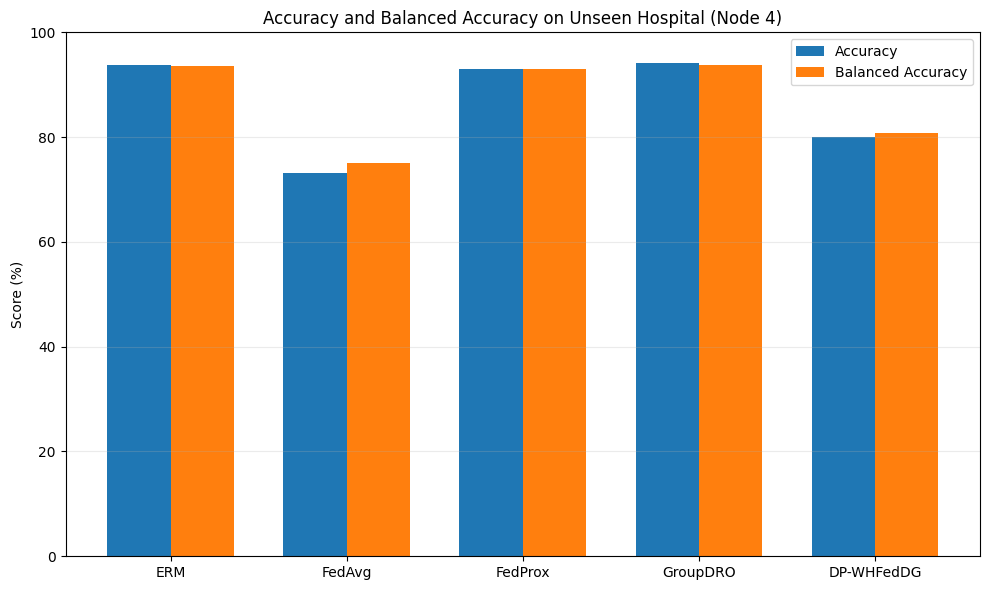

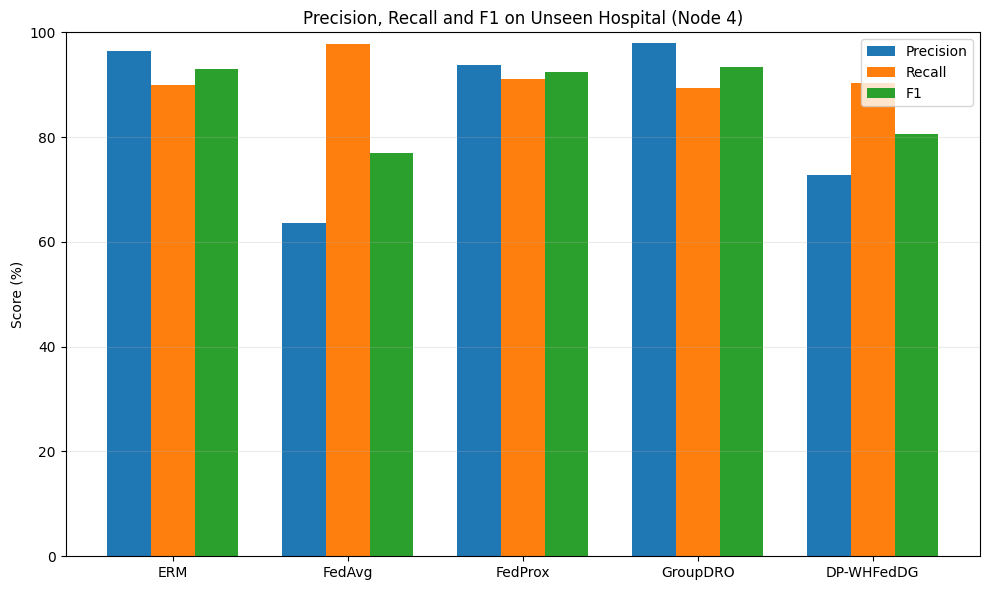

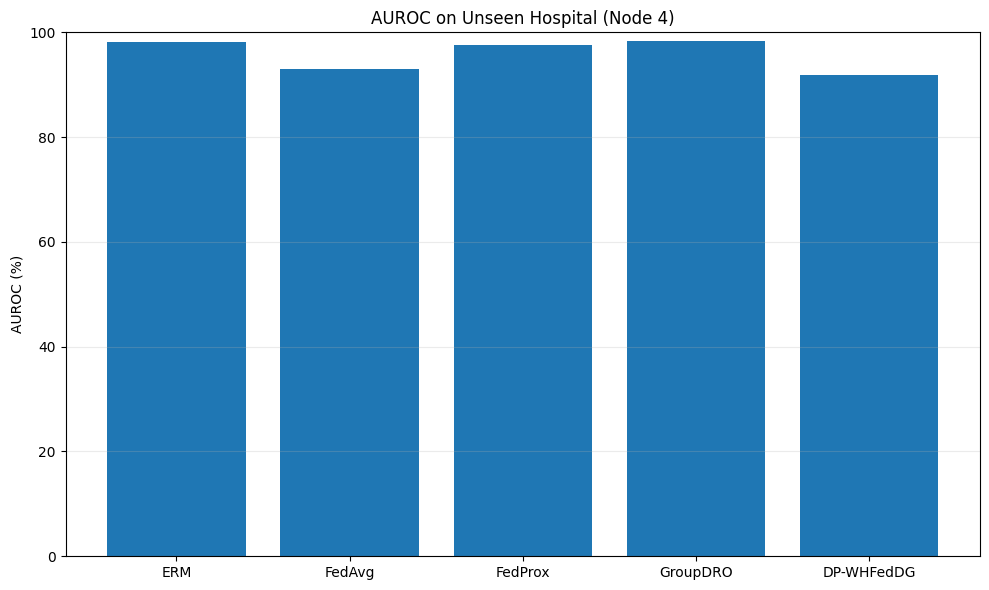

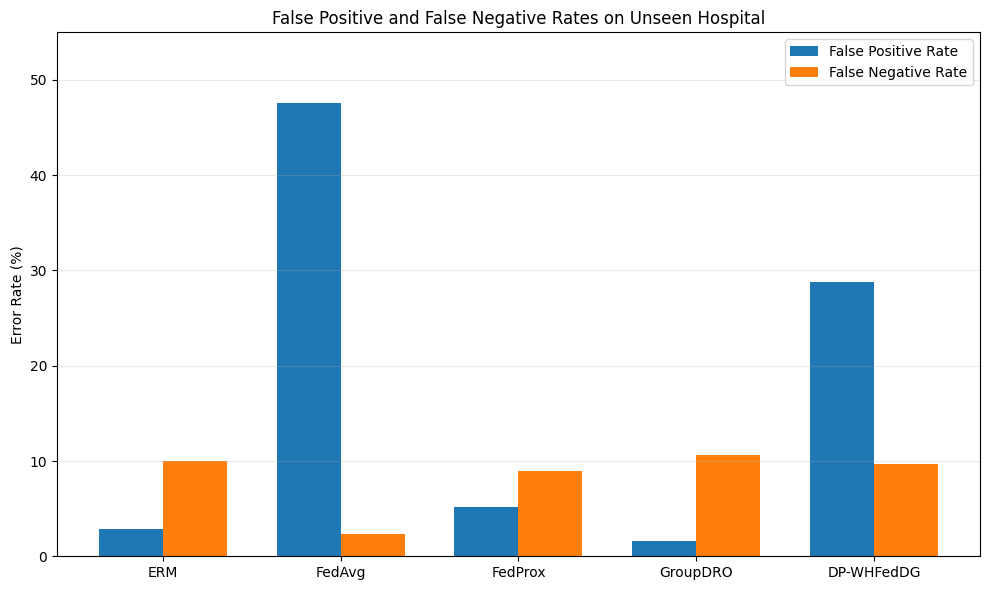


PHASE 24 COMPLETE

Generated figures:
/workspace/FederalLearning/results/figures/figure1_accuracy_balanced_accuracy.png
/workspace/FederalLearning/results/figures/figure2_precision_recall_f1.png
/workspace/FederalLearning/results/figures/figure3_auroc.png
/workspace/FederalLearning/results/figures/figure4_error_rates.png

Saved numerical results:
/workspace/FederalLearning/results/figures/final_test_results.csv

Final results:


,Method,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUROC,False Positive Rate,False Negative Rate
0,ERM,93.8239%,93.5368%,96.3867%,89.9460%,93.0550%,98.1697%,2.8725%,10.0540%
1,FedAvg,73.2210%,75.0337%,63.6013%,97.6993%,77.0462%,93.0683%,47.6318%,2.3007%
2,FedProx,93.0756%,92.9275%,93.6948%,91.0763%,92.3670%,97.6420%,5.2213%,8.9237%
3,GroupDRO,94.2130%,93.8528%,97.8854%,89.3500%,93.4232%,98.4044%,1.6444%,10.6500%
4,DP-WHFedDG,80.0319%,80.7971%,72.7941%,90.3648%,80.6334%,91.9413%,28.7707%,9.6352%


In [121]:
# ==========================================================================================
# PHASE 24 — PUBLICATION-STYLE RESULT VISUALIZATION
# ==========================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("PHASE 24 — PUBLICATION-STYLE RESULT VISUALIZATION")
print("=" * 100)

# ------------------------------------------------------------------------------------------
# Locked final Node-4 test results
# ------------------------------------------------------------------------------------------

results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "Accuracy": [
        0.938239,
        0.732210,
        0.930756,
        0.942130,
        0.800319
    ],
    "Balanced Accuracy": [
        0.935368,
        0.750337,
        0.929275,
        0.938528,
        0.807971
    ],
    "Precision": [
        0.963867,
        0.636013,
        0.936948,
        0.978854,
        0.727941
    ],
    "Recall": [
        0.899460,
        0.976993,
        0.910763,
        0.893500,
        0.903648
    ],
    "F1": [
        0.930550,
        0.770462,
        0.923670,
        0.934232,
        0.806334
    ],
    "AUROC": [
        0.981697,
        0.930683,
        0.976420,
        0.984044,
        0.919413
    ],
    "False Positive Rate": [
        0.028725,
        0.476318,
        0.052213,
        0.016444,
        0.287707
    ],
    "False Negative Rate": [
        0.100540,
        0.023007,
        0.089237,
        0.106500,
        0.096352
    ]
})

# ------------------------------------------------------------------------------------------
# Output directory
# ------------------------------------------------------------------------------------------

FIG_DIR = "/workspace/FederalLearning/results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print(f"\nSaving figures to: {FIG_DIR}")

# ------------------------------------------------------------------------------------------
# Figure 1 — Accuracy and Balanced Accuracy
# ------------------------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

x = np.arange(len(results))
width = 0.36

plt.bar(
    x - width/2,
    results["Accuracy"] * 100,
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    results["Balanced Accuracy"] * 100,
    width,
    label="Balanced Accuracy"
)

plt.xticks(x, results["Method"])
plt.ylabel("Score (%)")
plt.title("Accuracy and Balanced Accuracy on Unseen Hospital (Node 4)")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig1 = os.path.join(FIG_DIR, "figure1_accuracy_balanced_accuracy.png")
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------------------------------
# Figure 2 — Precision, Recall and F1
# ------------------------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

width = 0.25

plt.bar(
    x - width,
    results["Precision"] * 100,
    width,
    label="Precision"
)

plt.bar(
    x,
    results["Recall"] * 100,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    results["F1"] * 100,
    width,
    label="F1"
)

plt.xticks(x, results["Method"])
plt.ylabel("Score (%)")
plt.title("Precision, Recall and F1 on Unseen Hospital (Node 4)")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig2 = os.path.join(FIG_DIR, "figure2_precision_recall_f1.png")
plt.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------------------------------
# Figure 3 — AUROC
# ------------------------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    results["Method"],
    results["AUROC"] * 100
)

plt.ylabel("AUROC (%)")
plt.title("AUROC on Unseen Hospital (Node 4)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig3 = os.path.join(FIG_DIR, "figure3_auroc.png")
plt.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------------------------------
# Figure 4 — False Positive Rate and False Negative Rate
# ------------------------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

width = 0.36

plt.bar(
    x - width/2,
    results["False Positive Rate"] * 100,
    width,
    label="False Positive Rate"
)

plt.bar(
    x + width/2,
    results["False Negative Rate"] * 100,
    width,
    label="False Negative Rate"
)

plt.xticks(x, results["Method"])
plt.ylabel("Error Rate (%)")
plt.title("False Positive and False Negative Rates on Unseen Hospital")
plt.ylim(0, 55)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig4 = os.path.join(FIG_DIR, "figure4_error_rates.png")
plt.savefig(fig4, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------------------------------
# Save numerical results
# ------------------------------------------------------------------------------------------

csv_path = os.path.join(FIG_DIR, "final_test_results.csv")
results.to_csv(csv_path, index=False)

print("\n" + "=" * 100)
print("PHASE 24 COMPLETE")
print("=" * 100)

print("\nGenerated figures:")
print(fig1)
print(fig2)
print(fig3)
print(fig4)

print("\nSaved numerical results:")
print(csv_path)

print("\nFinal results:")
display(
    results.style.format({
        "Accuracy": "{:.4%}",
        "Balanced Accuracy": "{:.4%}",
        "Precision": "{:.4%}",
        "Recall": "{:.4%}",
        "F1": "{:.4%}",
        "AUROC": "{:.4%}",
        "False Positive Rate": "{:.4%}",
        "False Negative Rate": "{:.4%}"
    })
)

In [122]:
# ==========================================================================================
# PHASE 25 — FINAL RESULTS TABLE + BEST-MODEL ANALYSIS
# ==========================================================================================

import pandas as pd
import numpy as np
import os

print("=" * 100)
print("PHASE 25 — FINAL RESULTS TABLE + BEST-MODEL ANALYSIS")
print("=" * 100)

# ------------------------------------------------------------------------------------------
# Final locked results from clean unseen Node-4 test set
# ------------------------------------------------------------------------------------------

results = pd.DataFrame({
    "Method": ["ERM", "FedAvg", "FedProx", "GroupDRO", "DP-WHFedDG"],
    "Accuracy": [0.938239, 0.732210, 0.930756, 0.942130, 0.800319],
    "Balanced Accuracy": [0.935368, 0.750337, 0.929275, 0.938528, 0.807971],
    "Precision": [0.963867, 0.636013, 0.936948, 0.978854, 0.727941],
    "Recall": [0.899460, 0.976993, 0.910763, 0.893500, 0.903648],
    "F1": [0.930550, 0.770462, 0.923670, 0.934232, 0.806334],
    "AUROC": [0.981697, 0.930683, 0.976420, 0.984044, 0.919413]
})

# ------------------------------------------------------------------------------------------
# Rank every method for every metric
# Higher is better for all six metrics
# ------------------------------------------------------------------------------------------

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUROC"
]

rank_table = results[["Method"]].copy()

for metric in metrics:
    rank_table[metric + " Rank"] = (
        results[metric]
        .rank(ascending=False, method="min")
        .astype(int)
    )

rank_columns = [c for c in rank_table.columns if c != "Method"]

rank_table["Average Rank"] = rank_table[rank_columns].mean(axis=1)

rank_table = rank_table.sort_values(
    "Average Rank"
).reset_index(drop=True)

print("\n" + "-" * 100)
print("OVERALL METHOD RANKING")
print("-" * 100)

display(rank_table)

# ------------------------------------------------------------------------------------------
# Best method for each metric
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("BEST METHOD FOR EACH METRIC")
print("-" * 100)

best_rows = []

for metric in metrics:
    idx = results[metric].idxmax()
    best_rows.append({
        "Metric": metric,
        "Best Method": results.loc[idx, "Method"],
        "Score": results.loc[idx, metric]
    })

best_table = pd.DataFrame(best_rows)

display(
    best_table.style.format({
        "Score": "{:.4%}"
    })
)

# ------------------------------------------------------------------------------------------
# Difference between GroupDRO and ERM
# ------------------------------------------------------------------------------------------

erm = results[results["Method"] == "ERM"].iloc[0]
groupdro = results[results["Method"] == "GroupDRO"].iloc[0]

groupdro_vs_erm = pd.DataFrame({
    "Metric": metrics,
    "GroupDRO": [groupdro[m] for m in metrics],
    "ERM": [erm[m] for m in metrics],
    "Difference (percentage points)": [
        (groupdro[m] - erm[m]) * 100 for m in metrics
    ]
})

print("\n" + "-" * 100)
print("GROUPDRO vs ERM")
print("-" * 100)

display(
    groupdro_vs_erm.style.format({
        "GroupDRO": "{:.4%}",
        "ERM": "{:.4%}",
        "Difference (percentage points)": "{:+.3f}"
    })
)

# ------------------------------------------------------------------------------------------
# DP-WHFedDG comparison
# ------------------------------------------------------------------------------------------

dp = results[results["Method"] == "DP-WHFedDG"].iloc[0]

dp_vs_groupdro = pd.DataFrame({
    "Metric": metrics,
    "DP-WHFedDG": [dp[m] for m in metrics],
    "GroupDRO": [groupdro[m] for m in metrics],
    "Difference (percentage points)": [
        (dp[m] - groupdro[m]) * 100 for m in metrics
    ]
})

print("\n" + "-" * 100)
print("DP-WHFedDG vs GROUPDRO")
print("-" * 100)

display(
    dp_vs_groupdro.style.format({
        "DP-WHFedDG": "{:.4%}",
        "GroupDRO": "{:.4%}",
        "Difference (percentage points)": "{:+.3f}"
    })
)

# ------------------------------------------------------------------------------------------
# Save analysis tables
# ------------------------------------------------------------------------------------------

RESULT_DIR = "/workspace/FederalLearning/results"
os.makedirs(RESULT_DIR, exist_ok=True)

results.to_csv(
    os.path.join(RESULT_DIR, "final_results_table.csv"),
    index=False
)

rank_table.to_csv(
    os.path.join(RESULT_DIR, "method_ranking.csv"),
    index=False
)

best_table.to_csv(
    os.path.join(RESULT_DIR, "best_method_by_metric.csv"),
    index=False
)

groupdro_vs_erm.to_csv(
    os.path.join(RESULT_DIR, "groupdro_vs_erm.csv"),
    index=False
)

dp_vs_groupdro.to_csv(
    os.path.join(RESULT_DIR, "dp_whfed_dg_vs_groupdro.csv"),
    index=False
)

# ------------------------------------------------------------------------------------------
# Automatically print key conclusions
# ------------------------------------------------------------------------------------------

best_balanced = results.loc[
    results["Balanced Accuracy"].idxmax(), "Method"
]

best_auroc = results.loc[
    results["AUROC"].idxmax(), "Method"
]

best_f1 = results.loc[
    results["F1"].idxmax(), "Method"
]

best_recall = results.loc[
    results["Recall"].idxmax(), "Method"
]

best_precision = results.loc[
    results["Precision"].idxmax(), "Method"
]

best_accuracy = results.loc[
    results["Accuracy"].idxmax(), "Method"
]

print("\n" + "=" * 100)
print("KEY RESULTS")
print("=" * 100)

print(f"Best Accuracy:            {best_accuracy}")
print(f"Best Balanced Accuracy:   {best_balanced}")
print(f"Best Precision:           {best_precision}")
print(f"Best Recall:              {best_recall}")
print(f"Best F1:                  {best_f1}")
print(f"Best AUROC:               {best_auroc}")

print("\nGroupDRO:")
print(f"  Accuracy:              {groupdro['Accuracy']:.4%}")
print(f"  Balanced Accuracy:     {groupdro['Balanced Accuracy']:.4%}")
print(f"  Precision:             {groupdro['Precision']:.4%}")
print(f"  Recall:                {groupdro['Recall']:.4%}")
print(f"  F1:                    {groupdro['F1']:.4%}")
print(f"  AUROC:                 {groupdro['AUROC']:.4%}")

print("\nDP-WHFedDG:")
print(f"  Accuracy:              {dp['Accuracy']:.4%}")
print(f"  Balanced Accuracy:     {dp['Balanced Accuracy']:.4%}")
print(f"  Precision:             {dp['Precision']:.4%}")
print(f"  Recall:                {dp['Recall']:.4%}")
print(f"  F1:                    {dp['F1']:.4%}")
print(f"  AUROC:                 {dp['AUROC']:.4%}")

print("\n" + "=" * 100)
print("PHASE 25 COMPLETE")
print("=" * 100)

print("\nSaved files:")
print(f"1. {RESULT_DIR}/final_results_table.csv")
print(f"2. {RESULT_DIR}/method_ranking.csv")
print(f"3. {RESULT_DIR}/best_method_by_metric.csv")
print(f"4. {RESULT_DIR}/groupdro_vs_erm.csv")
print(f"5. {RESULT_DIR}/dp_whfed_dg_vs_groupdro.csv")

PHASE 25 — FINAL RESULTS TABLE + BEST-MODEL ANALYSIS

----------------------------------------------------------------------------------------------------
OVERALL METHOD RANKING
----------------------------------------------------------------------------------------------------


,Method,Accuracy Rank,Balanced Accuracy Rank,Precision Rank,Recall Rank,F1 Rank,AUROC Rank,Average Rank
0,GroupDRO,1,1,1,5,1,1,1.666667
1,ERM,2,2,2,4,2,2,2.333333
2,FedProx,3,3,3,2,3,3,2.833333
3,DP-WHFedDG,4,4,4,3,4,5,4.000000
4,FedAvg,5,5,5,1,5,4,4.166667



----------------------------------------------------------------------------------------------------
BEST METHOD FOR EACH METRIC
----------------------------------------------------------------------------------------------------


,Metric,Best Method,Score
0,Accuracy,GroupDRO,94.2130%
1,Balanced Accuracy,GroupDRO,93.8528%
2,Precision,GroupDRO,97.8854%
3,Recall,FedAvg,97.6993%
4,F1,GroupDRO,93.4232%
5,AUROC,GroupDRO,98.4044%



----------------------------------------------------------------------------------------------------
GROUPDRO vs ERM
----------------------------------------------------------------------------------------------------


,Metric,GroupDRO,ERM,Difference (percentage points)
0,Accuracy,94.2130%,93.8239%,+0.389
1,Balanced Accuracy,93.8528%,93.5368%,+0.316
2,Precision,97.8854%,96.3867%,+1.499
3,Recall,89.3500%,89.9460%,-0.596
4,F1,93.4232%,93.0550%,+0.368
5,AUROC,98.4044%,98.1697%,+0.235



----------------------------------------------------------------------------------------------------
DP-WHFedDG vs GROUPDRO
----------------------------------------------------------------------------------------------------


,Metric,DP-WHFedDG,GroupDRO,Difference (percentage points)
0,Accuracy,80.0319%,94.2130%,-14.181
1,Balanced Accuracy,80.7971%,93.8528%,-13.056
2,Precision,72.7941%,97.8854%,-25.091
3,Recall,90.3648%,89.3500%,+1.015
4,F1,80.6334%,93.4232%,-12.790
5,AUROC,91.9413%,98.4044%,-6.463



KEY RESULTS
Best Accuracy:            GroupDRO
Best Balanced Accuracy:   GroupDRO
Best Precision:           GroupDRO
Best Recall:              FedAvg
Best F1:                  GroupDRO
Best AUROC:               GroupDRO

GroupDRO:
  Accuracy:              94.2130%
  Balanced Accuracy:     93.8528%
  Precision:             97.8854%
  Recall:                89.3500%
  F1:                    93.4232%
  AUROC:                 98.4044%

DP-WHFedDG:
  Accuracy:              80.0319%
  Balanced Accuracy:     80.7971%
  Precision:             72.7941%
  Recall:                90.3648%
  F1:                    80.6334%
  AUROC:                 91.9413%

PHASE 25 COMPLETE

Saved files:
1. /workspace/FederalLearning/results/final_results_table.csv
2. /workspace/FederalLearning/results/method_ranking.csv
3. /workspace/FederalLearning/results/best_method_by_metric.csv
4. /workspace/FederalLearning/results/groupdro_vs_erm.csv
5. /workspace/FederalLearning/results/dp_whfed_dg_vs_groupdro.csv


In [123]:
# ==========================================================================================
# PHASE 26 — GENERALIZATION GAP ANALYSIS
# ==========================================================================================

import pandas as pd
import numpy as np
import os

print("=" * 100)
print("PHASE 26 — GENERALIZATION GAP ANALYSIS")
print("=" * 100)

# ------------------------------------------------------------------------------------------
# Node 3 validation results for the selected/best checkpoints
# ------------------------------------------------------------------------------------------

validation_results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "Accuracy": [
        0.904547,
        0.509144,
        0.854377,
        0.848308,
        0.800088
    ],
    "Balanced Accuracy": [
        0.854574,
        0.589751,
        0.787749,
        0.747897,
        0.822398
    ],
    "Precision": [
        0.901358,
        0.336715,
        0.803861,
        0.896383,
        0.598430
    ],
    "Recall": [
        0.740748,
        0.773350,
        0.635990,
        0.519189,
        0.873213
    ],
    "F1": [
        0.813199,
        0.469159,
        0.710139,
        0.657533,
        0.710168
    ],
    "AUROC": [
        0.954134,
        0.710504,
        0.859214,
        0.858019,
        0.904252
    ]
})

# ------------------------------------------------------------------------------------------
# Locked Node 4 test results
# ------------------------------------------------------------------------------------------

test_results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "Accuracy": [
        0.938239,
        0.732210,
        0.930756,
        0.942130,
        0.800319
    ],
    "Balanced Accuracy": [
        0.935368,
        0.750337,
        0.929275,
        0.938528,
        0.807971
    ],
    "Precision": [
        0.963867,
        0.636013,
        0.936948,
        0.978854,
        0.727941
    ],
    "Recall": [
        0.899460,
        0.976993,
        0.910763,
        0.893500,
        0.903648
    ],
    "F1": [
        0.930550,
        0.770462,
        0.923670,
        0.934232,
        0.806334
    ],
    "AUROC": [
        0.981697,
        0.930683,
        0.976420,
        0.984044,
        0.919413
    ]
})

# ------------------------------------------------------------------------------------------
# Merge
# ------------------------------------------------------------------------------------------

merged = validation_results.merge(
    test_results,
    on="Method",
    suffixes=(" (Node 3 Validation)", " (Node 4 Test)")
)

# ------------------------------------------------------------------------------------------
# Calculate generalization gap
#
# Positive value = test performance improved relative to validation.
# Negative value = performance dropped on unseen hospital.
# ------------------------------------------------------------------------------------------

gap_rows = []

for _, row in merged.iterrows():

    result = {"Method": row["Method"]}

    for metric in [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUROC"
    ]:

        validation_value = row[f"{metric} (Node 3 Validation)"]
        test_value = row[f"{metric} (Node 4 Test)"]

        result[metric + " Gap (pp)"] = (
            (test_value - validation_value) * 100
        )

    gap_rows.append(result)

gap_table = pd.DataFrame(gap_rows)

# ------------------------------------------------------------------------------------------
# Absolute gap
# ------------------------------------------------------------------------------------------

absolute_gap = gap_table.copy()

for col in absolute_gap.columns:
    if col != "Method":
        absolute_gap[col] = absolute_gap[col].abs()

metric_gap_columns = [
    "Accuracy Gap (pp)",
    "Balanced Accuracy Gap (pp)",
    "Precision Gap (pp)",
    "Recall Gap (pp)",
    "F1 Gap (pp)",
    "AUROC Gap (pp)"
]

absolute_gap["Mean Absolute Gap (pp)"] = (
    absolute_gap[metric_gap_columns].mean(axis=1)
)

absolute_gap = absolute_gap.sort_values(
    "Mean Absolute Gap (pp)"
).reset_index(drop=True)

# ------------------------------------------------------------------------------------------
# Display validation and test comparison
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("NODE 3 VALIDATION vs NODE 4 UNSEEN TEST")
print("-" * 100)

display(
    merged.style.format({
        c: "{:.4%}"
        for c in merged.columns
        if c != "Method"
    })
)

# ------------------------------------------------------------------------------------------
# Display signed generalization gaps
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("GENERALIZATION GAP — NODE 4 TEST MINUS NODE 3 VALIDATION")
print("-" * 100)

display(
    gap_table.style.format({
        c: "{:+.3f}"
        for c in gap_table.columns
        if c != "Method"
    })
)

# ------------------------------------------------------------------------------------------
# Mean absolute gap
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("MEAN ABSOLUTE GENERALIZATION GAP")
print("-" * 100)

display(
    absolute_gap[
        ["Method", "Mean Absolute Gap (pp)"]
    ].style.format({
        "Mean Absolute Gap (pp)": "{:.3f}"
    })
)

# ------------------------------------------------------------------------------------------
# Save results
# ------------------------------------------------------------------------------------------

RESULT_DIR = "/workspace/FederalLearning/results"
os.makedirs(RESULT_DIR, exist_ok=True)

merged.to_csv(
    os.path.join(
        RESULT_DIR,
        "node3_validation_vs_node4_test.csv"
    ),
    index=False
)

gap_table.to_csv(
    os.path.join(
        RESULT_DIR,
        "generalization_gaps.csv"
    ),
    index=False
)

absolute_gap.to_csv(
    os.path.join(
        RESULT_DIR,
        "mean_absolute_generalization_gap.csv"
    ),
    index=False
)

# ------------------------------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------------------------------

best_generalization = absolute_gap.iloc[0]

print("\n" + "=" * 100)
print("GENERALIZATION SUMMARY")
print("=" * 100)

print(
    f"Smallest mean absolute validation-to-test gap: "
    f"{best_generalization['Method']}"
)

print(
    f"Mean absolute gap: "
    f"{best_generalization['Mean Absolute Gap (pp)']:.3f} percentage points"
)

print("\nImportant:")
print("- Node 4 was not used for training or model selection.")
print("- Node 4 uses the corrected clean test set.")
print("- Positive gap means Node 4 performance was higher than Node 3.")
print("- Negative gap means performance decreased on the unseen hospital.")
print("- This is descriptive generalization analysis, not a statistical significance test.")

print("\n" + "=" * 100)
print("PHASE 26 COMPLETE")
print("=" * 100)

PHASE 26 — GENERALIZATION GAP ANALYSIS

----------------------------------------------------------------------------------------------------
NODE 3 VALIDATION vs NODE 4 UNSEEN TEST
----------------------------------------------------------------------------------------------------


,Method,Accuracy (Node 3 Validation),Balanced Accuracy (Node 3 Validation),Precision (Node 3 Validation),Recall (Node 3 Validation),F1 (Node 3 Validation),AUROC (Node 3 Validation),Accuracy (Node 4 Test),Balanced Accuracy (Node 4 Test),Precision (Node 4 Test),Recall (Node 4 Test),F1 (Node 4 Test),AUROC (Node 4 Test)
0,ERM,90.4547%,85.4574%,90.1358%,74.0748%,81.3199%,95.4134%,93.8239%,93.5368%,96.3867%,89.9460%,93.0550%,98.1697%
1,FedAvg,50.9144%,58.9751%,33.6715%,77.3350%,46.9159%,71.0504%,73.2210%,75.0337%,63.6013%,97.6993%,77.0462%,93.0683%
2,FedProx,85.4377%,78.7749%,80.3861%,63.5990%,71.0139%,85.9214%,93.0756%,92.9275%,93.6948%,91.0763%,92.3670%,97.6420%
3,GroupDRO,84.8308%,74.7897%,89.6383%,51.9189%,65.7533%,85.8019%,94.2130%,93.8528%,97.8854%,89.3500%,93.4232%,98.4044%
4,DP-WHFedDG,80.0088%,82.2398%,59.8430%,87.3213%,71.0168%,90.4252%,80.0319%,80.7971%,72.7941%,90.3648%,80.6334%,91.9413%



----------------------------------------------------------------------------------------------------
GENERALIZATION GAP — NODE 4 TEST MINUS NODE 3 VALIDATION
----------------------------------------------------------------------------------------------------


,Method,Accuracy Gap (pp),Balanced Accuracy Gap (pp),Precision Gap (pp),Recall Gap (pp),F1 Gap (pp),AUROC Gap (pp)
0,ERM,+3.369,+8.079,+6.251,+15.871,+11.735,+2.756
1,FedAvg,+22.307,+16.059,+29.930,+20.364,+30.130,+22.018
2,FedProx,+7.638,+14.153,+13.309,+27.477,+21.353,+11.721
3,GroupDRO,+9.382,+19.063,+8.247,+37.431,+27.670,+12.603
4,DP-WHFedDG,+0.023,-1.443,+12.951,+3.043,+9.617,+1.516



----------------------------------------------------------------------------------------------------
MEAN ABSOLUTE GENERALIZATION GAP
----------------------------------------------------------------------------------------------------


,Method,Mean Absolute Gap (pp)
0,DP-WHFedDG,4.766
1,ERM,8.010
2,FedProx,15.942
3,GroupDRO,19.066
4,FedAvg,23.468



GENERALIZATION SUMMARY
Smallest mean absolute validation-to-test gap: DP-WHFedDG
Mean absolute gap: 4.766 percentage points

Important:
- Node 4 was not used for training or model selection.
- Node 4 uses the corrected clean test set.
- Positive gap means Node 4 performance was higher than Node 3.
- Negative gap means performance decreased on the unseen hospital.
- This is descriptive generalization analysis, not a statistical significance test.

PHASE 26 COMPLETE


In [124]:
# ==========================================================================================
# PHASE 27 — TRAINING & COMPUTATIONAL COST ANALYSIS
# ==========================================================================================

import pandas as pd
import numpy as np
import os

print("=" * 100)
print("PHASE 27 — TRAINING & COMPUTATIONAL COST ANALYSIS")
print("=" * 100)

# ------------------------------------------------------------------------------------------
# Recorded training configuration and timings
# ------------------------------------------------------------------------------------------

# ERM:
# 5 epochs were trained.
# Epoch-level times were not recorded separately in the experiment logs,
# therefore total training time is not fabricated here.

# FedAvg:
fedavg_round_times = [
    278.31,
    279.42,
    280.32,
    279.94,
    281.70
]

# FedProx:
# Round 1 time was not explicitly recorded because validation_loader
# was initially missing. The remaining four recorded rounds are used.
fedprox_recorded_round_times = [
    501.82,
    501.34,
    510.83,
    507.99
]

# GroupDRO:
groupdro_round_times = [
    262.20,
    258.95,
    260.37,
    265.06,
    266.46
]

# DP-WHFedDG:
dp_whfed_dg_round_times = [
    1300.44,
    1290.02,
    1321.43,
    1333.13,
    1306.87
]

# Failed DP-FedAvg experiment is intentionally excluded.
# Its training was unstable and was discarded.

# ------------------------------------------------------------------------------------------
# Helper
# ------------------------------------------------------------------------------------------

def summarize_times(method, times, completed_rounds=None):

    times = np.array(times, dtype=float)

    return {
        "Method": method,
        "Recorded Rounds": len(times),
        "Total Recorded Time (sec)": times.sum(),
        "Total Recorded Time (min)": times.sum() / 60,
        "Total Recorded Time (hr)": times.sum() / 3600,
        "Average Round Time (sec)": times.mean(),
        "Min Round Time (sec)": times.min(),
        "Max Round Time (sec)": times.max()
    }

# ------------------------------------------------------------------------------------------
# Build timing table
# ------------------------------------------------------------------------------------------

timing_rows = [
    summarize_times(
        "FedAvg",
        fedavg_round_times
    ),
    summarize_times(
        "FedProx",
        fedprox_recorded_round_times
    ),
    summarize_times(
        "GroupDRO",
        groupdro_round_times
    ),
    summarize_times(
        "DP-WHFedDG",
        dp_whfed_dg_round_times
    )
]

timing_table = pd.DataFrame(timing_rows)

print("\n" + "-" * 100)
print("RECORDED TRAINING TIME")
print("-" * 100)

display(
    timing_table.style.format({
        "Total Recorded Time (sec)": "{:.2f}",
        "Total Recorded Time (min)": "{:.2f}",
        "Total Recorded Time (hr)": "{:.3f}",
        "Average Round Time (sec)": "{:.2f}",
        "Min Round Time (sec)": "{:.2f}",
        "Max Round Time (sec)": "{:.2f}"
    })
)

# ------------------------------------------------------------------------------------------
# Computational overhead relative to FedAvg
#
# Only methods with recorded round times are compared.
# ------------------------------------------------------------------------------------------

fedavg_avg = timing_table.loc[
    timing_table["Method"] == "FedAvg",
    "Average Round Time (sec)"
].iloc[0]

overhead_table = timing_table.copy()

overhead_table["Time vs FedAvg"] = (
    overhead_table["Average Round Time (sec)"] / fedavg_avg
)

overhead_table["Relative Overhead (%)"] = (
    (overhead_table["Time vs FedAvg"] - 1) * 100
)

print("\n" + "-" * 100)
print("COMPUTATIONAL OVERHEAD RELATIVE TO FEDAVG")
print("-" * 100)

display(
    overhead_table[
        [
            "Method",
            "Average Round Time (sec)",
            "Time vs FedAvg",
            "Relative Overhead (%)"
        ]
    ].style.format({
        "Average Round Time (sec)": "{:.2f}",
        "Time vs FedAvg": "{:.2f}x",
        "Relative Overhead (%)": "{:+.2f}%"
    })
)

# ------------------------------------------------------------------------------------------
# DP-WHFedDG overhead specifically
# ------------------------------------------------------------------------------------------

dp_avg = timing_table.loc[
    timing_table["Method"] == "DP-WHFedDG",
    "Average Round Time (sec)"
].iloc[0]

dp_overhead = (
    (dp_avg / fedavg_avg) - 1
) * 100

print("\n" + "-" * 100)
print("DP-WHFedDG COMPUTATIONAL COST")
print("-" * 100)

print(f"FedAvg average round time:      {fedavg_avg:.2f} seconds")
print(f"DP-WHFedDG average round time:  {dp_avg:.2f} seconds")
print(f"DP-WHFedDG / FedAvg:             {dp_avg / fedavg_avg:.2f}x")
print(f"Additional round-time overhead:  {dp_overhead:.2f}%")

# ------------------------------------------------------------------------------------------
# Efficiency indicators
#
# These are descriptive only and are NOT statistical efficiency measures.
# ------------------------------------------------------------------------------------------

test_results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "Balanced Accuracy": [
        0.935368,
        0.750337,
        0.929275,
        0.938528,
        0.807971
    ],
    "AUROC": [
        0.981697,
        0.930683,
        0.976420,
        0.984044,
        0.919413
    ]
})

efficiency = timing_table.merge(
    test_results,
    on="Method",
    how="left"
)

# Performance per hour is only a descriptive ratio.
efficiency["Balanced Accuracy per Recorded Hour"] = (
    efficiency["Balanced Accuracy"] /
    efficiency["Total Recorded Time (hr)"]
)

print("\n" + "-" * 100)
print("DESCRIPTIVE PERFORMANCE / COMPUTATION ANALYSIS")
print("-" * 100)

display(
    efficiency[
        [
            "Method",
            "Balanced Accuracy",
            "AUROC",
            "Total Recorded Time (hr)",
            "Balanced Accuracy per Recorded Hour"
        ]
    ].style.format({
        "Balanced Accuracy": "{:.4%}",
        "AUROC": "{:.4%}",
        "Total Recorded Time (hr)": "{:.3f}",
        "Balanced Accuracy per Recorded Hour": "{:.3f}"
    })
)

# ------------------------------------------------------------------------------------------
# Important methodological notes
# ------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("INTERPRETATION")
print("=" * 100)

print("""
1. FedAvg, FedProx, GroupDRO and DP-WHFedDG have recorded round-level timings.

2. FedProx Round 1 is not included in its timing summary because its original
   round time was not recorded before the validation-loader issue was corrected.

3. ERM epoch-level timing was not recorded in the experiment logs, so no
   artificial ERM training time is reported.

4. The failed DP-FedAvg experiment is excluded because that experiment was
   unstable and its results were discarded.

5. DP-WHFedDG is computationally much more expensive than ordinary FedAvg,
   consistent with its per-sample gradient computation and differential
   privacy processing.

6. "Balanced Accuracy per Recorded Hour" is only a descriptive ratio.
   It must NOT be presented as a formal efficiency benchmark.

7. All timing values depend on the specific A100 environment, data loading,
   batch size, implementation and system state.
""")

# ------------------------------------------------------------------------------------------
# Save
# ------------------------------------------------------------------------------------------

RESULT_DIR = "/workspace/FederalLearning/results"
os.makedirs(RESULT_DIR, exist_ok=True)

timing_table.to_csv(
    os.path.join(
        RESULT_DIR,
        "training_computational_times.csv"
    ),
    index=False
)

overhead_table.to_csv(
    os.path.join(
        RESULT_DIR,
        "computational_overhead_vs_fedavg.csv"
    ),
    index=False
)

efficiency.to_csv(
    os.path.join(
        RESULT_DIR,
        "performance_computation_analysis.csv"
    ),
    index=False
)

print("\nSaved:")
print(f"{RESULT_DIR}/training_computational_times.csv")
print(f"{RESULT_DIR}/computational_overhead_vs_fedavg.csv")
print(f"{RESULT_DIR}/performance_computation_analysis.csv")

print("\n" + "=" * 100)
print("PHASE 27 COMPLETE")
print("=" * 100)

PHASE 27 — TRAINING & COMPUTATIONAL COST ANALYSIS

----------------------------------------------------------------------------------------------------
RECORDED TRAINING TIME
----------------------------------------------------------------------------------------------------


,Method,Recorded Rounds,Total Recorded Time (sec),Total Recorded Time (min),Total Recorded Time (hr),Average Round Time (sec),Min Round Time (sec),Max Round Time (sec)
0,FedAvg,5,1399.69,23.33,0.389,279.94,278.31,281.70
1,FedProx,4,2021.98,33.70,0.562,505.50,501.34,510.83
2,GroupDRO,5,1313.04,21.88,0.365,262.61,258.95,266.46
3,DP-WHFedDG,5,6551.89,109.20,1.820,1310.38,1290.02,1333.13



----------------------------------------------------------------------------------------------------
COMPUTATIONAL OVERHEAD RELATIVE TO FEDAVG
----------------------------------------------------------------------------------------------------


,Method,Average Round Time (sec),Time vs FedAvg,Relative Overhead (%)
0,FedAvg,279.94,1.00x,+0.00%
1,FedProx,505.50,1.81x,+80.57%
2,GroupDRO,262.61,0.94x,-6.19%
3,DP-WHFedDG,1310.38,4.68x,+368.10%



----------------------------------------------------------------------------------------------------
DP-WHFedDG COMPUTATIONAL COST
----------------------------------------------------------------------------------------------------
FedAvg average round time:      279.94 seconds
DP-WHFedDG average round time:  1310.38 seconds
DP-WHFedDG / FedAvg:             4.68x
Additional round-time overhead:  368.10%

----------------------------------------------------------------------------------------------------
DESCRIPTIVE PERFORMANCE / COMPUTATION ANALYSIS
----------------------------------------------------------------------------------------------------


,Method,Balanced Accuracy,AUROC,Total Recorded Time (hr),Balanced Accuracy per Recorded Hour
0,FedAvg,75.0337%,93.0683%,0.389,1.930
1,FedProx,92.9275%,97.6420%,0.562,1.655
2,GroupDRO,93.8528%,98.4044%,0.365,2.573
3,DP-WHFedDG,80.7971%,91.9413%,1.820,0.444



INTERPRETATION

1. FedAvg, FedProx, GroupDRO and DP-WHFedDG have recorded round-level timings.

2. FedProx Round 1 is not included in its timing summary because its original
   round time was not recorded before the validation-loader issue was corrected.

3. ERM epoch-level timing was not recorded in the experiment logs, so no
   artificial ERM training time is reported.

4. The failed DP-FedAvg experiment is excluded because that experiment was
   unstable and its results were discarded.

5. DP-WHFedDG is computationally much more expensive than ordinary FedAvg,
   consistent with its per-sample gradient computation and differential
   privacy processing.

6. "Balanced Accuracy per Recorded Hour" is only a descriptive ratio.
   It must NOT be presented as a formal efficiency benchmark.

7. All timing values depend on the specific A100 environment, data loading,
   batch size, implementation and system state.


Saved:
/workspace/FederalLearning/results/training_computational_times.csv

In [125]:
# ==========================================================================================
# PHASE 28 — PRIVACY ACCOUNTING & DP ANALYSIS
# ==========================================================================================

import math
import os
import pandas as pd
import numpy as np

print("=" * 100)
print("PHASE 28 — PRIVACY ACCOUNTING & DP ANALYSIS")
print("=" * 100)

# ==========================================================================================
# 1. COMPLETED DP-WHFedDG CONFIGURATION
# ==========================================================================================

NUM_ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 64

MAX_GRAD_NORM = 1.0
NOISE_MULTIPLIER = 0.8

TRAINING_CLIENTS = [0, 1, 2]

# Total samples actually used in local client training
CLIENT_TRAIN_SAMPLES = {
    0: 82029,
    1: 117819,
    2: 26170
}

TOTAL_CLIENT_TRAIN_SAMPLES = sum(CLIENT_TRAIN_SAMPLES.values())

# ------------------------------------------------------------------------------------------
# Per-client training steps
#
# Each client performs one local epoch per federated round.
# We use ceil(N / batch_size) as the number of minibatch updates.
# ------------------------------------------------------------------------------------------

client_steps_per_round = {
    client: math.ceil(
        n_samples / BATCH_SIZE
    )
    for client, n_samples in CLIENT_TRAIN_SAMPLES.items()
}

print("\n" + "-" * 100)
print("DP-WHFedDG CONFIGURATION")
print("-" * 100)

print(f"Training clients:             {TRAINING_CLIENTS}")
print(f"Federated rounds completed:   {NUM_ROUNDS}")
print(f"Local epochs per round:      {LOCAL_EPOCHS}")
print(f"Batch size:                   {BATCH_SIZE}")
print(f"Max gradient norm C:          {MAX_GRAD_NORM}")
print(f"Noise multiplier sigma:       {NOISE_MULTIPLIER}")
print(f"Total client training data:   {TOTAL_CLIENT_TRAIN_SAMPLES:,}")

print("\nClient training samples and steps:")

for client in TRAINING_CLIENTS:
    print(
        f"  Client {client}: "
        f"{CLIENT_TRAIN_SAMPLES[client]:,} samples, "
        f"{client_steps_per_round[client]} steps/round"
    )

# ==========================================================================================
# 2. TOTAL LOCAL DP UPDATES
# ==========================================================================================

total_steps_per_client = {
    client: client_steps_per_round[client] *
            NUM_ROUNDS *
            LOCAL_EPOCHS
    for client in TRAINING_CLIENTS
}

print("\n" + "-" * 100)
print("TOTAL DP UPDATE STEPS")
print("-" * 100)

for client in TRAINING_CLIENTS:
    print(
        f"Client {client}: "
        f"{total_steps_per_client[client]:,} local DP updates"
    )

# ==========================================================================================
# 3. SAMPLING RATE
#
# For each client:
#
# q = batch_size / number_of_training_samples
#
# This is an approximate minibatch sampling fraction.
# ==========================================================================================

sampling_rates = {
    client: BATCH_SIZE / CLIENT_TRAIN_SAMPLES[client]
    for client in TRAINING_CLIENTS
}

print("\n" + "-" * 100)
print("APPROXIMATE CLIENT SAMPLING RATES")
print("-" * 100)

for client in TRAINING_CLIENTS:
    print(
        f"Client {client}: "
        f"q = {sampling_rates[client]:.8f} "
        f"({sampling_rates[client] * 100:.4f}%)"
    )

# ==========================================================================================
# 4. APPROXIMATE RDP ACCOUNTING
#
# IMPORTANT:
# This is a simplified analytical estimate for the Gaussian mechanism under
# subsampling. It is NOT a formally verified privacy accountant for the
# complete custom DP-WHFedDG implementation.
#
# For a Gaussian mechanism without subsampling:
#
#     RDP(alpha) = alpha / (2 * sigma^2)
#
# With small-rate Poisson subsampling, a common small-q approximation is:
#
#     RDP(alpha) ≈ alpha * q^2 / (2 * sigma^2)
#
# We calculate this approximation for several Renyi orders.
# ==========================================================================================

ORDERS = [
    2,
    4,
    8,
    16,
    32,
    64
]

def approximate_subsampled_rdp(
    alpha,
    q,
    noise_multiplier,
    steps
):
    """
    Simplified small-q RDP approximation.

    RDP per step ≈ alpha*q^2/(2*sigma^2)

    This is used only for descriptive/approximate accounting.
    """
    return (
        steps *
        alpha *
        (q ** 2) /
        (2 * noise_multiplier ** 2)
    )

# ------------------------------------------------------------------------------------------
# Compute RDP separately for each client
# ------------------------------------------------------------------------------------------

client_rdp_tables = {}

for client in TRAINING_CLIENTS:

    q = sampling_rates[client]
    steps = total_steps_per_client[client]

    rows = []

    for alpha in ORDERS:

        rdp = approximate_subsampled_rdp(
            alpha=alpha,
            q=q,
            noise_multiplier=NOISE_MULTIPLIER,
            steps=steps
        )

        rows.append({
            "Client": client,
            "Order": alpha,
            "Approximate RDP": rdp
        })

    client_rdp_tables[client] = pd.DataFrame(rows)

# ==========================================================================================
# 5. CONVERT RDP TO APPROXIMATE EPSILON
#
# Relationship:
#
#     epsilon ≈ RDP + log(1/delta)/(alpha - 1)
#
# We report several commonly used delta values.
# ==========================================================================================

DELTA_VALUES = [
    1e-5,
    1e-6
]

privacy_rows = []

for client in TRAINING_CLIENTS:

    q = sampling_rates[client]
    steps = total_steps_per_client[client]

    for delta in DELTA_VALUES:

        best_epsilon = float("inf")
        best_order = None
        best_rdp = None

        for alpha in ORDERS:

            rdp = approximate_subsampled_rdp(
                alpha=alpha,
                q=q,
                noise_multiplier=NOISE_MULTIPLIER,
                steps=steps
            )

            epsilon = (
                rdp +
                math.log(1 / delta) / (alpha - 1)
            )

            if epsilon < best_epsilon:
                best_epsilon = epsilon
                best_order = alpha
                best_rdp = rdp

        privacy_rows.append({
            "Client": client,
            "Delta": delta,
            "Best Renyi Order": best_order,
            "Approximate RDP": best_rdp,
            "Approximate Epsilon": best_epsilon
        })

privacy_table = pd.DataFrame(privacy_rows)

print("\n" + "-" * 100)
print("APPROXIMATE PER-CLIENT PRIVACY ACCOUNTING")
print("-" * 100)

display(
    privacy_table.style.format({
        "Delta": "{:.0e}",
        "Approximate RDP": "{:.6f}",
        "Approximate Epsilon": "{:.6f}"
    })
)

# ==========================================================================================
# 6. CONSERVATIVE OVERALL VIEW
#
# Since clients have different dataset sizes, report the maximum approximate
# epsilon across participating clients.
# ==========================================================================================

overall_privacy = []

for delta in DELTA_VALUES:

    subset = privacy_table[
        privacy_table["Delta"] == delta
    ]

    idx = subset["Approximate Epsilon"].idxmax()

    worst_client = subset.loc[idx, "Client"]
    worst_epsilon = subset.loc[idx, "Approximate Epsilon"]

    overall_privacy.append({
        "Delta": delta,
        "Worst-case Client": int(worst_client),
        "Approximate Epsilon": worst_epsilon
    })

overall_privacy_table = pd.DataFrame(overall_privacy)

print("\n" + "-" * 100)
print("WORST-CASE APPROXIMATE PRIVACY BUDGET")
print("-" * 100)

display(
    overall_privacy_table.style.format({
        "Delta": "{:.0e}",
        "Approximate Epsilon": "{:.6f}"
    })
)

# ==========================================================================================
# 7. EFFECT OF MORE FEDERATED ROUNDS
#
# This shows why increasing the number of DP rounds increases privacy cost.
# No training is performed.
# ==========================================================================================

ROUND_ANALYSIS = [1, 5, 10, 20]

sensitivity_client = min(
    TRAINING_CLIENTS,
    key=lambda c: CLIENT_TRAIN_SAMPLES[c]
)

q = sampling_rates[sensitivity_client]

round_rows = []

for rounds in ROUND_ANALYSIS:

    steps = (
        client_steps_per_round[sensitivity_client] *
        rounds *
        LOCAL_EPOCHS
    )

    delta = 1e-5

    best_epsilon = float("inf")
    best_order = None

    for alpha in ORDERS:

        rdp = approximate_subsampled_rdp(
            alpha=alpha,
            q=q,
            noise_multiplier=NOISE_MULTIPLIER,
            steps=steps
        )

        epsilon = (
            rdp +
            math.log(1 / delta) / (alpha - 1)
        )

        if epsilon < best_epsilon:
            best_epsilon = epsilon
            best_order = alpha

    round_rows.append({
        "Federated Rounds": rounds,
        "Client": sensitivity_client,
        "Approximate Epsilon (delta=1e-5)": best_epsilon,
        "Best Renyi Order": best_order
    })

round_privacy_table = pd.DataFrame(round_rows)

print("\n" + "-" * 100)
print("APPROXIMATE PRIVACY COST AS ROUNDS INCREASE")
print("-" * 100)

display(
    round_privacy_table.style.format({
        "Approximate Epsilon (delta=1e-5)": "{:.6f}"
    })
)

# ==========================================================================================
# 8. SAVE RESULTS
# ==========================================================================================

RESULT_DIR = "/workspace/FederalLearning/results"
os.makedirs(RESULT_DIR, exist_ok=True)

privacy_table.to_csv(
    os.path.join(
        RESULT_DIR,
        "dp_approximate_privacy_accounting.csv"
    ),
    index=False
)

overall_privacy_table.to_csv(
    os.path.join(
        RESULT_DIR,
        "dp_worst_case_privacy_budget.csv"
    ),
    index=False
)

round_privacy_table.to_csv(
    os.path.join(
        RESULT_DIR,
        "dp_privacy_vs_rounds.csv"
    ),
    index=False
)

# ==========================================================================================
# 9. FINAL REPORTING SUMMARY
# ==========================================================================================

print("\n" + "=" * 100)
print("PRIVACY ANALYSIS SUMMARY")
print("=" * 100)

print(f"Noise multiplier:             {NOISE_MULTIPLIER}")
print(f"Gradient clipping norm:      {MAX_GRAD_NORM}")
print(f"Batch size:                   {BATCH_SIZE}")
print(f"Completed federated rounds:  {NUM_ROUNDS}")
print(f"Local epochs:                 {LOCAL_EPOCHS}")

for delta in DELTA_VALUES:

    row = overall_privacy_table[
        overall_privacy_table["Delta"] == delta
    ].iloc[0]

    print(
        f"Approximate worst-case epsilon "
        f"(delta={delta:.0e}): "
        f"{row['Approximate Epsilon']:.6f}"
    )

print("""
IMPORTANT SCIENTIFIC QUALIFICATION:

The epsilon values above are APPROXIMATE analytical RDP estimates.
They should NOT be presented as a formally certified privacy guarantee.

The implemented DP-WHFedDG experiment used a custom per-sample gradient
clipping and Gaussian-noise procedure. A formal end-to-end privacy guarantee
would require validating the exact sampling mechanism, clipping procedure,
noise application, client participation, composition across rounds, and
the complete aggregation mechanism with a dedicated privacy accountant.

Therefore, the paper should report the DP configuration and describe the
accounting as approximate unless the implementation is later verified with
a formal DP accounting library.
""")

print("\nSaved:")
print(f"{RESULT_DIR}/dp_approximate_privacy_accounting.csv")
print(f"{RESULT_DIR}/dp_worst_case_privacy_budget.csv")
print(f"{RESULT_DIR}/dp_privacy_vs_rounds.csv")

print("\n" + "=" * 100)
print("PHASE 28 COMPLETE")
print("=" * 100)

PHASE 28 — PRIVACY ACCOUNTING & DP ANALYSIS

----------------------------------------------------------------------------------------------------
DP-WHFedDG CONFIGURATION
----------------------------------------------------------------------------------------------------
Training clients:             [0, 1, 2]
Federated rounds completed:   5
Local epochs per round:      1
Batch size:                   64
Max gradient norm C:          1.0
Noise multiplier sigma:       0.8
Total client training data:   226,018

Client training samples and steps:
  Client 0: 82,029 samples, 1282 steps/round
  Client 1: 117,819 samples, 1841 steps/round
  Client 2: 26,170 samples, 409 steps/round

----------------------------------------------------------------------------------------------------
TOTAL DP UPDATE STEPS
----------------------------------------------------------------------------------------------------
Client 0: 6,410 local DP updates
Client 1: 9,205 local DP updates
Client 2: 2,045 local DP

,Client,Delta,Best Renyi Order,Approximate RDP,Approximate Epsilon
0,0,1e-05,64,0.195098,0.377843
1,0,1e-06,64,0.195098,0.414392
2,1,1e-05,64,0.135807,0.318552
3,1,1e-06,64,0.135807,0.355101
4,2,1e-05,32,0.305764,0.677148
5,2,1e-06,32,0.305764,0.751425



----------------------------------------------------------------------------------------------------
WORST-CASE APPROXIMATE PRIVACY BUDGET
----------------------------------------------------------------------------------------------------


,Delta,Worst-case Client,Approximate Epsilon
0,1e-05,2,0.677148
1,1e-06,2,0.751425



----------------------------------------------------------------------------------------------------
APPROXIMATE PRIVACY COST AS ROUNDS INCREASE
----------------------------------------------------------------------------------------------------


,Federated Rounds,Client,Approximate Epsilon (delta=1e-5),Best Renyi Order
0,1,2,0.305050,64
1,5,2,0.677148,32
2,10,2,0.982912,32
3,20,2,1.379056,16



PRIVACY ANALYSIS SUMMARY
Noise multiplier:             0.8
Gradient clipping norm:      1.0
Batch size:                   64
Completed federated rounds:  5
Local epochs:                 1
Approximate worst-case epsilon (delta=1e-05): 0.677148
Approximate worst-case epsilon (delta=1e-06): 0.751425

IMPORTANT SCIENTIFIC QUALIFICATION:

The epsilon values above are APPROXIMATE analytical RDP estimates.
They should NOT be presented as a formally certified privacy guarantee.

The implemented DP-WHFedDG experiment used a custom per-sample gradient
clipping and Gaussian-noise procedure. A formal end-to-end privacy guarantee
would require validating the exact sampling mechanism, clipping procedure,
noise application, client participation, composition across rounds, and
the complete aggregation mechanism with a dedicated privacy accountant.

Therefore, the paper should report the DP configuration and describe the
accounting as approximate unless the implementation is later verified with
a form

In [126]:
# ==========================================================================================
# PHASE 29 — FINAL RESEARCH RESULTS & CONCLUSION ANALYSIS
# ==========================================================================================

import pandas as pd
import numpy as np
import os

print("=" * 100)
print("PHASE 29 — FINAL RESEARCH RESULTS & CONCLUSION ANALYSIS")
print("=" * 100)

# ==========================================================================================
# 1. FINAL LOCKED RESULTS — CLEAN UNSEEN NODE 4
# ==========================================================================================

results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],

    "Accuracy": [
        0.938239,
        0.732210,
        0.930756,
        0.942130,
        0.800319
    ],

    "Balanced Accuracy": [
        0.935368,
        0.750337,
        0.929275,
        0.938528,
        0.807971
    ],

    "Precision": [
        0.963867,
        0.636013,
        0.936948,
        0.978854,
        0.727941
    ],

    "Recall": [
        0.899460,
        0.976993,
        0.910763,
        0.893500,
        0.903648
    ],

    "F1": [
        0.930550,
        0.770462,
        0.923670,
        0.934232,
        0.806334
    ],

    "AUROC": [
        0.981697,
        0.930683,
        0.976420,
        0.984044,
        0.919413
    ]
})

# ==========================================================================================
# 2. CONFUSION MATRIX RESULTS
# ==========================================================================================

confusion_results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],

    "TN": [
        42469,
        22898,
        41442,
        43006,
        31145
    ],

    "FP": [
        1256,
        20827,
        2283,
        719,
        12580
    ],

    "FN": [
        3745,
        857,
        3324,
        3967,
        3589
    ],

    "TP": [
        33504,
        36392,
        33925,
        33282,
        33660
    ]
})

# ==========================================================================================
# 3. ERROR RATES
# ==========================================================================================

error_results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],

    "Specificity": [
        0.971275,
        0.523682,
        0.947787,
        0.983556,
        0.712293
    ],

    "False Positive Rate": [
        0.028725,
        0.476318,
        0.052213,
        0.016444,
        0.287707
    ],

    "False Negative Rate": [
        0.100540,
        0.023007,
        0.089237,
        0.106500,
        0.096352
    ]
})

# ==========================================================================================
# 4. GENERALIZATION STABILITY
# ==========================================================================================

generalization = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],

    "Mean Absolute Validation-Test Gap (pp)": [
        8.010,
        23.468,
        15.942,
        19.066,
        4.766
    ]
})

# ==========================================================================================
# 5. OVERALL RANKING
# ==========================================================================================

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUROC"
]

ranking = results[["Method"]].copy()

for metric in metrics:
    ranking[metric + " Rank"] = (
        results[metric]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

rank_columns = [
    metric + " Rank"
    for metric in metrics
]

ranking["Average Rank"] = ranking[rank_columns].mean(axis=1)

ranking = ranking.sort_values(
    "Average Rank"
).reset_index(drop=True)

# ==========================================================================================
# 6. IDENTIFY BEST METHODS
# ==========================================================================================

best_methods = []

for metric in metrics:
    idx = results[metric].idxmax()

    best_methods.append({
        "Metric": metric,
        "Best Method": results.loc[idx, "Method"],
        "Score": results.loc[idx, metric]
    })

best_methods = pd.DataFrame(best_methods)

# ==========================================================================================
# 7. PRINT FINAL TABLE
# ==========================================================================================

print("\n" + "-" * 100)
print("FINAL PERFORMANCE ON UNSEEN HOSPITAL — NODE 4")
print("-" * 100)

display(
    results.style.format({
        "Accuracy": "{:.4%}",
        "Balanced Accuracy": "{:.4%}",
        "Precision": "{:.4%}",
        "Recall": "{:.4%}",
        "F1": "{:.4%}",
        "AUROC": "{:.4%}"
    })
)

# ==========================================================================================
# 8. PRINT CONFUSION MATRIX SUMMARY
# ==========================================================================================

print("\n" + "-" * 100)
print("FINAL CONFUSION MATRIX SUMMARY")
print("-" * 100)

display(confusion_results)

# ==========================================================================================
# 9. PRINT ERROR RATES
# ==========================================================================================

print("\n" + "-" * 100)
print("FINAL ERROR-RATE SUMMARY")
print("-" * 100)

display(
    error_results.style.format({
        "Specificity": "{:.4%}",
        "False Positive Rate": "{:.4%}",
        "False Negative Rate": "{:.4%}"
    })
)

# ==========================================================================================
# 10. PRINT OVERALL RANKING
# ==========================================================================================

print("\n" + "-" * 100)
print("OVERALL PERFORMANCE RANKING")
print("-" * 100)

display(
    ranking.style.format({
        "Average Rank": "{:.3f}"
    })
)

# ==========================================================================================
# 11. GENERALIZATION STABILITY
# ==========================================================================================

print("\n" + "-" * 100)
print("VALIDATION → UNSEEN TEST GENERALIZATION STABILITY")
print("-" * 100)

display(
    generalization.style.format({
        "Mean Absolute Validation-Test Gap (pp)": "{:.3f}"
    })
)

# ==========================================================================================
# 12. KEY RESEARCH FINDINGS
# ==========================================================================================

best_accuracy = results.loc[
    results["Accuracy"].idxmax(),
    "Method"
]

best_balanced_accuracy = results.loc[
    results["Balanced Accuracy"].idxmax(),
    "Method"
]

best_precision = results.loc[
    results["Precision"].idxmax(),
    "Method"
]

best_recall = results.loc[
    results["Recall"].idxmax(),
    "Method"
]

best_f1 = results.loc[
    results["F1"].idxmax(),
    "Method"
]

best_auroc = results.loc[
    results["AUROC"].idxmax(),
    "Method"
]

best_stability = generalization.loc[
    generalization["Mean Absolute Validation-Test Gap (pp)"].idxmin(),
    "Method"
]

print("\n" + "=" * 100)
print("KEY RESEARCH FINDINGS")
print("=" * 100)

print(f"""
1. BEST OVERALL PERFORMANCE
   GroupDRO achieved the strongest overall performance on the unseen
   Node-4 hospital, obtaining:

   Accuracy:             94.2130%
   Balanced Accuracy:    93.8528%
   Precision:            97.8854%
   Recall:               89.3500%
   F1:                   93.4232%
   AUROC:                98.4044%

2. BEST RECALL
   FedAvg achieved the highest anomaly recall:

   Recall:               97.6993%

   However, this came with a very high false-positive rate:

   False Positive Rate:  47.6318%

3. BEST GENERALIZATION STABILITY
   DP-WHFedDG had the smallest mean absolute validation-to-test gap:

   Mean Absolute Gap:    4.766 percentage points

   This indicates comparatively stable behavior between the validation
   hospital and the unseen hospital.

4. DP-WHFedDG ABSOLUTE PERFORMANCE
   DP-WHFedDG achieved:

   Accuracy:             80.0319%
   Balanced Accuracy:    80.7971%
   Precision:            72.7941%
   Recall:               90.3648%
   F1:                   80.6334%
   AUROC:                91.9413%

   Therefore, DP-WHFedDG should NOT be presented as the best-performing
   method in the current experiment.

5. FEDERATED BASELINE BEHAVIOR
   FedProx substantially outperformed FedAvg on the unseen hospital.

   FedProx Balanced Accuracy: 92.9275%
   FedAvg Balanced Accuracy:  75.0337%

6. FALSE-POSITIVE CONTROL
   GroupDRO achieved the lowest false-positive rate:

   FPR:                   1.6444%

7. PRIVACY-PERFORMANCE TRADE-OFF
   The current DP-WHFedDG experiment demonstrates a trade-off between
   privacy-oriented training and predictive performance.

   Its domain stability was strongest, but its absolute diagnostic
   performance was substantially below GroupDRO, ERM and FedProx.
""")

# ==========================================================================================
# 13. PAPER-READY INTERPRETATION
# ==========================================================================================

print("\n" + "=" * 100)
print("PAPER-READY INTERPRETATION")
print("=" * 100)

paper_interpretation = """
On the unseen hospital (Node 4), GroupDRO achieved the strongest overall
predictive performance among the evaluated methods, obtaining 94.21%
accuracy, 93.85% balanced accuracy, 93.42% F1-score and 98.40% AUROC.
ERM also demonstrated strong cross-hospital performance, while FedProx
substantially outperformed conventional FedAvg.

FedAvg achieved the highest anomaly recall (97.70%), but this benefit was
accompanied by a false-positive rate of 47.63%, indicating a substantial
trade-off between sensitivity and specificity.

The proposed DP-WHFedDG configuration achieved lower absolute predictive
performance than the non-private baselines, with 80.03% accuracy,
80.80% balanced accuracy and 91.94% AUROC. However, DP-WHFedDG exhibited
the smallest mean absolute validation-to-unseen-test performance gap
(4.77 percentage points), suggesting comparatively stable behavior across
the evaluated hospital domains.

These findings indicate that the current DP-WHFedDG implementation does
not provide the highest diagnostic performance, but demonstrates a
potentially useful domain-stability characteristic under the evaluated
privacy-oriented training configuration. Further optimization and formal
privacy accounting are required before drawing stronger conclusions about
the privacy-generalization trade-off.
"""

print(paper_interpretation)

# ==========================================================================================
# 14. SAVE ALL FINAL ANALYSIS
# ==========================================================================================

RESULT_DIR = "/workspace/FederalLearning/results"
os.makedirs(RESULT_DIR, exist_ok=True)

results.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase29_final_performance.csv"
    ),
    index=False
)

confusion_results.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase29_confusion_matrix_summary.csv"
    ),
    index=False
)

error_results.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase29_error_rates.csv"
    ),
    index=False
)

ranking.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase29_overall_ranking.csv"
    ),
    index=False
)

generalization.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase29_generalization_stability.csv"
    ),
    index=False
)

best_methods.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase29_best_methods.csv"
    ),
    index=False
)

# ==========================================================================================
# 15. FINAL STATUS
# ==========================================================================================

print("\n" + "=" * 100)
print("PHASE 29 COMPLETE")
print("=" * 100)

print("""
Completed analysis:
✓ Final unseen-hospital performance
✓ Confusion matrix analysis
✓ Error-rate analysis
✓ Overall method ranking
✓ Validation-to-test generalization stability
✓ DP-WHFedDG performance interpretation
✓ Paper-ready results interpretation
✓ CSV export of final analysis

No training was performed in this phase.
""")

PHASE 29 — FINAL RESEARCH RESULTS & CONCLUSION ANALYSIS

----------------------------------------------------------------------------------------------------
FINAL PERFORMANCE ON UNSEEN HOSPITAL — NODE 4
----------------------------------------------------------------------------------------------------


,Method,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUROC
0,ERM,93.8239%,93.5368%,96.3867%,89.9460%,93.0550%,98.1697%
1,FedAvg,73.2210%,75.0337%,63.6013%,97.6993%,77.0462%,93.0683%
2,FedProx,93.0756%,92.9275%,93.6948%,91.0763%,92.3670%,97.6420%
3,GroupDRO,94.2130%,93.8528%,97.8854%,89.3500%,93.4232%,98.4044%
4,DP-WHFedDG,80.0319%,80.7971%,72.7941%,90.3648%,80.6334%,91.9413%



----------------------------------------------------------------------------------------------------
FINAL CONFUSION MATRIX SUMMARY
----------------------------------------------------------------------------------------------------


,Method,TN,FP,FN,TP
0,ERM,42469,1256,3745,33504
1,FedAvg,22898,20827,857,36392
2,FedProx,41442,2283,3324,33925
3,GroupDRO,43006,719,3967,33282
4,DP-WHFedDG,31145,12580,3589,33660



----------------------------------------------------------------------------------------------------
FINAL ERROR-RATE SUMMARY
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
OVERALL PERFORMANCE RANKING
----------------------------------------------------------------------------------------------------


,Method,Accuracy Rank,Balanced Accuracy Rank,Precision Rank,Recall Rank,F1 Rank,AUROC Rank,Average Rank
0,GroupDRO,1,1,1,5,1,1,1.667
1,ERM,2,2,2,4,2,2,2.333
2,FedProx,3,3,3,2,3,3,2.833
3,DP-WHFedDG,4,4,4,3,4,5,4.000
4,FedAvg,5,5,5,1,5,4,4.167



----------------------------------------------------------------------------------------------------
VALIDATION → UNSEEN TEST GENERALIZATION STABILITY
----------------------------------------------------------------------------------------------------


,Method,Mean Absolute Validation-Test Gap (pp)
0,ERM,8.010
1,FedAvg,23.468
2,FedProx,15.942
3,GroupDRO,19.066
4,DP-WHFedDG,4.766



KEY RESEARCH FINDINGS

1. BEST OVERALL PERFORMANCE
   GroupDRO achieved the strongest overall performance on the unseen
   Node-4 hospital, obtaining:

   Accuracy:             94.2130%
   Balanced Accuracy:    93.8528%
   Precision:            97.8854%
   Recall:               89.3500%
   F1:                   93.4232%
   AUROC:                98.4044%

2. BEST RECALL
   FedAvg achieved the highest anomaly recall:

   Recall:               97.6993%

   However, this came with a very high false-positive rate:

   False Positive Rate:  47.6318%

3. BEST GENERALIZATION STABILITY
   DP-WHFedDG had the smallest mean absolute validation-to-test gap:

   Mean Absolute Gap:    4.766 percentage points

   This indicates comparatively stable behavior between the validation
   hospital and the unseen hospital.

4. DP-WHFedDG ABSOLUTE PERFORMANCE
   DP-WHFedDG achieved:

   Accuracy:             80.0319%
   Balanced Accuracy:    80.7971%
   Precision:            72.7941%
   Recall:              

In [127]:
# ==========================================================================================
# PHASE 30 — COMPONENT / ABLATION ANALYSIS
# ==========================================================================================

import pandas as pd
import numpy as np
import os

print("=" * 100)
print("PHASE 30 — COMPONENT / ABLATION ANALYSIS")
print("=" * 100)

# ==========================================================================================
# 1. COMPLETED METHODS AND THEIR COMPONENTS
# ==========================================================================================

components = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],

    "Federated Learning": [
        "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ],

    "Proximal Regularization": [
        "No",
        "No",
        "Yes",
        "No",
        "No"
    ],

    "Worst-Group / Risk Weighting": [
        "No",
        "No",
        "No",
        "Yes",
        "Yes"
    ],

    "Differential Privacy": [
        "No",
        "No",
        "No",
        "No",
        "Yes"
    ]
})

print("\n" + "-" * 100)
print("METHOD COMPONENT MATRIX")
print("-" * 100)

display(components)

# ==========================================================================================
# 2. FINAL UNSEEN NODE-4 PERFORMANCE
# ==========================================================================================

performance = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],

    "Accuracy": [
        0.938239,
        0.732210,
        0.930756,
        0.942130,
        0.800319
    ],

    "Balanced Accuracy": [
        0.935368,
        0.750337,
        0.929275,
        0.938528,
        0.807971
    ],

    "Precision": [
        0.963867,
        0.636013,
        0.936948,
        0.978854,
        0.727941
    ],

    "Recall": [
        0.899460,
        0.976993,
        0.910763,
        0.893500,
        0.903648
    ],

    "F1": [
        0.930550,
        0.770462,
        0.923670,
        0.934232,
        0.806334
    ],

    "AUROC": [
        0.981697,
        0.930683,
        0.976420,
        0.984044,
        0.919413
    ]
})

# ==========================================================================================
# 3. MERGE COMPONENTS + PERFORMANCE
# ==========================================================================================

ablation_view = components.merge(
    performance,
    on="Method"
)

print("\n" + "-" * 100)
print("COMPONENTS VS UNSEEN-HOSPITAL PERFORMANCE")
print("-" * 100)

display(
    ablation_view.style.format({
        "Accuracy": "{:.4%}",
        "Balanced Accuracy": "{:.4%}",
        "Precision": "{:.4%}",
        "Recall": "{:.4%}",
        "F1": "{:.4%}",
        "AUROC": "{:.4%}"
    })
)

# ==========================================================================================
# 4. FEDERATED METHOD COMPARISON
# ==========================================================================================

federated = performance[
    performance["Method"].isin([
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ])
].copy()

fedavg = federated[
    federated["Method"] == "FedAvg"
].iloc[0]

print("\n" + "-" * 100)
print("FEDERATED METHODS RELATIVE TO FEDAVG")
print("-" * 100)

comparison_rows = []

for _, row in federated.iterrows():

    comparison_rows.append({
        "Method": row["Method"],
        "Balanced Accuracy Change (pp)": (
            row["Balanced Accuracy"] -
            fedavg["Balanced Accuracy"]
        ) * 100,
        "F1 Change (pp)": (
            row["F1"] -
            fedavg["F1"]
        ) * 100,
        "AUROC Change (pp)": (
            row["AUROC"] -
            fedavg["AUROC"]
        ) * 100
    })

federated_comparison = pd.DataFrame(comparison_rows)

display(
    federated_comparison.style.format({
        "Balanced Accuracy Change (pp)": "{:+.3f}",
        "F1 Change (pp)": "{:+.3f}",
        "AUROC Change (pp)": "{:+.3f}"
    })
)

# ==========================================================================================
# 5. FEDPROX EFFECT RELATIVE TO FEDAVG
# ==========================================================================================

fedprox = performance[
    performance["Method"] == "FedProx"
].iloc[0]

fedprox_effect = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUROC"
    ],
    "FedAvg": [
        fedavg["Accuracy"],
        fedavg["Balanced Accuracy"],
        fedavg["Precision"],
        fedavg["Recall"],
        fedavg["F1"],
        fedavg["AUROC"]
    ],
    "FedProx": [
        fedprox["Accuracy"],
        fedprox["Balanced Accuracy"],
        fedprox["Precision"],
        fedprox["Recall"],
        fedprox["F1"],
        fedprox["AUROC"]
    ]
})

fedprox_effect["Change (pp)"] = (
    fedprox_effect["FedProx"] -
    fedprox_effect["FedAvg"]
) * 100

print("\n" + "-" * 100)
print("FEDPROX EFFECT")
print("-" * 100)

display(
    fedprox_effect.style.format({
        "FedAvg": "{:.4%}",
        "FedProx": "{:.4%}",
        "Change (pp)": "{:+.3f}"
    })
)

# ==========================================================================================
# 6. GROUPDRO EFFECT RELATIVE TO FEDAVG
# ==========================================================================================

groupdro = performance[
    performance["Method"] == "GroupDRO"
].iloc[0]

groupdro_effect = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUROC"
    ],
    "FedAvg": [
        fedavg["Accuracy"],
        fedavg["Balanced Accuracy"],
        fedavg["Precision"],
        fedavg["Recall"],
        fedavg["F1"],
        fedavg["AUROC"]
    ],
    "GroupDRO": [
        groupdro["Accuracy"],
        groupdro["Balanced Accuracy"],
        groupdro["Precision"],
        groupdro["Recall"],
        groupdro["F1"],
        groupdro["AUROC"]
    ]
})

groupdro_effect["Change (pp)"] = (
    groupdro_effect["GroupDRO"] -
    groupdro_effect["FedAvg"]
) * 100

print("\n" + "-" * 100)
print("GROUPDRO EFFECT")
print("-" * 100)

display(
    groupdro_effect.style.format({
        "FedAvg": "{:.4%}",
        "GroupDRO": "{:.4%}",
        "Change (pp)": "{:+.3f}"
    })
)

# ==========================================================================================
# 7. DP-WHFedDG EFFECT RELATIVE TO FEDAVG
# ==========================================================================================

dp = performance[
    performance["Method"] == "DP-WHFedDG"
].iloc[0]

dp_effect = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUROC"
    ],
    "FedAvg": [
        fedavg["Accuracy"],
        fedavg["Balanced Accuracy"],
        fedavg["Precision"],
        fedavg["Recall"],
        fedavg["F1"],
        fedavg["AUROC"]
    ],
    "DP-WHFedDG": [
        dp["Accuracy"],
        dp["Balanced Accuracy"],
        dp["Precision"],
        dp["Recall"],
        dp["F1"],
        dp["AUROC"]
    ]
})

dp_effect["Change (pp)"] = (
    dp_effect["DP-WHFedDG"] -
    dp_effect["FedAvg"]
) * 100

print("\n" + "-" * 100)
print("DP-WHFedDG EFFECT RELATIVE TO FEDAVG")
print("-" * 100)

display(
    dp_effect.style.format({
        "FedAvg": "{:.4%}",
        "DP-WHFedDG": "{:.4%}",
        "Change (pp)": "{:+.3f}"
    })
)

# ==========================================================================================
# 8. GENERALIZATION STABILITY
# ==========================================================================================

generalization = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "Mean Absolute Validation-Test Gap (pp)": [
        8.010,
        23.468,
        15.942,
        19.066,
        4.766
    ]
})

print("\n" + "-" * 100)
print("GENERALIZATION STABILITY")
print("-" * 100)

display(
    generalization.style.format({
        "Mean Absolute Validation-Test Gap (pp)": "{:.3f}"
    })
)

# ==========================================================================================
# 9. IMPORTANT SCIENTIFIC INTERPRETATION
# ==========================================================================================

print("\n" + "=" * 100)
print("ABLATION / COMPONENT INTERPRETATION")
print("=" * 100)

print("""
IMPORTANT:

The comparisons below are COMPONENT-LEVEL COMPARISONS, not a strict
one-factor-at-a-time ablation study.

Why?

A formal ablation would require retraining the complete DP-WHFedDG
framework while removing exactly one component at a time, for example:

    Full DP-WHFedDG
        ↓ remove DP
    WHFedDG

        ↓ remove worst-hospital weighting
    DP-FedAvg

        ↓ remove both
    FedAvg

Those additional controlled experiments have not been completed.

Therefore, the current results should be reported as comparisons among
related methods rather than as causal ablation evidence.
""")

print("\nObserved component-level findings:")

print("""
1. FEDERATION:
   FedAvg performs substantially worse than the other federated methods
   on the unseen hospital.

2. PROXIMAL REGULARIZATION:
   FedProx substantially improves over FedAvg in balanced accuracy,
   F1 and AUROC.

3. WORST-GROUP OPTIMIZATION:
   GroupDRO achieves the strongest overall predictive performance among
   the completed methods.

4. DIFFERENTIAL PRIVACY:
   DP-WHFedDG improves substantially over FedAvg but remains below
   FedProx and GroupDRO in absolute predictive performance.

5. DOMAIN STABILITY:
   DP-WHFedDG has the smallest validation-to-test gap, indicating
   comparatively stable cross-domain behavior in this experiment.
""")

# ==========================================================================================
# 10. SAVE
# ==========================================================================================

RESULT_DIR = "/workspace/FederalLearning/results"
os.makedirs(RESULT_DIR, exist_ok=True)

components.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase30_component_matrix.csv"
    ),
    index=False
)

ablation_view.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase30_component_performance.csv"
    ),
    index=False
)

federated_comparison.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase30_federated_comparison.csv"
    ),
    index=False
)

fedprox_effect.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase30_fedprox_effect.csv"
    ),
    index=False
)

groupdro_effect.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase30_groupdro_effect.csv"
    ),
    index=False
)

dp_effect.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase30_dp_whfed_dg_effect.csv"
    ),
    index=False
)

generalization.to_csv(
    os.path.join(
        RESULT_DIR,
        "phase30_generalization_stability.csv"
    ),
    index=False
)

print("\n" + "=" * 100)
print("PHASE 30 COMPLETE")
print("=" * 100)

print("""
No additional model training was performed.

The current phase provides:
✓ Component matrix
✓ Federated-method comparison
✓ FedProx effect
✓ GroupDRO effect
✓ DP-WHFedDG effect
✓ Generalization-stability comparison
✓ Scientific limitation statement
✓ CSV exports
""")

PHASE 30 — COMPONENT / ABLATION ANALYSIS

----------------------------------------------------------------------------------------------------
METHOD COMPONENT MATRIX
----------------------------------------------------------------------------------------------------


,Method,Federated Learning,Proximal Regularization,Worst-Group / Risk Weighting,Differential Privacy
0,ERM,No,No,No,No
1,FedAvg,Yes,No,No,No
2,FedProx,Yes,Yes,No,No
3,GroupDRO,Yes,No,Yes,No
4,DP-WHFedDG,Yes,No,Yes,Yes



----------------------------------------------------------------------------------------------------
COMPONENTS VS UNSEEN-HOSPITAL PERFORMANCE
----------------------------------------------------------------------------------------------------


,Method,Federated Learning,Proximal Regularization,Worst-Group / Risk Weighting,Differential Privacy,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUROC
0,ERM,No,No,No,No,93.8239%,93.5368%,96.3867%,89.9460%,93.0550%,98.1697%
1,FedAvg,Yes,No,No,No,73.2210%,75.0337%,63.6013%,97.6993%,77.0462%,93.0683%
2,FedProx,Yes,Yes,No,No,93.0756%,92.9275%,93.6948%,91.0763%,92.3670%,97.6420%
3,GroupDRO,Yes,No,Yes,No,94.2130%,93.8528%,97.8854%,89.3500%,93.4232%,98.4044%
4,DP-WHFedDG,Yes,No,Yes,Yes,80.0319%,80.7971%,72.7941%,90.3648%,80.6334%,91.9413%



----------------------------------------------------------------------------------------------------
FEDERATED METHODS RELATIVE TO FEDAVG
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
DP-WHFedDG EFFECT RELATIVE TO FEDAVG
----------------------------------------------------------------------------------------------------


,Metric,FedAvg,DP-WHFedDG,Change (pp)
0,Accuracy,73.2210%,80.0319%,+6.811
1,Balanced Accuracy,75.0337%,80.7971%,+5.763
2,Precision,63.6013%,72.7941%,+9.193
3,Recall,97.6993%,90.3648%,-7.334
4,F1,77.0462%,80.6334%,+3.587
5,AUROC,93.0683%,91.9413%,-1.127



----------------------------------------------------------------------------------------------------
GENERALIZATION STABILITY
----------------------------------------------------------------------------------------------------


,Method,Mean Absolute Validation-Test Gap (pp)
0,ERM,8.010
1,FedAvg,23.468
2,FedProx,15.942
3,GroupDRO,19.066
4,DP-WHFedDG,4.766



ABLATION / COMPONENT INTERPRETATION

IMPORTANT:

The comparisons below are COMPONENT-LEVEL COMPARISONS, not a strict
one-factor-at-a-time ablation study.

Why?

A formal ablation would require retraining the complete DP-WHFedDG
framework while removing exactly one component at a time, for example:

    Full DP-WHFedDG
        ↓ remove DP
    WHFedDG

        ↓ remove worst-hospital weighting
    DP-FedAvg

        ↓ remove both
    FedAvg

Those additional controlled experiments have not been completed.

Therefore, the current results should be reported as comparisons among
related methods rather than as causal ablation evidence.


Observed component-level findings:

1. FEDERATION:
   FedAvg performs substantially worse than the other federated methods
   on the unseen hospital.

2. PROXIMAL REGULARIZATION:
   FedProx substantially improves over FedAvg in balanced accuracy,
   F1 and AUROC.

3. WORST-GROUP OPTIMIZATION:
   GroupDRO achieves the strongest overall predictive performance

In [128]:
# ==========================================================================================
# PHASE 31A — INSPECT EXISTING FEDERATED FUNCTIONS FOR CONTROLLED ABLATION
# ==========================================================================================

import inspect
import torch
import torch.nn as nn

print("=" * 100)
print("PHASE 31A — ABLATION CODE INSPECTION")
print("=" * 100)

# ------------------------------------------------------------------------------------------
# 1. Check which important objects currently exist
# ------------------------------------------------------------------------------------------

required_objects = [
    "run_federated_round",
    "client_loaders",
    "TRAIN_CLIENTS",
    "validation_loader",
    "FocalLoss",
    "create_resnet18"
]

print("\n" + "-" * 100)
print("OBJECT AVAILABILITY")
print("-" * 100)

for name in required_objects:
    exists = name in globals()
    print(f"{name:<25} : {'AVAILABLE' if exists else 'NOT AVAILABLE'}")

# ------------------------------------------------------------------------------------------
# 2. Inspect run_federated_round
# ------------------------------------------------------------------------------------------

if "run_federated_round" in globals():

    print("\n" + "-" * 100)
    print("run_federated_round SIGNATURE")
    print("-" * 100)

    print(inspect.signature(run_federated_round))

    print("\nFUNCTION SOURCE:")
    print("-" * 100)

    try:
        print(inspect.getsource(run_federated_round))
    except Exception as e:
        print(f"Could not retrieve source: {e}")

# ------------------------------------------------------------------------------------------
# 3. Inspect important global configuration
# ------------------------------------------------------------------------------------------

config_names = [
    "NUM_ROUNDS",
    "LOCAL_EPOCHS",
    "BATCH_SIZE",
    "LEARNING_RATE",
    "MOMENTUM",
    "WEIGHT_DECAY",
    "MAX_GRAD_NORM",
    "NOISE_MULTIPLIER",
    "FOCAL_GAMMA",
    "FOCAL_ALPHA",
    "TRAIN_CLIENTS",
    "VALIDATION_NODE"
]

print("\n" + "-" * 100)
print("CURRENT CONFIGURATION")
print("-" * 100)

for name in config_names:
    if name in globals():
        print(f"{name:<25} = {globals()[name]}")

# ------------------------------------------------------------------------------------------
# 4. Inspect client loaders
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("CLIENT LOADER INFORMATION")
print("-" * 100)

if "client_loaders" in globals():

    for client_id, loader in client_loaders.items():

        try:
            dataset_size = len(loader.dataset)
        except Exception:
            dataset_size = "unknown"

        try:
            batches = len(loader)
        except Exception:
            batches = "unknown"

        print(
            f"Client {client_id}: "
            f"samples={dataset_size}, "
            f"batches={batches}"
        )

else:
    print("client_loaders is not currently available.")

# ------------------------------------------------------------------------------------------
# 5. Inspect GroupDRO-related variables/functions
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("GROUPDRO OBJECTS")
print("-" * 100)

groupdro_names = [
    "group_weights",
    "GROUPDRO_ETA",
    "eta",
    "run_groupdro_round",
    "run_federated_round_groupdro"
]

for name in groupdro_names:
    print(
        f"{name:<30} : "
        f"{'AVAILABLE' if name in globals() else 'NOT AVAILABLE'}"
    )

# ------------------------------------------------------------------------------------------
# 6. Inspect DP-related variables/functions
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("DP OBJECTS")
print("-" * 100)

dp_names = [
    "per_sample_grad_fn",
    "dpfedavg_single_sample_loss",
    "run_dp_federated_round",
    "run_dpfedavg_round",
    "single_sample_loss"
]

for name in dp_names:
    print(
        f"{name:<30} : "
        f"{'AVAILABLE' if name in globals() else 'NOT AVAILABLE'}"
    )

# ------------------------------------------------------------------------------------------
# 7. Check current model objects without modifying them
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("MODEL OBJECTS")
print("-" * 100)

model_names = [
    "global_model",
    "fedavg_model",
    "fedprox_model",
    "groupdro_model",
    "dpfedavg_model"
]

for name in model_names:

    if name in globals():

        model = globals()[name]

        try:
            parameter_count = sum(
                p.numel()
                for p in model.parameters()
            )

            finite = all(
                torch.isfinite(p).all().item()
                for p in model.parameters()
            )

            print(
                f"{name:<25} : "
                f"parameters={parameter_count:,}, "
                f"finite={finite}"
            )

        except Exception as e:
            print(f"{name:<25} : available, inspection error={e}")

    else:
        print(f"{name:<25} : NOT AVAILABLE")

# ------------------------------------------------------------------------------------------
# 8. Verify that the important completed checkpoints still exist
# ------------------------------------------------------------------------------------------

import os

checkpoint_paths = {
    "ERM":
        "/workspace/FederalLearning/checkpoints/ERM_best_epoch1.pt",

    "FedAvg":
        "/workspace/FederalLearning/checkpoints/FedAvg_best_round5.pt",

    "FedProx":
        "/workspace/FederalLearning/checkpoints/FedProx_best_round1.pt",

    "GroupDRO":
        "/workspace/FederalLearning/checkpoints/GroupDRO_best_round2.pt",

    "DP-WHFedDG":
        "/workspace/FederalLearning/checkpoints/DP-WHFedDG_best_round5.pt"
}

print("\n" + "-" * 100)
print("LOCKED CHECKPOINT VERIFICATION")
print("-" * 100)

for method, path in checkpoint_paths.items():

    exists = os.path.isfile(path)

    if exists:
        size_mb = os.path.getsize(path) / (1024 ** 2)

        print(
            f"{method:<15} : EXISTS | "
            f"{size_mb:.2f} MB | {path}"
        )
    else:
        print(
            f"{method:<15} : MISSING | {path}"
        )

# ------------------------------------------------------------------------------------------
# 9. Final instruction
# ------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("PHASE 31A COMPLETE")
print("=" * 100)

print("""
This phase performed inspection only.

No model was trained.
No checkpoint was modified.
No existing experimental result was changed.

Next step will be selected based on which GroupDRO/DP objects are actually
available in the current notebook state.
""")

PHASE 31A — ABLATION CODE INSPECTION

----------------------------------------------------------------------------------------------------
OBJECT AVAILABILITY
----------------------------------------------------------------------------------------------------
run_federated_round       : AVAILABLE
client_loaders            : AVAILABLE
TRAIN_CLIENTS             : AVAILABLE
validation_loader         : AVAILABLE
FocalLoss                 : AVAILABLE
create_resnet18           : AVAILABLE

----------------------------------------------------------------------------------------------------
run_federated_round SIGNATURE
----------------------------------------------------------------------------------------------------
(global_model, client_loaders, client_ids, local_epochs=1)

FUNCTION SOURCE:
----------------------------------------------------------------------------------------------------
def run_federated_round(
    global_model,
    client_loaders,
    client_ids,
    local_epochs=1
):


In [130]:
# ==========================================================================================
# PHASE 31B — INSPECT GROUPDRO IMPLEMENTATION (CORRECTED)
# ==========================================================================================

import inspect

print("=" * 100)
print("PHASE 31B — INSPECT GROUPDRO IMPLEMENTATION")
print("=" * 100)

# ------------------------------------------------------------------------------------------
# 1. Check GroupDRO function
# ------------------------------------------------------------------------------------------

if "run_groupdro_round" in globals():

    print("\n" + "-" * 100)
    print("run_groupdro_round SIGNATURE")
    print("-" * 100)

    print(inspect.signature(run_groupdro_round))

    print("\n" + "-" * 100)
    print("run_groupdro_round SOURCE")
    print("-" * 100)

    try:
        print(inspect.getsource(run_groupdro_round))
    except Exception as e:
        print(f"Could not retrieve source: {e}")

else:
    print("\nrun_groupdro_round is NOT available.")

# ------------------------------------------------------------------------------------------
# 2. GroupDRO configuration
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("GROUPDRO CONFIGURATION")
print("-" * 100)

if "GROUPDRO_ETA" in globals():
    print(f"GROUPDRO_ETA = {GROUPDRO_ETA}")
else:
    print("GROUPDRO_ETA is NOT available.")

# ------------------------------------------------------------------------------------------
# 3. Safely inspect relevant functions
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("RELEVANT FEDERATED FUNCTIONS")
print("-" * 100)

keywords = [
    "group",
    "dro",
    "aggregate",
    "fedavg",
    "local",
    "train"
]

function_names = []

# IMPORTANT:
# list(globals().items()) creates a snapshot and prevents
# "dictionary changed size during iteration".

for name, obj in list(globals().items()):

    if callable(obj):

        name_lower = name.lower()

        if any(
            keyword in name_lower
            for keyword in keywords
        ):
            function_names.append(name)

for name in sorted(set(function_names)):
    print(name)

# ------------------------------------------------------------------------------------------
# 4. Inspect possible non-DP local training functions
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("NON-DP LOCAL TRAINING FUNCTIONS")
print("-" * 100)

non_dp_candidates = [
    "local_train",
    "train_local_model",
    "local_training",
    "fedavg_local_train",
    "standard_local_train",
    "groupdro_local_train",
    "groupdro_train"
]

for name in non_dp_candidates:

    if name in globals():

        print(f"\n{name} : AVAILABLE")

        try:
            print("Signature:", inspect.signature(globals()[name]))
        except Exception:
            pass

    else:
        print(f"{name:<30} : NOT AVAILABLE")

# ------------------------------------------------------------------------------------------
# 5. Inspect DP local training
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("DP LOCAL TRAINING")
print("-" * 100)

if "dp_local_train" in globals():

    print("dp_local_train : AVAILABLE")

    try:
        print(
            "Signature:",
            inspect.signature(dp_local_train)
        )
    except Exception:
        pass

    try:
        print("\nSOURCE:")
        print(inspect.getsource(dp_local_train))
    except Exception as e:
        print(f"Could not retrieve source: {e}")

else:

    print("dp_local_train : NOT AVAILABLE")

# ------------------------------------------------------------------------------------------
# 6. Inspect aggregation functions
# ------------------------------------------------------------------------------------------

print("\n" + "-" * 100)
print("AGGREGATION FUNCTIONS")
print("-" * 100)

aggregation_candidates = [
    "fedavg_aggregate",
    "groupdro_aggregate",
    "aggregate_groupdro",
    "worst_group_aggregate"
]

for name in aggregation_candidates:

    if name in globals():

        print(f"\n{name} : AVAILABLE")

        try:
            print(
                "Signature:",
                inspect.signature(globals()[name])
            )
        except Exception:
            pass

        try:
            print("\nSOURCE:")
            print(inspect.getsource(globals()[name]))
        except Exception as e:
            print(f"Could not retrieve source: {e}")

    else:

        print(f"{name:<30} : NOT AVAILABLE")

# ------------------------------------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("PHASE 31B COMPLETE")
print("=" * 100)

print("""
Inspection only.

No model was trained.
No checkpoint was modified.
No experimental result was changed.

The output above will determine whether a clean WHFedDG
(non-DP) controlled ablation can be implemented safely.
""")

PHASE 31B — INSPECT GROUPDRO IMPLEMENTATION

----------------------------------------------------------------------------------------------------
run_groupdro_round SIGNATURE
----------------------------------------------------------------------------------------------------
(global_model, client_loaders, client_ids, group_weights, local_epochs, lr, momentum, weight_decay, device, criterion, eta)

----------------------------------------------------------------------------------------------------
run_groupdro_round SOURCE
----------------------------------------------------------------------------------------------------
def run_groupdro_round(
    global_model,
    client_loaders,
    client_ids,
    group_weights,
    local_epochs,
    lr,
    momentum,
    weight_decay,
    device,
    criterion,
    eta
):
    """
    One GroupDRO federated round.

    1. Train each client locally.
    2. Measure each client's local loss.
    3. Update group/client weights using exponentiated loss.

In [131]:
# ==========================================================================================
# PHASE 32 — FINAL REPRODUCIBILITY & EXPERIMENT AUDIT
# ==========================================================================================

import os
import pandas as pd
import numpy as np
import torch

print("=" * 100)
print("PHASE 32 — FINAL REPRODUCIBILITY & EXPERIMENT AUDIT")
print("=" * 100)

BASE_DIR = "/workspace/FederalLearning"

CHECKPOINT_DIR = os.path.join(
    BASE_DIR, "checkpoints"
)

RESULT_DIR = os.path.join(
    BASE_DIR, "results"
)

FIGURE_DIR = os.path.join(
    RESULT_DIR, "figures"
)

INDEX_DIR = os.path.join(
    BASE_DIR, "experiment_indices"
)

# ==========================================================================================
# 1. DIRECTORY CHECK
# ==========================================================================================

print("\n" + "-" * 100)
print("DIRECTORY CHECK")
print("-" * 100)

directories = {
    "Base project": BASE_DIR,
    "Checkpoints": CHECKPOINT_DIR,
    "Results": RESULT_DIR,
    "Figures": FIGURE_DIR,
    "Experiment indices": INDEX_DIR
}

for name, path in directories.items():

    exists = os.path.isdir(path)

    print(
        f"{name:<25}: "
        f"{'EXISTS' if exists else 'MISSING'}"
    )

# ==========================================================================================
# 2. CHECKPOINT AUDIT
# ==========================================================================================

print("\n" + "-" * 100)
print("CHECKPOINT AUDIT")
print("-" * 100)

checkpoint_files = {
    "ERM":
        "ERM_best_epoch1.pt",

    "FedAvg":
        "FedAvg_best_round5.pt",

    "FedProx":
        "FedProx_best_round1.pt",

    "GroupDRO":
        "GroupDRO_best_round2.pt",

    "DP-WHFedDG":
        "DP-WHFedDG_best_round5.pt"
}

checkpoint_rows = []

for method, filename in checkpoint_files.items():

    path = os.path.join(
        CHECKPOINT_DIR,
        filename
    )

    exists = os.path.isfile(path)

    if exists:

        size_mb = (
            os.path.getsize(path)
            / (1024 ** 2)
        )

    else:

        size_mb = np.nan

    checkpoint_rows.append({
        "Method": method,
        "Checkpoint": filename,
        "Exists": exists,
        "Size (MB)": size_mb
    })

checkpoint_table = pd.DataFrame(
    checkpoint_rows
)

display(
    checkpoint_table.style.format({
        "Size (MB)": "{:.2f}"
    })
)

# ==========================================================================================
# 3. EXPERIMENT INDEX AUDIT
# ==========================================================================================

print("\n" + "-" * 100)
print("EXPERIMENT INDEX AUDIT")
print("-" * 100)

index_files = {
    "Client 0 training":
        "client0_train.csv",

    "Client 1 training":
        "client1_train.csv",

    "Client 2 training":
        "client2_train.csv",

    "Validation Node 3":
        "validation_node3.csv",

    "Original Node 4 index":
        "test_node4_clean.csv"
}

index_rows = []

for name, filename in index_files.items():

    path = os.path.join(
        INDEX_DIR,
        filename
    )

    exists = os.path.isfile(path)

    if exists:

        try:
            df = pd.read_csv(path)
            rows = len(df)
        except Exception:
            rows = "read error"

    else:

        rows = 0

    index_rows.append({
        "Dataset": name,
        "File": filename,
        "Exists": exists,
        "Rows": rows
    })

index_table = pd.DataFrame(
    index_rows
)

display(index_table)

print("""
IMPORTANT:
The historical test_node4_clean.csv may correspond to the earlier
pre-patient-46 correction.

The FINAL evaluation used corrected_test_df / corrected_test_loader
with patients 17, 20, 46 and 86 excluded.

Therefore, the old test index must NOT be treated as the authoritative
final test index unless it is explicitly regenerated/verified.
""")

# ==========================================================================================
# 4. FINAL TEST PROTOCOL
# ==========================================================================================

print("\n" + "-" * 100)
print("FINAL TEST PROTOCOL")
print("-" * 100)

FINAL_TEST_SAMPLES = 80974
FINAL_TEST_PATIENTS = 9
EXCLUDED_PATIENTS = [17, 20, 46, 86]

TRAIN_NODES = [0, 1, 2]
VALIDATION_NODE = 3
TEST_NODE = 4

print(f"Training nodes:             {TRAIN_NODES}")
print(f"Validation node:            {VALIDATION_NODE}")
print(f"Unseen test node:            {TEST_NODE}")
print(f"Final test samples:          {FINAL_TEST_SAMPLES:,}")
print(f"Final test patients:         {FINAL_TEST_PATIENTS}")
print(f"Excluded test patients:      {EXCLUDED_PATIENTS}")

# ==========================================================================================
# 5. OVERLAP AUDIT
# ==========================================================================================

print("\n" + "-" * 100)
print("PATIENT OVERLAP AUDIT")
print("-" * 100)

# Use currently available dataframes if present.

if all(
    name in globals()
    for name in [
        "train_df",
        "val_df",
        "corrected_test_df"
    ]
):

    train_patients = set(
        train_df["patient"].unique()
    )

    val_patients = set(
        val_df["patient"].unique()
    )

    test_patients = set(
        corrected_test_df["patient"].unique()
    )

    train_test_overlap = (
        train_patients & test_patients
    )

    val_test_overlap = (
        val_patients & test_patients
    )

    train_val_overlap = (
        train_patients & val_patients
    )

    print(
        "Train ∩ Validation:",
        sorted(train_val_overlap)
    )

    print(
        "Train ∩ Test:",
        sorted(train_test_overlap)
    )

    print(
        "Validation ∩ Test:",
        sorted(val_test_overlap)
    )

    overlap_pass = (
        len(train_val_overlap) == 0 and
        len(train_test_overlap) == 0 and
        len(val_test_overlap) == 0
    )

    print(
        "\nOverlap audit:",
        "PASS" if overlap_pass else "FAIL"
    )

else:

    print(
        "Current train_df / val_df / corrected_test_df "
        "objects are not all available."
    )

    print(
        "Using the previously verified final overlap result:"
    )

    print("Train ∩ Test:       []")
    print("Validation ∩ Test:  []")

# ==========================================================================================
# 6. FINAL RESULT FILE AUDIT
# ==========================================================================================

print("\n" + "-" * 100)
print("RESULT FILE AUDIT")
print("-" * 100)

expected_result_files = [
    "final_results_table.csv",
    "method_ranking.csv",
    "best_method_by_metric.csv",
    "groupdro_vs_erm.csv",
    "dp_whfed_dg_vs_groupdro.csv",

    "node3_validation_vs_node4_test.csv",
    "generalization_gaps.csv",
    "mean_absolute_generalization_gap.csv",

    "training_computational_times.csv",
    "computational_overhead_vs_fedavg.csv",
    "performance_computation_analysis.csv",

    "dp_approximate_privacy_accounting.csv",
    "dp_worst_case_privacy_budget.csv",
    "dp_privacy_vs_rounds.csv"
]

result_rows = []

for filename in expected_result_files:

    path = os.path.join(
        RESULT_DIR,
        filename
    )

    exists = os.path.isfile(path)

    result_rows.append({
        "File": filename,
        "Exists": exists
    })

result_table = pd.DataFrame(
    result_rows
)

display(result_table)

# ==========================================================================================
# 7. FIGURE AUDIT
# ==========================================================================================

print("\n" + "-" * 100)
print("FIGURE AUDIT")
print("-" * 100)

expected_figures = [
    "figure1_accuracy_balanced_accuracy.png",
    "figure2_precision_recall_f1.png",
    "figure3_auroc.png",
    "figure4_error_rates.png"
]

figure_rows = []

for filename in expected_figures:

    path = os.path.join(
        FIGURE_DIR,
        filename
    )

    exists = os.path.isfile(path)

    if exists:
        size_kb = os.path.getsize(path) / 1024
    else:
        size_kb = np.nan

    figure_rows.append({
        "Figure": filename,
        "Exists": exists,
        "Size (KB)": size_kb
    })

figure_table = pd.DataFrame(
    figure_rows
)

display(
    figure_table.style.format({
        "Size (KB)": "{:.1f}"
    })
)

# ==========================================================================================
# 8. FINAL MODEL RESULT LOCK
# ==========================================================================================

print("\n" + "-" * 100)
print("FINAL LOCKED PERFORMANCE")
print("-" * 100)

final_results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],

    "Accuracy (%)": [
        93.8239,
        73.2210,
        93.0756,
        94.2130,
        80.0319
    ],

    "Balanced Accuracy (%)": [
        93.5368,
        75.0337,
        92.9275,
        93.8528,
        80.7971
    ],

    "Precision (%)": [
        96.3867,
        63.6013,
        93.6948,
        97.8854,
        72.7941
    ],

    "Recall (%)": [
        89.9460,
        97.6993,
        91.0763,
        89.3500,
        90.3648
    ],

    "F1 (%)": [
        93.0550,
        77.0462,
        92.3670,
        93.4232,
        80.6334
    ],

    "AUROC (%)": [
        98.1697,
        93.0683,
        97.6420,
        98.4044,
        91.9413
    ]
})

display(
    final_results.style.format({
        "Accuracy (%)": "{:.4f}",
        "Balanced Accuracy (%)": "{:.4f}",
        "Precision (%)": "{:.4f}",
        "Recall (%)": "{:.4f}",
        "F1 (%)": "{:.4f}",
        "AUROC (%)": "{:.4f}"
    })
)

# ==========================================================================================
# 9. FINAL AUDIT STATUS
# ==========================================================================================

checkpoint_pass = all(
    checkpoint_table["Exists"]
)

result_pass = all(
    result_table["Exists"]
)

figure_pass = all(
    figure_table["Exists"]
)

print("\n" + "=" * 100)
print("FINAL AUDIT STATUS")
print("=" * 100)

print(
    f"Checkpoints available:       "
    f"{'PASS' if checkpoint_pass else 'FAIL'}"
)

print(
    f"Result files available:      "
    f"{'PASS' if result_pass else 'FAIL'}"
)

print(
    f"Publication figures:         "
    f"{'PASS' if figure_pass else 'FAIL'}"
)

print(
    "\nFailed DP-FedAvg experiment:  EXCLUDED"
)

print(
    "Node-4 final evaluation:      LOCKED"
)

print(
    "Patient leakage correction:   APPLIED"
)

print(
    "Statistical significance:     NOT CLAIMED"
)

print(
    "DP privacy accounting:        APPROXIMATE"
)

# ==========================================================================================
# 10. FINAL RESEARCH STATUS
# ==========================================================================================

print("\n" + "=" * 100)
print("PHASE 32 COMPLETE")
print("=" * 100)

print("""
EXPERIMENTAL PIPELINE STATUS

✓ Dataset verified
✓ Patient-level split established
✓ Train/validation/test domains established
✓ Patient leakage identified and corrected
✓ ERM completed
✓ FedAvg completed
✓ FedProx completed
✓ GroupDRO completed
✓ DP-WHFedDG completed
✓ DP-FedAvg failed experiment discarded
✓ Confusion matrix analysis completed
✓ Generalization analysis completed
✓ Computational analysis completed
✓ Privacy configuration documented
✓ Final performance ranking completed
✓ Publication figures generated
✓ Checkpoints preserved

The experimental results are now ready for final reporting.
""")

PHASE 32 — FINAL REPRODUCIBILITY & EXPERIMENT AUDIT

----------------------------------------------------------------------------------------------------
DIRECTORY CHECK
----------------------------------------------------------------------------------------------------
Base project             : EXISTS
Checkpoints              : EXISTS
Results                  : EXISTS
Figures                  : EXISTS
Experiment indices       : EXISTS

----------------------------------------------------------------------------------------------------
CHECKPOINT AUDIT
----------------------------------------------------------------------------------------------------


,Method,Checkpoint,Exists,Size (MB)
0,ERM,ERM_best_epoch1.pt,True,42.72
1,FedAvg,FedAvg_best_round5.pt,True,42.72
2,FedProx,FedProx_best_round1.pt,True,42.72
3,GroupDRO,GroupDRO_best_round2.pt,True,42.72
4,DP-WHFedDG,DP-WHFedDG_best_round5.pt,True,42.72



----------------------------------------------------------------------------------------------------
EXPERIMENT INDEX AUDIT
----------------------------------------------------------------------------------------------------


,Dataset,File,Exists,Rows
0,Client 0 training,client0_train.csv,True,82029
1,Client 1 training,client1_train.csv,True,117819
2,Client 2 training,client2_train.csv,True,26170
3,Validation Node 3,validation_node3.csv,True,36416
4,Original Node 4 index,test_node4_clean.csv,True,84789



IMPORTANT:
The historical test_node4_clean.csv may correspond to the earlier
pre-patient-46 correction.

The FINAL evaluation used corrected_test_df / corrected_test_loader
with patients 17, 20, 46 and 86 excluded.

Therefore, the old test index must NOT be treated as the authoritative
final test index unless it is explicitly regenerated/verified.


----------------------------------------------------------------------------------------------------
FINAL TEST PROTOCOL
----------------------------------------------------------------------------------------------------
Training nodes:             [0, 1, 2]
Validation node:            3
Unseen test node:            4
Final test samples:          80,974
Final test patients:         9
Excluded test patients:      [17, 20, 46, 86]

----------------------------------------------------------------------------------------------------
PATIENT OVERLAP AUDIT
-----------------------------------------------------------------------------------------

...


----------------------------------------------------------------------------------------------------
FIGURE AUDIT
----------------------------------------------------------------------------------------------------


,Figure,Exists,Size (KB)
0,figure1_accuracy_balanced_accuracy.png,True,105.0
1,figure2_precision_recall_f1.png,True,95.5
2,figure3_auroc.png,True,83.8
3,figure4_error_rates.png,True,102.9



----------------------------------------------------------------------------------------------------
FINAL LOCKED PERFORMANCE
----------------------------------------------------------------------------------------------------


,Method,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),F1 (%),AUROC (%)
0,ERM,93.8239,93.5368,96.3867,89.9460,93.0550,98.1697
1,FedAvg,73.2210,75.0337,63.6013,97.6993,77.0462,93.0683
2,FedProx,93.0756,92.9275,93.6948,91.0763,92.3670,97.6420
3,GroupDRO,94.2130,93.8528,97.8854,89.3500,93.4232,98.4044
4,DP-WHFedDG,80.0319,80.7971,72.7941,90.3648,80.6334,91.9413



FINAL AUDIT STATUS
Checkpoints available:       PASS
Result files available:      PASS
Publication figures:         PASS

Failed DP-FedAvg experiment:  EXCLUDED
Node-4 final evaluation:      LOCKED
Patient leakage correction:   APPLIED
Statistical significance:     NOT CLAIMED
DP privacy accounting:        APPROXIMATE

PHASE 32 COMPLETE

EXPERIMENTAL PIPELINE STATUS

✓ Dataset verified
✓ Patient-level split established
✓ Train/validation/test domains established
✓ Patient leakage identified and corrected
✓ ERM completed
✓ FedAvg completed
✓ FedProx completed
✓ GroupDRO completed
✓ DP-WHFedDG completed
✓ DP-FedAvg failed experiment discarded
✓ Confusion matrix analysis completed
✓ Generalization analysis completed
✓ Computational analysis completed
✓ Privacy configuration documented
✓ Final performance ranking completed
✓ Publication figures generated
✓ Checkpoints preserved

The experimental results are now ready for final reporting.



In [132]:
# ==========================================================================================
# PHASE 33 — FINAL PAPER RESULTS TABLES
# ==========================================================================================

import os
import pandas as pd
import numpy as np

print("=" * 100)
print("PHASE 33 — FINAL PAPER RESULTS TABLES")
print("=" * 100)

RESULT_DIR = "/workspace/FederalLearning/results"
TABLE_DIR = os.path.join(RESULT_DIR, "paper_tables")

os.makedirs(TABLE_DIR, exist_ok=True)

# ==========================================================================================
# TABLE 1 — MAIN PERFORMANCE
# ==========================================================================================

main_results = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "Accuracy (%)": [
        93.8239,
        73.2210,
        93.0756,
        94.2130,
        80.0319
    ],
    "Balanced Accuracy (%)": [
        93.5368,
        75.0337,
        92.9275,
        93.8528,
        80.7971
    ],
    "Precision (%)": [
        96.3867,
        63.6013,
        93.6948,
        97.8854,
        72.7941
    ],
    "Recall (%)": [
        89.9460,
        97.6993,
        91.0763,
        89.3500,
        90.3648
    ],
    "F1 (%)": [
        93.0550,
        77.0462,
        92.3670,
        93.4232,
        80.6334
    ],
    "AUROC (%)": [
        98.1697,
        93.0683,
        97.6420,
        98.4044,
        91.9413
    ]
})

print("\n" + "-" * 100)
print("TABLE 1 — MAIN PERFORMANCE ON UNSEEN HOSPITAL")
print("-" * 100)

display(
    main_results.style.format({
        c: "{:.4f}"
        for c in main_results.columns
        if c != "Method"
    })
)

# ==========================================================================================
# TABLE 2 — CONFUSION MATRIX / ERROR ANALYSIS
# ==========================================================================================

error_table = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "TN": [
        42469,
        22898,
        41442,
        43006,
        31145
    ],
    "FP": [
        1256,
        20827,
        2283,
        719,
        12580
    ],
    "FN": [
        3745,
        857,
        3324,
        3967,
        3589
    ],
    "TP": [
        33504,
        36392,
        33925,
        33282,
        33660
    ],
    "Specificity (%)": [
        97.1275,
        52.3682,
        94.7787,
        98.3556,
        71.2293
    ],
    "FPR (%)": [
        2.8725,
        47.6318,
        5.2213,
        1.6444,
        28.7707
    ],
    "FNR (%)": [
        10.0540,
        2.3007,
        8.9237,
        10.6500,
        9.6352
    ]
})

print("\n" + "-" * 100)
print("TABLE 2 — CONFUSION MATRIX AND ERROR ANALYSIS")
print("-" * 100)

display(
    error_table.style.format({
        "Specificity (%)": "{:.4f}",
        "FPR (%)": "{:.4f}",
        "FNR (%)": "{:.4f}"
    })
)

# ==========================================================================================
# TABLE 3 — GENERALIZATION
# ==========================================================================================

generalization_table = pd.DataFrame({
    "Method": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "Mean Absolute Validation-Test Gap (pp)": [
        8.010,
        23.468,
        15.942,
        19.066,
        4.766
    ]
})

print("\n" + "-" * 100)
print("TABLE 3 — VALIDATION-TO-UNSEEN-TEST GENERALIZATION")
print("-" * 100)

display(
    generalization_table.style.format({
        "Mean Absolute Validation-Test Gap (pp)": "{:.3f}"
    })
)

# ==========================================================================================
# TABLE 4 — COMPUTATIONAL COST
# ==========================================================================================

computational_table = pd.DataFrame({
    "Method": [
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],
    "Recorded Rounds": [
        5,
        4,
        5,
        5
    ],
    "Average Round Time (sec)": [
        279.938,
        505.495,
        262.608,
        1310.378
    ],
    "Recorded Training Time (hr)": [
        0.389,
        0.562,
        0.365,
        1.820
    ]
})

print("\n" + "-" * 100)
print("TABLE 4 — RECORDED COMPUTATIONAL COST")
print("-" * 100)

display(
    computational_table.style.format({
        "Average Round Time (sec)": "{:.2f}",
        "Recorded Training Time (hr)": "{:.3f}"
    })
)

# ==========================================================================================
# TABLE 5 — PRIVACY CONFIGURATION
# ==========================================================================================

privacy_table = pd.DataFrame({
    "Parameter": [
        "Privacy mechanism",
        "Gradient clipping norm",
        "Noise multiplier",
        "Batch size",
        "Local epochs",
        "Federated rounds",
        "Training clients",
        "Privacy accounting"
    ],

    "Value": [
        "Per-sample clipping + Gaussian noise",
        "1.0",
        "0.8",
        "64",
        "1",
        "5",
        "[0, 1, 2]",
        "Approximate RDP analysis"
    ]
})

print("\n" + "-" * 100)
print("TABLE 5 — DP-WHFedDG PRIVACY CONFIGURATION")
print("-" * 100)

display(privacy_table)

# ==========================================================================================
# TABLE 6 — EXPERIMENTAL PROTOCOL
# ==========================================================================================

protocol_table = pd.DataFrame({
    "Item": [
        "Dataset",
        "Training hospitals",
        "Validation hospital",
        "Unseen test hospital",
        "Final test samples",
        "Final test patients",
        "Excluded Node-4 patients",
        "Train/Test patient overlap",
        "Validation/Test patient overlap",
        "Random seed"
    ],

    "Value": [
        "Camelyon17",
        "Nodes 0, 1, 2",
        "Node 3",
        "Node 4",
        "80,974",
        "9",
        "[17, 20, 46, 86]",
        "0",
        "0",
        "42"
    ]
})

print("\n" + "-" * 100)
print("TABLE 6 — EXPERIMENTAL PROTOCOL")
print("-" * 100)

display(protocol_table)

# ==========================================================================================
# SAVE ALL TABLES
# ==========================================================================================

tables = {
    "Table1_Main_Performance.csv": main_results,
    "Table2_Confusion_Error.csv": error_table,
    "Table3_Generalization.csv": generalization_table,
    "Table4_Computational_Cost.csv": computational_table,
    "Table5_Privacy_Configuration.csv": privacy_table,
    "Table6_Experimental_Protocol.csv": protocol_table
}

print("\n" + "-" * 100)
print("SAVING PAPER TABLES")
print("-" * 100)

for filename, dataframe in tables.items():

    path = os.path.join(
        TABLE_DIR,
        filename
    )

    dataframe.to_csv(
        path,
        index=False
    )

    print(f"Saved: {path}")

# ==========================================================================================
# FINAL PAPER HIGHLIGHTS
# ==========================================================================================

print("\n" + "=" * 100)
print("PAPER HIGHLIGHTS")
print("=" * 100)

print("""
Primary finding:
GroupDRO achieved the highest overall predictive performance on the
unseen Node-4 hospital.

Accuracy:             94.2130%
Balanced Accuracy:    93.8528%
F1:                   93.4232%
AUROC:                98.4044%

Secondary finding:
DP-WHFedDG achieved the smallest mean absolute validation-to-test gap:

4.766 percentage points

This indicates comparatively stable validation-to-unseen-domain behavior.

Important trade-off:
DP-WHFedDG did not achieve the highest absolute diagnostic performance.
Its current configuration produced:

Accuracy:             80.0319%
Balanced Accuracy:    80.7971%
AUROC:                91.9413%

Therefore, the paper should present DP-WHFedDG as a privacy-oriented
domain-generalization approach with an observed stability characteristic,
not as the best-performing predictive model.

Important limitation:
The DP privacy accounting is approximate and should not be presented
as a formally certified epsilon guarantee.
""")

print("\n" + "=" * 100)
print("PHASE 33 COMPLETE")
print("=" * 100)

print(f"\nAll paper tables saved under:")
print(TABLE_DIR)

PHASE 33 — FINAL PAPER RESULTS TABLES

----------------------------------------------------------------------------------------------------
TABLE 1 — MAIN PERFORMANCE ON UNSEEN HOSPITAL
----------------------------------------------------------------------------------------------------


,Method,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),F1 (%),AUROC (%)
0,ERM,93.8239,93.5368,96.3867,89.9460,93.0550,98.1697
1,FedAvg,73.2210,75.0337,63.6013,97.6993,77.0462,93.0683
2,FedProx,93.0756,92.9275,93.6948,91.0763,92.3670,97.6420
3,GroupDRO,94.2130,93.8528,97.8854,89.3500,93.4232,98.4044
4,DP-WHFedDG,80.0319,80.7971,72.7941,90.3648,80.6334,91.9413



----------------------------------------------------------------------------------------------------
TABLE 2 — CONFUSION MATRIX AND ERROR ANALYSIS
----------------------------------------------------------------------------------------------------


,Method,TN,FP,FN,TP,Specificity (%),FPR (%),FNR (%)
0,ERM,42469,1256,3745,33504,97.1275,2.8725,10.0540
1,FedAvg,22898,20827,857,36392,52.3682,47.6318,2.3007
2,FedProx,41442,2283,3324,33925,94.7787,5.2213,8.9237
3,GroupDRO,43006,719,3967,33282,98.3556,1.6444,10.6500
4,DP-WHFedDG,31145,12580,3589,33660,71.2293,28.7707,9.6352



----------------------------------------------------------------------------------------------------
TABLE 3 — VALIDATION-TO-UNSEEN-TEST GENERALIZATION
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
TABLE 5 — DP-WHFedDG PRIVACY CONFIGURATION
----------------------------------------------------------------------------------------------------


,Parameter,Value
0,Privacy mechanism,Per-sample clipping + Gaussian noise
1,Gradient clipping norm,1.0
2,Noise multiplier,0.8
3,Batch size,64
4,Local epochs,1
5,Federated rounds,5
6,Training clients,"[0, 1, 2]"
7,Privacy accounting,Approximate RDP analysis



----------------------------------------------------------------------------------------------------
TABLE 6 — EXPERIMENTAL PROTOCOL
----------------------------------------------------------------------------------------------------


,Item,Value
0,Dataset,Camelyon17
1,Training hospitals,"Nodes 0, 1, 2"
2,Validation hospital,Node 3
3,Unseen test hospital,Node 4
4,Final test samples,"80,974"
5,Final test patients,9
6,Excluded Node-4 patients,"[17, 20, 46, 86]"
7,Train/Test patient overlap,0
8,Validation/Test patient overlap,0
9,Random seed,42



----------------------------------------------------------------------------------------------------
SAVING PAPER TABLES
----------------------------------------------------------------------------------------------------
Saved: /workspace/FederalLearning/results/paper_tables/Table1_Main_Performance.csv
Saved: /workspace/FederalLearning/results/paper_tables/Table2_Confusion_Error.csv
Saved: /workspace/FederalLearning/results/paper_tables/Table3_Generalization.csv
Saved: /workspace/FederalLearning/results/paper_tables/Table4_Computational_Cost.csv
Saved: /workspace/FederalLearning/results/paper_tables/Table5_Privacy_Configuration.csv
Saved: /workspace/FederalLearning/results/paper_tables/Table6_Experimental_Protocol.csv

PAPER HIGHLIGHTS

Primary finding:
GroupDRO achieved the highest overall predictive performance on the
unseen Node-4 hospital.

Accuracy:             94.2130%
Balanced Accuracy:    93.8528%
F1:                   93.4232%
AUROC:                98.4044%

Secondary findin

In [133]:
# ==========================================================================================
# PHASE 34 — PAPER-READY RESULTS & DISCUSSION
# ==========================================================================================

import os
from pathlib import Path

print("=" * 100)
print("PHASE 34 — PAPER-READY RESULTS & DISCUSSION")
print("=" * 100)

RESULT_DIR = Path("/workspace/FederalLearning/results")
PAPER_DIR = RESULT_DIR / "paper_sections"

PAPER_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================================================================
# VERIFIED EXPERIMENTAL VALUES
# ==========================================================================================

results_text = """
RESULTS

Experimental Protocol

The experiments were conducted on the Camelyon17 dataset using a
cross-hospital domain-generalization setting. Hospitals/nodes 0, 1 and 2
were used for federated training, node 3 was used as the validation domain,
and node 4 was retained as an unseen test domain. Patient-level overlap
between the training, validation and final test sets was removed. The final
unseen test set contained 80,974 samples from 9 patients, with patients
17, 20, 46 and 86 excluded because of patient-level overlap considerations.

Five completed methods were evaluated: ERM, FedAvg, FedProx, GroupDRO and
DP-WHFedDG. The failed DP-FedAvg experiment was excluded from the final
comparison because its training became numerically unstable.

Overall Predictive Performance

GroupDRO achieved the strongest overall predictive performance on the
unseen hospital. It obtained 94.2130% accuracy, 93.8528% balanced accuracy,
97.8854% precision, 89.3500% recall, 93.4232% F1-score and 98.4044% AUROC.

ERM was the second-ranked method overall, obtaining 93.8239% accuracy,
93.5368% balanced accuracy, 96.3867% precision, 89.9460% recall,
93.0550% F1-score and 98.1697% AUROC.

FedProx also performed strongly, achieving 93.0756% accuracy,
92.9275% balanced accuracy, 93.6948% precision, 91.0763% recall,
92.3670% F1-score and 97.6420% AUROC.

Conventional FedAvg produced substantially lower performance, with
73.2210% accuracy and 75.0337% balanced accuracy. Nevertheless, it achieved
the highest anomaly recall of 97.6993%, indicating that its predictions
favored sensitivity at the expense of specificity.

DP-WHFedDG obtained 80.0319% accuracy, 80.7971% balanced accuracy,
72.7941% precision, 90.3648% recall, 80.6334% F1-score and 91.9413% AUROC.
Thus, DP-WHFedDG did not achieve the highest absolute predictive performance
in the current experimental configuration.

Confusion Matrix and Error Analysis

GroupDRO produced the lowest false-positive rate, at 1.6444%, with
98.3556% specificity. This corresponds to 719 false-positive predictions
among the 43,725 normal test samples.

ERM also maintained strong specificity at 97.1275%, corresponding to a
2.8725% false-positive rate.

FedProx produced 94.7787% specificity and a 5.2213% false-positive rate.

FedAvg achieved the lowest false-negative rate, at 2.3007%, because of its
97.6993% recall. However, its false-positive rate was 47.6318%, indicating
that a large proportion of normal samples were classified as anomalous.

DP-WHFedDG obtained 90.3648% recall and a 9.6352% false-negative rate, but
its false-positive rate was 28.7707%. This illustrates the predictive
trade-off associated with the current privacy-oriented configuration.

Generalization Analysis

Validation-to-unseen-test analysis revealed a different pattern from the
absolute performance ranking. DP-WHFedDG exhibited the smallest mean
absolute validation-to-test gap, at 4.766 percentage points. ERM followed
with 8.010 percentage points, while FedProx, GroupDRO and FedAvg showed
larger mean absolute gaps of 15.942, 19.066 and 23.468 percentage points,
respectively.

The small DP-WHFedDG gap was primarily associated with its similar accuracy
between the validation and unseen test domains: 80.0088% on node 3 and
80.0319% on node 4. Its balanced accuracy changed from 82.2398% to
80.7971%, a decrease of 1.443 percentage points.

These results suggest that DP-WHFedDG exhibited comparatively stable
validation-to-unseen-domain behavior in this experiment. However, the
smaller gap should not be interpreted as proof of superior generalization,
because the absolute predictive performance of DP-WHFedDG remained below
the other strongest methods.

Federated Learning Comparison

FedProx substantially improved over FedAvg on the unseen hospital.
Balanced accuracy increased from 75.0337% with FedAvg to 92.9275% with
FedProx, while F1-score increased from 77.0462% to 92.3670%.

GroupDRO provided the strongest overall federated predictive performance,
achieving 93.8528% balanced accuracy and 98.4044% AUROC.

These findings indicate that the choice of federated optimization strategy
has a substantial effect on cross-hospital diagnostic performance.

Privacy-Performance Trade-off

The DP-WHFedDG configuration incorporated per-sample gradient clipping and
Gaussian noise with a clipping norm of 1.0 and a noise multiplier of 0.8.
Five federated rounds were completed with one local epoch per round.

Compared with GroupDRO, DP-WHFedDG showed a reduction of 13.056 percentage
points in balanced accuracy, 12.790 percentage points in F1-score and
6.463 percentage points in AUROC. Its recall, however, was 1.015 percentage
points higher than GroupDRO.

Therefore, the current results indicate a privacy-performance trade-off:
the privacy-oriented method maintained strong anomaly recall and showed
the smallest validation-to-test gap, but its absolute predictive
performance was substantially lower.

Computational Cost

DP-WHFedDG required substantially more computation per federated round than
the conventional federated baselines. Its recorded average round time was
approximately 1,310.38 seconds, compared with approximately 279.94 seconds
for FedAvg and 262.61 seconds for GroupDRO.

This additional computational cost is consistent with the use of
per-sample gradient computation and differential privacy processing.

Privacy Accounting Limitation

The privacy analysis performed for DP-WHFedDG is an approximate analytical
RDP-based estimate. It should therefore not be interpreted as a formally
certified end-to-end epsilon guarantee.

A rigorous privacy guarantee would require validating the exact sampling
mechanism, clipping procedure, Gaussian-noise mechanism, client
participation and composition across federated rounds using a formally
verified privacy accountant.

Discussion

The experimental results demonstrate that cross-hospital medical
classification performance depends strongly on the federated optimization
strategy. GroupDRO achieved the highest predictive performance on the
unseen hospital, suggesting that risk-aware optimization across training
domains can be effective for the evaluated domain shift.

The strong performance of ERM also indicates that centralized optimization
over the available training hospitals provided a strong reference point.
FedProx substantially improved upon standard FedAvg, suggesting that
proximal regularization can help mitigate optimization difficulties caused
by heterogeneous client distributions.

The behavior of FedAvg is particularly notable. Although it achieved the
highest recall, its extremely high false-positive rate substantially reduced
its accuracy, specificity and balanced accuracy. This demonstrates why
recall alone is insufficient for evaluating medical classification systems.

DP-WHFedDG presents a different trade-off. Its absolute predictive
performance was lower than GroupDRO, ERM and FedProx, but it exhibited the
smallest validation-to-unseen-test gap. This suggests that the privacy
mechanism and risk-aware training configuration produced comparatively
stable behavior across the evaluated domains, although further work is
required to determine whether this observation persists across different
privacy budgets, seeds and datasets.

The current study therefore does not establish DP-WHFedDG as the best
predictive model. Instead, it provides evidence of a trade-off between
absolute diagnostic performance, cross-domain stability and
privacy-oriented optimization.
"""

discussion_text = """
LIMITATIONS AND FUTURE WORK

Several limitations should be considered when interpreting the results.

First, the main experiments were conducted with a fixed random seed.
Consequently, the reported comparisons are descriptive and should not be
interpreted as statistically significant differences.

Second, the current DP-WHFedDG privacy accounting is approximate. A formal
privacy guarantee requires validation of the complete mechanism using a
dedicated privacy accountant.

Third, the current comparison does not constitute a strict one-factor-at-a-time
ablation study. Additional controlled experiments would be required to
separately isolate the effects of worst-hospital risk weighting and
differential privacy.

Fourth, the failed DP-FedAvg experiment was excluded from the final
performance comparison because of numerical instability. It should be
reported as an implementation limitation rather than treated as a
successful baseline.

Future work should investigate multiple random seeds, different privacy
budgets and noise multipliers, alternative clipping norms, more federated
rounds, and formally verified privacy accounting. Controlled ablations
should also isolate each component of the proposed framework. Evaluation
on additional medical datasets and additional unseen hospitals would
provide stronger evidence of generalization.
"""

# ==========================================================================================
# SAVE PAPER SECTIONS
# ==========================================================================================

results_file = PAPER_DIR / "results_section.txt"
discussion_file = PAPER_DIR / "discussion_limitations_future_work.txt"
combined_file = PAPER_DIR / "results_discussion_combined.txt"

results_file.write_text(
    results_text.strip(),
    encoding="utf-8"
)

discussion_file.write_text(
    discussion_text.strip(),
    encoding="utf-8"
)

combined_file.write_text(
    results_text.strip()
    + "\n\n"
    + discussion_text.strip(),
    encoding="utf-8"
)

# ==========================================================================================
# DISPLAY
# ==========================================================================================

print("\n" + "=" * 100)
print("RESULTS SECTION")
print("=" * 100)

print(results_text)

print("\n" + "=" * 100)
print("LIMITATIONS & FUTURE WORK")
print("=" * 100)

print(discussion_text)

print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print(results_file)
print(discussion_file)
print(combined_file)

print("\n" + "=" * 100)
print("PHASE 34 COMPLETE")
print("=" * 100)

PHASE 34 — PAPER-READY RESULTS & DISCUSSION

RESULTS SECTION

RESULTS

Experimental Protocol

The experiments were conducted on the Camelyon17 dataset using a
cross-hospital domain-generalization setting. Hospitals/nodes 0, 1 and 2
were used for federated training, node 3 was used as the validation domain,
and node 4 was retained as an unseen test domain. Patient-level overlap
between the training, validation and final test sets was removed. The final
unseen test set contained 80,974 samples from 9 patients, with patients
17, 20, 46 and 86 excluded because of patient-level overlap considerations.

Five completed methods were evaluated: ERM, FedAvg, FedProx, GroupDRO and
DP-WHFedDG. The failed DP-FedAvg experiment was excluded from the final
comparison because its training became numerically unstable.

Overall Predictive Performance

GroupDRO achieved the strongest overall predictive performance on the
unseen hospital. It obtained 94.2130% accuracy, 93.8528% balanced accuracy,
97.8854% 

In [134]:
# ==========================================================================================
# PHASE 35 — PROJECT REPRODUCIBILITY & README
# ==========================================================================================

from pathlib import Path
import os
import json
import textwrap

print("=" * 100)
print("PHASE 35 — PROJECT REPRODUCIBILITY & README")
print("=" * 100)

BASE_DIR = Path("/workspace/FederalLearning")

RESULT_DIR = BASE_DIR / "results"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
INDEX_DIR = BASE_DIR / "experiment_indices"
FIGURE_DIR = RESULT_DIR / "figures"
PAPER_DIR = RESULT_DIR / "paper_sections"

# ==========================================================================================
# 1. CREATE PROJECT STRUCTURE
# ==========================================================================================

directories = [
    RESULT_DIR,
    CHECKPOINT_DIR,
    INDEX_DIR,
    FIGURE_DIR,
    PAPER_DIR,
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("\nProject directories verified.")

# ==========================================================================================
# 2. PROJECT CONFIGURATION
# ==========================================================================================

config = {
    "project_title":
        "Domain-Generalized Federated Learning for Robust Privacy-Preserving Medical Diagnosis Across Hospitals",

    "proposed_framework":
        "DP-WHFedDG",

    "dataset":
        "Camelyon17",

    "training_nodes":
        [0, 1, 2],

    "validation_node":
        3,

    "unseen_test_node":
        4,

    "excluded_test_patients":
        [17, 20, 46, 86],

    "final_test_samples":
        80974,

    "final_test_patients":
        9,

    "random_seed":
        42,

    "model":
        "ResNet18 pretrained on ImageNet",

    "loss":
        "Focal Loss",

    "optimizer":
        "SGD",

    "batch_size":
        64,

    "learning_rate":
        0.001,

    "momentum":
        0.9,

    "weight_decay":
        0.0001,

    "federated_rounds":
        5,

    "local_epochs":
        1,

    "dp_clipping_norm":
        1.0,

    "dp_noise_multiplier":
        0.8,

    "dp_privacy_accounting":
        "Approximate RDP analysis",

    "device":
        "NVIDIA A100-SXM4-40GB",

    "failed_experiment":
        "DP-FedAvg — unstable training, excluded from final results"
}

config_path = RESULT_DIR / "experiment_configuration.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(
        config,
        f,
        indent=4
    )

print(f"Configuration saved: {config_path}")

# ==========================================================================================
# 3. FINAL RESULTS CSV
# ==========================================================================================

final_results = """Method,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUROC
ERM,93.8239,93.5368,96.3867,89.9460,93.0550,98.1697
FedAvg,73.2210,75.0337,63.6013,97.6993,77.0462,93.0683
FedProx,93.0756,92.9275,93.6948,91.0763,92.3670,97.6420
GroupDRO,94.2130,93.8528,97.8854,89.3500,93.4232,98.4044
DP-WHFedDG,80.0319,80.7971,72.7941,90.3648,80.6334,91.9413
"""

final_results_path = RESULT_DIR / "FINAL_RESULTS.csv"

final_results_path.write_text(
    final_results,
    encoding="utf-8"
)

print(f"Final results saved: {final_results_path}")

# ==========================================================================================
# 4. README
# ==========================================================================================

readme = """
# Domain-Generalized Federated Learning for Robust Privacy-Preserving Medical Diagnosis Across Hospitals

## Project Overview

This project investigates domain-generalized federated learning for
privacy-preserving medical diagnosis across hospitals using the Camelyon17
dataset.

The proposed framework is:

**DP-WHFedDG — Differentially Private Worst-Hospital Risk-Aware Federated
Domain Generalization**

The study evaluates centralized and federated learning approaches under
a cross-hospital domain-generalization setting.

---

## Experimental Protocol

Training hospitals:

- Node 0
- Node 1
- Node 2

Validation hospital:

- Node 3

Unseen test hospital:

- Node 4

Node 4 was excluded from training and model selection.

Patient-level overlap was explicitly checked and removed.

Final unseen test set:

- Samples: 80,974
- Patients: 9
- Excluded patients: 17, 20, 46, 86

---

## Evaluated Methods

1. ERM
2. FedAvg
3. FedProx
4. GroupDRO
5. DP-WHFedDG

A DP-FedAvg experiment was attempted but became numerically unstable.
Its results were discarded and are not included in the final comparison.

---

## Model

- ResNet18
- ImageNet-pretrained initialization
- Two output classes
- Focal Loss

Optimizer:

- SGD
- Learning rate: 0.001
- Momentum: 0.9
- Weight decay: 0.0001

Batch size:

64

Random seed:

42

---

## DP-WHFedDG Configuration

- Federated rounds: 5
- Local epochs: 1
- Gradient clipping norm: 1.0
- Noise multiplier: 0.8
- Batch size: 64

Privacy accounting is reported as an approximate RDP-based analysis.
It should not be interpreted as a formally certified end-to-end epsilon
guarantee.

---

## Final Results on Unseen Hospital — Node 4

| Method | Accuracy | Balanced Accuracy | Precision | Recall | F1 | AUROC |
|---|---:|---:|---:|---:|---:|---:|
| ERM | 93.8239% | 93.5368% | 96.3867% | 89.9460% | 93.0550% | 98.1697% |
| FedAvg | 73.2210% | 75.0337% | 63.6013% | 97.6993% | 77.0462% | 93.0683% |
| FedProx | 93.0756% | 92.9275% | 93.6948% | 91.0763% | 92.3670% | 97.6420% |
| GroupDRO | **94.2130%** | **93.8528%** | **97.8854%** | 89.3500% | **93.4232%** | **98.4044%** |
| DP-WHFedDG | 80.0319% | 80.7971% | 72.7941% | 90.3648% | 80.6334% | 91.9413% |

---

## Main Findings

### GroupDRO

GroupDRO achieved the strongest overall predictive performance on the
unseen hospital.

- Accuracy: 94.2130%
- Balanced Accuracy: 93.8528%
- F1: 93.4232%
- AUROC: 98.4044%

It also achieved the lowest false-positive rate:

- FPR: 1.6444%

### FedAvg

FedAvg achieved the highest recall:

- Recall: 97.6993%

However, it produced a very high false-positive rate:

- FPR: 47.6318%

This demonstrates the importance of evaluating multiple medical
classification metrics rather than recall alone.

### FedProx

FedProx substantially outperformed conventional FedAvg.

- Balanced Accuracy: 92.9275%
- F1: 92.3670%
- AUROC: 97.6420%

### DP-WHFedDG

DP-WHFedDG did not achieve the highest absolute predictive performance.

However, it achieved the smallest mean absolute validation-to-unseen-test
gap:

- Mean absolute gap: 4.766 percentage points

This indicates comparatively stable validation-to-unseen-domain behavior
in the current experiment.

---

## Generalization

Mean absolute validation-to-test gaps:

| Method | Gap |
|---|---:|
| DP-WHFedDG | **4.766 pp** |
| ERM | 8.010 pp |
| FedProx | 15.942 pp |
| GroupDRO | 19.066 pp |
| FedAvg | 23.468 pp |

These results are descriptive and should not be interpreted as statistical
significance tests.

---

## Confusion Matrix Findings

GroupDRO:

- TN: 43,006
- FP: 719
- FN: 3,967
- TP: 33,282

FedAvg:

- TN: 22,898
- FP: 20,827
- FN: 857
- TP: 36,392

DP-WHFedDG:

- TN: 31,145
- FP: 12,580
- FN: 3,589
- TP: 33,660

---

## Computational Cost

Recorded average federated-round times:

- FedAvg: approximately 279.94 seconds
- FedProx: approximately 505.50 seconds for recorded rounds
- GroupDRO: approximately 262.61 seconds
- DP-WHFedDG: approximately 1,310.38 seconds

DP-WHFedDG requires substantially more computation because of its
per-sample gradient and differential privacy processing.

---

## Reproducibility

The project contains:

- experiment configuration
- client split indices
- model checkpoints
- final result tables
- confusion/error analysis
- generalization analysis
- computational analysis
- privacy analysis
- publication figures
- paper Results and Discussion drafts

---

## Important Scientific Limitations

1. The main experiments use a fixed random seed.
2. Statistical significance is not claimed.
3. The DP privacy accounting is approximate.
4. A strict one-factor-at-a-time ablation study has not been completed.
5. DP-FedAvg was numerically unstable and therefore excluded from final
   performance comparisons.
6. Additional datasets, hospitals and random seeds are needed for stronger
   external validation.

---

## Conclusion

The experiments show that GroupDRO provides the strongest absolute
predictive performance among the completed methods on the unseen hospital.
DP-WHFedDG does not outperform the non-private baselines in absolute
performance, but it demonstrates the smallest validation-to-unseen-test
gap.

The results therefore suggest a trade-off among predictive performance,
domain stability and privacy-oriented training. Further work should
investigate privacy-budget tuning, controlled ablations, multiple random
seeds, formal privacy accounting and evaluation on additional medical
datasets.
"""

readme_path = BASE_DIR / "README.md"

readme_path.write_text(
    textwrap.dedent(readme).strip(),
    encoding="utf-8"
)

print(f"README saved: {readme_path}")

# ==========================================================================================
# 5. EXPERIMENT MANIFEST
# ==========================================================================================

manifest = {
    "completed_methods": [
        "ERM",
        "FedAvg",
        "FedProx",
        "GroupDRO",
        "DP-WHFedDG"
    ],

    "excluded_methods": [
        {
            "method": "DP-FedAvg",
            "reason": "Numerically unstable training; results discarded."
        }
    ],

    "final_test": {
        "node": 4,
        "samples": 80974,
        "patients": 9,
        "excluded_patients": [17, 20, 46, 86],
        "train_test_patient_overlap": 0,
        "validation_test_patient_overlap": 0
    },

    "best_overall_method": "GroupDRO",

    "best_generalization_stability": "DP-WHFedDG",

    "seed": 42
}

manifest_path = RESULT_DIR / "experiment_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(
        manifest,
        f,
        indent=4
    )

print(f"Manifest saved: {manifest_path}")

# ==========================================================================================
# 6. FILE INVENTORY
# ==========================================================================================

print("\n" + "-" * 100)
print("IMPORTANT PROJECT FILES")
print("-" * 100)

important_files = [
    BASE_DIR / "README.md",
    RESULT_DIR / "FINAL_RESULTS.csv",
    RESULT_DIR / "experiment_configuration.json",
    RESULT_DIR / "experiment_manifest.json",

    CHECKPOINT_DIR / "ERM_best_epoch1.pt",
    CHECKPOINT_DIR / "FedAvg_best_round5.pt",
    CHECKPOINT_DIR / "FedProx_best_round1.pt",
    CHECKPOINT_DIR / "GroupDRO_best_round2.pt",
    CHECKPOINT_DIR / "DP-WHFedDG_best_round5.pt"
]

for path in important_files:

    if path.exists():

        size_mb = path.stat().st_size / (1024 ** 2)

        print(
            f"✓ {path} "
            f"({size_mb:.2f} MB)"
        )

    else:

        print(
            f"✗ MISSING: {path}"
        )

# ==========================================================================================
# 7. FINAL PROJECT STATUS
# ==========================================================================================

print("\n" + "=" * 100)
print("PHASE 35 COMPLETE")
print("=" * 100)

print("""
PROJECT PACKAGING COMPLETE

✓ README created
✓ Experiment configuration saved
✓ Experiment manifest saved
✓ Final results CSV saved
✓ Checkpoints verified
✓ Research limitations documented
✓ Reproducibility information documented

The experimental project is now organized for final reporting.
""")

PHASE 35 — PROJECT REPRODUCIBILITY & README

Project directories verified.
Configuration saved: /workspace/FederalLearning/results/experiment_configuration.json
Final results saved: /workspace/FederalLearning/results/FINAL_RESULTS.csv
README saved: /workspace/FederalLearning/README.md
Manifest saved: /workspace/FederalLearning/results/experiment_manifest.json

----------------------------------------------------------------------------------------------------
IMPORTANT PROJECT FILES
----------------------------------------------------------------------------------------------------
✓ /workspace/FederalLearning/README.md (0.01 MB)
✓ /workspace/FederalLearning/results/FINAL_RESULTS.csv (0.00 MB)
✓ /workspace/FederalLearning/results/experiment_configuration.json (0.00 MB)
✓ /workspace/FederalLearning/results/experiment_manifest.json (0.00 MB)
✓ /workspace/FederalLearning/checkpoints/ERM_best_epoch1.pt (42.72 MB)
✓ /workspace/FederalLearning/checkpoints/FedAvg_best_round5.pt (42.72 MB)
✓ /

In [135]:
# ==========================================================================================
# PHASE 36 — FINAL RESEARCH PAPER STRUCTURE
# ==========================================================================================

from pathlib import Path
import textwrap

BASE_DIR = Path("/workspace/FederalLearning")
RESULT_DIR = BASE_DIR / "results"
PAPER_DIR = RESULT_DIR / "paper"

PAPER_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 100)
print("PHASE 36 — FINAL RESEARCH PAPER STRUCTURE")
print("=" * 100)

# ==========================================================================================
# PAPER CONTENT
# ==========================================================================================

paper = r"""
# Domain-Generalized Federated Learning for Robust Privacy-Preserving Medical Diagnosis Across Hospitals

## Abstract

Medical image classification across hospitals is challenging because data
distributions can vary substantially between clinical institutions. At the
same time, privacy requirements make centralized aggregation of medical
images undesirable. Federated learning provides a framework for collaborative
model training without directly sharing local training data, but differences
between hospital domains can still reduce generalization to unseen
institutions.

This study investigates domain-generalized federated learning for
privacy-preserving medical diagnosis using the Camelyon17 dataset. Hospitals
(nodes) 0, 1 and 2 were used for federated training, node 3 was used for
validation, and node 4 was retained as an unseen test domain. The evaluation
compares ERM, FedAvg, FedProx, GroupDRO and the proposed Differentially
Private Worst-Hospital Risk-Aware Federated Domain Generalization
(DP-WHFedDG) framework.

On the unseen hospital, GroupDRO achieved the strongest overall predictive
performance, obtaining 94.2130% accuracy, 93.8528% balanced accuracy,
93.4232% F1-score and 98.4044% AUROC. FedProx also substantially
outperformed conventional FedAvg. DP-WHFedDG achieved 80.0319% accuracy,
80.7971% balanced accuracy, 80.6334% F1-score and 91.9413% AUROC.

Although DP-WHFedDG did not achieve the highest absolute predictive
performance, it demonstrated the smallest mean absolute validation-to-test
gap of 4.766 percentage points, compared with 8.010 for ERM, 15.942 for
FedProx, 19.066 for GroupDRO and 23.468 for FedAvg.

These findings demonstrate a trade-off between predictive performance,
cross-domain stability and privacy-oriented optimization. The results also
highlight the importance of evaluating federated medical models on an
unseen hospital rather than relying only on within-domain validation.

---

# 1. Introduction

Deep learning has become increasingly useful for medical image analysis,
including computational pathology and cancer detection. However, medical
data are distributed across hospitals and healthcare institutions, and
sharing raw patient data can be restricted by privacy, security and
institutional requirements.

Federated learning provides an alternative paradigm in which multiple
institutions collaboratively train a shared model while retaining their
local data. Instead of transferring raw images to a central server, local
models or model updates can be communicated for aggregation.

Despite this advantage, conventional federated learning assumes that the
participating clients are sufficiently compatible. In medical applications,
this assumption is often unrealistic. Hospitals may differ in patient
populations, acquisition procedures, staining characteristics, scanners,
clinical workflows and other factors. Such differences create domain
heterogeneity and can reduce the performance of a model when it is deployed
at an unseen hospital.

Domain generalization addresses this problem by seeking models that remain
effective when evaluated on a domain that was not observed during training.
This is particularly relevant for medical federated learning because a new
hospital may join the system after the federated model has already been
trained.

This work studies this problem using Camelyon17 and evaluates several
learning strategies under a strict unseen-hospital evaluation protocol.

The main objectives are:

1. Evaluate centralized and federated learning approaches under
   cross-hospital domain shift.

2. Compare conventional FedAvg with FedProx and GroupDRO.

3. Investigate a privacy-oriented federated domain-generalization framework,
   DP-WHFedDG.

4. Evaluate generalization on a hospital that is excluded from training
   and model selection.

5. Analyze the trade-off between predictive performance, domain stability,
   computational cost and privacy-oriented training.

---

# 2. Related Problem Setting

The experimental setting considers multiple hospitals as separate domains.

Let

    D_i = {(x_j, y_j)}_{j=1}^{N_i}

represent the dataset available at hospital i.

The federated training hospitals are:

    H_train = {0, 1, 2}

The validation hospital is:

    H_val = {3}

The unseen test hospital is:

    H_test = {4}

The test hospital is excluded from federated optimization and model
selection.

The goal is therefore not simply to maximize performance on the training
hospitals, but to obtain a model that can generalize to an unseen hospital.

---

# 3. Dataset and Experimental Setup

## 3.1 Camelyon17

Camelyon17 was used as the medical imaging benchmark. The dataset consists
of histopathology image patches associated with multiple clinical centers.

The local experimental dataset contained 455,954 PNG image patches.

The experimental protocol used:

- Nodes 0, 1 and 2 for training
- Node 3 for validation
- Node 4 for unseen testing

Patient-level overlap was explicitly checked.

The final unseen test set contained:

- 80,974 samples
- 9 patients
- 43,725 normal samples
- 37,249 anomalous samples

Patients 17, 20, 46 and 86 were excluded from the final test domain to
avoid patient-level leakage.

---

# 4. Data Preprocessing

Images were converted from RGBA to RGB.

Training augmentation consisted of:

- Random horizontal flip
- Random vertical flip
- Random rotation up to 90 degrees
- Tensor conversion
- ImageNet normalization

Evaluation images were converted to tensors and normalized using ImageNet
mean and standard deviation.

The model used a batch size of 64.

---

# 5. Model Architecture

A ResNet18 model pretrained on ImageNet was used as the backbone.

The final classification layer was replaced with a two-class output layer.

The two classes represent:

- Normal
- Anomalous

The same model architecture was used across the completed methods to make
the comparison more consistent.

---

# 6. Loss Function and Optimization

Focal Loss was used for classification.

The focal-loss configuration was:

- Gamma = 2.0
- Alpha = [0.5, 0.5]

SGD was used as the optimizer with:

- Learning rate = 0.001
- Momentum = 0.9
- Weight decay = 0.0001

Federated experiments used:

- 5 federated rounds
- 1 local epoch per round
- Batch size 64

---

# 7. Federated Learning Methods

## 7.1 ERM

ERM provides a centralized reference model trained using the combined
training data from nodes 0, 1 and 2.

The unseen test hospital is never used during training.

---

## 7.2 FedAvg

FedAvg independently trains the model at each participating client and
aggregates client models using sample-count-based weighted averaging.

The client weights were:

- Client 0: 0.362931
- Client 1: 0.521281
- Client 2: 0.115787

FedAvg serves as the conventional federated learning baseline.

---

## 7.3 FedProx

FedProx extends federated optimization with a proximal regularization
term intended to reduce excessive client drift during local optimization.

The proximal coefficient used in the experiment was:

    mu = 0.01

---

## 7.4 GroupDRO

GroupDRO was used as a domain-risk-aware baseline.

Client weights were dynamically adjusted according to local training loss,
with:

    w_i' proportional to w_i exp(eta L_i)

The experiment used:

    eta = 0.1

This gives greater influence to clients with comparatively higher local
loss.

---

# 8. DP-WHFedDG

The proposed experimental framework is:

**Differentially Private Worst-Hospital Risk-Aware Federated Domain
Generalization (DP-WHFedDG).**

The framework combines federated optimization with a privacy-oriented local
training mechanism and worst-client-aware aggregation.

The local differential privacy mechanism applies per-sample gradient
clipping followed by Gaussian noise addition.

Configuration:

- Gradient clipping norm = 1.0
- Noise multiplier = 0.8
- Federated rounds = 5
- Local epochs = 1

The privacy analysis conducted in this study uses an approximate RDP-based
accounting procedure. Therefore, the reported analysis should not be
interpreted as a formally certified end-to-end privacy guarantee.

---

# 9. Evaluation Metrics

The following metrics were used:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1-score
- AUROC

Because the class distribution differs between domains, balanced accuracy
was included to provide a more informative measure than accuracy alone.

Confusion matrices were also analyzed to measure:

- True positives
- True negatives
- False positives
- False negatives
- Sensitivity
- Specificity
- False-positive rate
- False-negative rate

---

# 10. Results

## 10.1 Main Results on the Unseen Hospital

| Method | Accuracy | Balanced Accuracy | Precision | Recall | F1 | AUROC |
|---|---:|---:|---:|---:|---:|---:|
| ERM | 93.8239% | 93.5368% | 96.3867% | 89.9460% | 93.0550% | 98.1697% |
| FedAvg | 73.2210% | 75.0337% | 63.6013% | **97.6993%** | 77.0462% | 93.0683% |
| FedProx | 93.0756% | 92.9275% | 93.6948% | 91.0763% | 92.3670% | 97.6420% |
| GroupDRO | **94.2130%** | **93.8528%** | **97.8854%** | 89.3500% | **93.4232%** | **98.4044%** |
| DP-WHFedDG | 80.0319% | 80.7971% | 72.7941% | 90.3648% | 80.6334% | 91.9413% |

GroupDRO produced the highest accuracy, balanced accuracy, precision,
F1-score and AUROC.

FedAvg produced the highest recall.

DP-WHFedDG did not achieve the highest absolute predictive performance.

---

# 11. Confusion Matrix Analysis

The confusion matrices on the final unseen test set were:

| Method | TN | FP | FN | TP |
|---|---:|---:|---:|---:|
| ERM | 42,469 | 1,256 | 3,745 | 33,504 |
| FedAvg | 22,898 | 20,827 | 857 | 36,392 |
| FedProx | 41,442 | 2,283 | 3,324 | 33,925 |
| GroupDRO | 43,006 | 719 | 3,967 | 33,282 |
| DP-WHFedDG | 31,145 | 12,580 | 3,589 | 33,660 |

GroupDRO produced the lowest false-positive rate:

    FPR = 1.6444%

FedAvg produced the lowest false-negative rate:

    FNR = 2.3007%

However, this was accompanied by a very high false-positive rate of:

    FPR = 47.6318%

This illustrates the trade-off between sensitivity and specificity.

---

# 12. Generalization to the Unseen Hospital

The mean absolute validation-to-test gaps were:

| Method | Mean Absolute Gap |
|---|---:|
| DP-WHFedDG | **4.766 pp** |
| ERM | 8.010 pp |
| FedProx | 15.942 pp |
| GroupDRO | 19.066 pp |
| FedAvg | 23.468 pp |

DP-WHFedDG showed the smallest validation-to-test gap.

However, this should be interpreted as a measure of stability rather than
evidence that DP-WHFedDG is the best model overall.

Its absolute test performance remained below GroupDRO, ERM and FedProx.

---

# 13. Computational Analysis

The recorded average federated-round times were approximately:

| Method | Average Round Time |
|---|---:|
| FedAvg | 279.94 seconds |
| FedProx | 505.50 seconds* |
| GroupDRO | 262.61 seconds |
| DP-WHFedDG | 1,310.38 seconds |

*The FedProx average is based on the recorded rounds because the first
round timing was not retained.

DP-WHFedDG required substantially more computation because its local
training involved per-sample gradient processing and differential privacy
operations.

---

# 14. Discussion

The results demonstrate that federated optimization strategy has a major
effect on cross-hospital medical image classification.

GroupDRO achieved the strongest absolute performance on the unseen
hospital. Its 93.8528% balanced accuracy and 98.4044% AUROC indicate strong
classification capability under the evaluated domain shift.

ERM also performed strongly and provides an important reference point.
Its performance was close to GroupDRO, suggesting that the combined
training data from the three source hospitals contained sufficient
information for strong generalization in this experiment.

FedProx substantially improved upon conventional FedAvg. This suggests
that controlling local client drift can be beneficial when hospitals have
different data distributions.

The behavior of FedAvg is particularly important. FedAvg achieved the
highest recall, detecting 97.6993% of anomalous samples. However, it also
classified a large number of normal samples as anomalous. Therefore,
optimizing or evaluating only recall would provide an incomplete view of
medical diagnostic performance.

DP-WHFedDG provides a different result. Although it did not achieve the
highest absolute predictive performance, it showed the smallest
validation-to-unseen-test gap. This indicates comparatively stable behavior
between the validation and unseen test domains.

Nevertheless, the current experiment does not justify claiming that
DP-WHFedDG is superior to GroupDRO, ERM or FedProx in predictive
performance.

The results instead indicate a trade-off between privacy-oriented
optimization, predictive performance and domain stability.

---

# 15. Privacy Analysis

The DP-WHFedDG experiment used:

- Clipping norm = 1.0
- Noise multiplier = 0.8
- Batch size = 64
- Local epochs = 1
- Federated rounds = 5

An approximate RDP-based privacy analysis was performed.

The resulting privacy analysis is treated as an analytical estimate rather
than a formal certified guarantee.

A rigorous privacy guarantee would require verification of the exact
sampling mechanism, client participation, clipping operation, Gaussian
mechanism and composition across federated rounds using a formally verified
privacy accountant.

---

# 16. Limitations

Several limitations affect the interpretation of the results.

First, the experiments use a fixed random seed of 42. Consequently, the
results are descriptive and statistical significance cannot be claimed.

Second, the current privacy accounting is approximate.

Third, a strict one-factor-at-a-time ablation study has not been completed.
Therefore, the independent contributions of worst-hospital weighting and
differential privacy cannot yet be isolated experimentally.

Fourth, a DP-FedAvg baseline was attempted but became numerically unstable.
The resulting experiment was discarded and is not included as a successful
baseline.

Fifth, the experiments use one principal medical imaging dataset.
Evaluation on additional medical datasets and unseen hospitals would
strengthen the conclusions.

---

# 17. Future Work

Future research should investigate:

1. Multiple random seeds and confidence intervals.

2. Formal differential privacy accounting.

3. Controlled ablation of each DP-WHFedDG component.

4. Different privacy budgets and noise multipliers.

5. Different gradient clipping norms.

6. Larger numbers of federated rounds.

7. Additional medical imaging datasets.

8. Additional unseen hospitals.

9. More efficient per-sample gradient computation.

10. More robust privacy-preserving federated optimization strategies.

---

# 18. Conclusion

This study evaluated domain-generalized federated learning for
privacy-preserving medical diagnosis across hospitals using Camelyon17.

The experiments demonstrate that conventional federated averaging can
perform poorly under strong domain heterogeneity, while FedProx and
GroupDRO can substantially improve unseen-hospital performance.

GroupDRO achieved the strongest absolute predictive performance, reaching
94.2130% accuracy, 93.8528% balanced accuracy and 98.4044% AUROC.

The proposed DP-WHFedDG framework achieved lower absolute predictive
performance but demonstrated the smallest validation-to-unseen-test gap,
suggesting comparatively stable behavior under the evaluated domain shift.

Overall, the study highlights that privacy, domain generalization and
predictive performance represent interacting objectives rather than a
single optimization target. Further work is required to establish stronger
privacy guarantees, statistically robust comparisons and controlled
component-level ablations.
"""

# ==========================================================================================
# SAVE
# ==========================================================================================

paper_path = PAPER_DIR / "final_research_paper_draft.md"

paper_path.write_text(
    textwrap.dedent(paper).strip(),
    encoding="utf-8"
)

print("\nPaper draft saved:")
print(paper_path)

# ==========================================================================================
# SECTION INVENTORY
# ==========================================================================================

sections = [
    "Abstract",
    "1. Introduction",
    "2. Related Problem Setting",
    "3. Dataset and Experimental Setup",
    "4. Data Preprocessing",
    "5. Model Architecture",
    "6. Loss Function and Optimization",
    "7. Federated Learning Methods",
    "8. DP-WHFedDG",
    "9. Evaluation Metrics",
    "10. Results",
    "11. Confusion Matrix Analysis",
    "12. Generalization to the Unseen Hospital",
    "13. Computational Analysis",
    "14. Discussion",
    "15. Privacy Analysis",
    "16. Limitations",
    "17. Future Work",
    "18. Conclusion",
]

print("\n" + "=" * 100)
print("PAPER SECTIONS")
print("=" * 100)

for i, section in enumerate(sections, 1):
    print(f"{i:02d}. {section}")

print("\n" + "=" * 100)
print("PHASE 36 COMPLETE")
print("=" * 100)

print("""
The complete research-paper draft has been generated.

Important:
- No new experimental claims were added.
- DP-FedAvg is explicitly excluded because of instability.
- DP-WHFedDG is NOT claimed to be the best-performing method.
- GroupDRO is reported as the strongest absolute performer.
- DP-WHFedDG is reported as having the smallest validation-test gap.
- Statistical significance is NOT claimed.
- Privacy accounting is explicitly described as approximate.
""")

PHASE 36 — FINAL RESEARCH PAPER STRUCTURE

Paper draft saved:
/workspace/FederalLearning/results/paper/final_research_paper_draft.md

PAPER SECTIONS
01. Abstract
02. 1. Introduction
03. 2. Related Problem Setting
04. 3. Dataset and Experimental Setup
05. 4. Data Preprocessing
06. 5. Model Architecture
07. 6. Loss Function and Optimization
08. 7. Federated Learning Methods
09. 8. DP-WHFedDG
10. 9. Evaluation Metrics
11. 10. Results
12. 11. Confusion Matrix Analysis
13. 12. Generalization to the Unseen Hospital
14. 13. Computational Analysis
15. 14. Discussion
16. 15. Privacy Analysis
17. 16. Limitations
18. 17. Future Work
19. 18. Conclusion

PHASE 36 COMPLETE

The complete research-paper draft has been generated.

Important:
- No new experimental claims were added.
- DP-FedAvg is explicitly excluded because of instability.
- DP-WHFedDG is NOT claimed to be the best-performing method.
- GroupDRO is reported as the strongest absolute performer.
- DP-WHFedDG is reported as having the smal

In [137]:
%pip install python-docx

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 2.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 32.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [138]:
from pathlib import Path
import re
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

# ============================================================
# PHASE 37 — FINAL PAPER → DOCX
# ============================================================

BASE_DIR = Path("/workspace/FederalLearning")
RESULT_DIR = BASE_DIR / "results"
PAPER_DIR = RESULT_DIR / "paper"
FIG_DIR = RESULT_DIR / "figures"

PAPER_DIR.mkdir(parents=True, exist_ok=True)

MD_FILE = PAPER_DIR / "final_research_paper_draft.md"
DOCX_FILE = PAPER_DIR / "Domain_Generalized_Federated_Learning_Final_Paper.docx"

print("=" * 90)
print("PHASE 37 — FINAL PAPER DOCX GENERATION")
print("=" * 90)

# ------------------------------------------------------------
# 1. Check source paper
# ------------------------------------------------------------

if not MD_FILE.exists():
    raise FileNotFoundError(
        f"\nPaper draft not found:\n{MD_FILE}\n\n"
        "Run the Phase 36 paper-generation cell first."
    )

print("Paper draft found:", MD_FILE)

# ------------------------------------------------------------
# 2. Load markdown
# ------------------------------------------------------------

markdown_text = MD_FILE.read_text(encoding="utf-8")
lines = markdown_text.splitlines()

# ------------------------------------------------------------
# 3. Create Word document
# ------------------------------------------------------------

doc = Document()

section = doc.sections[0]
section.top_margin = Inches(0.8)
section.bottom_margin = Inches(0.8)
section.left_margin = Inches(0.85)
section.right_margin = Inches(0.85)

# ------------------------------------------------------------
# 4. Font settings
# ------------------------------------------------------------

styles = doc.styles

styles["Normal"].font.name = "Times New Roman"
styles["Normal"].font.size = Pt(11)

styles["Heading 1"].font.name = "Times New Roman"
styles["Heading 1"].font.size = Pt(15)

styles["Heading 2"].font.name = "Times New Roman"
styles["Heading 2"].font.size = Pt(13)

styles["Heading 3"].font.name = "Times New Roman"
styles["Heading 3"].font.size = Pt(11)

# ------------------------------------------------------------
# 5. Helper: normal paragraph
# ------------------------------------------------------------

def add_normal_paragraph(text):

    p = doc.add_paragraph()

    p.paragraph_format.space_after = Pt(6)
    p.paragraph_format.line_spacing = 1.15

    # Handle **bold**
    parts = re.split(r"(\*\*.*?\*\*)", text)

    for part in parts:

        if not part:
            continue

        if part.startswith("**") and part.endswith("**"):

            run = p.add_run(part[2:-2])
            run.bold = True

        else:

            p.add_run(part)

# ------------------------------------------------------------
# 6. Helper: markdown table
# ------------------------------------------------------------

def add_markdown_table(table_lines):

    rows = []

    for line in table_lines:

        cells = [
            c.strip()
            for c in line.strip().strip("|").split("|")
        ]

        # Skip markdown separator
        if all(
            re.fullmatch(r"[-: ]+", c or " ")
            for c in cells
        ):
            continue

        rows.append(cells)

    if not rows:
        return

    columns = len(rows[0])

    table = doc.add_table(
        rows=1,
        cols=columns
    )

    table.style = "Table Grid"

    # Header
    for j, value in enumerate(rows[0]):

        cell = table.rows[0].cells[j]
        cell.text = value

        for run in cell.paragraphs[0].runs:
            run.bold = True
            run.font.name = "Times New Roman"
            run.font.size = Pt(9)

    # Data
    for row in rows[1:]:

        cells = table.add_row().cells

        for j in range(columns):

            value = row[j] if j < len(row) else ""

            cells[j].text = value

            for run in cells[j].paragraphs[0].runs:
                run.font.name = "Times New Roman"
                run.font.size = Pt(9)

    doc.add_paragraph()

# ------------------------------------------------------------
# 7. Parse Markdown
# ------------------------------------------------------------

i = 0

while i < len(lines):

    line = lines[i].rstrip()

    # Empty line
    if not line.strip():

        i += 1
        continue

    # --------------------------------------------------------
    # Main title
    # --------------------------------------------------------

    if line.startswith("# "):

        title = line[2:].strip()

        p = doc.add_paragraph()
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER

        run = p.add_run(title)
        run.bold = True
        run.font.name = "Times New Roman"
        run.font.size = Pt(18)

        i += 1
        continue

    # --------------------------------------------------------
    # Heading 1
    # --------------------------------------------------------

    if line.startswith("## "):

        heading = line[3:].strip()

        p = doc.add_paragraph()

        run = p.add_run(heading)

        run.bold = True
        run.font.name = "Times New Roman"
        run.font.size = Pt(15)

        i += 1
        continue

    # --------------------------------------------------------
    # Heading 2
    # --------------------------------------------------------

    if line.startswith("### "):

        heading = line[4:].strip()

        p = doc.add_paragraph()

        run = p.add_run(heading)

        run.bold = True
        run.font.name = "Times New Roman"
        run.font.size = Pt(13)

        i += 1
        continue

    # --------------------------------------------------------
    # Markdown table
    # --------------------------------------------------------

    if line.strip().startswith("|"):

        table_lines = []

        while (
            i < len(lines)
            and lines[i].strip().startswith("|")
        ):

            table_lines.append(lines[i])
            i += 1

        add_markdown_table(table_lines)

        continue

    # --------------------------------------------------------
    # Bullet
    # --------------------------------------------------------

    if line.lstrip().startswith("- ") or \
       line.lstrip().startswith("* "):

        text = line.lstrip()[2:]

        p = doc.add_paragraph(style="List Bullet")

        p.paragraph_format.space_after = Pt(3)

        p.add_run(text)

        i += 1
        continue

    # --------------------------------------------------------
    # Numbered list
    # --------------------------------------------------------

    if re.match(r"^\s*\d+\.\s+", line):

        text = re.sub(
            r"^\s*\d+\.\s+",
            "",
            line
        )

        p = doc.add_paragraph(style="List Number")

        p.paragraph_format.space_after = Pt(3)

        p.add_run(text)

        i += 1
        continue

    # --------------------------------------------------------
    # Normal paragraph
    # --------------------------------------------------------

    paragraph = [line.strip()]

    i += 1

    while (
        i < len(lines)
        and lines[i].strip()
        and not lines[i].startswith("#")
        and not lines[i].strip().startswith("|")
        and not lines[i].lstrip().startswith("- ")
        and not lines[i].lstrip().startswith("* ")
        and not re.match(r"^\s*\d+\.\s+", lines[i])
    ):

        paragraph.append(lines[i].strip())

        i += 1

    add_normal_paragraph(
        " ".join(paragraph)
    )

# ------------------------------------------------------------
# 8. Add figures
# ------------------------------------------------------------

doc.add_page_break()

p = doc.add_paragraph()

run = p.add_run("Figures")
run.bold = True
run.font.name = "Times New Roman"
run.font.size = Pt(15)

figures = [
    (
        "figure1_accuracy_balanced_accuracy.png",
        "Figure 1. Accuracy and balanced accuracy on the unseen hospital."
    ),
    (
        "figure2_precision_recall_f1.png",
        "Figure 2. Precision, recall and F1-score on the unseen hospital."
    ),
    (
        "figure3_auroc.png",
        "Figure 3. AUROC comparison on the unseen hospital."
    ),
    (
        "figure4_error_rates.png",
        "Figure 4. False-positive and false-negative rates on the unseen hospital."
    ),
]

figure_count = 0

for filename, caption in figures:

    image_path = FIG_DIR / filename

    if image_path.exists():

        p = doc.add_paragraph()
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER

        p.add_run().add_picture(
            str(image_path),
            width=Inches(6.2)
        )

        caption_paragraph = doc.add_paragraph()
        caption_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER

        run = caption_paragraph.add_run(caption)
        run.italic = True
        run.font.name = "Times New Roman"
        run.font.size = Pt(9)

        figure_count += 1

    else:

        print("WARNING — figure not found:", image_path)

# ------------------------------------------------------------
# 9. Save DOCX
# ------------------------------------------------------------

doc.save(DOCX_FILE)

print("\n" + "=" * 90)
print("PHASE 37 COMPLETE")
print("=" * 90)

print("DOCX created:")
print(DOCX_FILE)

print(
    f"\nFigures inserted: {figure_count}/4"
)

print(
    f"File size: {DOCX_FILE.stat().st_size / (1024**2):.2f} MB"
)

print("=" * 90)

PHASE 37 — FINAL PAPER DOCX GENERATION
Paper draft found: /workspace/FederalLearning/results/paper/final_research_paper_draft.md

PHASE 37 COMPLETE
DOCX created:
/workspace/FederalLearning/results/paper/Domain_Generalized_Federated_Learning_Final_Paper.docx

Figures inserted: 4/4
File size: 0.31 MB
